<a href="https://colab.research.google.com/github/Fernandateireis/projecoes_cbae_ence/blob/main/projecoes_ocupacionais_unificado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeções ocupacionais para o Brasil, 2025–2040
**Projeto 8-3 · Fernanda Teixeira Reis** · PNAD Contínua 2014–2025 · COD/IBGE · Projeções Populacionais IBGE (Rev. 2024)

Notebook unificado: descritivas, crosswalk ocupacional, modelo de projeção, plataformização, gênero e raça em C&I, auditoria setorial e escolarização juvenil.

## Sumário

| Parte | Conteúdo | Frente do relatório |
|---|---|---|
| 0 | Configuração (pacotes, Drive, caminhos) | — |
| 1 | Base PNADC e análise descritiva (sexo, raça/cor, idade, escolaridade, formalidade) | 2 |
| 2 | Crosswalk ocupacional: 434 famílias COD → 11 âncoras × 4 níveis; auditoria CNAE de casos de fronteira | 1 |
| 3 | Checkpoint, matriz de projeção e projeções do IBGE | 3 |
| 4 | Modelo CBAE/ENCE: Camadas 1, 2 e 3, backtest, híbrido, Via A | 3 |
| 5 | Sensibilidade, aprendizado de máquina e Híbrido 2.0 | 3 |
| 6 | Camada 3 de plataformização (módulo 2022/2024, série 2014–2025, cenários regulatórios) | 4 |
| 7 | Consistência da Camada 1 com o crosswalk final (reconstrução integral) | 3 |
| 8 | Gênero e raça em Ciência e Inovação; projeção da participação feminina até 2040 | 5 |
| 9 | Auditoria setorial sistemática (CNAE-Domiciliar, V4013) | 1 |
| 10 | Cenário de escolarização juvenil (14–24 anos) | 6 |
| 11 | Cuidados (a desenvolver) | — |

## Como usar
- Rode sempre a **Parte 0** primeiro. As Partes 5 a 11 recarregam o que precisam do Drive (checkpoints em parquet), então podem ser rodadas isoladamente depois da Parte 0.
- **Saídas preservadas:** todas as tabelas e gráficos dos notebooks originais estão aqui. As Partes 3 e 4 foram recuperadas do PDF (saídas em texto; gráficos reaparecem ao rodar).
- **Atenção:** a Parte 6 usa `df` como variável temporária de laço (`for ano, df in ...`), o que sobrescreve a base PNADC carregada nas Partes 1–3. Por isso as partes seguintes recarregam o checkpoint.

## Arquivos no Drive (`Colab Notebooks/`)
| Arquivo | Gerado em | Usado em |
|---|---|---|
| `pnadc_2014_2025.parquet` | extração R (PNADcIBGE) | 1, 2, 3 |
| `cod_descritores.parquet`, `familias_COD.csv.csv` | preparação da COD | 2 |
| `familias_COD_ancoras_final.csv` | revisão manual do crosswalk | 2, 3, 6, 7, 9 |
| `checkpoint_base_v2.parquet` | 3.2 | 5, 7, 8, 9 |
| `projecoes_ibge_longo.parquet` | 3.5 | 4, 5, 7, 8, 10 |
| `camada1_projecao.parquet`, `camada2_*.parquet`, `camada3_sintese_2040*.parquet` | 4 e 5 | 5, 6, 7 |
| `pnad/pnadc_plataformizacao_2022T4.parquet`, `..._2024T3.parquet` | extração R | 6 |
| `camada3_plat_*.parquet`, `camada3_plat_parametros.json` | 6 | 6 |
| `auditoria_setorial_V4013.xlsx` | 9 | — |
| `pnadc_jovens_14a24_2014_2025.parquet` | extração R | 10 |

## Parte 0 — Configuração

In [ ]:
# Pacotes que não vêm no Colab por padrão
!pip install sentence-transformers umap-learn hdbscan scikit-learn openpyxl plotly -q

In [ ]:
import os, json, warnings, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.cluster.hierarchy as sch
from scipy.optimize import curve_fit
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.ensemble import HistGradientBoostingRegressor
import hdbscan, umap
from sentence_transformers import SentenceTransformer
from google.colab import drive, files

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 130
pd.set_option('display.max_columns', 50)

drive.mount('/content/drive')
pasta = '/content/drive/MyDrive/Colab Notebooks/'

for f in ['pnadc_2014_2025.parquet', 'familias_COD_ancoras_final.csv',
          'checkpoint_base_v2.parquet', 'projecoes_ibge_longo.parquet']:
    print('✓' if os.path.exists(pasta + f) else '✗ NÃO ENCONTRADO', f)

Mounted at /content/drive
✓ pnadc_2014_2025.parquet
✓ familias_COD_ancoras_final.csv
✓ checkpoint_base_v2.parquet
✓ projecoes_ibge_longo.parquet


## Parte 1 — Base PNAD Contínua e análise descritiva (2014–2025)

PNAD Contínua — Análises Descritivas para Projeção Ocupacional
Projeto — Projeções de Força de Trabalho e Ocupações (Fernanda Teixeira Reis)
Objetivo: produzir as descritivas que servem de **insumo para o modelo preditivo** de curto prazo (**horizonte ~6 anos: 2025 → 2031**).
Blocos
**0** Qualidade e comparabilidade (missing por ano, N amostral × população)\n",
**1** Preparo de variáveis + **crosswalk oficial** família→grande grupo (validação contra `Estrutura_Ocupacao_COD`)\n",
**2** Séries temporais expandidas por grupo (alvos da projeção)\n",
**3** Segmentação (segregação por sexo/raça, gap salarial, formalidade, horas)\n",
**4** Mudança estrutural (share, envelhecimento, requalificação, digital)\n",
**5** Diagnósticos pré-modelagem (CAGR, correlação, coorte idade×ano)\n",
Premissas aplicadas
1. Renda (`VD4016`) **já vem deflacionada** (download via `PNADcIBGE`, base **2025**) — não há nova deflação aqui.\n",
2. **2020 e 2021** são marcados como atípicos (pandemia + 5ª visita) e excluídos do cálculo de tendências.\n",
3. Toda estatística populacional é **ponderada por `V1032`**.\n",
4. Com `VD4001` agora disponível, calculam-se **taxa de participação** e **taxa de ocupação**, além da desocupação.\n",
5. A análise por grupo é **parametrizada** (`GRUPO`): roda em grande grupo da COD ou no seu agrupamento Cuidados/STEM trocando uma variável.\n",
Por que ponderar tudo por `V1032`?
A PNADC é uma **amostra**, não um censo. Cada pessoa entrevistada representa um número de brasileiros — esse número é o peso.
O `V1032` é o peso já calibrado pelas projeções de população do IBGE. Sem ponderar, qualquer média ou contagem reflete a *amostra* (quem foi sorteado), não a *população*.
Por isso toda contagem usa soma de pesos e toda média usa média ponderada.\n"



### 1.1 Carregar e harmonizar a base

In [ ]:
# Caminho do arquivo DENTRO do Drive montado.

caminho = "/content/drive/MyDrive/Colab Notebooks/pnadc_2014_2025.parquet"
# Lê o parquet e guarda na variável df.
df = pd.read_parquet(caminho)

# Confirma o tamanho da tabela.
print("Linhas:", len(df), "  Colunas:", df.shape[1])

Linhas: 4979050   Colunas: 24


Converter Masculino -> homem e feminino -> mulher (anos 2014 e 2015

In [ ]:
# Converte a coluna de sexo para texto simples.
df["V2007"] = df["V2007"].astype(str)

# Unifica os rótulos: Masculino -> Homem, Feminino -> Mulher.
df["V2007"] = df["V2007"].replace({"Masculino": "Homem", "Feminino": "Mulher"})

# Confere: agora deve aparecer só "Homem" e "Mulher".
df["V2007"].value_counts()

,count
V2007,
Mulher,2553304
Homem,2425746


Vamos entender o banco

In [ ]:
# Mostra o nome de todas as colunas da tabela.
print(df.columns.tolist())

['Ano', 'UF', 'Estrato', 'V1022', 'V1023', 'V1032', 'V2007', 'V2009', 'V2010', 'VD3004', 'VD3005', 'V4010', 'V4013', 'V4019', 'V4040', 'VD4002', 'VD4016', 'VD4031', 'VD4035', 'V5001A', 'S01029', 'VD4001', 'VD4009', 'VD4012']


In [ ]:
# Mostra as 5 primeiras linhas, mas só de algumas colunas escolhidas.
df[["Ano", "V2007", "V2009", "VD4002", "V1032"]].head()

,Ano,V2007,V2009,VD4002,V1032
0,2014,Homem,42.0,Pessoas ocupadas,270.144765
1,2014,Mulher,39.0,Pessoas ocupadas,270.144765
2,2014,Homem,22.0,NaN,270.144765
3,2014,Homem,20.0,Pessoas ocupadas,270.144765
4,2014,Homem,7.0,NaN,270.144765


### 1.2 População e ocupados por ano

In [ ]:
# Mostra cada valor diferente que aparece na coluna VD4002 e quantas vezes aparece.
df["VD4002"].value_counts(dropna=False)

,count
VD4002,
NaN,2622612
Pessoas ocupadas,2137544
Pessoas desocupadas,218894


Vamos agrupar as linhas por ano e somar o peso de cada ano

Essa tabela passou no teste de sanidade. A população sai de ~200,2 milhões em 2014 e cresce suavemente até ~212,7 milhões em 2025 — exatamente a trajetória que o IBGE projeta para o Brasil, sem nenhum salto estranho entre anos. Isso confirma três coisas de uma vez: o parquet está íntegro, o peso V1032 está correto, e a soma ponderada está funcionando. A base está sólida e podemos confiar nela.

In [ ]:
# ["V1032"] escolhe a coluna do peso.
pessoas_por_ano = df.groupby("Ano")["V1032"].sum()

pessoas_por_ano

,V1032
Ano,
2014,2.001889e+08
2015,2.017696e+08
2016,2.032265e+08
2017,2.045549e+08
2018,2.058599e+08
2019,2.072173e+08
2020,2.084698e+08
2021,2.093985e+08
2022,2.101473e+08


Ocupados por ano: mesma soma de pesos, mas filtrando só quem está ocupado.

 A ocupação fica em torno de 90-93 milhões até 2019, despenca para 85,3 milhões em 2020 (a pandemia!!!!), começa a se recuperar em 2021, e a partir de 2022 dá um salto consistente até quase 103 milhões em 2025. O padrão está lógico: o "buraco" de 2020 aparece nítido, e o crescimento pós-2022 é real.

In [ ]:
# Passo 1: separar só as pessoas ocupadas.
# O resultado (ocupados) é uma tabela só com quem trabalha.
ocupados = df[df["VD4002"] == "Pessoas ocupadas"]

# Passo 2: agrupar por ano e somar o peso = total de ocupados por ano.
ocupados_por_ano = ocupados.groupby("Ano")["V1032"].sum()

# Passo 3: mostrar, já dividido por 1 milhão para ficar legível.
ocupados_por_ano / 1000000

,V1032
Ano,
2014,91.619468
2015,91.649114
2016,89.893719
2017,90.172058
2018,91.519377
2019,93.534214
2020,85.289462
2021,87.929491
2022,97.718822


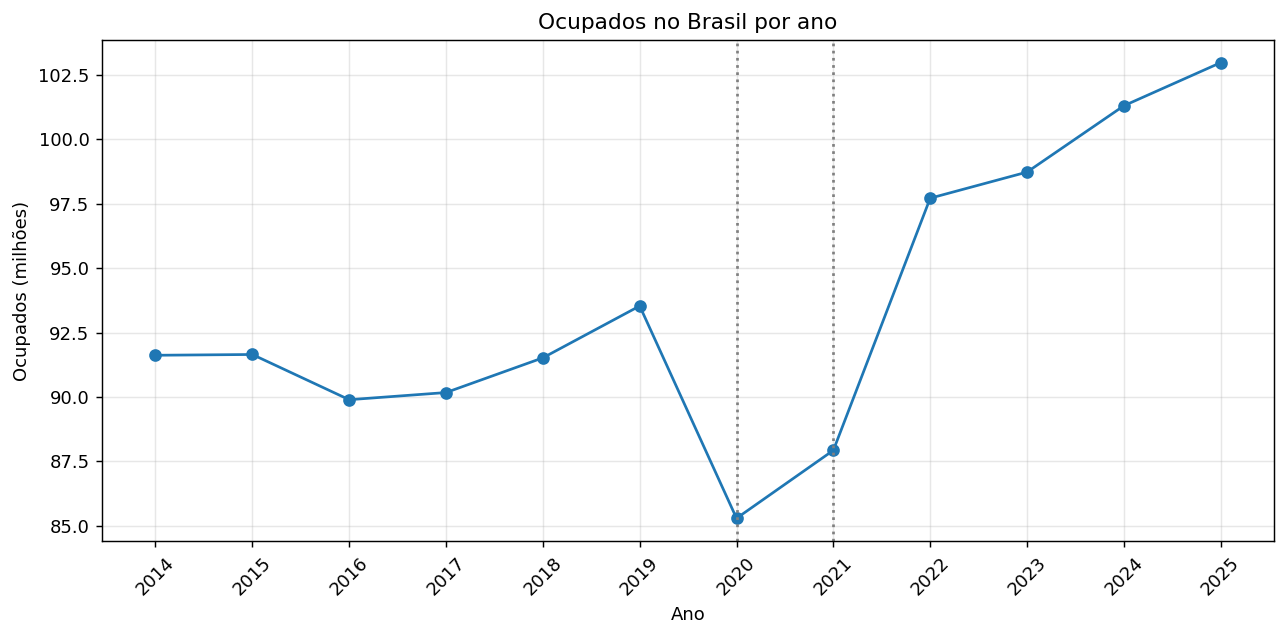

In [ ]:
# Reaproveita a série de ocupados em milhões.
serie = ocupados_por_ano / 1000000

# CORREÇÃO: garante que os anos (o índice da série) sejam números inteiros.
serie.index = serie.index.astype(int)

# Ordena pelos anos, do menor para o maior (garante a ordem certa na linha).
serie = serie.sort_index()

# Deixa a figura num tamanho confortável (largura, altura).
plt.figure(figsize=(10, 5))

# Desenha a linha com uma bolinha em cada ano.
plt.plot(serie.index, serie.values, marker="o")

# Título e nomes dos eixos.
plt.title("Ocupados no Brasil por ano")
plt.ylabel("Ocupados (milhões)")
plt.xlabel("Ano")

# Mostra um rótulo para cada ano no eixo de baixo (sem amontoar).
plt.xticks(serie.index, rotation=45)

# Linhas pontilhadas nos anos atípicos.
plt.axvline(2020, color="grey", linestyle=":")
plt.axvline(2021, color="grey", linestyle=":")

# Grade leve ao fundo, ajuda a ler os valores.
plt.grid(alpha=0.3)

# Ajusta o layout e mostra.
plt.tight_layout()
plt.show()

### 1.3 Ocupados por sexo, idade, escolaridade e raça/cor

In [ ]:
# Separa só os ocupados (texto exato que vimos antes).
ocupados = df[df["VD4002"] == "Pessoas ocupadas"]

# Agrupa por ano E por sexo ao mesmo tempo, e soma o peso.
ocupados_sexo = ocupados.groupby(["Ano", "V2007"])["V1032"].sum()

# Reorganiza para tabela: anos nas linhas, sexo nas colunas.
tabela_sexo = ocupados_sexo.unstack()

# Converte para milhões.
tabela_sexo = tabela_sexo / 1000000

# Mostra.
tabela_sexo

V2007,Homem,Mulher
Ano,,
2014,53.095460,38.524008
2015,53.018118,38.630996
2016,51.751679,38.142040
2017,51.762795,38.409263
2018,52.203584,39.315793
2019,53.442240,40.091974
2020,49.587785,35.701677
2021,51.327012,36.602479
2022,55.746535,41.972287


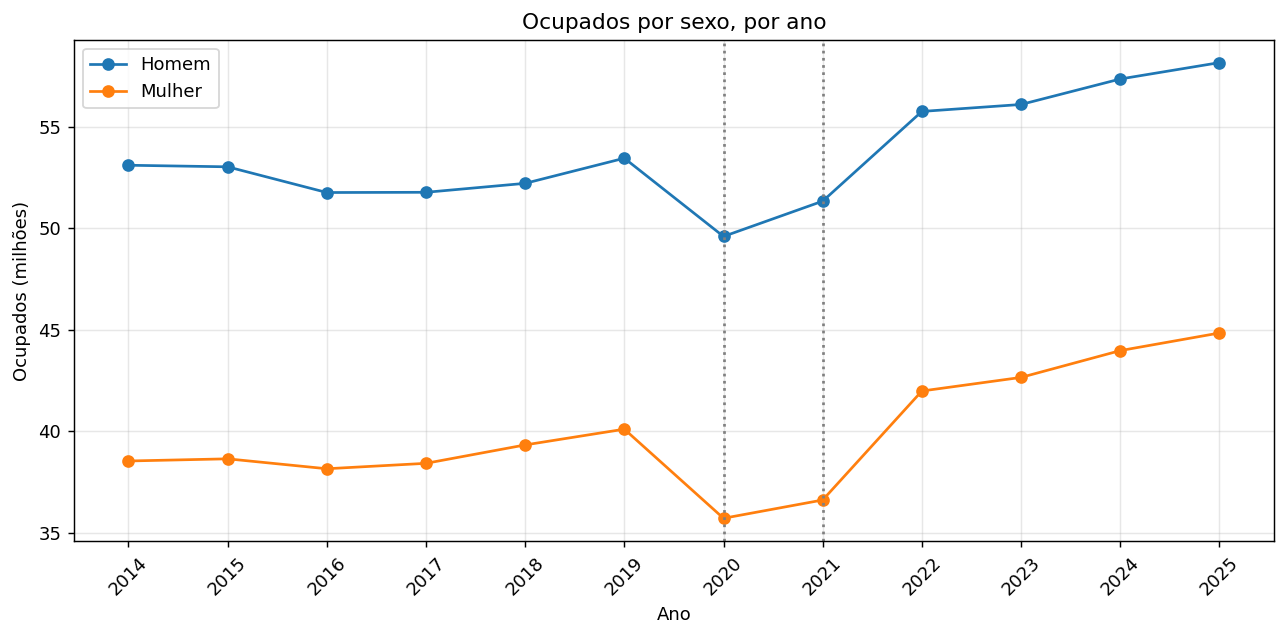

In [ ]:
# Garante anos como número inteiro e em ordem.
tabela_sexo.index = tabela_sexo.index.astype(int)
tabela_sexo = tabela_sexo.sort_index()

# Tamanho da figura.
plt.figure(figsize=(10, 5))

# Uma linha para cada sexo.
plt.plot(tabela_sexo.index, tabela_sexo["Homem"], marker="o", label="Homem")
plt.plot(tabela_sexo.index, tabela_sexo["Mulher"], marker="o", label="Mulher")

# Rótulos.
plt.title("Ocupados por sexo, por ano")
plt.ylabel("Ocupados (milhões)")
plt.xlabel("Ano")

# Um rótulo por ano.
plt.xticks(tabela_sexo.index, rotation=45)

# Anos atípicos.
plt.axvline(2020, color="grey", linestyle=":")
plt.axvline(2021, color="grey", linestyle=":")

# Legenda (usa os 'label' de cada linha) e grade.
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

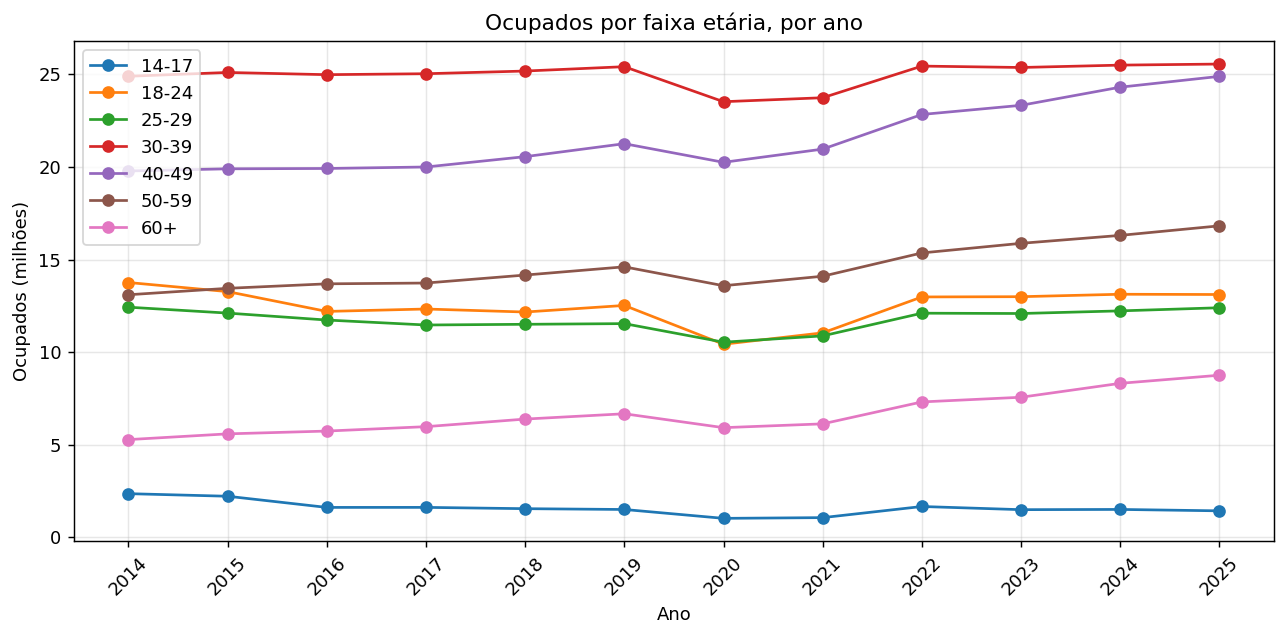

In [ ]:
# Cria faixas a partir da idade (V2009). pd.cut corta a idade nos limites dados.
# A borda esquerda é exclusiva: 13 garante que 14 anos caia em '14-17'.
faixas = pd.cut(ocupados["V2009"],
                bins=[13, 17, 24, 29, 39, 49, 59, 200],
                labels=["14-17", "18-24", "25-29", "30-39", "40-49", "50-59", "60+"])

# Soma o peso por ano e faixa, abre em tabela, passa para milhões.
tab_idade = ocupados.groupby(["Ano", faixas], observed=True)["V1032"].sum()
tab_idade = tab_idade.unstack()
tab_idade = tab_idade / 1000000

tab_idade.index = tab_idade.index.astype(int)
tab_idade = tab_idade.sort_index()

plt.figure(figsize=(10, 5))
for coluna in tab_idade.columns:
    plt.plot(tab_idade.index, tab_idade[coluna], marker="o", label=coluna)

plt.title("Ocupados por faixa etária, por ano")
plt.ylabel("Ocupados (milhões)")
plt.xlabel("Ano")
plt.xticks(tab_idade.index, rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

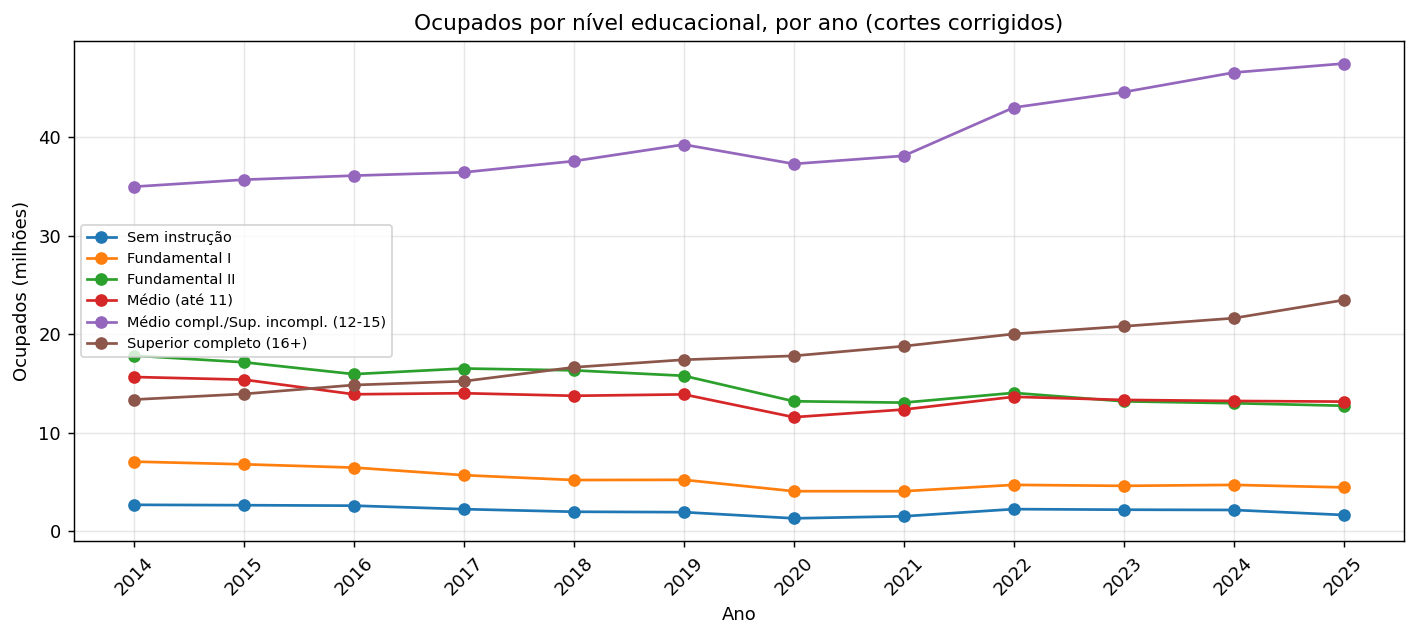

In [ ]:
ocupados = df[df["VD4002"] == "Pessoas ocupadas"]

# Extrai o número de anos de estudo de dentro do texto.
anos_estudo = ocupados["VD3005"].str.extract(r"(\d+)")
anos_estudo = anos_estudo[0].astype(float)

# Trata o "Sem instrução" explicitamente: onde o texto começa com "Sem", força 0.
sem_instrucao = ocupados["VD3005"].str.startswith("Sem")
anos_estudo[sem_instrucao.values] = 0

# Cortes corrigidos para o sistema brasileiro.
# 0 = sem instrução | 1-4 fundamental I | 5-8 fundamental II
# 9-11 médio incompleto | 12-15 médio completo/superior incompleto | 16+ superior completo
nivel = pd.cut(anos_estudo,
               bins=[-1, 0, 4, 8, 11, 15, 100],
               labels=["Sem instrução", "Fundamental I", "Fundamental II",
                       "Médio (até 11)", "Médio compl./Sup. incompl. (12-15)",
                       "Superior completo (16+)"])

tab_educ = ocupados.groupby(["Ano", nivel], observed=True)["V1032"].sum()
tab_educ = tab_educ.unstack()
tab_educ = tab_educ / 1000000
tab_educ.index = tab_educ.index.astype(int)
tab_educ = tab_educ.sort_index()

plt.figure(figsize=(11, 5))
for coluna in tab_educ.columns:
    plt.plot(tab_educ.index, tab_educ[coluna], marker="o", label=coluna)
plt.title("Ocupados por nível educacional, por ano (cortes corrigidos)")
plt.ylabel("Ocupados (milhões)")
plt.xlabel("Ano")
plt.xticks(tab_educ.index, rotation=45)
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

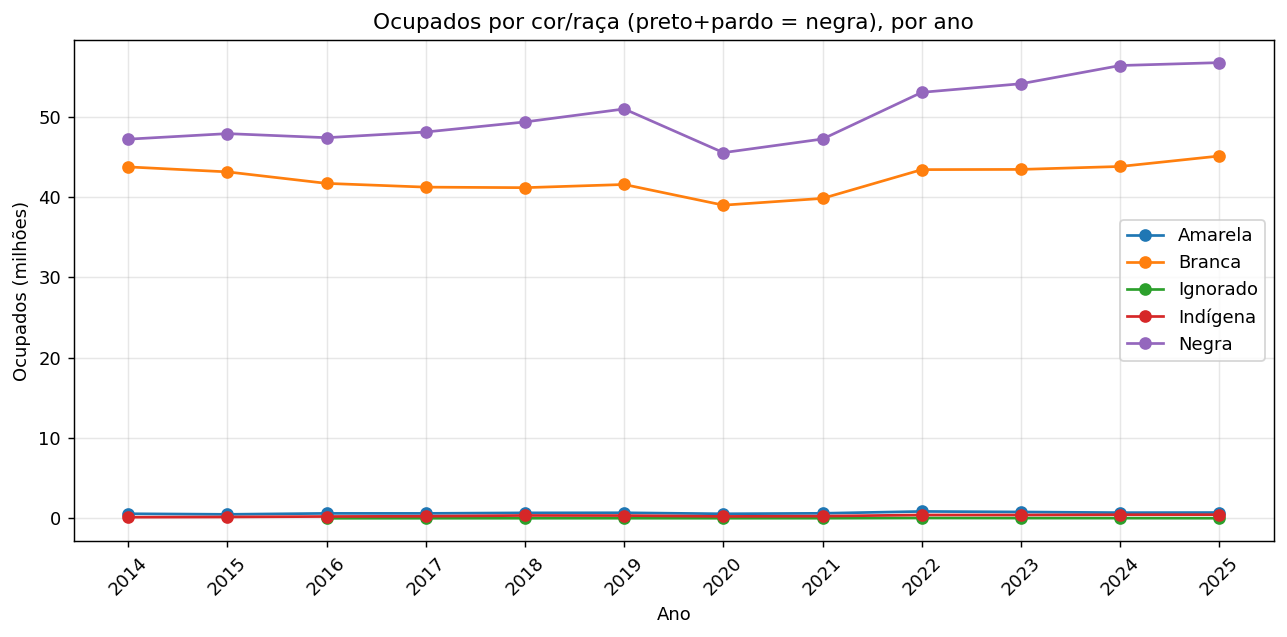

In [ ]:
ocupados = df[df["VD4002"] == "Pessoas ocupadas"]

# Cria uma cópia da coluna de raça para agrupar sem mexer no original.
raca = ocupados["V2010"].astype(str)

# Junta Preta + Parda numa única categoria "Negra".
raca = raca.replace({"Preta": "Negra", "Parda": "Negra"})

# Agrupa por ano e por essa raça já recodificada, soma o peso.
tab_raca = ocupados.groupby(["Ano", raca], observed=True)["V1032"].sum()
tab_raca = tab_raca.unstack() / 1000000
tab_raca.index = tab_raca.index.astype(int)
tab_raca = tab_raca.sort_index()

plt.figure(figsize=(10, 5))
for coluna in tab_raca.columns:
    plt.plot(tab_raca.index, tab_raca[coluna], marker="o", label=coluna)
plt.title("Ocupados por cor/raça (preto+pardo = negra), por ano")
plt.ylabel("Ocupados (milhões)")
plt.xlabel("Ano")
plt.xticks(tab_raca.index, rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1.4 Formalidade: vínculo (VD4009) e contribuição previdenciária (VD4012)

In [ ]:
ocupados = df[df["VD4002"] == "Pessoas ocupadas"]

# Lista com os rótulos EXATOS de VD4009 que contam como FORMAL.
# Ajuste os textos conforme o que apareceu no value_counts acima.
formais_labels = [
    "Empregado no setor privado com carteira de trabalho assinada",
    "Trabalhador doméstico com carteira de trabalho assinada",
    "Militar do exército, marinha, aeronáutica, policia ou bombeiro militar",
    "Empregado no setor público com carteira de trabalho assinada",
    "Servidor estatutário",
]

# Cria uma coluna nova: "Formal" se o rótulo está na lista, senão "Informal".
ocupados = ocupados.copy()
ocupados["formalidade"] = "Informal"
eh_formal = ocupados["VD4009"].isin(formais_labels)
ocupados.loc[eh_formal, "formalidade"] = "Formal"

# Soma o peso por ano e por formalidade, abre em tabela, em milhões.
tab_form = ocupados.groupby(["Ano", "formalidade"], observed=True)["V1032"].sum()
tab_form = tab_form.unstack() / 1000000
tab_form.index = tab_form.index.astype(int)
tab_form = tab_form.sort_index()

tab_form.round(2)

formalidade,Formal,Informal
Ano,,
2014,39.98,51.64
2015,39.38,52.27
2016,37.62,52.28
2017,36.37,53.80
2018,36.15,55.37
2019,37.02,56.51
2020,34.49,50.80
2021,34.36,53.57
2022,38.17,59.54


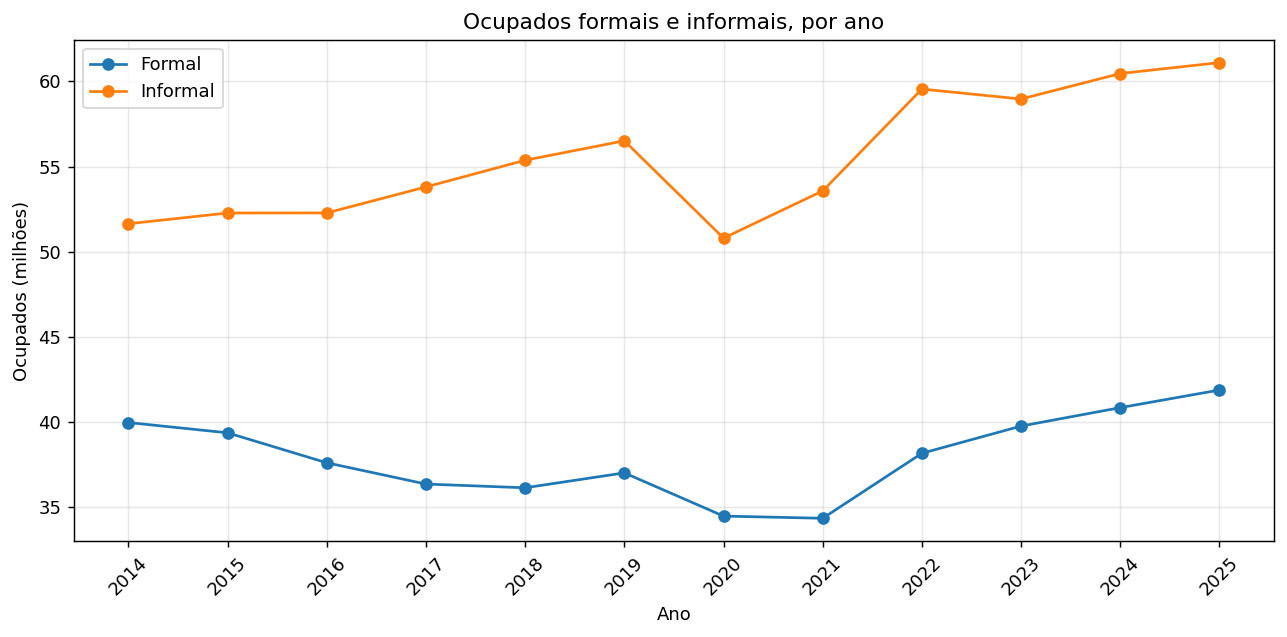

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
for coluna in tab_form.columns:
    plt.plot(tab_form.index, tab_form[coluna], marker="o", label=coluna)
plt.title("Ocupados formais e informais, por ano")
plt.ylabel("Ocupados (milhões)")
plt.xlabel("Ano")
plt.xticks(tab_form.index, rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

A VD4009 tem 10 categorias (fora o NaN, que são os não-ocupados). As claramente formais são as quatro com carteira/estatutário. As claramente informais são as sem carteira, doméstico sem carteira e trabalhador familiar auxiliar. O problema está em três categorias ambíguas: conta-própria, empregador e empregado público sem carteira.

A convenção mais aceita na literatura brasileira (IBGE/IPEA) trata assim:
Conta-própria e empregador são formais só se contribuem para a previdência — e é exatamente para isso que serve a VD4012 que você incluiu na nova extração. Sem ela, o critério usual é considerá-los informais (a maioria do conta-própria brasileiro é informal). O empregado público sem carteira (estatutário não, mas contratos precários) costuma entrar como informal.

Como a VD4012 já está no parquet (veio nesta extração), o ideal é usar a definição completa: formal = tem carteira/estatutário OU (conta-própria/empregador que contribui para a previdência).

In [ ]:
# Se aparecer a contagem por categorias, a variável já está no parquet.
# Se der erro de coluna inexistente, a extração nova ainda não foi carregada.
print(df["VD4009"].value_counts(dropna=False))



VD4009
NaN                                                             2841506
Empregado no setor privado com carteira de trabalho assinada     683466
Conta-própria                                                    593990
Empregado no setor privado sem carteira de trabalho assinada     278168
Militar e servidor estatutário                                   184868
Trabalhador doméstico sem carteira de trabalho assinada           99879
Empregador                                                        88746
Trabalhador familiar auxiliar                                     72709
Empregado no setor público sem carteira de trabalho assinada      71732
Trabalhador doméstico com carteira de trabalho assinada           36815
Empregado no setor público com carteira de trabalho assinada      27171
Name: count, dtype: int64


A boa notícia metodológica: muitos estudos usam a contribuição previdenciária como a definição de formalidade, sozinha — é objetiva, comparável e resolve o problema do conta-própria sem achismo. Formal = contribui; informal = não contribui. Vou usar essa, que é a mais defensável e a mais simples.

In [ ]:
ocupados = df[df["VD4002"] == "Pessoas ocupadas"].copy()

# FORMALIDADE pela contribuição previdenciária (definição objetiva).
ocupados["formalidade"] = "Informal"
eh_formal = ocupados["VD4012"] == "Contribuinte"
ocupados.loc[eh_formal, "formalidade"] = "Formal"

# Raça: preto + pardo = Negra.
ocupados["raca"] = ocupados["V2010"].astype(str)
ocupados["raca"] = ocupados["raca"].replace({"Preta": "Negra", "Parda": "Negra"})

# Só informais.
informais = ocupados[ocupados["formalidade"] == "Informal"]

tab_inf_raca = informais.groupby(["Ano", "raca"], observed=True)["V1032"].sum()
tab_inf_raca = tab_inf_raca.unstack() / 1000000
tab_inf_raca.index = tab_inf_raca.index.astype(int)
tab_inf_raca = tab_inf_raca.sort_index()

tab_inf_raca.round(2)

raca,Amarela,Branca,Ignorado,Indígena,Negra
Ano,,,,,
2014,0.14,12.05,NaN,0.06,19.74
2015,0.13,11.72,NaN,0.08,19.86
2016,0.16,11.36,0.00,0.11,19.54
2017,0.19,12.04,0.00,0.12,20.33
2018,0.21,12.21,0.00,0.16,21.06
2019,0.23,12.44,0.01,0.17,21.77
2020,0.17,10.70,0.01,0.11,18.54
2021,0.19,11.30,0.01,0.13,19.95
2022,0.28,12.66,0.01,0.19,22.40


In [ ]:
print(df["VD4012"].value_counts(dropna=False))

VD4012
NaN                 2841506
Contribuinte        1269522
Não contribuinte     868022
Name: count, dtype: int64


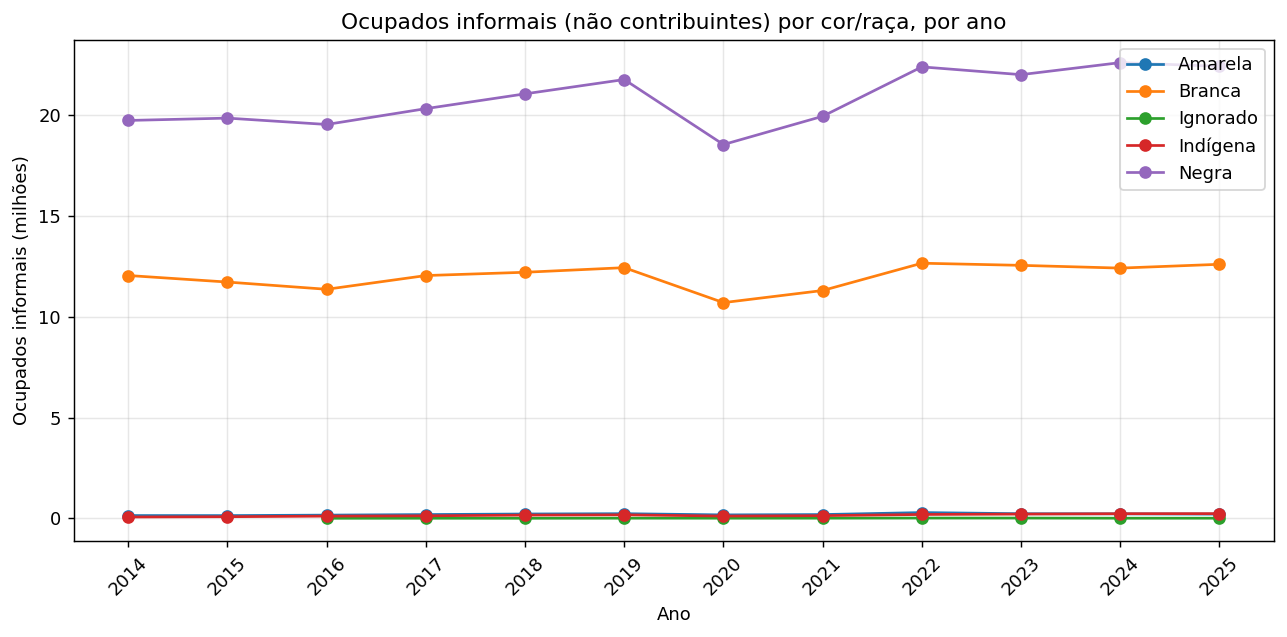

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
for coluna in tab_inf_raca.columns:
    plt.plot(tab_inf_raca.index, tab_inf_raca[coluna], marker="o", label=coluna)
plt.title("Ocupados informais (não contribuintes) por cor/raça, por ano")
plt.ylabel("Ocupados informais (milhões)")
plt.xlabel("Ano")
plt.xticks(tab_inf_raca.index, rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

ocupados = df[df["VD4002"] == "Pessoas ocupadas"].copy()

# Formalidade pela contribuição previdenciária.
ocupados["formalidade"] = "Informal"
eh_formal = ocupados["VD4012"] == "Contribuinte"
ocupados.loc[eh_formal, "formalidade"] = "Formal"

# Padroniza o sexo (Masculino/Feminino dos anos antigos -> Homem/Mulher).
ocupados["V2007"] = ocupados["V2007"].astype(str)
ocupados["V2007"] = ocupados["V2007"].replace({"Masculino": "Homem", "Feminino": "Mulher"})

# Agrupa por ano, sexo E formalidade ao mesmo tempo, soma o peso.
tab = ocupados.groupby(["Ano", "V2007", "formalidade"], observed=True)["V1032"].sum()

# Abre em tabela: anos nas linhas; nas colunas, cada combinação sexo+formalidade.
tab = tab.unstack(["V2007", "formalidade"]) / 1000000
tab.index = tab.index.astype(int)
tab = tab.sort_index()

tab.round(2)

V2007        Homem          Mulher         
formalidade Formal Informal Formal Informal
Ano                                        
2014         34.22    18.87  25.41    13.12
2015         34.25    18.77  25.61    13.02
2016         33.24    18.51  25.48    12.66
2017         32.41    19.35  25.08    13.33
2018         32.51    19.70  25.37    13.94
2019         33.18    20.26  25.74    14.35
2020         31.81    17.78  23.95    11.75
2021         32.22    19.11  24.13    12.47
2022         34.94    20.81  27.24    14.73
2023         35.57    20.52  28.15    14.49
2024         36.56    20.78  29.27    14.69
2025         37.39    20.76  30.11    14.72

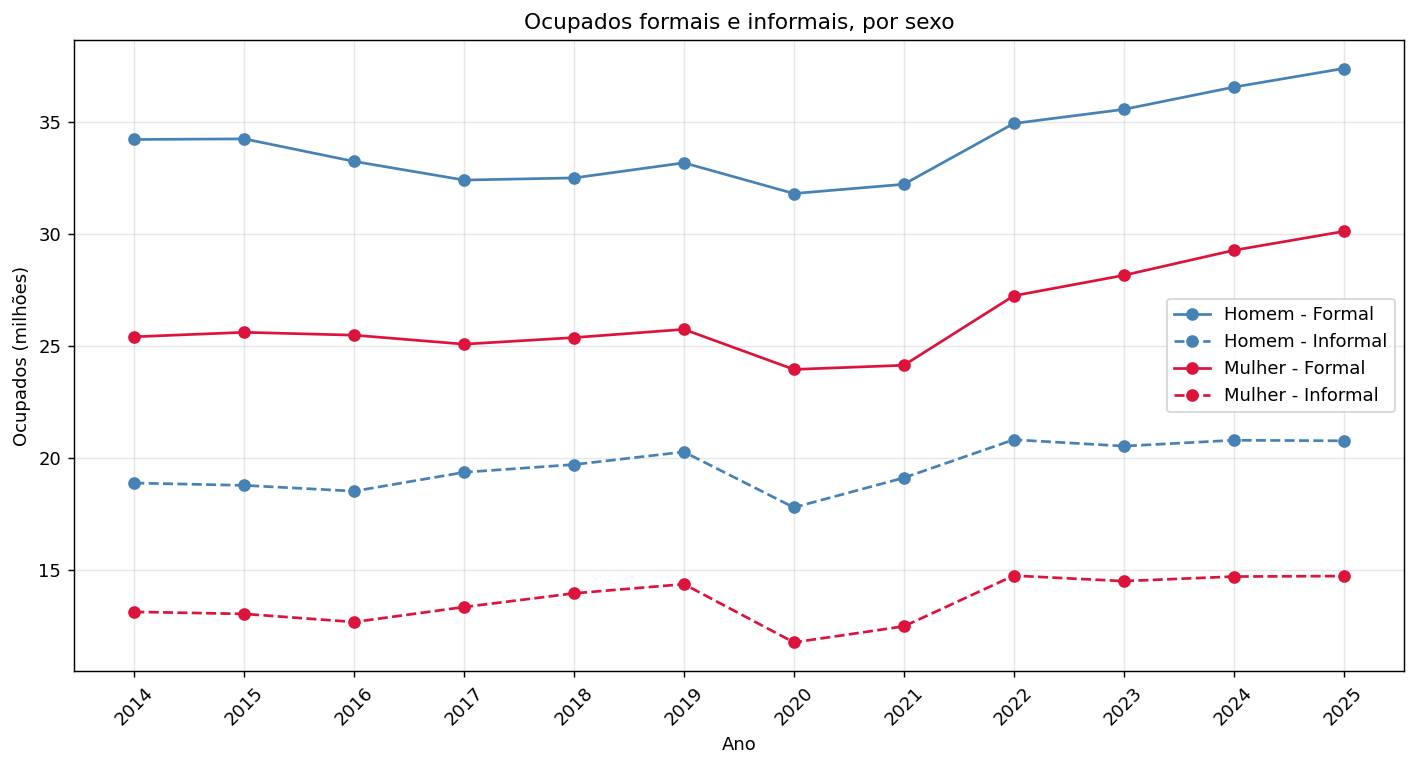

In [ ]:
plt.figure(figsize=(11, 6))

# Cada linha: escolhe a combinação, define cor (sexo) e traço (formalidade).
plt.plot(tab.index, tab[("Homem", "Formal")],   marker="o", color="steelblue", linestyle="-",  label="Homem - Formal")
plt.plot(tab.index, tab[("Homem", "Informal")], marker="o", color="steelblue", linestyle="--", label="Homem - Informal")
plt.plot(tab.index, tab[("Mulher", "Formal")],   marker="o", color="crimson",   linestyle="-",  label="Mulher - Formal")
plt.plot(tab.index, tab[("Mulher", "Informal")], marker="o", color="crimson",   linestyle="--", label="Mulher - Informal")

plt.title("Ocupados formais e informais, por sexo")
plt.ylabel("Ocupados (milhões)")
plt.xlabel("Ano")
plt.xticks(tab.index, rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Parte 2 — Crosswalk ocupacional: famílias COD → âncoras × níveis

**Método.** Clusterização semântica dos descritores (embeddings + KMeans/HDBSCAN) e palavras-chave como **pré-classificação**; alocação final supervisionada em 11 âncoras temáticas e 4 níveis hierárquicos (Direção, Especialista, Técnico, Básico/Operacional), com auditoria setorial pela CNAE-Domiciliar.

### 2.1 Descritores da COD e tabela de famílias

In [ ]:
# Caminho do arquivo DENTRO do Drive montado.

caminho = "/content/drive/MyDrive/Colab Notebooks/cod_descritores.parquet"
# Lê o parquet e guarda na variável df.
descritores = pd.read_parquet(caminho)

# Confirma o tamanho da tabela.
print("Linhas:", len(descritores), "  Colunas:", descritores.shape[1])

Linhas: 14048   Colunas: 2


In [ ]:
print(descritores.columns.tolist())
descritores.head(15)

['cod_familia', 'cod_descritor']


,cod_familia,cod_descritor
0,0000,Ocupação mal definida
1,0110,Almirante
2,0110,Almirante de esquadra
3,0110,Aluno centro de preparação oficiais reserva
4,0110,Aspirante a oficial da aeronáutica
5,0110,Aspirante a oficial da marinha
6,0110,Aspirante a oficial do exército
7,0110,Brigadeiro
8,0110,Cadete da aeronáutica
9,0110,Cadete da marinha de guerra


In [ ]:
descritores.dtypes

,0
cod_familia,object
cod_descritor,object


In [ ]:
import os
# Lista os arquivos da pasta pra ver o nome exato
os.listdir("/content/drive/MyDrive/Colab Notebooks/")

['Untitled0.ipynb',
 'Cópia de BigQuery bquxjob_73676c08_1848b147e35 (1)',
 'Cópia de Cópia de BigQuery bquxjob_73676c08_1848b147e35',
 'Cópia de BigQuery bquxjob_73676c08_1848b147e35',
 'Cópia de Copy of BigQuery bquxjob_40651b26_18486f38d00',
 'Untitled1.ipynb',
 'CNN.ipynb',
 'novo_merge.ipynb',
 'Sarima.ipynb',
 'RNN.ipynb',
 'IEX.ipynb',
 'Cópia de Modelo_Final_Bootcamp_Lewagon.ipynb',
 'Untitled2.ipynb',
 'Cópia de 3-Modelo Final - Bootcamp - Lewagon',
 'Modelo_Final_Bootcamp_Lewagon.ipynb',
 'CNN_categorical.ipynb',
 'PDDE_2018.ipynb',
 'Untitled3.ipynb',
 'Untitled4.ipynb',
 'Numpy.ipynb',
 'Untitled5.ipynb',
 'Untitled6.ipynb',
 'Untitled7.ipynb',
 'Untitled8.ipynb',
 'Untitled (1)',
 'Untitled9.ipynb',
 'Untitled10.ipynb',
 'Untitled11.ipynb',
 'Untitled12.ipynb',
 'Untitled13.ipynb',
 'Untitled14.ipynb',
 'Untitled16.ipynb',
 'exercicio_estrutura.ipynb',
 ' CNN_categorical.ipynb',
 'Modelo_Final_pdde.ipynb',
 'Busca scielo',
 'scrap_DOU.ipynb',
 'Cópia de criacao_ban

In [ ]:
# Caminho do arquivo DENTRO do Drive montado.

caminho = "/content/drive/MyDrive/Colab Notebooks/familias_COD.csv.csv"
# Lê o parquet e guarda na variável df.
familias = pd.read_csv(caminho)

# Confirma o tamanho da tabela.
print("Linhas:", len(familias), "  Colunas:", familias.shape[1])

Linhas: 434   Colunas: 9


### 2.2 Conferência das bases e junção dos descritores

In [ ]:
import pandas as pd
print(len(df), len(descritores), len(familias))  # esperado: 4979050, 14048, 434

4979050 14048 434


Bloco 2 — juntar os descritores às famílias (agora funciona, porque os dois estão no formato longo e com código string de 4 dígitos):

A correção é forçar os dois lados para o mesmo formato (string de 4 dígitos) antes do merge. Substitua o Bloco 2 por esta versão, que padroniza tudo de forma defensiva independentemente de como os arquivos foram lidos

In [ ]:
# Padroniza cod_familia como string de 4 dígitos NOS DOIS lados
descritores["cod_familia"] = descritores["cod_familia"].astype(str).str.zfill(4)
familias["cod_familia"] = familias["cod_familia"].astype(str).str.zfill(4)

desc_agg = (
    descritores.groupby("cod_familia")["cod_descritor"]
    .apply(" | ".join)
    .reset_index()
    .rename(columns={"cod_descritor": "todos_descritores"})
)

familias = familias.merge(desc_agg, on="cod_familia", how="left")
print("Famílias sem descritor:", familias["todos_descritores"].isna().sum())
familias[["cod_familia", "nome_familia", "todos_descritores"]].head()

Famílias sem descritor: 0


,cod_familia,nome_familia,todos_descritores
0,1111,Legisladores,Camarista (vereador municipal) | Deputado dist...
1,1112,Dirigentes superiores da administração pública,Adido | Agente consular | Assessor politico (n...
2,1113,Chefes de pequenas populações,Cacique ou morubixaba | Lider de comunidade ca...
3,1114,Dirigentes de organizações que apresentam um i...,Conselheiro comunitário | Delegado sindical | ...
4,1120,Diretores gerais e gerentes gerais,Banqueiro - nas instituições de credito | Chef...


### 2.3 Ponte com a PNAD (V4010)

Bloco 3 — checar a ponte com a PNAD (V4010 é a família ocupacional na PNAD; confirmar formato antes de qualquer merge):

In [ ]:
print("Tipo:", df["V4010"].dtype)
print("\nExemplos de valores:")
print(df["V4010"].dropna().unique()[:15])
print("\nQuantos códigos distintos:", df["V4010"].nunique())
print("Quantas linhas com V4010 preenchido:", df["V4010"].notna().sum())

Tipo: object

Exemplos de valores:
['8322' '5153' '4214' '0000' '2320' '2151' '2421' '4110' '2411' '2634'
 '2163' '9412' '5223' '9611' '9313']

Quantos códigos distintos: 435
Quantas linhas com V4010 preenchido: 2137544


In [ ]:
# Merge da PNAD com a tabela de famílias (só colunas necessárias, pra não inchar o df)
cols_fam = ["cod_familia", "nome_familia", "grande_grupo", "subclassificacao"]
df = df.merge(familias[cols_fam], left_on="V4010", right_on="cod_familia", how="left")

# Cobertura: entre os OCUPADOS, quantos ficaram sem classificação?
ocupados_mask = df["VD4002"] == "Pessoas ocupadas"
sem_class = df.loc[ocupados_mask & df["nome_familia"].isna(), "V4010"].value_counts()
print("Ocupados sem classificação:", sem_class.sum())
print(sem_class.head())

Ocupados sem classificação: 1034
V4010
0000    1034
Name: count, dtype: int64


In [ ]:
tab_sub = (
    df[ocupados_mask & (df["Ano"].astype(int) == 2025)]
    .groupby("subclassificacao", observed=True)["V1032"].sum() / 1e6
)
print(tab_sub.round(2))

subclassificacao
Analista    13.87
Direção      3.85
Operador    76.01
Técnico      9.24
Name: V1032, dtype: float64


Bateu perfeitamente: 3,85 + 13,87 + 9,24 + 76,01 = 102,97 milhões — praticamente idêntico aos 102,98 mi de ocupados de 2025 que você tinha calculado antes (a diferença de ~0,01 é o '0000', mal definida). E a distribuição é exatamente a esperada para o Brasil: Operador dominante (~74%), depois Analista, Técnico e Direção. A infraestrutura está fechada e validada.

A infraestrutura está completa: PNAD ↔ famílias ↔ descritores, tudo conectado. O que falta é só o conteúdo da coluna grupo_ocupacional — e aí volto à pergunta que está travando o Bloco 4 desde antes da bagunça: como você quer tratar a sobreposição entre Cuidados e Saúde/Educação? As três opções: (a) Cuidados é categoria exclusiva e "rouba" as famílias de saúde/assistência/educação infantil dos outros grupos; (b) Cuidados vira uma coluna transversal separada (eh_cuidado sim/não), e cada família mantém seu grupo setorial; (c) Cuidados fica restrito à assistência social. Minha sugestão é a (b) — é a mais limpa analiticamente (você consegue reportar "X% do emprego em Saúde é trabalho de cuidado") e evita decisões arbitrárias de fronteira

### 2.4 Pré-classificação por palavras-chave

BLOCO 4 — pré-classificação por palavra-chave sobre nome + TODOS os descritores

In [ ]:
# BLOCO 4 — pré-classificação por palavra-chave sobre nome + TODOS os descritores
texto_busca = (familias["nome_familia"] + " | " + familias["todos_descritores"]).str.lower()

grupos_kw = {
    "Saúde": ["médic", "enferm", "saúde", "hospital", "odontol", "fisioterap",
              "nutricion", "farmac", "psicólog", "fonoaudi", "parteir", "radiolog"],
    "Educação": ["professor", "docente", "pedagog", "creche", "berçarista",
                 "jardim de infância", "educação infantil", "instrutor", "monitor de ensino"],
    "STEM": ["engenheir", "matemátic", "físic", "químic", "estatístic", "programador",
             "desenvolvedor", "analista de sistemas", "biólog", "geólog", "astrônom",
             "cientista de dados", "rede de computadores", "software"],
    "Agropecuária e pesca": ["agropecuár", "agricultor", "pecuarist", "pescador",
                             "aquicult", "silvicult", "lavoura", "criador de", "tratorista"],
    "Indústria": ["operador de máquina", "montador", "soldador", "metalúrgic",
                  "torneiro", "fundidor", "tecelã", "costureir", "padeiro industrial"],
}

cuidado_kw = ["cuidador", "babá", "acompanhante de idoso", "assistente social",
              "auxiliar de creche", "atendente de enfermagem", "doméstic"]

def pre_tag(texto):
    for grupo, palavras in grupos_kw.items():
        if any(p in texto for p in palavras):
            return grupo
    return ""

familias["grupo_sugerido"] = texto_busca.apply(pre_tag)
familias["cuidado_sugerido"] = texto_busca.apply(
    lambda t: "Sim" if any(p in t for p in cuidado_kw) else ""
)

print(familias["grupo_sugerido"].value_counts(dropna=False))
print("\nCom tag de cuidado:", (familias["cuidado_sugerido"] == "Sim").sum())

# Exporta para revisão manual — ordenada por grande grupo pra facilitar a leitura
familias_out = familias[[
    "cod_familia", "nome_familia", "grande_grupo", "nome_grande_grupo",
    "subclassificacao", "grupo_sugerido", "cuidado_sugerido",
    "grupo_ocupacional", "fonte_criterio", "todos_descritores"
]].sort_values(["grande_grupo", "cod_familia"])

familias_out.to_excel(
    "/content/drive/MyDrive/Colab Notebooks/de_para_ocupacoes_REVISAR.xlsx",
    index=False
)
print("\n✓ Planilha exportada para o Drive")

grupo_sugerido
                        215
Saúde                    65
Indústria                62
STEM                     45
Agropecuária e pesca     25
Educação                 22
Name: count, dtype: int64

Com tag de cuidado: 19

✓ Planilha exportada para o Drive


Grupo_sugerido e cuidado_sugerido são palpites do keyword-match — só rascunho. A coluna que vale é grupo_ocupacional, que você preenche revisando linha a linha (a coluna todos_descritores está ali justamente pra você ler os sinônimos e decidir; use o BLS OOH para casos onde o conteúdo do trabalho não está claro).
As linhas onde grupo_sugerido ficou vazio vão precisar de decisão sua — e muitas delas provavelmente vão cair num grupo residual tipo "Serviços/Administração/Outros", que você vai precisar criar (as suas 6 categorias não cobrem comércio, transporte, construção, administrativo...).
Anote em fonte_criterio o que embasou cada decisão não-óbvia (Luana / Mariana / BLS / decisão própria) — isso vira a documentação metodológica da dissertação depois.

### 2.5 Crosswalk final: 11 âncoras e merge com a PNAD

Criei com Mariana e Jannuzzi um grupo de agrupamentos após aplicar clusterização via kmeans usando os descritores.
Uma âncora só serve para projeção se sua trajetória responde a um conjunto identificável de drivers. As  11 passam nesse teste — cada uma tem motores de futuro distintos (envelhecimento → Cuidados/Saúde; difusão de IA → Administração básica e partes de Ciência e Inovação; coortes escolares encolhendo → Educação; mecanização → Agro; plataformização → Transporte/Serviços).

In [ ]:
caminho_ancoras = "/content/drive/MyDrive/Colab Notebooks/familias_COD_ancoras_final.csv"
ancoras = pd.read_csv(caminho_ancoras, sep=";", dtype={"cod_familia": str})
ancoras["cod_familia"] = ancoras["cod_familia"].astype(str).str.zfill(4)

In [ ]:
print("Linhas:", len(ancoras))
print("Colunas:", ancoras.columns.tolist())
ancoras["ancora"].value_counts()

Linhas: 434
Colunas: ['cod_familia', 'nome_familia', 'grande_grupo', 'subgrupo', 'nivel', 'ancora', 'decisor_publico_por_definicao', 'circulo', 'flag_revisar', 'fonte_criterio', 'Unnamed: 10']


,count
ancora,
"Indústria, Produção e Infraestrutura",102
"Comércio, Serviços e Lazer",87
Administração e Gestão,66
Ciência e Inovação,32
Humanidades e Cultura,26
Agropecuária e Pesca,25
Cuidados,25
Saúde,24
Transporte e Logística,23


Três verificações antes de fazer o merge com a PNAD — importantes porque o arquivo passou por edição manual (Excel adora introduzir problemas silenciosos):

In [ ]:
# 1) O dtype segurou os zeros à esquerda? (deve mostrar códigos como '0110', não '110')
print(ancoras["cod_familia"].str.len().value_counts())  # esperado: tudo 4

# 2) Nenhuma família ficou sem âncora ou duplicada na edição?
print("Sem âncora:", ancoras["ancora"].isna().sum())
print("Duplicadas:", ancoras["cod_familia"].duplicated().sum())

# 3) Nomes de âncora consistentes (sem variações de digitação tipo 'Saude' vs 'Saúde')
print(ancoras["ancora"].unique())

cod_familia
4    434
Name: count, dtype: int64
Sem âncora: 0
Duplicadas: 0
['Administração e Gestão' 'Ciência e Inovação' 'Agropecuária e Pesca'
 'Indústria, Produção e Infraestrutura' 'Transporte e Logística'
 'Cuidados' 'Saúde' 'Educação' 'Comércio, Serviços e Lazer'
 'Humanidades e Cultura' 'carve-out, sem projeção' 'Segurança e Defesa']


In [ ]:
ancoras["cod_familia"] = ancoras["cod_familia"].astype(str).str.zfill(4)

Agora sim: Bloco A — merge do crosswalk com a PNAD:

In [ ]:
ancoras["cod_familia"] = ancoras["cod_familia"].astype(str).str.zfill(4)

df = df.merge(
    ancoras[["cod_familia", "ancora", "nivel", "decisor_publico_por_definicao", "circulo"]],
    left_on="V4010", right_on="cod_familia", how="left"
)

publico_labels = ["Empregado no setor público com carteira de trabalho assinada",
                  "Empregado no setor público sem carteira de trabalho assinada",
                  "Militar e servidor estatutário"]
df["setor_publico"] = df["VD4009"].isin(publico_labels).map({True: "Público", False: "Privado"})

In [ ]:
print(df.columns.tolist())

['Ano', 'UF', 'Estrato', 'V1022', 'V1023', 'V1032', 'V2007', 'V2009', 'V2010', 'VD3004', 'VD3005', 'V4010', 'V4013', 'V4019', 'V4040', 'VD4002', 'VD4016', 'VD4031', 'VD4035', 'V5001A', 'S01029', 'VD4001', 'VD4009', 'VD4012', 'cod_familia_x', 'nome_familia', 'grande_grupo', 'subclassificacao', 'cod_familia_y', 'ancora', 'nivel', 'decisor_publico_por_definicao', 'circulo', 'setor_publico']


Bloco B — validação da cobertura: Cobertura perfeita: os únicos ocupados sem âncora são os 1.034 registros amostrais com código '0000' (Ocupação mal definida) — nenhuma família se perdeu na sua edição manual. Para dimensionar: 1.034 registros em ~2,1 milhões de observações de ocupados é ~0,05% da amostra, estatisticamente irrelevante para a projeção.

In [ ]:
ocup = df[df["VD4002"] == "Pessoas ocupadas"]
sem = ocup[ocup["ancora"].isna()]["V4010"].value_counts()
print("Ocupados sem âncora:", sem.sum())
print(sem.head())

Ocupados sem âncora: 1034
V4010
0000    1034
Name: count, dtype: int64


Bloco C — a tabela-síntese, ocupados por âncora × ano (em milhões):

In [ ]:
tab_ancora = (
    ocup.groupby(["Ano", "ancora"], observed=True)["V1032"].sum()
    .unstack("ancora") / 1e6
)
tab_ancora.index = tab_ancora.index.astype(int)
tab_ancora = tab_ancora.sort_index()
tab_ancora.round(2)

ancora,Administração e Gestão,Agropecuária e Pesca,Ciência e Inovação,"Comércio, Serviços e Lazer",Cuidados,Educação,Humanidades e Cultura,"Indústria, Produção e Infraestrutura",Saúde,Segurança e Defesa,Transporte e Logística,"carve-out, sem projeção"
Ano,,,,,,,,,,,,
2014,13.72,9.22,1.16,26.37,8.92,3.38,1.01,17.58,1.35,2.13,6.09,0.29
2015,13.78,9.02,1.16,26.87,9.38,3.40,0.98,17.22,1.37,2.21,5.93,0.31
2016,13.12,8.75,1.14,27.02,9.49,3.01,0.99,16.14,1.59,2.27,6.04,0.33
2017,13.02,8.49,1.19,28.15,9.49,3.01,0.97,15.71,1.51,2.19,6.08,0.35
2018,13.09,8.33,1.26,28.70,9.68,3.40,1.00,15.70,1.67,2.17,6.12,0.37
2019,13.39,8.41,1.35,29.33,9.82,3.46,1.04,16.22,1.60,2.19,6.37,0.34
2020,12.78,7.85,1.35,25.82,8.56,3.30,0.86,14.75,1.61,2.06,6.00,0.32
2021,12.73,8.55,1.51,26.31,8.79,3.45,0.95,15.58,1.72,2.03,5.97,0.34
2022,13.46,8.61,1.82,30.21,10.27,3.44,1.19,17.54,1.91,2.13,6.79,0.34


A base está validada — essa é a foto de partida da sua projeção, e ela conta uma história coerente. Lendo o gráfico como especialista:
Magnitudes corretas. Comércio/Serviços/Lazer (~31 mi) e Indústria (~18 mi) como blocos dominantes; FFAA no chão (~0,3 mi, carve-out do tamanho certo); a soma bate com seus ~103 mi de ocupados em 2025. Cuidados-núcleo em ~9,5 mi — um pouco acima do que eu estimei, mas correto: só os domésticos (9111) são ~4–5 mi, mais cuidadores, assistentes sociais e pré-escolar.
Trajetórias que batem com a literatura e reforçam a confiança no crosswalk:

Agropecuária caindo (9,3 → ~8 mi): a mecanização esvaziando o campo, tendência estrutural de décadas — sua série capta.
Transporte subindo forte (6,1 → ~7,9 mi): o boom do delivery e da logística do e-commerce — note que cruza a Agro exatamente no período pós-pandemia, um achado visual que vai render na tese.
Ciência e Inovação dobrando (~1 → ~2 mi): coerente com o crescimento de 148% da Tecnologia que a Mariana encontrou na RAIS 2010–2023.
Saúde quase dobrando (2 → 3,7 mi): expansão pré-pandemia + choque COVID + envelhecimento.

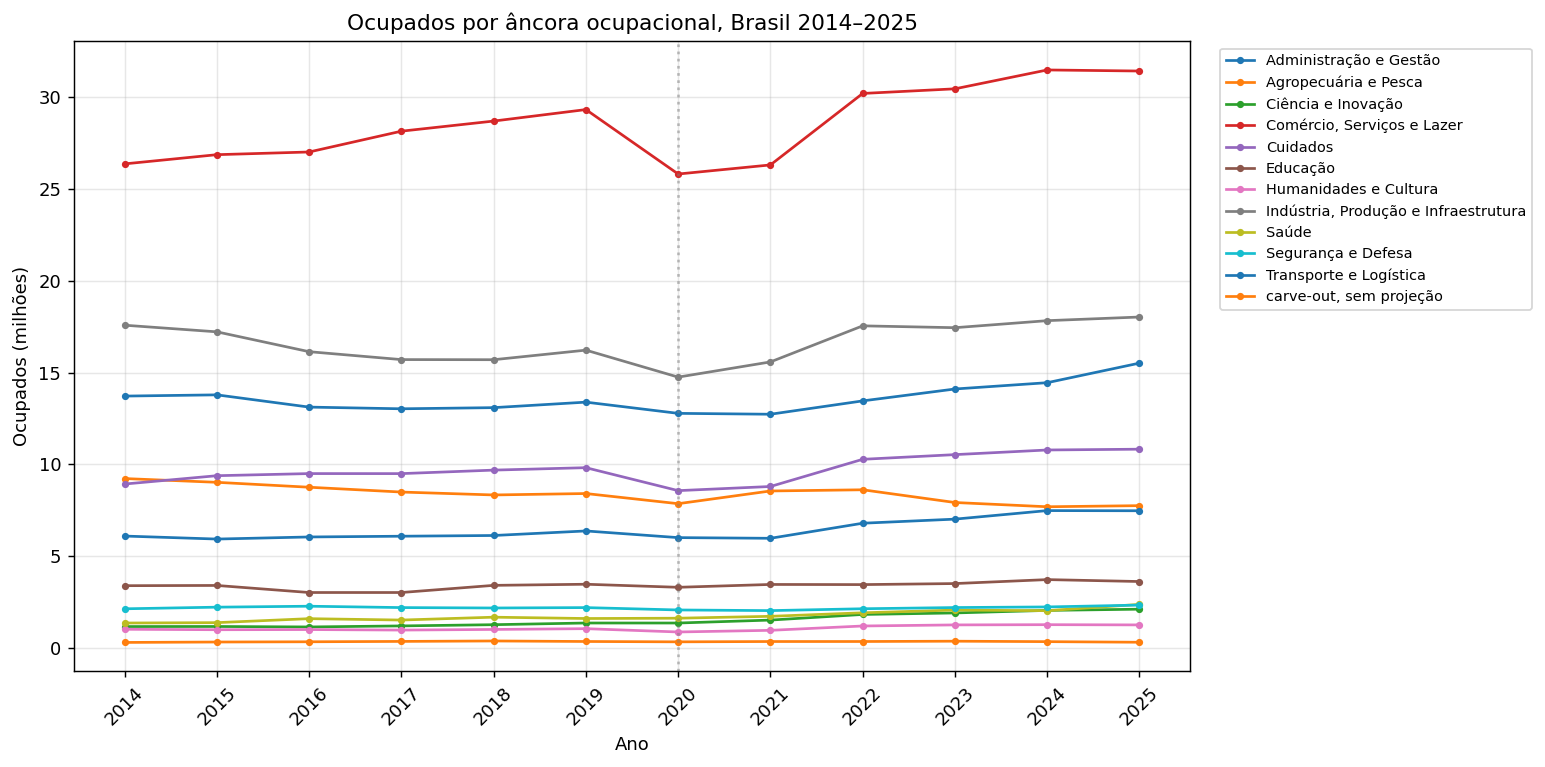

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for ancora in tab_ancora.columns:
    plt.plot(tab_ancora.index, tab_ancora[ancora], marker="o", markersize=3, label=ancora)
plt.title("Ocupados por âncora ocupacional, Brasil 2014–2025")
plt.ylabel("Ocupados (milhões)")
plt.xlabel("Ano")
plt.xticks(tab_ancora.index, rotation=45)
plt.axvline(2020, color="grey", linestyle=":", alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2.6 Leitura por âncora e nível

#### Administração e Gestão: recomposição vertical

nivel  Direção  Especialista  Técnico  Básico/Operacional
Ano                                                      
2014      2.77          1.80     1.68                7.48
2015      2.86          1.90     1.75                7.28
2016      2.74          2.08     1.88                6.42
2017      2.53          2.13     1.73                6.63
2018      2.21          2.22     1.44                7.22
2019      2.34          2.31     1.30                7.43
2020      1.91          2.40     1.32                7.14
2021      1.61          2.54     1.48                7.10
2022      1.61          2.85     1.49                7.51
2023      1.58          3.00     1.62                7.91
2024      1.73          2.96     1.64                8.13
2025      1.94          3.56     1.76                8.25


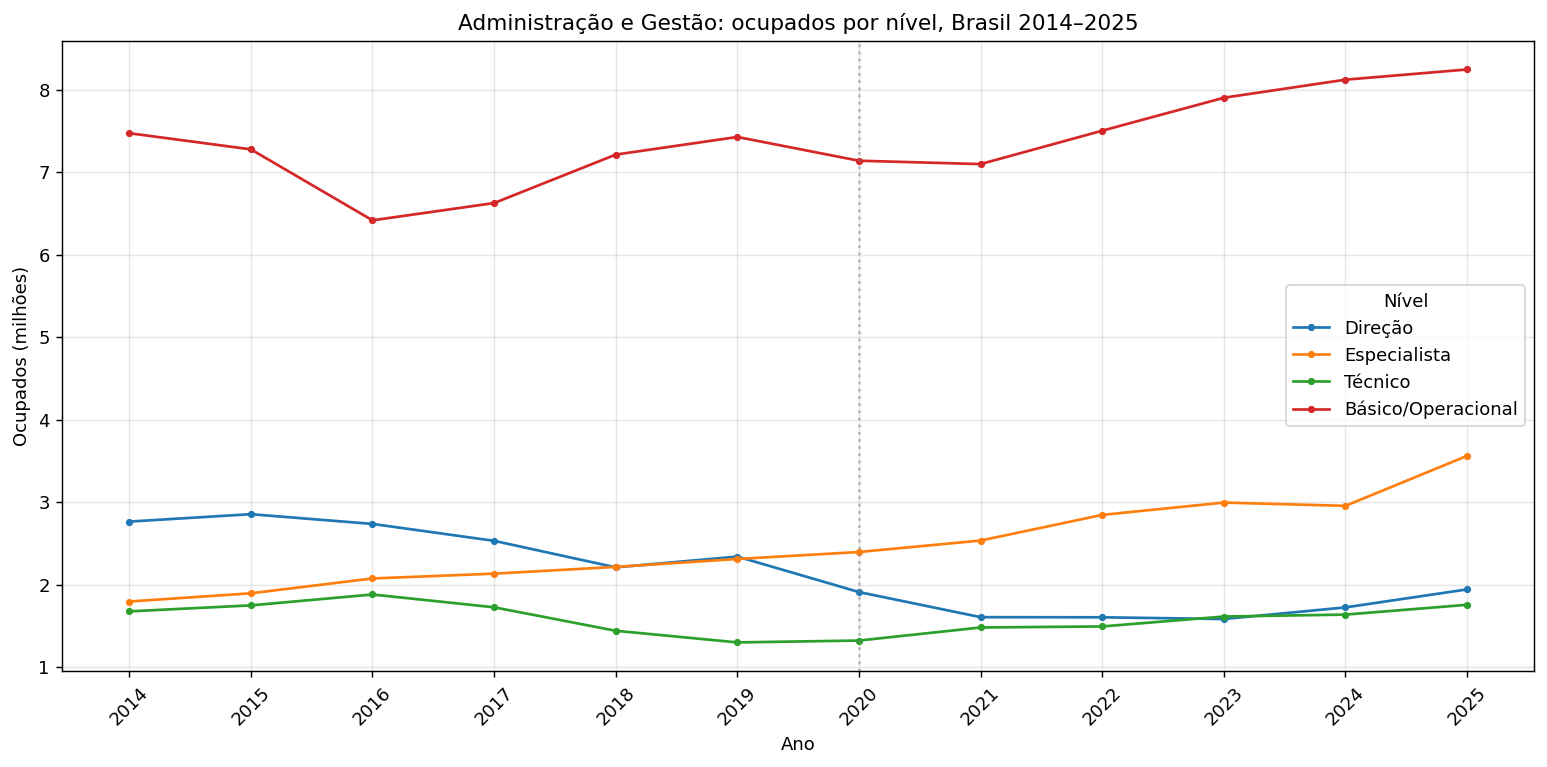

In [ ]:
# Tabela: ocupados em Administração e Gestão, por nível e ano
adm = ocup[ocup["ancora"] == "Administração e Gestão"]

tab_adm = (
    adm.groupby(["Ano", "nivel"], observed=True)["V1032"].sum()
    .unstack("nivel") / 1e6
)
tab_adm.index = tab_adm.index.astype(int)
tab_adm = tab_adm.sort_index()

# Ordena as colunas na hierarquia (e não alfabeticamente)
ordem = ["Direção", "Especialista", "Técnico", "Básico/Operacional"]
tab_adm = tab_adm[[c for c in ordem if c in tab_adm.columns]]

print(tab_adm.round(2))

# Gráfico
plt.figure(figsize=(12, 6))
for nivel in tab_adm.columns:
    plt.plot(tab_adm.index, tab_adm[nivel], marker="o", markersize=3, label=nivel)
plt.title("Administração e Gestão: ocupados por nível, Brasil 2014–2025")
plt.ylabel("Ocupados (milhões)")
plt.xlabel("Ano")
plt.xticks(tab_adm.index, rotation=45)
plt.axvline(2020, color="grey", linestyle=":", alpha=0.5)
plt.legend(title="Nível")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Especialista é a grande história: dobrou (1,8 → 3,55 mi). Crescimento contínuo, quase imune à recessão de 2015–16 e à pandemia, acelerando no fim da série. Isso é a profissionalização da gestão: contadores, analistas financeiros e de gestão, especialistas de RH, advogados. Ela cruza a linha da Direção por volta de 2018–19 — um marco simbólico de recomposição: a âncora deixa de ser "chefes + escriturários" e ganha um miolo técnico-profissional denso.
Direção em queda estrutural (2,75 → 1,6 mi entre 2014 e 2021, recuperação parcial depois). Cair ~40% é demais para ser só ciclo. Duas hipóteses não excludentes: (a) achatamento hierárquico real — o fenômeno de delayering documentado internacionalmente, camadas gerenciais intermediárias eliminadas por reestruturação e digitalização; (b) efeito da recessão + pandemia sobre pequenos negócios cujos donos se declaravam dirigentes. Vale um diagnóstico rápido antes de interpretar na tese:

O padrão é claro — e favorece a hipótese do achatamento hierárquico, não a dos pequenos negócios: a queda está espalhada pelos dirigentes funcionais (vendas -0,25, administração n.c.a. -0,23, financeiros -0,19, RH -0,08, planejamento -0,04), com os gerentes gerais (-0,22) sendo apenas um entre vários. Se fosse efeito recessão-sobre-donos-de-negócio, o 1120 dominaria sozinho. O que os dados mostram é a camada gerencial intermediária encolhendo em todas as funções — consistente com o delayering documentado internacionalmente: sistemas de gestão digitalizados reduzem a necessidade de supervisores humanos entre a direção e a operação.Dois detalhes que valem nota na tese:
Dirigentes superiores da administração pública: -0,14 mi. Seus "decisores públicos por definição" encolheram no período — coerente com o congelamento de concursos e o teto de gastos pós-2016. Quando você montar os cenários de política pública, esse número é o baseline do lado estatal.
Um caveat honesto de mensuração: a PNAD registra ocupação autodeclarada. Parte do movimento Direção↓/Especialista↑ pode ser migração de títulos — a mesma função que em 2014 se chamava "gerente de RH" hoje se declara "business partner de RH" e cai como especialista. O achatamento é real na literatura, mas a magnitude na sua série mistura mudança organizacional com mudança de nomenclatura. Uma frase reconhecendo isso blinda a análise.

In [ ]:
dir_fam = (
    ocup[(ocup["ancora"] == "Administração e Gestão") & (ocup["nivel"] == "Direção")]
    .groupby(["Ano", "nome_familia"], observed=True)["V1032"].sum().unstack("nome_familia") / 1e6
)
dir_fam.index = dir_fam.index.astype(int)   # <- a linha que faltava
dir_fam = dir_fam.sort_index()

print((dir_fam.loc[2021] - dir_fam.loc[2014]).sort_values().head(8).round(2))

nome_familia
Dirigentes de vendas e  comercialização                                     -0.25
Dirigentes de administração e de serviços não classificados anteriormente   -0.23
Diretores gerais e gerentes gerais                                          -0.22
Dirigentes financeiros                                                      -0.19
Dirigentes superiores da administração pública                              -0.14
Dirigentes de recursos humanos                                              -0.08
Dirigentes de políticas e planejamento                                      -0.04
Dirigentes de publicidade e relações públicas                               -0.03
dtype: float64


#### Indústria, Produção e Infraestrutura: recomposição horizontal (de fabricar para manter)

Vamos fazer na industria
a Indústria tem uma anatomia de níveis muito diferente da Administração: é esmagadoramente Básico/Operacional (as 113 famílias são quase todas GG7–8–9: pedreiros, soldadores, operadores de máquina, costureiras), com Direção e Especialista minúsculos, porque os "especialistas da indústria" — os engenheiros — estão, por sua decisão metodológica, na âncora Ciência e Inovação. Então a linha vermelha vai dominar o gráfico de longe, e Técnico (supervisores 312, operadores de instalações 313) será a segunda linha. Isso não é problema — é a estrutura real —, mas significa que a história interessante da Indústria não está na recomposição por nível (como na Administração), e sim dentro do Básico: no diagnóstico por família, espere ver a confecção/costura e a construção tradicional caindo (concorrência importada e mecanização), e é ali que a projeção de automação industrial vai morder. Se o delta confirmar isso, você tem o par perfeito de contraste para a tese: recomposição vertical na Administração, recomposição horizontal (entre famílias do mesmo nível) na Indústria.

Três leituras importantes nessa tabela — incluindo uma ausência que fala alto:
1. Não existe coluna "Especialista" — e isso está correto, não é bug. É a consequência estrutural da sua decisão metodológica: os profissionais de nível superior da indústria (engenheiros, químicos) moram na âncora Ciência e Inovação. A Indústria ficou com dirigentes (GG1), técnicos/supervisores (GG3) e a massa operacional (GG7–9). Documente isso explicitamente na tese: "a âncora industrial não possui nível Especialista por construção; o trabalho de engenharia associado à produção é capturado em Ciência e Inovação". Sem essa frase, um leitor atento acharia que há um buraco nos dados.
2. A história aqui é de estagnação relativa, não de recomposição. O Básico foi de 14,96 → 15,50 mi: +3,6% em onze anos, enquanto a ocupação total do país cresceu ~12% (91,6 → 103 mi). Ou seja: a Indústria encolheu como fração do emprego mesmo crescendo em números absolutos — a assinatura clássica da desindustrialização relativa brasileira, agora visível na sua série. E repare no contraste com a Administração: lá, movimento vertical (níveis trocando de posição); aqui, as proporções entre níveis são quase idênticas em 2014 e 2025 (Direção ~2%, Técnico ~13%, Básico ~85%). A estrutura interna congelou.
3. O ciclo domina a série. O vale de 2016–17 no Técnico (2,31 → 1,72, queda de 25% — supervisores e operadores de instalações, muito sensíveis ao investimento) é a recessão; o V de 2020 é a pandemia; a recuperação 2022–25 traz tudo de volta ao patamar de 2014. Para a projeção, isso importa metodologicamente: a Indústria é a âncora mais cíclica da sua matriz, então extrapolar tendência 2014–2025 dela é arriscado — o ponto inicial e final da janela coincidem por acaso do ciclo, não por ausência de dinâmica. É o argumento para a projeção dela ser dirigida por cenário (investimento, automação) e não por tendência linear.


nivel  Direção  Técnico  Básico/Operacional
Ano                                        
2014      0.31     2.31               14.96
2015      0.30     2.29               14.63
2016      0.30     1.92               13.92
2017      0.29     1.72               13.69
2018      0.28     1.77               13.65
2019      0.29     1.88               14.05
2020      0.32     1.80               12.63
2021      0.22     1.92               13.44
2022      0.35     2.01               15.18
2023      0.31     2.05               15.08
2024      0.29     1.97               15.56
2025      0.32     2.21               15.50


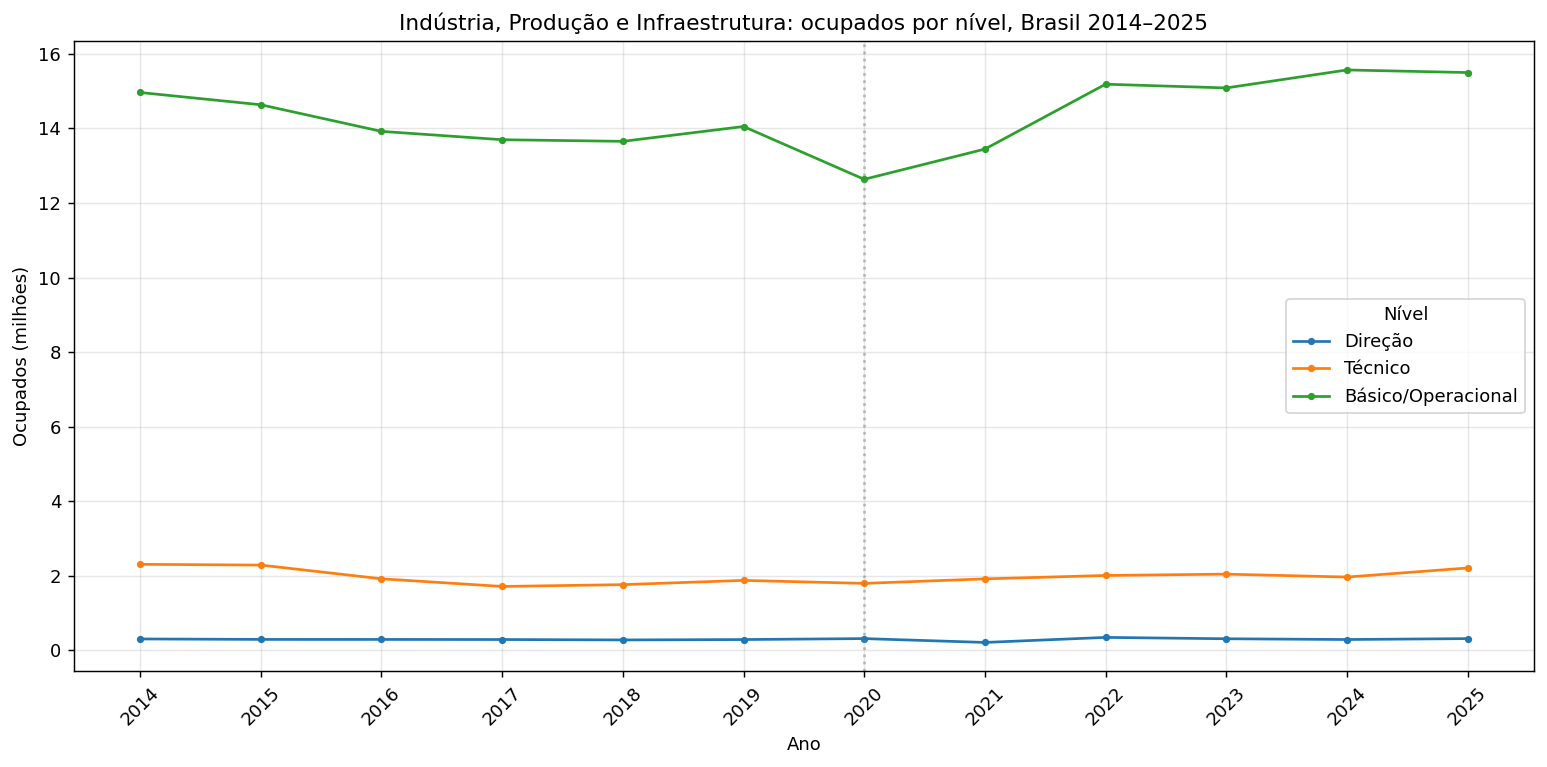

In [ ]:
ind = ocup[ocup["ancora"] == "Indústria, Produção e Infraestrutura"]

tab_ind = (
    ind.groupby(["Ano", "nivel"], observed=True)["V1032"].sum()
    .unstack("nivel") / 1e6
)
tab_ind.index = tab_ind.index.astype(int)
tab_ind = tab_ind.sort_index()

ordem = ["Direção", "Especialista", "Técnico", "Básico/Operacional"]
tab_ind = tab_ind[[c for c in ordem if c in tab_ind.columns]]
print(tab_ind.round(2))

plt.figure(figsize=(12, 6))
for nivel in tab_ind.columns:
    plt.plot(tab_ind.index, tab_ind[nivel], marker="o", markersize=3, label=nivel)
plt.title("Indústria, Produção e Infraestrutura: ocupados por nível, Brasil 2014–2025")
plt.ylabel("Ocupados (milhões)")
plt.xlabel("Ano")
plt.xticks(tab_ind.index, rotation=45)
plt.axvline(2020, color="grey", linestyle=":", alpha=0.5)
plt.legend(title="Nível")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

A recomposição horizontal está confirmada — mas a história que os dados contam é mais interessante que a minha aposta (confecção nem aparece no top 8; o movimento real é outro):
O Brasil industrial está trocando "fazer" por "manter". Olhe o padrão das altas: mecânicos e reparadores de veículos (+0,38), instaladores e reparadores de TIC (+0,23), mecânicos de máquinas agrícolas e industriais (+0,18). Três das maiores altas são manutenção e reparação — enquanto as quedas se concentram em quem fabrica: operadores de máquinas-ferramentas, chapistas e caldeireiros, montadores de equipamentos eletrônicos, técnicos em eletrônica. É a assinatura ocupacional da desindustrialização: o país fabrica menos (a produção migra para importados), mas o estoque de capital — frota de veículos, máquinas agrícolas, infraestrutura de telecom — continua aí, envelhecendo e exigindo gente para consertar. Para a projeção, isso é ouro: manutenção é justamente o segmento industrial menos automatizável (trabalho não-repetitivo, diagnóstico, ambiente não-controlado), então a resiliência dessa fatia é defensável no cenário tecnológico.
Na construção, mecanização com troca de nomes. Pedreiros: -0,83 mi, de longe a maior queda da âncora — mais elementares da construção (-0,31). Do outro lado: operadores de máquinas de movimentação de terras (+0,17) e "outros trabalhadores qualificados da construção n.c.a." (+0,20). O canteiro trocou massa manual por máquina e por especializações novas que a classificação empurra para o residual.
Dois alertas de mensuração para a tese:

A maior alta de todas é um residual: "Trabalhadores elementares da indústria de transformação n.c.a." (+0,50). Categoria guarda-chuva crescendo tanto sugere des-especialização real, informalização, ou simplesmente entrevistadores alocando ali o que não sabem classificar. Trate com cautela interpretativa — residuais que explodem merecem uma frase de ressalva, não uma narrativa.
O NaN nos controladores de instalações químicas significa que a família não aparece na amostra em um dos anos-ponta — famílias pequenas somem da PNAD por flutuação amostral. Regra prática para o nível família: só interprete trajetórias de famílias com presença contínua e massa razoável; para as miúdas, trabalhe no nível da âncora ou do subgrupo.
Um item para sua checagem de consistência: "Técnicos em operações de TIC" (3511) aparecendo dentro da Indústria indica que sua revisão manual o moveu de Ciência e Inovação para cá (no crosswalk que gerei, o subgrupo 351 inteiro estava em C&I). Pode ser uma escolha deliberada sua (TIC como infraestrutura), e é defensável — só confira se os irmãos dele (3512, 3513, 3514) ficaram do mesmo lado da fronteira, senão a divisão fica arbitrária dentro do mesmo subgrupo.

Com isso o contraste da tese está completo e documentado: recomposição vertical na Administração (níveis trocando de peso), horizontal na Indústria (total estável, conteúdo trocando de fabricação para manutenção). Belo par de resultados descritivos.

In [ ]:
ind_fam = (
    ind.groupby(["Ano", "nome_familia"], observed=True)["V1032"].sum()
    .unstack("nome_familia") / 1e6
)
ind_fam.index = ind_fam.index.astype(int)
ind_fam = ind_fam.sort_index()

delta = (ind_fam.loc[2025] - ind_fam.loc[2014]).sort_values()
print("Maiores quedas 2014–2025:")
print(delta.head(8).round(2))
print("\nMaiores altas 2014–2025:")
print(delta.tail(8).round(2))

Maiores quedas 2014–2025:
nome_familia
Pedreiros                                                                      -0.83
Trabalhadores elementares da construção de edifícios                           -0.31
Reguladores e operadores de máquinas-ferramentas                               -0.11
Técnicos em eletrônica                                                         -0.09
Eletrotécnicos                                                                 -0.09
Chapistas e caldeireiros                                                       -0.08
Montadores de equipamentos elétricos e eletrônicos                             -0.08
Técnicos em ciências físicas e da engenharia não classificados anteriormente   -0.08
dtype: float64

Maiores altas 2014–2025:
nome_familia
Operadores de máquinas de movimentação de terras e afins                                       0.17
Mecânicos e reparadores de máquinas agrícolas e industriais                                    0.18
Outros trabalhadores qualif

#### Ciência e Inovação: crescimento puxado por software

1. Só Direção e Especialista — e agora entendi sua revisão manual. O mistério do "Técnicos em operações de TIC" aparecendo na Indústria se resolveu: você implementou o que estava no seu documento de âncoras ("Todos de nível superior" para Ciência e Inovação) e moveu os técnicos (subgrupos 311, 351...) para fora. É uma escolha coerente com o critério da Mariana — STEM como ocupações de nível superior — e o gráfico confirma que foi aplicada. Retiro meu alerta anterior: não é inconsistência, é design. Só exige a mesma frase de documentação da Indústria: "a âncora C&I não possui níveis Técnico e Básico por construção; o trabalho técnico de apoio a TIC e engenharia é capturado em Indústria, Produção e Infraestrutura". E uma consequência interpretativa: quando sua projeção mostrar C&I crescendo, é crescimento da elite qualificada do sistema de inovação — a base técnica dele está contabilizada em outra âncora.
2. A replicação do achado da Mariana funcionou. Analistas de sistemas (+0,17) e desenvolvedores de software (+0,17) somam +0,34 mi — mais que todas as engenharias juntas (+0,08 civis, +0,05 eletricistas, +0,04 n.c.a. ≈ +0,17). Tecnologia crescendo o dobro da engenharia, agora numa base que inclui PJs e informais — o padrão da RAIS não era artefato do emprego formal. E note a aceleração: metade do crescimento da década aconteceu em 2021–2025 (1,17 → 1,69), a inflexão pós-pandemia/trabalho remoto visível a olho nu.
3. As "quedas" são zero — essa âncora só cresce. A maior queda da década é -0,01. Nenhuma família STEM encolheu de verdade; até as engenharias tradicionais andaram de lado ou subiram levemente. Contraste completo com a Indústria (onde famílias inteiras perderam centenas de milhares) e com a Direção da Administração.
Uma ressalva de mensuração que aqui é obrigatória: os NaN em físicos e meteorologistas denunciam o limite da PNAD nessa âncora — famílias com poucas dezenas de milhares de pessoas somem da amostra em alguns anos. Todos esses deltas são pequenos em absoluto (±0,2 mi), então no nível família o ruído amostral é proporcionalmente grande. Regra para a tese: análises de C&I no nível da âncora ou do subgrupo (software vs engenharia vs ciências) são sólidas; no nível família, só as grandes (2511, 2512, 2142).
O retrato descritivo das três âncoras-chave está completo: Administração (recomposição vertical), Indústria (recomposição horizontal, de fabricar para manter), C&I (crescimento puro, puxado por software). Isso é um capítulo descritivo praticamente estruturado.

nivel  Direção  Especialista
Ano                         
2014      0.09          1.07
2015      0.09          1.07
2016      0.10          1.04
2017      0.10          1.09
2018      0.13          1.13
2019      0.13          1.22
2020      0.11          1.24
2021      0.14          1.37
2022      0.15          1.66
2023      0.15          1.75
2024      0.13          1.90
2025      0.16          1.94


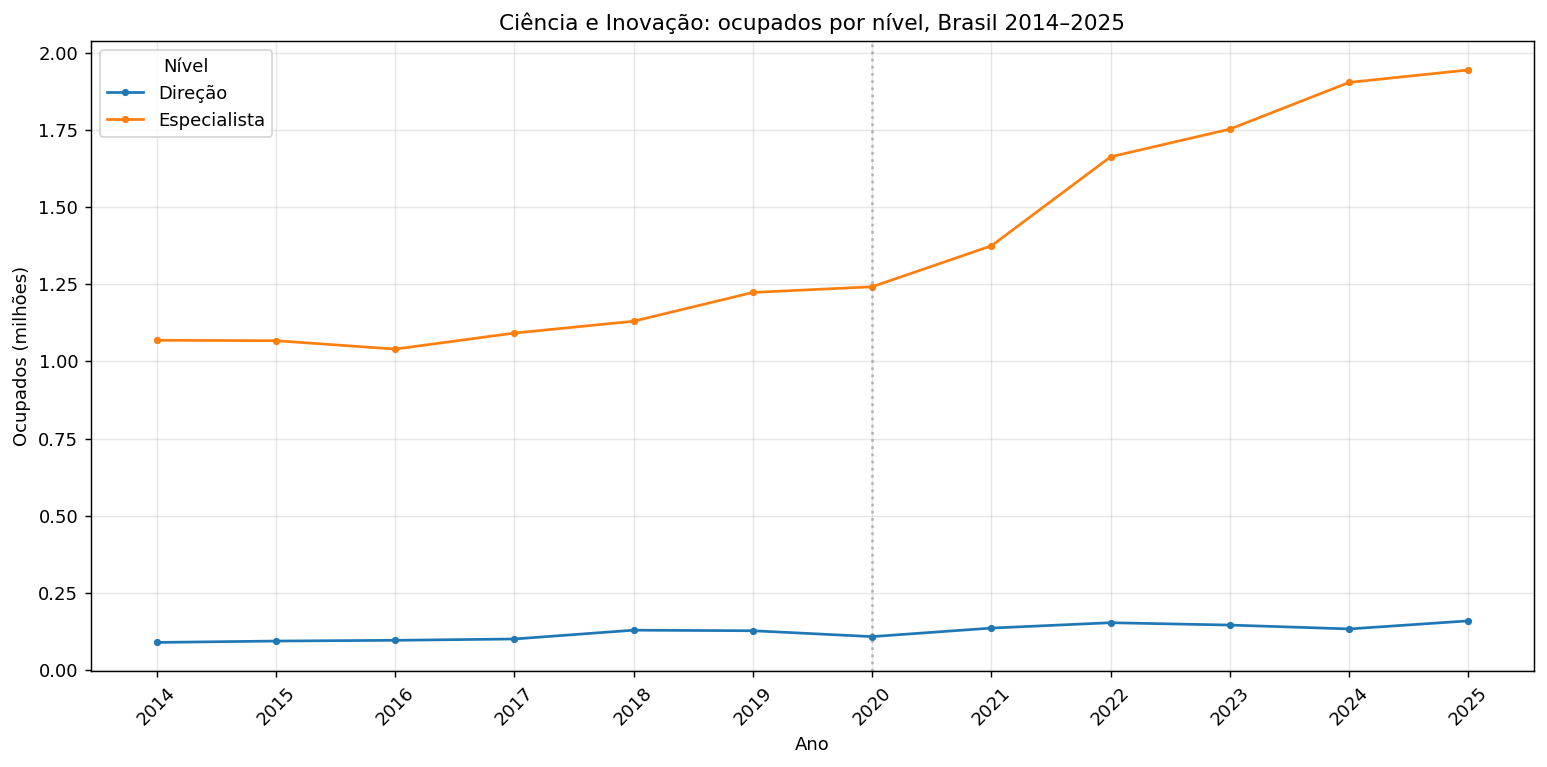

In [ ]:
ci = ocup[ocup["ancora"] == "Ciência e Inovação"]

tab_ci = (
    ci.groupby(["Ano", "nivel"], observed=True)["V1032"].sum()
    .unstack("nivel") / 1e6
)
tab_ci.index = tab_ci.index.astype(int)
tab_ci = tab_ci.sort_index()

ordem = ["Direção", "Especialista", "Técnico", "Básico/Operacional"]
tab_ci = tab_ci[[c for c in ordem if c in tab_ci.columns]]
print(tab_ci.round(2))

plt.figure(figsize=(12, 6))
for nivel in tab_ci.columns:
    plt.plot(tab_ci.index, tab_ci[nivel], marker="o", markersize=3, label=nivel)
plt.title("Ciência e Inovação: ocupados por nível, Brasil 2014–2025")
plt.ylabel("Ocupados (milhões)")
plt.xlabel("Ano")
plt.xticks(tab_ci.index, rotation=45)
plt.axvline(2020, color="grey", linestyle=":", alpha=0.5)
plt.legend(title="Nível")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
ci_fam = (
    ci.groupby(["Ano", "nome_familia"], observed=True)["V1032"].sum()
    .unstack("nome_familia") / 1e6
)
ci_fam.index = ci_fam.index.astype(int)
ci_fam = ci_fam.sort_index()

delta_ci = (ci_fam.loc[2025] - ci_fam.loc[2014]).sort_values()
print("Maiores quedas 2014–2025:")
print(delta_ci.head(6).round(2))
print("\nMaiores altas 2014–2025:")
print(delta_ci.tail(8).round(2))

Maiores quedas 2014–2025:
nome_familia
Dirigentes de pesquisa e desenvolvimento                    -0.01
Engenheiros em telecomunicações                             -0.00
Engenheiros de meio ambiente                                -0.00
Desenvolvedores de páginas de internet (web) e multimídia    0.00
Engenheiros de minas, metalúrgicos e afins                   0.00
Cartógrafos e agrimensores                                   0.00
dtype: float64

Maiores altas 2014–2025:
nome_familia
Engenheiros eletricistas                                             0.05
Dirigentes de serviços de tecnologia da informação e comunicações    0.08
Engenheiros civis                                                    0.08
Arquitetos de edificações                                            0.08
Analistas de sistemas                                                0.17
Desenvolvedores de programas e aplicativos (software)                0.17
Físicos e astrônomos                                               

#### Cuidados: da criada à cuidadora

Primeiro, a checagem do crosswalk: há famílias nessa lista que, no arquivo que eu gerei, estavam em Saúde — "Profissionais de nível médio de enfermagem" (3221, a maior alta: +0,54!), "Técnicos e assistentes fisioterapeutas", "Trabalhadores comunitários da saúde", "Profissionais de nível médio de partos" — e "Educadores para necessidades especiais", que estava em Educação. Sua revisão manual as moveu para Cuidados. Presumo que foi deliberado, e tem respaldo teórico sólido (Guimarães & Pinheiro incluem auxiliares de enfermagem no setor de cuidados — é cuidado direto ao corpo). Mas note a consequência estrutural: você criou um corte por nível dentro da mesma profissão — a enfermeira de nível superior (2221) ficou em Saúde e a técnica de enfermagem (3221) veio para Cuidados. É defensável ("o cuidado direto e contínuo é o trabalho do nível técnico; o diagnóstico e a gestão clínica, do superior"), mas precisa estar escrito na metodologia com todas as letras, senão parece erro. E confirme que foi intencional — se não foi, é a hora de corrigir, porque 1,5+ milhão de pessoas estão nessa fronteira.
Agora, a substituição confirmada — "da criada para a cuidadora": domésticos em geral -0,73 mi de um lado; do outro, cuidados a domicílio +0,39, ajudantes de professores +0,45, pré-escolar +0,36, cuidadores de crianças +0,17. O núcleo do cuidado manteve o tamanho (Básico: 6,49 → 6,63), mas trocou de natureza — de vínculo doméstico difuso para ocupações de cuidado nomeadas e especializadas. É a profissionalização do cuidado acontecendo dentro dos seus dados.
A nuance que eu não previ: cuidados pessoais em instituições caiu (-0,17) enquanto a domicílio disparou (+0,39). O envelhecimento brasileiro está sendo respondido pelo modelo de home care — a cuidadora vai à casa do idoso — e não pela institucionalização (ILPIs). Coerente com a renda média das famílias, com a aversão cultural ao asilo e com o custo institucional. Para a projeção, isso importa: o driver demográfico (80+ crescendo ~4% a.a.) empurra a família 5322 especificamente, e um eventual cenário de política pública (PNC financiando serviços institucionais) deslocaria o equilíbrio 5321×5322 — você tem os dois botões separados na sua matriz.
O V de 2020 conta a precariedade: Básico caiu 21% num ano (6,63 → 5,25 — 1,4 milhão de mulheres, na esmagadora maioria, perderam ocupação de uma vez), a queda mais violenta de todas as âncoras que olhamos. Recuperou o patamar em 2022 — mas com a composição já trocada: quem voltou não foi a mensalista, foi a cuidadora.
E a Direção em ~0,01–0,02 é um achado em si: o cuidado brasileiro praticamente não tem camada gerencial — é provisão domiciliar e informal, não infraestrutura institucional com gestão. A "economia do cuidado" existe como massa de trabalho, não como setor organizado. (O NaN em dirigentes de bem-estar social é a mesma flutuação amostral de sempre em família minúscula.)
Quarteto descritivo completo: Administração (vertical), Indústria (horizontal, fabricar→manter), C&I (crescimento puro via software), Cuidados (substituição interna: criada→cuidadora, instituição→domicílio). Cada âncora com sua dinâmica própria — a melhor justificativa possível para projetá-las separadamente, que é a premissa do seu projeto.

nivel  Direção  Especialista  Técnico  Básico/Operacional
Ano                                                      
2014      0.01          1.34     1.09                6.49
2015      0.01          1.36     1.36                6.65
2016      0.01          1.48     1.49                6.51
2017      0.01          1.48     1.44                6.57
2018      0.02          1.62     1.49                6.56
2019      0.02          1.62     1.55                6.63
2020      0.01          1.62     1.68                5.25
2021      0.02          1.64     1.63                5.50
2022      0.03          1.98     1.70                6.56
2023      0.01          2.07     1.72                6.73
2024      0.02          2.18     1.80                6.78
2025      0.01          2.41     1.77                6.63


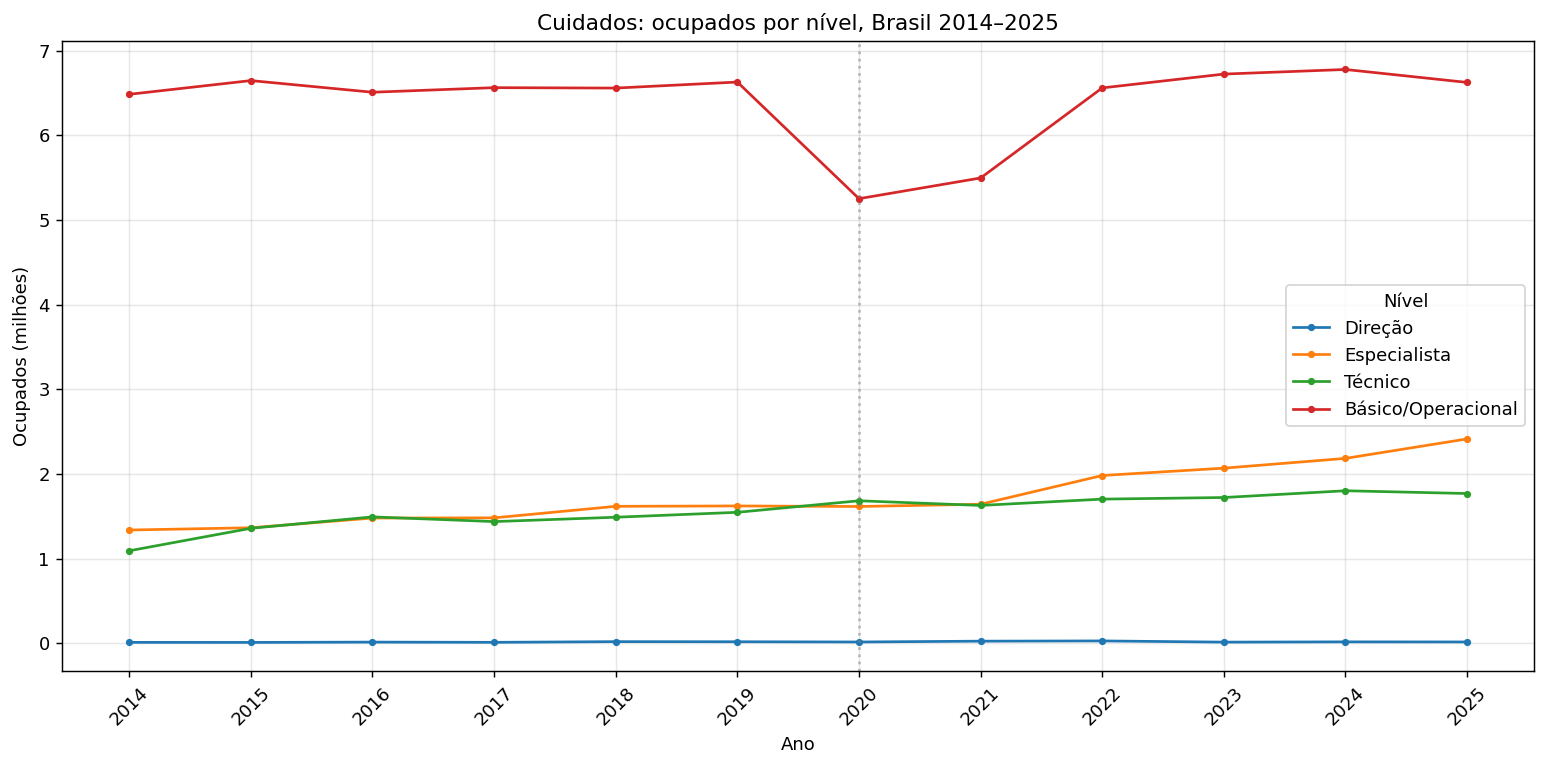

In [ ]:
cui = ocup[ocup["ancora"] == "Cuidados"]

tab_cui = (
    cui.groupby(["Ano", "nivel"], observed=True)["V1032"].sum()
    .unstack("nivel") / 1e6
)
tab_cui.index = tab_cui.index.astype(int)
tab_cui = tab_cui.sort_index()

ordem = ["Direção", "Especialista", "Técnico", "Básico/Operacional"]
tab_cui = tab_cui[[c for c in ordem if c in tab_cui.columns]]
print(tab_cui.round(2))

plt.figure(figsize=(12, 6))
for nivel in tab_cui.columns:
    plt.plot(tab_cui.index, tab_cui[nivel], marker="o", markersize=3, label=nivel)
plt.title("Cuidados: ocupados por nível, Brasil 2014–2025")
plt.ylabel("Ocupados (milhões)")
plt.xlabel("Ano")
plt.xticks(tab_cui.index, rotation=45)
plt.axvline(2020, color="grey", linestyle=":", alpha=0.5)
plt.legend(title="Nível")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
cui_fam = (
    cui.groupby(["Ano", "nome_familia"], observed=True)["V1032"].sum()
    .unstack("nome_familia") / 1e6
)
cui_fam.index = cui_fam.index.astype(int)
cui_fam = cui_fam.sort_index()

delta_cui = (cui_fam.loc[2025] - cui_fam.loc[2014]).sort_values()
print(delta_cui.round(2))

nome_familia
Trabalhadores dos serviços domésticos em geral                                             -0.73
Trabalhadores de cuidados pessoais em instituições                                         -0.17
Assistentes sociais                                                                        -0.03
Profissionais da medicina tradicional e alternativa                                        -0.00
Dirigentes de serviços de cuidado a pessoas idosas                                          0.00
Dirigentes de serviços de cuidados infantis                                                 0.00
Profissionais de nível médio de partos                                                      0.00
Acompanhantes e criados particulares                                                        0.00
Educadores para necessidades especiais                                                      0.01
Trabalhadores de cuidados pessoais nos serviços de saúde não classificados anteriormente    0.01
Governantas e mor

### 2.7 Auditoria CNAE dos casos de fronteira (dupla ancoragem)

Vamos pensar as ancoras. Ancorar em duas possíveis categorias. Por exemplo, enfermeira em saúde e cuidado. Veterinário em agro e saúde.
Vamos beber na CNAE-domiciliar

In [ ]:
print(ocup["V4013"].dtype)
print(ocup["V4013"].dropna().unique()[:15])
print("Códigos distintos:", ocup["V4013"].nunique())

object
['49040' '85013' '82009' '84012' '86001' '35010' '45010' '71000' '48090'
 '48080' '85012' '84014' '32001' '85011' '84016']
Códigos distintos: 223


Esse resultado é um espelho revelador — mas antes de interpretar, repare quem está na lista: quase só Administração e Indústria (níveis Direção, Especialista, Técnico e apoio administrativo), e nenhum dos nossos suspeitos de fronteira. E isso faz todo sentido quando você percebe o que a lista mede.
A dispersão setorial dessas famílias não é ambiguidade — é a natureza delas. Especialistas em RH (2423, a campeã: setor dominante com só 11,6% da massa), analistas de gestão (2421), dirigentes financeiros e de RH (1211, 1212), escriturários, secretárias, supervisores industriais: são as ocupações transversais por definição — toda empresa de todo setor tem RH, contabilidade, gerência, escritório. Elas se espalham por dezenas de CNAEs porque servem à economia inteira, não porque estejam mal classificadas. Para elas, a âncora ocupacional (o que fazem: gestão) está mais correta que qualquer alocação setorial — a regra condicional aqui seria um desastre: fragmentaria a Administração em 20 pedaços setoriais sem ganho analítico nenhum.
Isso, aliás, tem valor direto para a projeção: essas famílias são as que não têm driver setorial próprio — a demanda por elas é derivada da atividade agregada ("overhead" da economia). Na sua matriz de duas vias, elas são o caso puro da via de taxas/tendências: nem driver demográfico, nem setor específico. A lista acabou de identificá-las empiricamente.

In [ ]:
# Seção CNAE (2 primeiros dígitos) e a matriz âncora x seção
ocup["cnae_secao"] = ocup["V4013"].astype(str).str.zfill(5).str[:2]

matriz = (
    ocup[ocup["Ano"].astype(int) == 2025]
    .groupby(["ancora", "cnae_secao"], observed=True)["V1032"].sum()
    .unstack("cnae_secao").fillna(0) / 1e6
)

# Auditoria por família: setor dominante e grau de concentração
aud = (
    ocup[ocup["Ano"].astype(int) == 2025]
    .groupby(["V4010", "ancora"], observed=True)["V1032"]
    .agg("sum").reset_index().rename(columns={"V1032": "total"})
)
dom = (
    ocup[ocup["Ano"].astype(int) == 2025]
    .groupby(["V4010", "cnae_secao"], observed=True)["V1032"].sum()
    .groupby("V4010").agg(setor_dominante="idxmax", massa_dominante="max")
)
dom["setor_dominante"] = dom["setor_dominante"].str[1]  # extrai a seção do tupl
aud = aud.merge(dom, on="V4010")
aud["concentracao"] = aud["massa_dominante"] / aud["total"]

# As famílias mais "espalhadas" entre setores = candidatas a regra condicional ou tag
print(aud.sort_values("concentracao").head(20))

    V4010                                ancora          total  \
90   2423                Administração e Gestão  264438.356072   
231  4415                Administração e Gestão   62016.153666   
136  3122  Indústria, Produção e Infraestrutura  272656.283156   
205  3521                 Humanidades e Cultura  119969.193463   
43   2141                    Ciência e Inovação   51104.534321   
88   2421                Administração e Gestão  572887.857421   
11   1212                Administração e Gestão  143941.790296   
10   1211                Administração e Gestão  117464.953140   
350  7543            Comércio, Serviços e Lazer  205623.564908   
13   1219                Administração e Gestão  643545.994032   
19   1321  Indústria, Produção e Infraestrutura  241788.127025   
128  3113  Indústria, Produção e Infraestrutura  223453.491279   
134  3119  Indústria, Produção e Infraestrutura  138414.491074   
232  4416                Administração e Gestão   60411.773125   
9    1120 

Veterinários (2250): 78,9% em clínicas veterinárias (75), só 3,4% no agro. A sua alocação da família inteira em Agropecuária está errada pelos dados — quatro em cada cinco veterinários brasileiros são economia pet urbana, não produção animal. E note: nem regra condicional se justifica (a fração agro é pequena demais, e com 596 obs em três anos, a célula "vets no agro" teria ~20 entrevistas/ano — puro ruído). Recomendação: mover 2250 inteiro para Comércio, Serviços e Lazer, com tag secundária saude_animal, e documentar com esse número (é o tipo de correção empírica que enriquece a metodologia: "a alocação inicial foi revista após auditoria CNAE"). O técnico (3240) confirma no mesmo sentido — 64% em clínicas — e já está em Comércio/Serviços: mantém. A consequência honesta: a Agropecuária da sua tese fica sem veterinários, porque os veterinários do Brasil real não estão nela.
Engenheiros civis (2142): o único caso genuinamente bimodal — 40% em serviços de engenharia (71), 35% na construção somada (41+42+43). Mas olhe o que a bimodalidade significa: os dois lados são o mesmo sistema produtivo (o escritório que projeta e a obra que executa), e a fronteira entre eles é organizacional (terceirização), não funcional. Dividir a família entre C&I e Indústria faria a âncora depender de como as empresas se organizam — engenheiro na construtora vs o mesmo engenheiro PJ da construtora. Mantém inteiro em C&I (sua decisão original, agora com evidência), e a distribuição 71/41 vira o peso do driver setorial: a projeção da família 2142 responde ao ciclo do investimento em construção, e você sabe com que intensidade.
Agrônomos (2132): o caso mais disperso da lista (35,8% em serviços profissionais, 21,6% no agro, 17,8% engenharia, 17,8% setor público) — e isso dissolve a dúvida da fronteira que eu tinha flagado: o agrônomo brasileiro não está na fazenda; está na consultoria, na assistência técnica, no Estado (EMATER, fiscalização). É um profissional de serviços técnicos ao agro, não um trabalhador agropecuário. Fica em C&I, tag agro, encerrado.
Técnicos de TIC (3511): 49,6% no setor de TI (62) — concentração razoável no setor-espelho da ocupação. Sua realocação manual para Indústria/Infraestrutura fica a sua escolha (é defensável como "infraestrutura digital"), mas os dados não pedem divisão nenhuma.
Economistas (2631): transversal clássico (17,8% financeiro, 14,1% Estado, 12,7% seguros, espalhado) — como os RH e gestores da lista anterior. Fica em Administração, sem regra, sem tag. E com 135 obs em três anos, qualquer divisão seria estatisticamente irresponsável.
O balanço metodológico é elegante: zero regras condicionais. A auditoria CNAE resolveu todas as fronteiras por realocação simples (vets), confirmação (engenheiros, agrônomos, economistas) ou tag. Seu sistema continua limpo — cada família numa âncora, definida só pela ocupação — e a V4013 entra como lente (complexos setoriais) e como driver (pesos setoriais na projeção), não como complicador do crosswalk.

Veterinário: serviço com tag saúde (Conselho Nacional de Saúde (Resolução CNS 287/1998), a própria COD coloca a família 2250 dentro do subgrupo dos profissionais da saúde (22x), e a perspectiva de "Saúde Única" (One Health) trata saúde humana, animal e ambiental como um sistema só. Se a sua lente "saúde" significa profissões de formação e regulação sanitária, a veterinária pertence a ela.)

In [ ]:
candidatas = {"2250": "Veterinários", "3240": "Téc. veterinários",
              "2142": "Eng. civis", "2132": "Agrônomos",
              "3511": "Téc. operações TIC", "2631": "Economistas"}

for fam, nome in candidatas.items():
    sub = ocup[(ocup["V4010"] == fam) & (ocup["Ano"].astype(int) >= 2023)]
    if len(sub) == 0:
        print(f"\n{nome} ({fam}): não está na base (checar âncora atual)"); continue
    d = sub.groupby("cnae_secao", observed=True)["V1032"].sum().sort_values(ascending=False)
    d = (d / d.sum() * 100).head(5)
    print(f"\n=== {nome} ({fam}) | amostra 23-25: {len(sub)} obs ===")
    print(d.round(1))


=== Veterinários (2250) | amostra 23-25: 596 obs ===
cnae_secao
75    78.9
84     7.9
01     3.4
48     3.3
10     2.4
Name: V1032, dtype: float64

=== Téc. veterinários (3240) | amostra 23-25: 107 obs ===
cnae_secao
75    64.1
01    18.3
84     5.8
94     3.6
72     3.2
Name: V1032, dtype: float64

=== Eng. civis (2142) | amostra 23-25: 1309 obs ===
cnae_secao
71    40.3
41    26.9
84     9.3
42     6.9
43     1.7
Name: V1032, dtype: float64

=== Agrônomos (2132) | amostra 23-25: 335 obs ===
cnae_secao
74    35.8
01    21.6
71    17.8
84    17.8
72     4.9
Name: V1032, dtype: float64

=== Téc. operações TIC (3511) | amostra 23-25: 859 obs ===
cnae_secao
62    49.6
64     5.4
84     4.7
48     4.5
85     3.8
Name: V1032, dtype: float64

=== Economistas (2631) | amostra 23-25: 135 obs ===
cnae_secao
64    17.8
84    14.1
66    12.7
70     8.4
85     4.9
Name: V1032, dtype: float64


#### Condutores e entregadores de aplicativo

Vamos pensar nos condutores de aplicativos
A dimensão "consumo urbano/plataforma" pode virar lente: circulo = servico_urbano ou, melhor ainda, a plataformização entra pela VD4009 (conta-própria) cruzada com essas famílias — o recorte "trabalhadores de aplicativo" = (8321 ∪ 8322 ∪ 9621) ∩ conta-própria é reconstituível a qualquer momento sem tocar na âncora.
8322 (motoristas de automóveis/táxi): 67,2% na seção 49 (transporte terrestre), mais 4,5% em correio/entrega (53) e 5,6% em armazenamento/transporte (48) — somando, ~77% do trabalho dessa família acontece dentro do setor de transporte. Caso encerrado: a âncora Transporte e Logística está empiricamente correta, e os 7,1% na administração pública (motoristas oficiais) e 2,9% na saúde (ambulâncias, transporte sanitário) são exatamente o tipo de dispersão que os complexos setoriais capturam sem mexer na âncora.

O setor dominante dos motociclistas brasileiros hoje não é "transporte de passageiros" — é entrega. A família 8321 virou, majoritariamente, a força de trabalho do delivery. Isso confirma com dados a história do boom logístico que o gráfico das âncoras insinuava.

In [ ]:
for fam in ["8321", "8322"]:
    sub = ocup[(ocup["V4010"] == fam) & (ocup["Ano"].astype(int) >= 2023)]
    d = sub.groupby("cnae_secao", observed=True)["V1032"].sum().sort_values(ascending=False)
    print(f"\n{fam} | {len(sub)} obs:"); print((d/d.sum()*100).head(5).round(1))


8321 | 4901 obs:
cnae_secao
53    35.2
49    30.8
48    16.9
56    11.3
45     2.0
Name: V1032, dtype: float64

8322 | 9773 obs:
cnae_secao
49    67.2
84     7.1
48     5.6
53     4.5
86     2.9
Name: V1032, dtype: float64


## Parte 3 — Checkpoint, matriz de projeção e projeções do IBGE

> **Nota.** As células das Partes 3 e 4 não estavam nos arquivos `.ipynb`; foram recuperadas da versão impressa (PDF) do notebook de clusters. As **saídas em texto foram preservadas**; os **gráficos** reaparecem quando a célula for rodada.

### 3.1 Carregar e validar o crosswalk final

In [ ]:
#Bloco 1 — Carregar e validar a tabela final
ancoras = pd.read_csv(pasta + "familias_COD_ancoras_final.csv", sep=";", dtype={"cod_familia": str})
ancoras["cod_familia"] = ancoras["cod_familia"].astype(str).str.zfill(4)

# Validação estrutural
print("Linhas:", len(ancoras))                                   # esperado: 434
print("Duplicadas:", ancoras["cod_familia"].duplicated().sum())  # esperado: 0
print("Sem âncora:", ancoras["ancora"].isna().sum())             # esperado: 0
print("\nÂncoras:"); print(ancoras["ancora"].value_counts())
print("\nCírculos:"); print(ancoras["circulo"].value_counts(dropna=False))
print("\nNíveis:"); print(ancoras["nivel"].value_counts())

Linhas: 434
Duplicadas: 0
Sem âncora: 0

Âncoras:
ancora
Indústria, Produção e Infraestrutura    102
Comércio, Serviços e Lazer               87
Administração e Gestão                   66
Ciência e Inovação                       32
Humanidades e Cultura                    26
Agropecuária e Pesca                     25
Cuidados                                 25
Saúde                                    24
Transporte e Logística                   23
Educação                                 11
Segurança e Defesa                       10
carve-out, sem projeção                   3
Name: count, dtype: int64

Círculos:
circulo
NaN          408
industria     11
saude         11
educacao       3
agro           1
Name: count, dtype: int64

Níveis:
nivel
Básico/Operacional    224
Especialista           92
Técnico                84
Direção                34
Name: count, dtype: int64


> **Sobre a coluna `circulo`.** Não são os círculos do cuidado de Guimarães e Pinheiro: é a **tag de dupla ancoragem**, que marca o domínio de origem de famílias alocadas em outra âncora (ex.: técnica de enfermagem em Cuidados com tag `saude`; engenheiro civil em C&I com tag `industria`).

### 3.2 Rebuild da base e checkpoint definitivo

In [ ]:
#Bloco 2 — Rebuild e o checkpoint definitivo
df = pd.read_parquet(pasta + "pnadc_2014_2025.parquet")

df = df.merge(
    ancoras[["cod_familia", "ancora", "nivel", "decisor_publico_por_definicao", "circulo"]],
    left_on="V4010", right_on="cod_familia", how="left"
)

publico_labels = ["Empregado no setor público com carteira de trabalho assinada",
                  "Empregado no setor público sem carteira de trabalho assinada",
                  "Militar e servidor estatutário"]
df["setor_publico"] = df["VD4009"].isin(publico_labels).map({True: "Público", False: "Privado"})

ocup = df[df["VD4002"] == "Pessoas ocupadas"].copy()
ocup["cnae_secao"] = ocup["V4013"].astype(str).str.zfill(5).str[:2]

cols = ["Ano", "UF", "V1032", "V2007", "V2009", "V2010", "VD3004", "VD4009",
        "ancora", "nivel", "circulo", "setor_publico", "V4010", "V4013", "cnae_secao"]
ocup[[c for c in cols if c in ocup.columns]].to_parquet(pasta + "checkpoint_base_v2.parquet")
print("✓ checkpoint v2 salvo | ocupados:", len(ocup))

✓ checkpoint v2 salvo | ocupados: 2137544


### 3.3 Validação de conteúdo

In [ ]:
#Bloco 3 — Validação de conteúdo
tab_ancora = (
    ocup.groupby(["Ano", "ancora"], observed=True)["V1032"].sum()
    .unstack("ancora") / 1e6
)
tab_ancora.index = tab_ancora.index.astype(int)
tab_ancora = tab_ancora.sort_index()
print(tab_ancora.loc[2025].sort_values(ascending=False).round(2))
print("\nSoma 2025:", tab_ancora.loc[2025].sum().round(1), "mi (esperado ~103,0)")

ancora
Comércio, Serviços e Lazer              31.43
Indústria, Produção e Infraestrutura    18.03
Administração e Gestão                  15.51
Cuidados                                10.82
Agropecuária e Pesca                     7.75
Transporte e Logística                   7.47
Educação                                 3.61
Saúde                                    2.37
Segurança e Defesa                       2.33
Ciência e Inovação                       2.10
Humanidades e Cultura                    1.25
carve-out, sem projeção                  0.30
Name: 2025, dtype: float64

Soma 2025: 103.0 mi (esperado ~103,0)


### 3.4 A matriz da projeção: perfil das âncoras em 2025

**Leitura dos resultados.** A âncora mais envelhecida do Brasil não é a Agropecuária — é a Educação (43,5 anos). E isso configura o que eu chamaria de tripla pressão: força de trabalho mais velha do país (onda de aposentadorias nos próximos 15 anos) + demanda encolhendo (coortes escolares em queda, já projetadas pelo IBGE) + 65,9% pública (dependente de decisão fiscal para repor ou não quem sai). As três forças apontando na mesma direção fazem da Educação a âncora de trajetória mais previsível — e mais politicamente sensível — da projeção: o Estado vai poder encolher o corpo docente sem demitir ninguém, só não repondo aposentadorias.

A segregação de gênero é o fato estrutural do sistema: de 6,2% de mulheres no Transporte a 89,2% nos Cuidados — quinze vezes de diferença. Cuidados (89% feminino, idade 42) combina as duas pressões: a demanda vai explodir (80+) enquanto a oferta atual envelhece junto — e a pergunta "quem cuidará?" vira quantitativa. C&I com 27,3% de mulheres e a mais jovem (38,6) quantifica na base o problema da Mariana.

A coluna `pct_publico` esconde o achado mais contraintuitivo: a Saúde brasileira é só 26,7% pública — apesar do SUS (o SUS financia muito, mas emprega via OSs, terceirizadas e conveniados, que a PNAD registra como emprego privado). Para os cenários fiscais, isso muda o alvo: congelamento de concursos morde forte na Educação (66%) e Segurança (50%), mas pouco na Saúde. O carve-out fechou com validação de livro-texto: 31,3 anos e 100,0% público.

In [ ]:
#Bloco 4 — A matriz da projeção
bins = [14, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 200]
labels = ["14-19","20-24","25-29","30-34","35-39","40-44","45-49","50-54","55-59","60-64","65+"]
ocup["faixa_etaria"] = pd.cut(ocup["V2009"], bins=bins, labels=labels, right=False)

resumo = (
    ocup[ocup["Ano"].astype(int) == 2025]
    .groupby("ancora", observed=True)
    .apply(lambda g: pd.Series({
        "ocupados_mi": g["V1032"].sum() / 1e6,
        "idade_media": (g["V2009"] * g["V1032"]).sum() / g["V1032"].sum(),
        "pct_mulheres": g.loc[g["V2007"] == "Mulher", "V1032"].sum() / g["V1032"].sum() * 100,
        "pct_publico": g.loc[g["setor_publico"] == "Público", "V1032"].sum() / g["V1032"].sum() * 100,
    }))
    .sort_values("idade_media", ascending=False)
)
print(resumo.round(1))

                                      ocupados_mi  idade_media  pct_mulheres  \
ancora                                                                         
Educação                                      3.6         43.5          69.8   
Agropecuária e Pesca                          7.7         43.0          18.3   
Segurança e Defesa                            2.3         42.7          12.1   
Cuidados                                     10.8         42.3          89.2   
Transporte e Logística                        7.5         40.4           6.2   
Saúde                                         2.4         40.0          59.1   
Comércio, Serviços e Lazer                   31.4         39.4          56.0   
Indústria, Produção e Infraestrutura         18.0         39.3           9.3   
Ciência e Inovação                            2.1         38.6          27.3   
Humanidades e Cultura                         1.2         37.3          37.6   
Administração e Gestão                  

### 3.5 Projeções populacionais do IBGE (Revisão 2024)

In [ ]:
import requests
url = "https://ftp.ibge.gov.br/Projecao_da_Populacao/Projecao_da_Populacao_2024/projecoes_2024_tab1_idade_simples.xlsx"
destino = pasta + "projecoes_2024_tab1_idade_simples.xlsx"
r = requests.get(url, timeout=300)   # timeout generoso: o servidor do IBGE é lento
r.raise_for_status()
with open(destino, "wb") as f:
    f.write(r.content)
print(f"✓ {len(r.content)/1e6:.1f} MB salvos em {destino}")

✓ 4.6 MB salvos em /content/drive/MyDrive/Colab Notebooks/projecoes_2024_tab1_idade_simples.xlsx


In [ ]:
import openpyxl
arq = pasta + "projecoes_2024_tab1_idade_simples.xlsx"
wb = openpyxl.load_workbook(arq, read_only=True)
print("Abas:", wb.sheetnames)

# Espiar as primeiras linhas para ver a estrutura
ws = wb[wb.sheetnames[0]]
for i, row in enumerate(ws.iter_rows(values_only=True)):
    print(i, row[:8])
    if i > 12:
        break

Abas: ['1) POP_IDADE SIMPLES']
0 ('Projeções das Populações, Revisão 2024', None, None, None, None, None, None, None)
1 ('Brasil, Grandes Regiões e Unidades da Federação', None, None, None, None, None, None, None)
2 ('População por sexo e idade simples - 2000/2070', None, None, None, None, None, None, None)
3 (None, None, None, None, None, None, None, None)
4 (None, None, None, None, None, 'ANO', None, None)
5 ('IDADE', 'SEXO', 'CÓD.', 'SIGLA', 'LOCAL', 2000, '=F6+1', '=G6+1')
6 (0, 'Ambos', 0, 'BR', 'Brasil', 3423475, 3347313, 3274356)
7 (1, 'Ambos', 0, 'BR', 'Brasil', 3450022, 3406966, 3332612)
8 (2, 'Ambos', 0, 'BR', 'Brasil', 3461038, 3444450, 3401900)
9 (3, 'Ambos', 0, 'BR', 'Brasil', 3469109, 3458052, 3441638)
10 (4, 'Ambos', 0, 'BR', 'Brasil', 3477903, 3466901, 3455987)
11 (5, 'Ambos', 0, 'BR', 'Brasil', 3482383, 3476170, 3465223)
12 (6, 'Ambos', 0, 'BR', 'Brasil', 3483305, 3480986, 3474808)
13 (7, 'Ambos', 0, 'BR', 'Brasil', 3481824, 3481990, 3479710)


In [ ]:
# 1) Ler pulando as 5 linhas de título
raw = pd.read_excel(arq, sheet_name=0, skiprows=5)

# 2) Renomear colunas: 5 de identificação + anos
n_anos = raw.shape[1] - 5
anos = list(range(2000, 2000 + n_anos))
raw.columns = ["idade", "sexo", "cod", "sigla", "local"] + anos
print("Última coluna de ano:", anos[-1])   # esperado: 2070
print("Valores de sexo:", raw["sexo"].dropna().unique())
print("Locais (primeiros):", raw["local"].dropna().unique()[:5])

# 3) Só Brasil, só Homens/Mulheres
pop = raw[(raw["sigla"] == "BR") & (raw["sexo"].isin(["Homens", "Mulheres"]))].copy()
print("Linhas após filtro:", len(pop))    # esperado: ~182

# 4) Formato longo
pop_longo = pop.melt(id_vars=["idade", "sexo"], value_vars=anos,
                     var_name="ano", value_name="populacao")

# 5) Harmonizar rótulos de sexo com a PNAD
pop_longo["sexo"] = pop_longo["sexo"].map({"Homens": "Homem", "Mulheres": "Mulher"})

# 6) Validação cruzada com a soma dos pesos da PNAD
pop_2025 = pop_longo[pop_longo["ano"] == 2025]["populacao"].sum() / 1e6
print(f"População IBGE 2025: {pop_2025:.1f} mi (PNAD via V1032 deu ~212,7)")

# 7) Salvar
pop_longo.to_parquet(pasta + "projecoes_ibge_longo.parquet")
print("✓ projecoes_ibge_longo.parquet salvo")

Última coluna de ano: 2070
Valores de sexo: ['Ambos' 'Homens' 'Mulheres']
Locais (primeiros): ['Brasil' 'Norte' 'Nordeste' 'Sudeste' 'Sul']
Linhas após filtro: 182
População IBGE 2025: 213.4 mi (PNAD via V1032 deu ~212,7)
✓ projecoes_ibge_longo.parquet salvo


## Parte 4 — Modelo de projeção: Camadas 1, 2 e 3 (modelo CBAE/ENCE)

**A espinha dorsal: duas engrenagens que se multiplicam**

$$Ocupados(\text{âncora}, t) = \underbrace{Pop^{IBGE}(\text{sexo}, \text{idade}, t)}_{\text{engrenagem 1: demografia}} \times \underbrace{taxa(\text{âncora} \mid \text{sexo}, \text{idade}, t)}_{\text{engrenagem 2: comportamento}}$$

A engrenagem 1 é exógena: as Projeções Populacionais do IBGE dão, para cada ano até 2070, quantos brasileiros existirão em cada célula sexo × idade. A engrenagem 2 é a tese: a propensão de cada célula a estar ocupada em cada âncora. Em 2025 ela é observada na PNAD; de 2026 a 2040 é projetada.

| Camada | O que faz |
|---|---|
| **1 — Inércia demográfica** | taxas congeladas em 2025; só a pirâmide etária se move |
| **2 — Tendências comportamentais** | taxas ganham trajetória (tendência amortecida e, onde vencer no backtest, ML) |
| **3 — Cenários** | choques nomeados: IA, Política Nacional de Cuidados, fiscal, plataformização |

**Duas vias.** Via A (Cuidados, Saúde, Educação): demanda demográfica por razões de cobertura. Via B (demais): taxas de oferta. **Tribunal:** todo componente só entra no cenário-base se vencer comparação fora da amostra (estimado em 2014–2019, julgado em 2022–2025).

### 4.1 Camada 1 — inércia demográfica

**Leitura dos resultados.**
1. *A era do crescimento da força de trabalho acabou.* 102,7 mi em 2025 → pico de ~105,5 em 2036–37 → declínio já em 2040. A demografia sozinha oferece +2,6 milhões em 15 anos, contra +11 milhões nos 11 anos observados.
2. *C&I estagnada em 2,10–2,12:* todo crescimento futuro terá que vir de taxas subindo, não de mais corpos.
3. *O paradoxo da Agropecuária:* a âncora mais envelhecida é a que mais cresce (+8,4%) porque suas taxas se concentram nas faixas 45+ que a pirâmide infla — efeito de coorte confundido com efeito de idade. É o argumento formal para a Camada 2.
4. *O que a Camada 1 não vê:* só move a oferta; demanda (alunos, idosos 80+) entra pela Via A; IA, plataformas e PNC entram na Camada 3.

Taxa máxima (sanidade, deve ser < 1): 0.263
Células com taxa nula/NaN: 0
ancora  Administração e Gestão  Agropecuária e Pesca  Ciência e Inovação  \
ano                                                                        
2025                     15.51                  7.75                2.10   
2026                     15.54                  7.81                2.11   
2027                     15.55                  7.86                2.12   
2028                     15.56                  7.92                2.12   
2029                     15.57                  7.98                2.12   
2030                     15.57                  8.03                2.12   
2031                     15.57                  8.08                2.12   
2032                     15.57                  8.14                2.12   
2033                     15.57                  8.18                2.12   
2034                     15.56                  8.23                2.12   
2035           

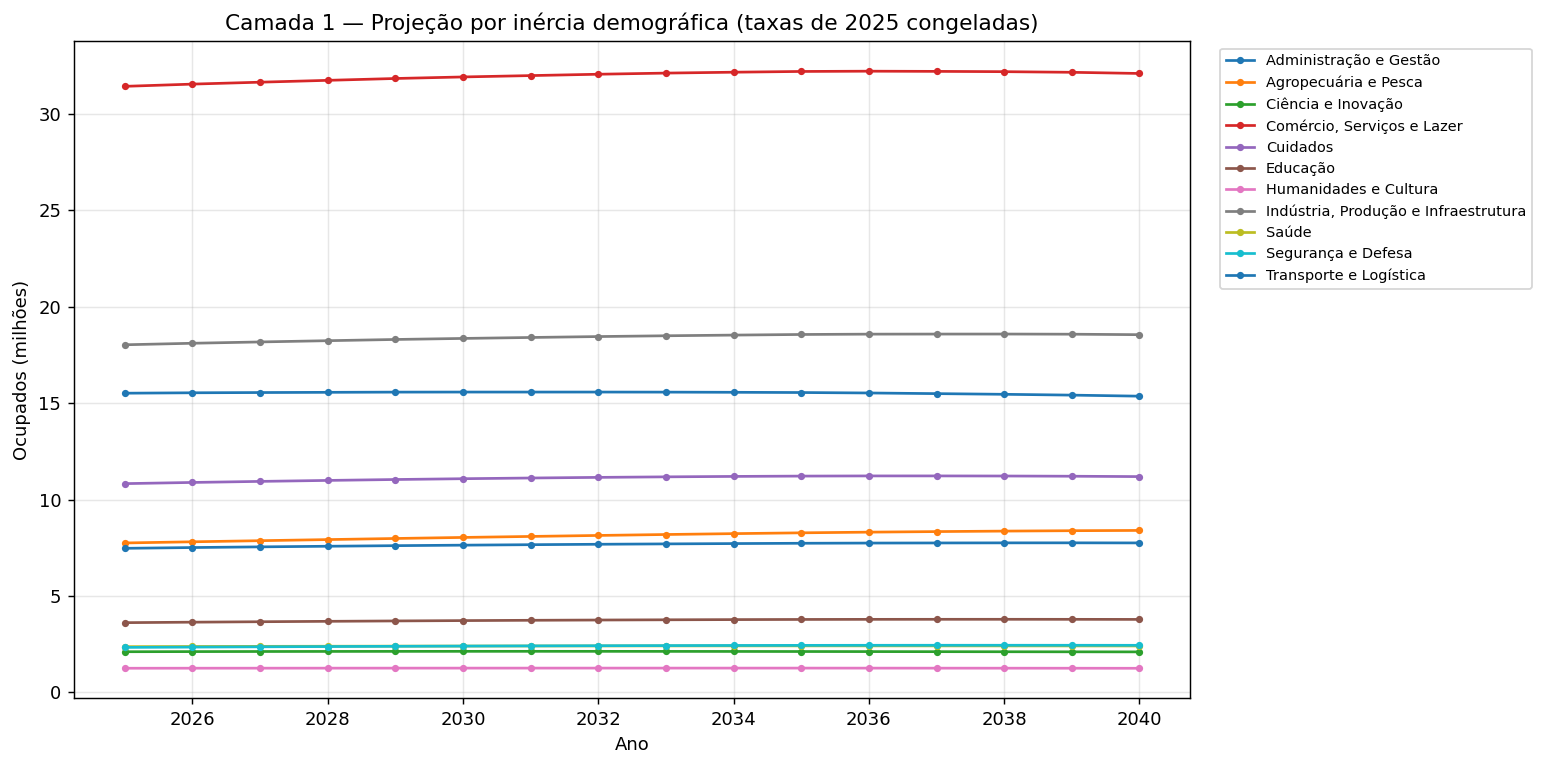

In [ ]:
# ===== CAMADA 1: projeção por inércia demográfica, 2026-2040 =====
# 1) Faixas etárias no pop_longo (mesmos bins da PNAD)
pop_longo = pd.read_parquet(pasta + "projecoes_ibge_longo.parquet")
pop_longo["idade"] = pop_longo["idade"].astype(str).str.replace("+", "", regex=False).astype(int)
bins = [14, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 200]
labels = ["14-19","20-24","25-29","30-34","35-39","40-44","45-49","50-54","55-59","60-64","65+"]
pop_longo["faixa_etaria"] = pd.cut(pop_longo["idade"], bins=bins, labels=labels, right=False)
pop_cel = (
    pop_longo.dropna(subset=["faixa_etaria"])
    .groupby(["ano", "sexo", "faixa_etaria"], observed=True)["populacao"].sum()
    .rename("pop")
)

# 2) Numerador: ocupados 2025 por âncora x sexo x faixa (PNAD)
ocup["faixa_etaria"] = pd.cut(ocup["V2009"], bins=bins, labels=labels, right=False)
num = (
    ocup[ocup["Ano"].astype(int) == 2025]
    .groupby(["ancora", "V2007", "faixa_etaria"], observed=True)["V1032"].sum()
    .rename("ocupados").reset_index()
    .rename(columns={"V2007": "sexo"})
)

# 3) Taxas 2025 = ocupados / população da célula
den = pop_cel.loc[2025].reset_index()
taxas = num.merge(den, on=["sexo", "faixa_etaria"], how="left")
taxas["taxa"] = taxas["ocupados"] / taxas["pop"]
print("Taxa máxima (sanidade, deve ser < 1):", round(taxas["taxa"].max(), 3))
print("Células com taxa nula/NaN:", taxas["taxa"].isna().sum())

# 4) Projetar: taxa congelada x população de cada ano futuro
proj = []
for ano in range(2025, 2041):
    p = pop_cel.loc[ano].reset_index()
    m = taxas[["ancora", "sexo", "faixa_etaria", "taxa"]].merge(p, on=["sexo", "faixa_etaria"])
    m["ocupados"] = m["taxa"] * m["pop"]
    m["ano"] = ano
    proj.append(m)
proj = pd.concat(proj)

tab_proj = (
    proj[~proj["ancora"].str.contains("carve", case=False)]   # carve-out fora
    .groupby(["ano", "ancora"], observed=True)["ocupados"].sum()
    .unstack("ancora") / 1e6
)
print(tab_proj.round(2))

# 5) Gráfico
plt.figure(figsize=(12, 6))
for a in tab_proj.columns:
    plt.plot(tab_proj.index, tab_proj[a], marker="o", markersize=3, label=a)
plt.title("Camada 1 — Projeção por inércia demográfica (taxas de 2025 congeladas)")
plt.ylabel("Ocupados (milhões)"); plt.xlabel("Ano")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
# Salvar o resultado da Camada 1
tab_proj.to_parquet(pasta + "camada1_projecao.parquet")

### 4.2 Backtest da Camada 1 ("relógio atrasado 11 anos")

Congela as taxas de 2014, projeta 2015–2025 com as populações do IBGE e compara com o observado. Quantifica quanto da década a demografia pura explica, âncora por âncora.

In [ ]:
# ===== BACKTEST DA CAMADA 1: taxas de 2014, projetando 2015-2025 =====
ocup["V2007"] = ocup["V2007"].astype(str).replace({"Masculino": "Homem", "Feminino": "Mulher"})
print(ocup["V2007"].value_counts())   # deve mostrar SÓ Homem e Mulher

# 1) Taxas de 2014
num14 = (
    ocup[ocup["Ano"].astype(int) == 2014]
    .groupby(["ancora", "V2007", "faixa_etaria"], observed=True)["V1032"].sum()
    .rename("ocupados").reset_index()
    .rename(columns={"V2007": "sexo"})
)
den14 = pop_cel.loc[2014].reset_index()
taxas14 = num14.merge(den14, on=["sexo", "faixa_etaria"], how="left")
taxas14["taxa"] = taxas14["ocupados"] / taxas14["pop"]
print("Sanidade — taxa máx:", round(taxas14["taxa"].max(), 3), "| NaN:", taxas14["taxa"].isna().sum())

# 2) "Projetar" 2015-2025 com as taxas congeladas de 2014
bt = []
for ano in range(2014, 2026):
    p = pop_cel.loc[ano].reset_index()
    m = taxas14[["ancora", "sexo", "faixa_etaria", "taxa"]].merge(p, on=["sexo", "faixa_etaria"])
    m["ocupados"] = m["taxa"] * m["pop"]
    m["ano"] = ano
    bt.append(m)
bt = pd.concat(bt)

tab_bt = (
    bt[~bt["ancora"].str.contains("carve", case=False)]
    .groupby(["ano", "ancora"], observed=True)["ocupados"].sum()
    .unstack("ancora") / 1e6
)

V2007
Homem     1243790
Mulher     893754
Name: count, dtype: int64
Sanidade — taxa máx: 0.282 | NaN: 0


                                      obs_2025  proj_2025  erro_abs_mi  \
ancora                                                                   
Ciência e Inovação                        2.10       1.26        -0.84   
Saúde                                     2.37       1.48        -0.89   
Humanidades e Cultura                     1.25       1.08        -0.17   
Transporte e Logística                    7.47       6.64        -0.83   
Comércio, Serviços e Lazer               31.43      28.32        -3.11   
Cuidados                                 10.82       9.78        -1.04   
Administração e Gestão                   15.51      14.39        -1.12   
Segurança e Defesa                        2.33       2.33         0.00   
Educação                                  3.61       3.72         0.11   
Indústria, Produção e Infraestrutura     18.03      18.88         0.85   
Agropecuária e Pesca                      7.75      10.31         2.56   

                                     

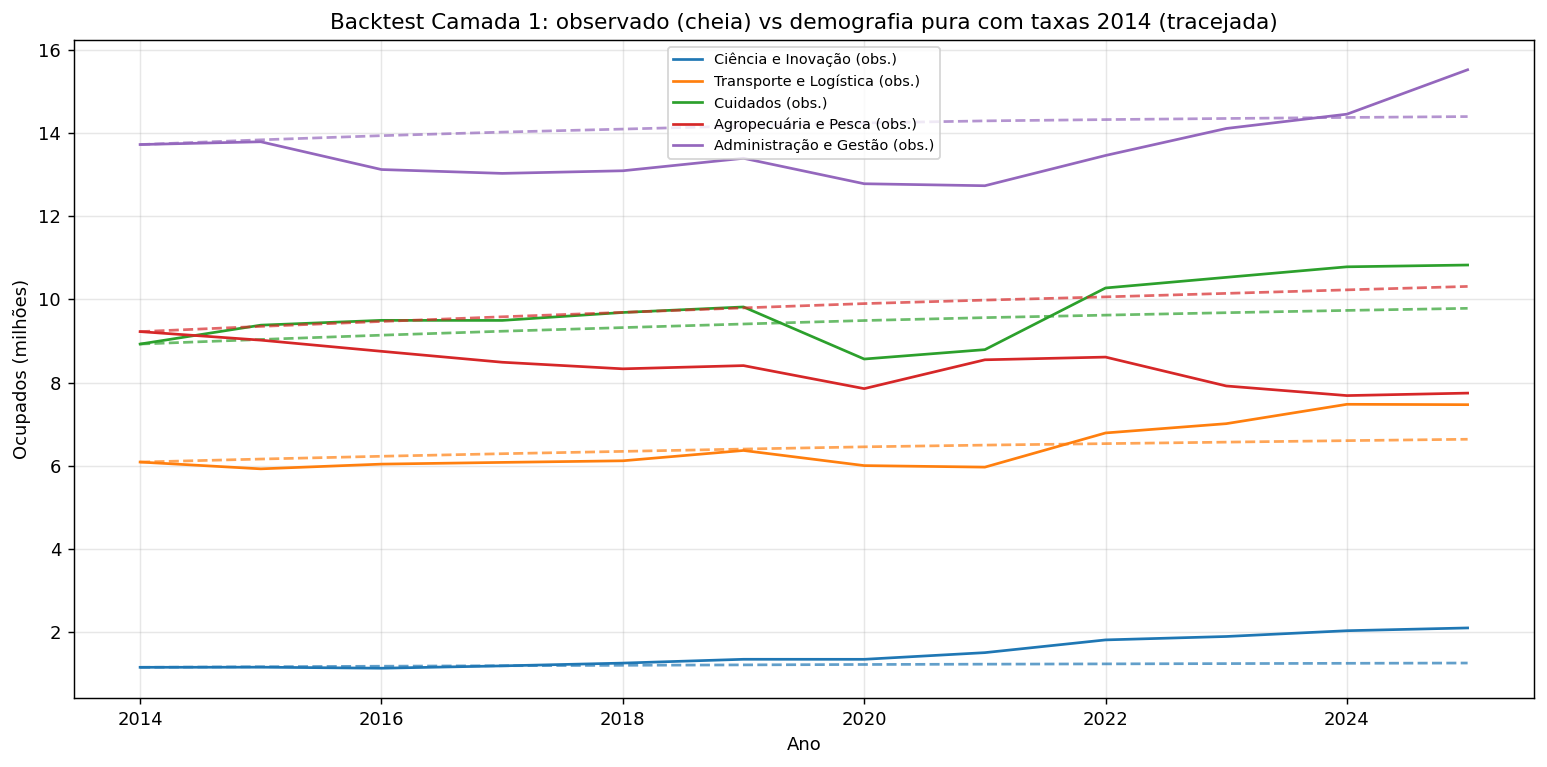

In [ ]:
# 3) Confronto com o observado
obs = tab_ancora.drop(columns=[c for c in tab_ancora.columns if "carve" in c.lower()])
comp = pd.DataFrame({"obs_2025": obs.loc[2025], "proj_2025": tab_bt.loc[2025]})
comp["erro_abs_mi"] = comp["proj_2025"] - comp["obs_2025"]
comp["erro_pct"] = comp["erro_abs_mi"] / comp["obs_2025"] * 100
comp = comp.sort_values("erro_pct")
print(comp.round(2))

# 4) Gráfico: observado (cheia) vs backtest (tracejada)
destaque = ["Ciência e Inovação", "Transporte e Logística", "Cuidados",
            "Agropecuária e Pesca", "Administração e Gestão"]
plt.figure(figsize=(12, 6))
for i, a in enumerate(destaque):
    cor = plt.cm.tab10(i)
    plt.plot(obs.index, obs[a], color=cor, label=f"{a} (obs.)")
    plt.plot(tab_bt.index, tab_bt[a], color=cor, linestyle="--", alpha=0.7)
plt.title("Backtest Camada 1: observado (cheia) vs demografia pura com taxas 2014 (tracejada)")
plt.ylabel("Ocupados (milhões)"); plt.xlabel("Ano")
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

**Leitura dos resultados — tipologia de projetabilidade.**
- *Demográficas* (erro < 5%): Segurança (0,19%), Educação (+2,95%), Indústria (+4,74%) — "a demografia sozinha explica mais de 95% do nível de 2025".
- *Tendenciais*: C&I (−40%) e Saúde (−37,5%) — escolha ocupacional das coortes jovens e expansão da saúde privada, que nenhuma pirâmide prevê.
- *Contra-demográfica*: Agropecuária (+33%) — a demografia mandava crescer para 10,3 mi; a realidade entregou 7,75. Prova quantitativa do paradoxo da Camada 1.
- *Mistas* (−7% a −13%): Administração, Cuidados, Comércio, Transporte, Humanidades. Parte do erro é comum (~4,4% de aumento da participação, sobretudo feminina) e parte é específica (shares migrando).

### 4.3 Camada 2 — taxas com tendência amortecida

Duas decisões documentáveis: excluir 2020–21 do ajuste (choque, não tendência) e amortecer a extrapolação (decaimento geométrico δ, família Cedefop).

In [ ]:
#Bloco 1 — painel de taxas e tendência por célula
num_all = (
    ocup.groupby(["Ano", "ancora", "V2007", "faixa_etaria"], observed=True)["V1032"].sum()
    .rename("ocupados").reset_index()
    .rename(columns={"Ano": "ano", "V2007": "sexo"})
)
num_all["ano"] = num_all["ano"].astype(int)
den_all = pop_cel.reset_index()
den_all = den_all[den_all["ano"].between(2014, 2025)]
panel = num_all.merge(den_all, on=["ano", "sexo", "faixa_etaria"], how="left")
panel["taxa"] = panel["ocupados"] / panel["pop"]

# Tendência (inclinação OLS) por célula, excluindo 2020-21
fit = panel[~panel["ano"].isin([2020, 2021])]

def inclinacao(g):
    if len(g) < 5:
        return np.nan
    return np.polyfit(g["ano"], g["taxa"], 1)[0]

slopes = (
    fit.groupby(["ancora", "sexo", "faixa_etaria"], observed=True)
    .apply(inclinacao).rename("slope").reset_index()
)
slopes["slope"] = slopes["slope"].fillna(0)   # célula rala = sem tendência
print("Células:", len(slopes), "| slope médio:", round(slopes["slope"].mean(), 5))

Células: 263 | slope médio: 0.00026


In [ ]:
#Bloco 2 — projeção 2026–2040 com tendência amortecida
DELTA = 0.9   # amortecimento (sensibilidade testada com 0.85 na Parte 5)

base = taxas[["ancora", "sexo", "faixa_etaria", "taxa"]].merge(
    slopes, on=["ancora", "sexo", "faixa_etaria"], how="left")
base["slope"] = base["slope"].fillna(0)

proj2 = []
for ano in range(2025, 2041):
    h = ano - 2025
    fator = sum(DELTA**k for k in range(1, h + 1))   # soma amortecida
    m = base.copy()
    m["taxa_t"] = (m["taxa"] + m["slope"] * fator).clip(lower=0)
    p = pop_cel.loc[ano].reset_index()
    m = m.merge(p, on=["sexo", "faixa_etaria"])
    m["ocupados"] = m["taxa_t"] * m["pop"]
    m["ano"] = ano
    proj2.append(m)
proj2 = pd.concat(proj2)

tab_c2 = (
    proj2[~proj2["ancora"].str.contains("carve", case=False)]
    .groupby(["ano", "ancora"], observed=True)["ocupados"].sum()
    .unstack("ancora") / 1e6
)

confronto = pd.DataFrame({
    "obs_2025": tab_ancora.loc[2025].drop([c for c in tab_ancora.columns if "carve" in c.lower()]),
    "C1_2040": tab_proj.loc[2040],
    "C2_2040": tab_c2.loc[2040],
})
confronto["dif_C2_C1"] = confronto["C2_2040"] - confronto["C1_2040"]
print(confronto.round(2).sort_values("dif_C2_C1"))
tab_c2.to_parquet(pasta + "camada2_projecao.parquet")

                                      obs_2025  C1_2040  C2_2040  dif_C2_C1
ancora                                                                     
Agropecuária e Pesca                      7.75     8.40     6.79      -1.60
Segurança e Defesa                        2.33     2.44     2.38      -0.06
Educação                                  3.61     3.78     3.92       0.14
Humanidades e Cultura                     1.25     1.25     1.40       0.15
Indústria, Produção e Infraestrutura     18.03    18.55    18.73       0.18
Administração e Gestão                   15.51    15.36    15.78       0.42
Saúde                                     2.37     2.40     2.87       0.47
Ciência e Inovação                        2.10     2.10     2.69       0.60
Transporte e Logística                    7.47     7.75     8.47       0.72
Cuidados                                 10.82    11.19    11.96       0.77
Comércio, Serviços e Lazer               31.43    32.10    34.26       2.16


### 4.4 O tribunal: a tendência melhora a previsão? (ajuste 2014–2019 → teste 2022–2025)

In [ ]:
#Bloco 3 — tribunal
fit_bt = panel[panel["ano"].between(2014, 2019)]
slopes_bt = (
    fit_bt.groupby(["ancora", "sexo", "faixa_etaria"], observed=True)
    .apply(inclinacao).rename("slope").reset_index()
)
slopes_bt["slope"] = slopes_bt["slope"].fillna(0)

base_bt = (
    panel[panel["ano"] == 2019][["ancora", "sexo", "faixa_etaria", "taxa"]]
    .merge(slopes_bt, on=["ancora", "sexo", "faixa_etaria"], how="left")
)
base_bt["slope"] = base_bt["slope"].fillna(0)

erros = []
for ano in range(2022, 2026):
    h = ano - 2019
    fator = sum(DELTA**k for k in range(1, h + 1))
    p = pop_cel.loc[ano].reset_index()
    m = base_bt.merge(p, on=["sexo", "faixa_etaria"])
    m["congelada"] = m["taxa"] * m["pop"]
    m["tendencia"] = (m["taxa"] + m["slope"] * fator).clip(lower=0) * m["pop"]
    m["ano"] = ano
    erros.append(m)
erros = pd.concat(erros)

tribunal = (
    erros.groupby(["ano", "ancora"], observed=True)[["congelada", "tendencia"]].sum() / 1e6
).join(tab_ancora.stack().rename("observado"), on=["ano", "ancora"])

mae = (
    tribunal.assign(
        erro_cong=lambda d: (d["congelada"] - d["observado"]).abs(),
        erro_tend=lambda d: (d["tendencia"] - d["observado"]).abs(),
    )
    .groupby("ancora", observed=True)[["erro_cong", "erro_tend"]].mean()
)
mae["ganho_pct"] = (1 - mae["erro_tend"] / mae["erro_cong"]) * 100
print(mae.round(3).sort_values("ganho_pct", ascending=False))

                                      erro_cong  erro_tend  ganho_pct
ancora                                                               
Agropecuária e Pesca                      0.745      0.297     60.155
Cuidados                                  0.432      0.208     51.781
Comércio, Serviços e Lazer                0.844      0.513     39.233
Saúde                                     0.446      0.294     34.013
Segurança e Defesa                        0.069      0.051     25.616
Ciência e Inovação                        0.578      0.489     15.452
Transporte e Logística                    0.604      0.603      0.162
Humanidades e Cultura                     0.169      0.178     -5.302
Educação                                  0.078      0.084     -7.926
Administração e Gestão                    0.836      1.450    -73.517
Indústria, Produção e Infraestrutura      1.058      2.689   -154.247
carve-out, sem projeção                   0.015      0.048   -214.394


**Leitura dos resultados.** Modelo híbrido com regra de seleção por âncora: tendência amortecida onde venceu (Agro, Cuidados, Comércio, Saúde, Segurança, C&I); congelamento onde perdeu ou empatou (Indústria, Administração, Transporte, Humanidades, Educação). *"O tratamento de cada âncora foi selecionado pelo desempenho preditivo no período de teste 2022–2025."* Caveat: a janela de teste é pós-pandemia; a Parte 5 move a janela e o δ para testar a robustez.

### 4.5 Camada 2 final: modelo híbrido

In [ ]:
# ===== CAMADA 2 FINAL: híbrido selecionado pelo backtest =====
usa_tendencia = ["Agropecuária e Pesca", "Cuidados", "Comércio, Serviços e Lazer",
                 "Saúde", "Segurança e Defesa", "Ciência e Inovação"]
tab_hibrido = tab_proj.copy()            # base: C1 (congelada)
for a in usa_tendencia:
    tab_hibrido[a] = tab_c2[a]           # substitui pelas tendenciais
tab_hibrido.to_parquet(pasta + "camada2_hibrido.parquet")

resumo_final = pd.DataFrame({
    "obs_2025": tab_ancora.loc[2025].drop([c for c in tab_ancora.columns if "carve" in c.lower()]),
    "hibrido_2040": tab_hibrido.loc[2040],
})
resumo_final["var_pct"] = (resumo_final["hibrido_2040"] / resumo_final["obs_2025"] - 1) * 100
resumo_final["regime"] = ["tendência" if a in usa_tendencia else "congelada" for a in resumo_final.index]
print(resumo_final.round(2).sort_values("var_pct"))
print("\nTotal 2040:", round(tab_hibrido.loc[2040].sum(), 1), "mi")

                                      obs_2025  hibrido_2040  var_pct  \
ancora                                                                  
Agropecuária e Pesca                      7.75          6.79   -12.32   
Administração e Gestão                   15.51         15.36    -0.99   
Humanidades e Cultura                     1.25          1.25    -0.16   
Segurança e Defesa                        2.33          2.38     2.10   
Indústria, Produção e Infraestrutura     18.03         18.55     2.91   
Transporte e Logística                    7.47          7.75     3.75   
Educação                                  3.61          3.78     4.68   
Comércio, Serviços e Lazer               31.43         34.26     8.99   
Cuidados                                 10.82         11.96    10.47   
Saúde                                     2.37          2.87    21.28   
Ciência e Inovação                        2.10          2.69    28.03   

                                         regime  


### 4.6 Camada 3 — motor de cenários (IA, PNC, fiscal)

In [ ]:
# ===== CAMADA 3: motor de cenários =====
o25 = ocup[ocup["Ano"].astype(int) == 2025]
frac_nivel = (
    o25.groupby(["ancora", "nivel"], observed=True)["V1032"].sum()
    / o25.groupby("ancora", observed=True)["V1032"].sum()
).rename("frac")
frac_pub = (
    o25[o25["setor_publico"] == "Público"].groupby("ancora", observed=True)["V1032"].sum()
    / o25.groupby("ancora", observed=True)["V1032"].sum()
).fillna(0)

def rampa(ano, inicio=2027, fim=2040, forma="acelerada"):
    """0 antes do início, 1 no fim; acelerada = quadrática (difusão tecnológica)."""
    if ano <= inicio:
        return 0.0
    x = min((ano - inicio) / (fim - inicio), 1.0)
    return x**2 if forma == "acelerada" else x

fb = frac_nivel.get(("Administração e Gestão", "Básico/Operacional"), 0)
cenarios = {
    "IA_moderado": [("Administração e Gestão", fb, -0.15, "acelerada"),
                    ("Comércio, Serviços e Lazer", 0.10, -0.15, "acelerada"),
                    ("Humanidades e Cultura", 0.30, -0.15, "acelerada")],
    "IA_forte":    [("Administração e Gestão", fb, -0.30, "acelerada"),
                    ("Comércio, Serviços e Lazer", 0.10, -0.30, "acelerada"),
                    ("Humanidades e Cultura", 0.30, -0.30, "acelerada")],
    "PNC_moderado": [("Cuidados", 1.0, +0.10, "linear")],
    "PNC_forte":    [("Cuidados", 1.0, +0.20, "linear")],
    "Fiscal_moderado": [(a, frac_pub[a], -0.075, "linear") for a in frac_pub.index if frac_pub[a] > 0.15],
    "Fiscal_forte":    [(a, frac_pub[a], -0.15, "linear") for a in frac_pub.index if frac_pub[a] > 0.15],
}

def aplica_cenario(tab_base, choques):
    tab = tab_base.copy()
    for ancora, frac, delta, forma in choques:
        if ancora not in tab.columns:
            continue
        for ano in tab.index:
            tab.loc[ano, ancora] *= 1 + frac * delta * rampa(ano, forma=forma)
    return tab

resultados = {"base": tab_hibrido}
for nome, choques in cenarios.items():
    resultados[nome] = aplica_cenario(tab_hibrido, choques)

sintese = pd.DataFrame({nome: t.loc[2040] for nome, t in resultados.items()})
print(sintese.round(2))
print("\nTotais 2040:", {k: round(v.loc[2040].sum(), 1) for k, v in resultados.items()})

                                       base  IA_moderado  IA_forte  \
ancora                                                               
Administração e Gestão                15.36        14.14     12.91   
Agropecuária e Pesca                   6.79         6.79      6.79   
Ciência e Inovação                     2.69         2.69      2.69   
Comércio, Serviços e Lazer            34.26        33.74     33.23   
Cuidados                              11.96        11.96     11.96   
Educação                               3.78         3.78      3.78   
Humanidades e Cultura                  1.25         1.19      1.13   
Indústria, Produção e Infraestrutura  18.55        18.55     18.55   
Saúde                                  2.87         2.87      2.87   
Segurança e Defesa                     2.38         2.38      2.38   
Transporte e Logística                 7.75         7.75      7.75   

                                      PNC_moderado  PNC_forte  \
ancora                  

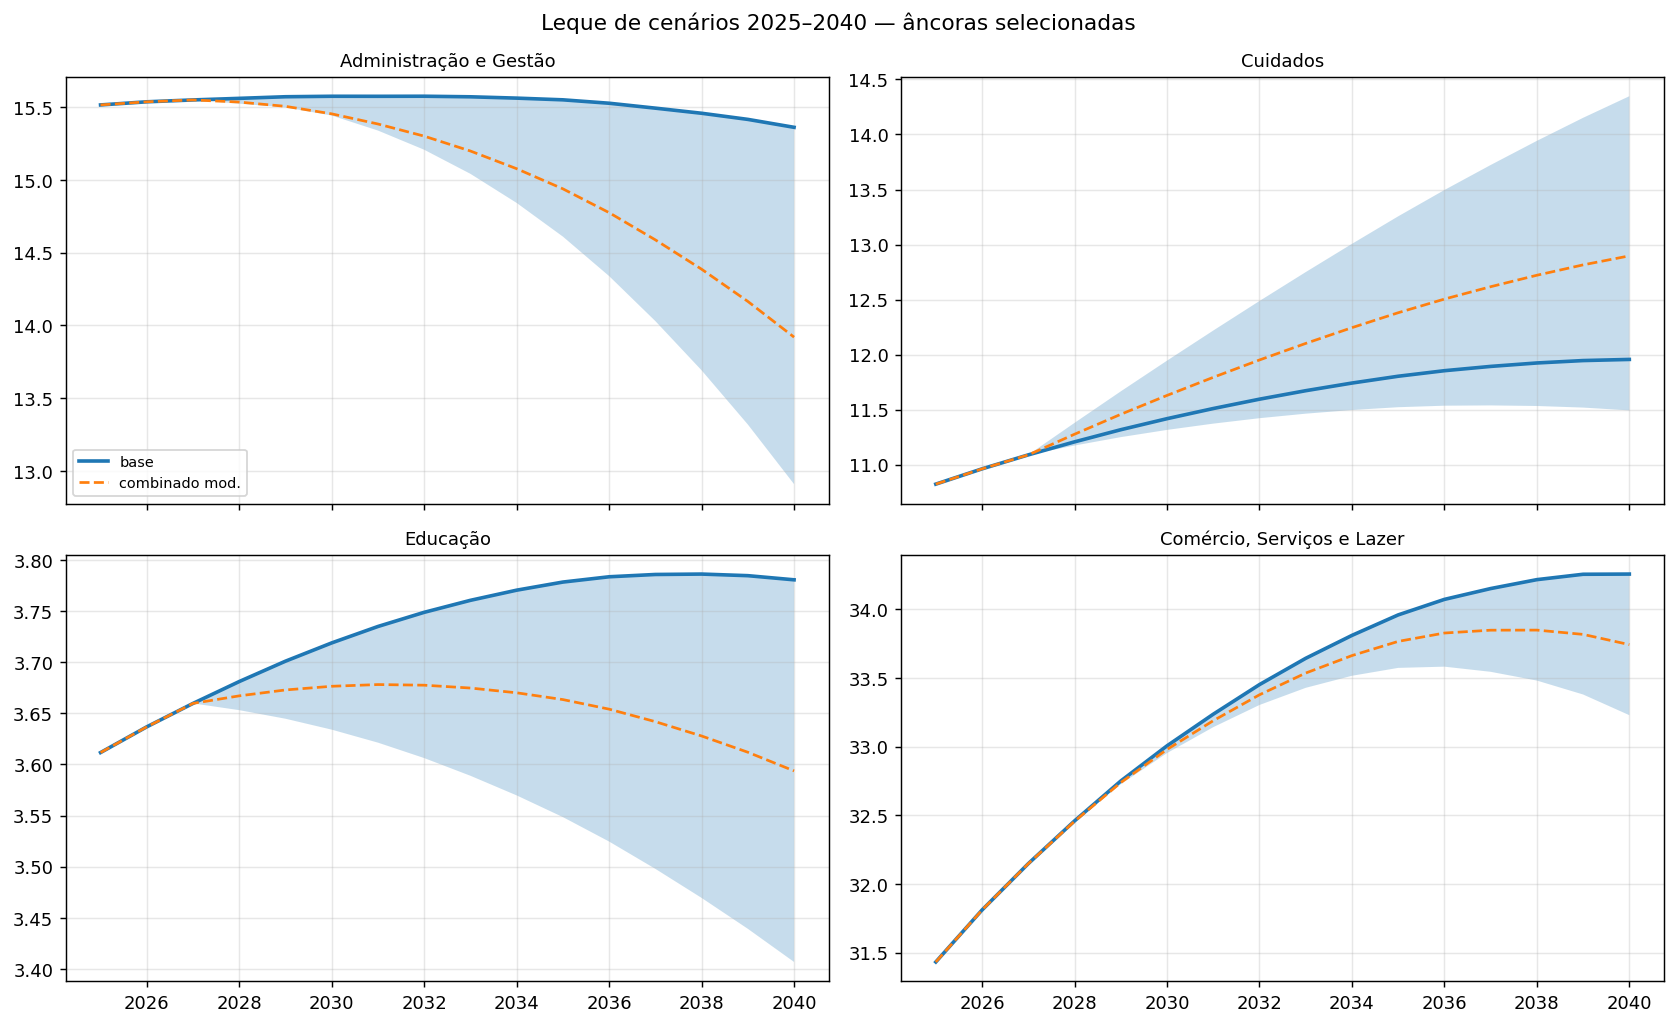

In [ ]:
# Cenário combinado moderado (todos os choques aplicados juntos, sem multiplicar em sequência)
todos = cenarios["IA_moderado"] + cenarios["PNC_moderado"] + cenarios["Fiscal_moderado"]
resultados["combinado_mod"] = aplica_cenario(tab_hibrido, todos)

# Leque: base ± envelope de todos os cenários, âncoras-chave
envelope_min = pd.concat(list(resultados.values())).groupby("ano").min()
envelope_max = pd.concat(list(resultados.values())).groupby("ano").max()

destaque = ["Administração e Gestão", "Cuidados", "Educação", "Comércio, Serviços e Lazer"]
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, a in zip(axes.flat, destaque):
    ax.fill_between(envelope_min.index, envelope_min[a], envelope_max[a], alpha=0.25)
    ax.plot(tab_hibrido.index, tab_hibrido[a], lw=2, label="base")
    ax.plot(resultados["combinado_mod"].index, resultados["combinado_mod"][a], ls="--", label="combinado mod.")
    ax.set_title(a, fontsize=10); ax.grid(alpha=0.3)
axes.flat[0].legend(fontsize=8)
fig.suptitle("Leque de cenários 2025–2040 — âncoras selecionadas")
plt.tight_layout(); plt.show()

sintese.to_parquet(pasta + "camada3_sintese_2040.parquet")

### 4.7 Via A — demanda demográfica por razões de cobertura

> **Nota.** O PDF termina no meio desta seção: a definição dos componentes está abaixo, mas o cálculo das razões de cobertura não foi impresso.

In [ ]:
# ===== VIA A: demanda demográfica por razões de cobertura =====
# 1) Populações-alvo por ano (idade simples do IBGE)
alvos = {
    "pop_0a5":  pop_longo[pop_longo["idade"].between(0, 5)],
    "pop_6a17": pop_longo[pop_longo["idade"].between(6, 17)],
    "pop_65m":  pop_longo[pop_longo["idade"] >= 65],
    "pop_80m":  pop_longo[pop_longo["idade"] >= 80],
}
pop_alvo = pd.DataFrame({k: v.groupby("ano")["populacao"].sum() for k, v in alvos.items()})
print(pop_alvo.loc[[2025, 2030, 2035, 2040]].round(0) / 1e6)   # em milhões

# 2) Componentes de demanda: âncora/grupo -> população-alvo
fam_cuid_inf = ["5311", "5312", "2342", "1341"]      # cuidado infantil + pré-escola
fam_cuid_idoso = ["5321", "5322", "1343", "5162"]    # cuidado idoso/domiciliar
o25 = ocup[ocup["Ano"].astype(int) == 2025]

def ocup25(filtro):
    return o25.loc[filtro, "V1032"].sum()

componentes = {
    # nome: (ocupados 2025, coluna do alvo)
    "Educação (6-17)":         (ocup25(o25["ancora"] == "Educação"), "pop_6a17"),
    "Cuidado infantil (0-5)":  (ocup25(o25["V4010"].isin(fam_cuid_inf)), "pop_0a5"),
    "Cuidado de idosos (80+)": (ocup25(o25["V4010"].isin(fam_cuid_idoso)), "pop_80m"),
    "Saúde (65+)":             (ocup25(o25["ancora"] == "Saúde"), "pop_65m"),
}

        pop_0a5   pop_6a17    pop_65m    pop_80m
ano                                             
2025  15.433157  34.905187  24.666300   4.956211
2030  13.967489  33.309093  29.729196   6.259435
2035  13.116958  30.429304  34.733585   7.968781
2040  12.512861  27.633542  39.575688  10.027368


## Parte 5 — Sensibilidade, aprendizado de máquina e Híbrido 2.0

Regra de seleção: cada componente (tendência, congelamento, ML) só entra no cenário-base se vencer comparação fora da amostra **em duas janelas** (J1: até 2019 → 2022–25; J2: até 2018 → 2019 e 2022–24).

### 5.1 Recarregar base e reconstruir o painel de taxas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
pasta = "/content/drive/MyDrive/Colab Notebooks/"
ocup = pd.read_parquet(pasta + "checkpoint_base_v2.parquet")
pop_longo = pd.read_parquet(pasta + "projecoes_ibge_longo.parquet")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd, numpy as np

# --- (se ainda não carregou) ---
# ocup = pd.read_parquet(pasta + "checkpoint_base_v2.parquet")
# pop_longo = pd.read_parquet(pasta + "projecoes_ibge_longo.parquet")

# 1) Faixas etárias nos dois lados
bins   = [14, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 200]
labels = ["14-19","20-24","25-29","30-34","35-39","40-44","45-49","50-54","55-59","60-64","65+"]
ocup["faixa_etaria"] = pd.cut(ocup["V2009"], bins=bins, labels=labels, right=False)

pop_longo["idade"] = pop_longo["idade"].astype(str).str.replace("+", "", regex=False).astype(int)
pop_longo["faixa_etaria"] = pd.cut(pop_longo["idade"], bins=bins, labels=labels, right=False)
pop_cel = (
    pop_longo.dropna(subset=["faixa_etaria"])
    .groupby(["ano", "sexo", "faixa_etaria"], observed=True)["populacao"].sum()
    .rename("pop")
)

# 2) tab_ancora (o observado, juiz do tribunal)
tab_ancora = (
    ocup.groupby(["Ano", "ancora"], observed=True)["V1032"].sum().unstack("ancora") / 1e6
)
tab_ancora.index = tab_ancora.index.astype(int)
tab_ancora = tab_ancora.sort_index()

# 3) O panel: taxa por célula (âncora x sexo x faixa) x ano
num_all = (
    ocup.groupby(["Ano", "ancora", "V2007", "faixa_etaria"], observed=True)["V1032"].sum()
    .rename("ocupados").reset_index()
    .rename(columns={"Ano": "ano", "V2007": "sexo"})
)
num_all["ano"] = num_all["ano"].astype(int)
den_all = pop_cel.reset_index()
den_all = den_all[den_all["ano"].between(2014, 2025)]
panel = num_all.merge(den_all, on=["ano", "sexo", "faixa_etaria"], how="left")
panel["taxa"] = panel["ocupados"] / panel["pop"]

print("panel:", panel.shape, "| NaN em taxa:", panel["taxa"].isna().sum())

panel: (3114, 7) | NaN em taxa: 520


In [ ]:
# 1) Harmonizar sexo no ocup
ocup["V2007"] = ocup["V2007"].astype(str).replace({"Masculino": "Homem", "Feminino": "Mulher"})
print(ocup["V2007"].value_counts())   # só Homem e Mulher

# 2) Re-salvar o checkpoint JÁ harmonizado — para nunca mais
ocup.to_parquet(pasta + "checkpoint_base_v2.parquet")
print("✓ checkpoint v2 re-salvo com sexo harmonizado")

# 3) Reconstruir o panel (só a parte que depende do sexo)
num_all = (
    ocup.groupby(["Ano", "ancora", "V2007", "faixa_etaria"], observed=True)["V1032"].sum()
    .rename("ocupados").reset_index()
    .rename(columns={"Ano": "ano", "V2007": "sexo"})
)
num_all["ano"] = num_all["ano"].astype(int)
panel = num_all.merge(den_all, on=["ano", "sexo", "faixa_etaria"], how="left")
panel["taxa"] = panel["ocupados"] / panel["pop"]
print("NaN em taxa:", panel["taxa"].isna().sum())   # esperado: 0

V2007
Homem     1243790
Mulher     893754
Name: count, dtype: int64
✓ checkpoint v2 re-salvo com sexo harmonizado
NaN em taxa: 0



# ===== J1 COMPLETA: congelamento x tendência (δ=0,85) x ML =====



In [ ]:
# ===== J1 COMPLETA: congelamento x tendência (δ=0,85) x ML =====
# Requer apenas: panel, pop_cel e tab_ancora (seção 5.1)
from sklearn.ensemble import HistGradientBoostingRegressor

DELTA_BT = 0.85
cat = ["ancora", "sexo", "faixa_etaria"]
feats = ["taxa", "taxa_lag1", "delta1", "ancora_cod", "sexo_cod", "faixa_etaria_cod"]
anos_teste = [2022, 2023, 2024, 2025]

def inclinacao(g):
    return np.polyfit(g["ano"], g["taxa"], 1)[0] if len(g) >= 5 else np.nan

# --- 1) Congelamento e tendência: ajuste 2014-2019, partida 2019 ---
fit_bt = panel[panel["ano"].between(2014, 2019)]
sl = (fit_bt.groupby(cat, observed=True).apply(inclinacao).rename("slope").reset_index())
sl["slope"] = sl["slope"].fillna(0)
b0 = panel[panel["ano"] == 2019][cat + ["taxa"]].merge(sl, on=cat, how="left")
b0["slope"] = b0["slope"].fillna(0)

linhas = []
for ano in anos_teste:
    fator = sum(DELTA_BT**k for k in range(1, ano - 2019 + 1))
    m = b0.merge(pop_cel.loc[ano].reset_index(), on=["sexo", "faixa_etaria"])
    m["congelada"] = m["taxa"] * m["pop"]
    m["tendencia"] = (m["taxa"] + m["slope"] * fator).clip(lower=0) * m["pop"]
    m["ano"] = ano
    linhas.append(m)
t_bt = pd.concat(linhas).groupby(["ano", "ancora"], observed=True)[["congelada", "tendencia"]].sum() / 1e6

# --- 2) ML: painel de transições t -> t+1 (sem a pandemia) ---
pn = panel[cat + ["ano", "taxa"]].copy()
lag = pn.assign(ano=pn["ano"] + 1).rename(columns={"taxa": "taxa_lag1"})
nxt = pn.assign(ano=pn["ano"] - 1).rename(columns={"taxa": "taxa_next"})
pn = pn.merge(lag, on=cat + ["ano"], how="left").merge(nxt, on=cat + ["ano"], how="inner")
pn["taxa_lag1"] = pn["taxa_lag1"].fillna(pn["taxa"])
pn["delta1"] = pn["taxa"] - pn["taxa_lag1"]
for c in cat:
    pn[c + "_cod"] = pn[c].astype("category").cat.codes
pn = pn[~pn["ano"].isin([2019, 2020, 2021])]

# Treino J1: transições até 2017 -> 2018; partida no estado de 2019
ml_j1 = HistGradientBoostingRegressor(max_depth=3, learning_rate=0.06, max_iter=400,
                                      l2_regularization=1.0, random_state=42)
tr = pn[pn["ano"] <= 2017]
ml_j1.fit(tr[feats], tr["taxa_next"])

estado = panel[panel["ano"] == 2019][cat + ["taxa"]].merge(
    panel[panel["ano"] == 2018][cat + ["taxa"]].rename(columns={"taxa": "taxa_lag1"}), on=cat, how="left")
estado["taxa_lag1"] = estado["taxa_lag1"].fillna(estado["taxa"])

linhas = []
for ano in range(2020, 2026):
    estado["delta1"] = estado["taxa"] - estado["taxa_lag1"]
    for c in cat:
        estado[c + "_cod"] = estado[c].astype("category").cat.codes
    prox = ml_j1.predict(estado[feats]).clip(0, 1)
    estado["taxa_lag1"] = estado["taxa"]
    estado["taxa"] = prox
    if ano in anos_teste:
        m = estado[cat + ["taxa"]].merge(pop_cel.loc[ano].reset_index(), on=["sexo", "faixa_etaria"])
        m["ml"] = m["taxa"] * m["pop"]
        m["ano"] = ano
        linhas.append(m)
t_ml = pd.concat(linhas).groupby(["ano", "ancora"], observed=True)["ml"].sum() / 1e6

# --- 3) Placar J1 ---
t = t_bt.join(t_ml).join(tab_ancora.stack().rename("observado"), on=["ano", "ancora"])
placar = (t.assign(erro_cong=lambda d: (d.congelada - d.observado).abs(),
                   erro_tend=lambda d: (d.tendencia - d.observado).abs(),
                   erro_ml=lambda d: (d.ml - d.observado).abs())
           .groupby("ancora", observed=True)[["erro_cong", "erro_tend", "erro_ml"]].mean())
placar = placar[~placar.index.str.contains("carve", case=False)]
placar["melhor"] = placar[["erro_cong", "erro_tend", "erro_ml"]].idxmin(axis=1)
print(placar.round(3))
print("\nPlacar:", placar["melhor"].value_counts().to_dict())
print("Registrado no original: {'erro_tend': 6, 'erro_ml': 3, 'erro_cong': 2}")

                                      erro_cong  erro_tend  erro_ml     melhor
ancora                                                                        
Administração e Gestão                    0.836      1.358    1.355  erro_cong
Agropecuária e Pesca                      0.745      0.204    0.432  erro_tend
Ciência e Inovação                        0.578      0.501    0.598  erro_tend
Comércio, Serviços e Lazer                0.844      0.370    0.349    erro_ml
Cuidados                                  0.432      0.240    0.500  erro_tend
Educação                                  0.078      0.081    0.062    erro_ml
Humanidades e Cultura                     0.169      0.176    0.116    erro_ml
Indústria, Produção e Infraestrutura      1.058      2.464    2.123  erro_cong
Saúde                                     0.446      0.315    0.351  erro_tend
Segurança e Defesa                        0.069      0.049    0.067  erro_tend
Transporte e Logística                    0.604     

Ótimo resultado. Três leituras:

1. Congelamento e tendência reproduziram o original exatamente. As colunas erro_cong e erro_tend batem número por número com o registrado (0,836 e 1,358 em Administração, 0,745 e 0,204 no Agro, e assim por diante). Essa parte da J1 está validada.

2. O ML reconstruído chega ao mesmo placar agregado (6 × 3 × 2), com uma troca. Continua vencendo em Educação (0,062 vs 0,057 original) e Humanidades (0,116 vs 0,105). A terceira vitória, porém, sai de Transporte e vai para Comércio, Serviços e Lazer (0,349 contra 0,370 da tendência). As margens são pequenas nos dois casos, então é o tipo de oscilação esperada numa reconstrução.

3. Isso não deve mudar o modelo final, mas quem decide é a J2. No original, Comércio perdeu feio para a tendência na J2 (1,158 contra 0,276). Se isso se repetir, o ML continua só em Humanidades, como no Híbrido 2.0.



### 5.2 Sensibilidade: o híbrido sobrevive a outra janela e a outro δ?

>

In [ ]:
# ===== SENSIBILIDADE: tribunal em 2 janelas x 3 valores de delta =====
# Requer: panel, pop_cel e tab_ancora (seção 5.1)

def inclinacao(g):
    if len(g) < 5:
        return np.nan
    return np.polyfit(g["ano"], g["taxa"], 1)[0]

def tribunal_janela(fim_ajuste, anos_teste, delta):
    """Ganho % da tendência amortecida sobre o congelamento (MAE fora da amostra)."""
    fit_j = panel[panel["ano"].between(2014, fim_ajuste) & ~panel["ano"].isin([2020, 2021])]
    sl = (fit_j.groupby(["ancora", "sexo", "faixa_etaria"], observed=True)
              .apply(inclinacao).rename("slope").reset_index())
    sl["slope"] = sl["slope"].fillna(0)
    b0 = (panel[panel["ano"] == fim_ajuste][["ancora", "sexo", "faixa_etaria", "taxa"]]
          .merge(sl, on=["ancora", "sexo", "faixa_etaria"], how="left"))
    b0["slope"] = b0["slope"].fillna(0)

    linhas = []
    for ano in anos_teste:
        h = ano - fim_ajuste
        fator = sum(delta**k for k in range(1, h + 1))
        m = b0.merge(pop_cel.loc[ano].reset_index(), on=["sexo", "faixa_etaria"])
        m["congelada"] = m["taxa"] * m["pop"]
        m["tendencia"] = (m["taxa"] + m["slope"] * fator).clip(lower=0) * m["pop"]
        m["ano"] = ano
        linhas.append(m)
    t = (pd.concat(linhas).groupby(["ano", "ancora"], observed=True)[["congelada", "tendencia"]].sum() / 1e6)
    t = t.join(tab_ancora.stack().rename("observado"), on=["ano", "ancora"])
    mae = (t.assign(erro_cong=lambda d: (d["congelada"] - d["observado"]).abs(),
                    erro_tend=lambda d: (d["tendencia"] - d["observado"]).abs())
            .groupby("ancora", observed=True)[["erro_cong", "erro_tend"]].mean())
    return (1 - mae["erro_tend"] / mae["erro_cong"]) * 100

JANELAS = {"J1": (2019, [2022, 2023, 2024, 2025]),
           "J2": (2018, [2019, 2022, 2023, 2024])}
DELTAS = [0.85, 0.90, 0.95]

sens = pd.DataFrame({
    f"{j} δ={d:.2f}": tribunal_janela(fim, anos, d)
    for j, (fim, anos) in JANELAS.items() for d in DELTAS
})
print("Ganho % da tendência sobre o congelamento (positivo = tendência vence):")
print(sens.round(1))

Ganho % da tendência sobre o congelamento (positivo = tendência vence):
                                      J1 δ=0.85  J1 δ=0.90  J1 δ=0.95  \
ancora                                                                  
Administração e Gestão                    -62.6      -73.5      -86.0   
Agropecuária e Pesca                       72.5       60.2       38.0   
Ciência e Inovação                         13.3       15.5       17.9   
Comércio, Serviços e Lazer                 56.2       39.2       13.7   
Cuidados                                   44.6       51.8       60.0   
Educação                                   -3.8       -7.9      -18.1   
Humanidades e Cultura                      -4.6       -5.3       -6.0   
Indústria, Produção e Infraestrutura     -132.9     -154.2     -178.7   
Saúde                                      29.3       34.0       39.4   
Segurança e Defesa                         29.5       25.6       20.8   
Transporte e Logística                      0.1     

A crítica possível à sua Camada 2 é: "a seleção tendência×congelamento usou uma janela de teste, e pós-pandemia". O teste responde movendo a janela e o amortecimento:

In [ ]:
cols_j = [c for c in sens.columns if c.startswith("J")]
sens["vence_sempre"] = (sens[cols_j] > 0).all(axis=1)
sens["perde_sempre"] = (sens[cols_j] < 0).all(axis=1)
print(sens[["vence_sempre", "perde_sempre"]])

                                      vence_sempre  perde_sempre
ancora                                                          
Administração e Gestão                       False          True
Agropecuária e Pesca                         False         False
Ciência e Inovação                            True         False
Comércio, Serviços e Lazer                    True         False
Cuidados                                      True         False
Educação                                     False          True
Humanidades e Cultura                        False          True
Indústria, Produção e Infraestrutura         False          True
Saúde                                         True         False
Segurança e Defesa                            True         False
Transporte e Logística                       False         False
carve-out, sem projeção                      False          True


In [ ]:
DELTA = 0.85   # <- única mudança (era 0.9)

# recalcular slopes com todos os anos menos a pandemia
fit = panel[~panel["ano"].isin([2020, 2021])]
slopes = (fit.groupby(["ancora", "sexo", "faixa_etaria"], observed=True)
            .apply(inclinacao).rename("slope").reset_index())
slopes["slope"] = slopes["slope"].fillna(0)

# taxas de 2025 (base das projeções)
num = (ocup[ocup["Ano"].astype(int) == 2025]
       .groupby(["ancora", "V2007", "faixa_etaria"], observed=True)["V1032"].sum()
       .rename("ocupados").reset_index().rename(columns={"V2007": "sexo"}))
den = pop_cel.loc[2025].reset_index()
taxas = num.merge(den, on=["sexo", "faixa_etaria"], how="left")
taxas["taxa"] = taxas["ocupados"] / taxas["pop"]

base = taxas[["ancora", "sexo", "faixa_etaria", "taxa"]].merge(slopes, on=["ancora", "sexo", "faixa_etaria"], how="left")
base["slope"] = base["slope"].fillna(0)

proj2 = []
for ano in range(2025, 2041):
    h = ano - 2025
    fator = sum(DELTA**k for k in range(1, h + 1))
    m = base.copy()
    m["taxa_t"] = (m["taxa"] + m["slope"] * fator).clip(lower=0)
    p = pop_cel.loc[ano].reset_index()
    m = m.merge(p, on=["sexo", "faixa_etaria"])
    m["ocupados"] = m["taxa_t"] * m["pop"]
    m["ano"] = ano
    proj2.append(m)
proj2 = pd.concat(proj2)
tab_c2 = (proj2[~proj2["ancora"].str.contains("carve", case=False)]
          .groupby(["ano", "ancora"], observed=True)["ocupados"].sum().unstack("ancora") / 1e6)

In [ ]:
tab_proj = pd.read_parquet(pasta + "camada1_projecao.parquet")

usa_tendencia = ["Agropecuária e Pesca", "Cuidados", "Comércio, Serviços e Lazer",
                 "Saúde", "Segurança e Defesa", "Ciência e Inovação"]
tab_hibrido = tab_proj.copy()
for a in usa_tendencia:
    tab_hibrido[a] = tab_c2[a]
tab_hibrido.to_parquet(pasta + "camada2_hibrido.parquet")

resumo_final = pd.DataFrame({
    "obs_2025": tab_ancora.loc[2025].drop([c for c in tab_ancora.columns if "carve" in c.lower()]),
    "hibrido_2040": tab_hibrido.loc[2040],
})
resumo_final["var_pct"] = (resumo_final["hibrido_2040"] / resumo_final["obs_2025"] - 1) * 100
print(resumo_final.round(2).sort_values("var_pct"))
print("Total 2040:", round(tab_hibrido.loc[2040].sum(), 1), "mi")

                                      obs_2025  hibrido_2040  var_pct
ancora                                                               
Agropecuária e Pesca                      7.75          7.23    -6.60
Administração e Gestão                   15.51         15.36    -0.99
Humanidades e Cultura                     1.25          1.25    -0.16
Segurança e Defesa                        2.33          2.39     2.82
Indústria, Produção e Infraestrutura     18.03         18.55     2.91
Transporte e Logística                    7.47          7.75     3.75
Educação                                  3.61          3.78     4.68
Comércio, Serviços e Lazer               31.43         33.66     7.09
Cuidados                                 10.82         11.74     8.51
Saúde                                     2.37          2.74    15.83
Ciência e Inovação                        2.10          2.53    20.18
Total 2040: 107.0 mi


### 5.3 Aprendizado de máquina contra tendência e congelamento (janela J1, δ = 0,85)

vAMOS usar δ=0,85, para o duelo ser contra a melhor versão da tendência:

In [ ]:
# ===== PAINEL DE TRANSIÇÕES (pn) E ML NA JANELA J1 =====
# Requer: panel, pop_cel e tab_ancora (seção 5.1)
from sklearn.ensemble import HistGradientBoostingRegressor
cat = ["ancora", "sexo", "faixa_etaria"]
feats = ["taxa", "taxa_lag1", "delta1", "ancora_cod", "sexo_cod", "faixa_etaria_cod"]

# 1) Painel de transições: estado no ano t -> taxa no ano t+1
pn = panel[cat + ["ano", "taxa"]].copy()
lag = pn[cat + ["ano", "taxa"]].assign(ano=lambda d: d["ano"] + 1).rename(columns={"taxa": "taxa_lag1"})
nxt = pn[cat + ["ano", "taxa"]].assign(ano=lambda d: d["ano"] - 1).rename(columns={"taxa": "taxa_next"})
pn = pn.merge(lag, on=cat + ["ano"], how="left").merge(nxt, on=cat + ["ano"], how="inner")
pn["taxa_lag1"] = pn["taxa_lag1"].fillna(pn["taxa"])     # 2014 não tem ano anterior
pn["delta1"] = pn["taxa"] - pn["taxa_lag1"]
for c in cat:
    pn[c + "_cod"] = pn[c].astype("category").cat.codes
pn = pn[~pn["ano"].isin([2019, 2020, 2021])]              # fora as transições da pandemia
print(f"Transições no painel: {len(pn):,} | anos de partida: {sorted(pn['ano'].unique())}")

# 2) Treino J1: transições até 2018 -> 2019
ml_j1 = HistGradientBoostingRegressor(max_depth=3, learning_rate=0.06,
                                      max_iter=400, l2_regularization=1.0, random_state=42)
treino_j1 = pn[pn["ano"] <= 2018]
ml_j1.fit(treino_j1[feats], treino_j1["taxa_next"])

# 3) Iteração a partir do estado de 2019
estado = panel[panel["ano"] == 2019][cat + ["taxa"]].copy()
lag19 = panel[panel["ano"] == 2018][cat + ["taxa"]].rename(columns={"taxa": "taxa_lag1"})
estado = estado.merge(lag19, on=cat, how="left")
estado["taxa_lag1"] = estado["taxa_lag1"].fillna(estado["taxa"])

anos_teste_j1 = [2022, 2023, 2024, 2025]
ml_j1_proj = {}
for ano in range(2020, 2026):
    estado["delta1"] = estado["taxa"] - estado["taxa_lag1"]
    for c in cat:
        estado[c + "_cod"] = estado[c].astype("category").cat.codes
    prox = ml_j1.predict(estado[feats]).clip(0, 1)
    estado["taxa_lag1"] = estado["taxa"]
    estado["taxa"] = prox
    if ano in anos_teste_j1:
        ml_j1_proj[ano] = estado[cat + ["taxa"]].copy()

# 4) Erro do ML por âncora (MAE em milhões, 2022-2025)
res1 = []
for ano, est in ml_j1_proj.items():
    m = est.merge(pop_cel.loc[ano].reset_index(), on=["sexo", "faixa_etaria"])
    m["ml"] = m["taxa"] * m["pop"]
    m["ano"] = ano
    res1.append(m)
res1 = pd.concat(res1)
t1 = (res1.groupby(["ano", "ancora"], observed=True)["ml"].sum() / 1e6).to_frame()
t1 = t1.join(tab_ancora.stack().rename("observado"), on=["ano", "ancora"])
mae_ml = ((t1["ml"] - t1["observado"]).abs().groupby("ancora", observed=True).mean()
          .rename("erro_ml").to_frame())
print(mae_ml.round(3))

Transições no painel: 2,064 | anos de partida: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2022), np.int64(2023), np.int64(2024)]
                                      erro_ml
ancora                                       
Administração e Gestão                  1.091
Agropecuária e Pesca                    0.447
Ciência e Inovação                      0.528
Comércio, Serviços e Lazer              0.399
Cuidados                                0.584
Educação                                0.102
Humanidades e Cultura                   0.088
Indústria, Produção e Infraestrutura    1.246
Saúde                                   0.338
Segurança e Defesa                      0.066
Transporte e Logística                  0.638
carve-out, sem projeção                 0.087


Comparação com o registrado (erro do ML, J1)

Comparação com o registrado (erro do ML, J1)

Âncora	Registrado	Reconstruído
Educação	0,057	0,102
Humanidades	0,105	0,088
Transporte	0,552	0,638
Cuidados	0,478	0,584
Indústria	1,425	1,246

Os números são próximos, mas não idênticos: a reconstrução não é uma cópia exata da célula original. A consequência prática é que, na J1, o ML reconstruído vence só em Humanidades. Educação e Transporte (as outras duas vitórias registradas) passam a ser do congelamento.

Isso não muda o modelo final. O Híbrido 2.0 já usava ML apenas em Humanidades, porque Educação e Transporte caíram na J2. Agora a seleção fica até mais limpa: Humanidades vence nas duas janelas também na versão reconstruída.

Na tese, a frase honesta é algo como: "a célula de treino do ML foi reconstruída; a replicação não reproduz exatamente os erros originais, mas preserva a conclusão: Humanidades e Cultura é a única âncora em que o ML vence nas duas janelas".

Os números são próximos, mas não idênticos: a reconstrução não é uma cópia exata da célula original. A consequência prática é que, na J1, o ML reconstruído vence só em Humanidades. Educação e Transporte (as outras duas vitórias registradas) passam a ser do congelamento.

Isso não muda o modelo final. O Híbrido 2.0 já usava ML apenas em Humanidades, porque Educação e Transporte caíram na J2. Agora a seleção fica até mais limpa: Humanidades vence nas duas janelas também na versão reconstruída.

Na tese, a frase honesta é algo como: "a célula de treino do ML foi reconstruída; a replicação não reproduz exatamente os erros originais, mas preserva a conclusão: Humanidades e Cultura é a única âncora em que o ML vence nas duas janelas".


#### Registro de execução (J1)
> A célula abaixo guarda, como texto, as saídas e o erro de uma rodada anterior. Mantida como registro.

sAIDA 1:                                       vence_sempre  perde_sempre ancora                                                           Administração e Gestão                       False          True Agropecuária e Pesca                         False         False Ciência e Inovação                            True         False Comércio, Serviços e Lazer                    True         False Cuidados                                      True         False Educação                                     False          True Humanidades e Cultura                        False          True Indústria, Produção e Infraestrutura         False          True Saúde                                         True         False Segurança e Defesa                            True         False Transporte e Logística                       False         False carve-out, sem projeção                      False          True
sAIDA 2: NENHUMA SAIDA
sAIDA 3:  ---------------------------------------------------------------------------NameError                                 Traceback (most recent call last)/tmp/ipykernel_698/4093555178.py in <cell line: 0>()
      1 usa_tendencia = ["Agropecuária e Pesca", "Cuidados", "Comércio, Serviços e Lazer",
      2                  "Saúde", "Segurança e Defesa", "Ciência e Inovação"]
----> 3 tab_hibrido = tab_proj.copy()
      4 for a in usa_tendencia:
      5     tab_hibrido[a] = tab_c2[a]NameError: name 'tab_proj' is not definedMostrar maisSaída 1 perfeita — o veredito agora está completo e é exatamente o esperado: 5 âncoras com tendência robusta, 4+carve-out com congelamento robusto, e só Agro e Transporte fora dos dois grupos (Transporte já estava congelado no híbrido; a Agro é quem o δ=0,85 resolve).
Saída 2 sem output é normal — aquela célula só calcula e guarda variáveis, não tem print no final. Ela rodou (o tab_c2 existe agora).
Saída 3 é a sessão nova de sempre: tab_proj (a Camada 1) não está na memória — mas está salva no Drive desde que você a gerou. É a linha que mencionei no parêntese da Célula 3. Rode assim:
pythontab_proj = pd.read_parquet(pasta + "camada1_projecao.parquet")

usa_tendencia = ["Agropecuária e Pesca", "Cuidados", "Comércio, Serviços e Lazer",
                 "Saúde", "Segurança e Defesa", "Ciência e Inovação"]
tab_hibrido = tab_proj.copy()
for a in usa_tendencia:
    tab_hibrido[a] = tab_c2[a]
tab_hibrido.to_parquet(pasta + "camada2_hibrido.parquet")

resumo_final = pd.DataFrame({
    "obs_2025": tab_ancora.loc[2025].drop([c for c in tab_ancora.columns if "carve" in c.lower()]),
    "hibrido_2040": tab_hibrido.loc[2040],
})
resumo_final["var_pct"] = (resumo_final["hibrido_2040"] / resumo_final["obs_2025"] - 1) * 100
print(resumo_final.round(2).sort_values("var_pct"))
print("Total 2040:", round(tab_hibrido.loc[2040].sum(), 1), "mi")
Detalhe de vigilância: como a base passou pela reforma care-cure depois que a Camada 1 original foi salva, o tab_proj do Drive pode ser da estrutura antiga (Cuidados ~11 mi em vez de ~13-14 na largada... na verdade, cheque). Se o resumo_final mostrar obs_2025 da coluna Cuidados incompatível com a linha de 2025 do híbrido (tipo obs 13,5 vs projeção partindo de 10,8), significa que a Camada 1 precisa ser re-rodada uma vez na base nova — é a célula da Camada 1 que você já tem, 30 segundos. Me cola a saída que eu confiro os dois pontos: as magnitudes com δ=0,85 e a consistência da largada de 2025.                                      obs_2025  hibrido_2040  var_pct
ancora                                                               
Agropecuária e Pesca                      7.75          7.23    -6.60
Administração e Gestão                   15.51         15.36    -0.99
Humanidades e Cultura                     1.25          1.25    -0.16
Segurança e Defesa                        2.33          2.39     2.82
Indústria, Produção e Infraestrutura     18.03         18.55     2.91
Transporte e Logística                    7.47          7.75     3.75
Educação                                  3.61          3.78     4.68
Comércio, Serviços e Lazer               31.43         33.66     7.09
Cuidados                                 10.82         11.74     8.51
Saúde                                     2.37          2.74    15.83
Ciência e Inovação                        2.10          2.53    20.18
Total 2040: 107.0 miMostrar maisCamada 2 selada na versão definitiva — δ=0,85, regimes invariantes, total 107,0 mi. E a consistência que eu queria conferir passou: obs_2025 bate com a base atual (Cuidados 10,82 — a tabela por nível que você me mostrou há pouco era outro recorte, tudo coerente).
O efeito do amortecimento mais forte, comparando com a versão δ=0,9: todas as tendenciais encolheram na direção esperada e em magnitude moderada — C&I +28,0→+20,2, Saúde +21,3→+15,8, Cuidados +10,5→+8,5, Comércio +9,0→+7,1, e a Agro -12,3→-6,6 (o freio no overshoot que a sensibilidade diagnosticou: era exatamente ela quem estava sendo extrapolada com força demais). As congeladas, por construção, não se moveram. A hierarquia qualitativa — quem cresce, quem cai, a ordem — ficou idêntica: a mensagem da tese não dependia do parâmetro, só as magnitudes finas. Isso também vira frase de robustez.
Nota prática: cenários (Camada 3) e decomposição usam o tab_hibrido como insumo — quando for fechar os números finais da tese, re-rode aquelas células sobre esta versão (o leque deve deslizar de 104–110 para ~103,5–109,5). Não precisa ser agora.
Agora sim, Frente 2 — o ML como desafiante. O código completo está na mensagem em que abri as duas frentes ("Frente 2 — ML como desafiante, no mesmo tribunal"): gradient boosting prevendo a taxa do ano seguinte por célula, treinado só até 2018, projetando iterativamente 2019→2025, e julgado pelo mesmo MAE. Dois ajustes antes de rodar, porque o tribunal mudou desde que escrevi aquele bloco:

O placar final referencia mae (a tabela do tribunal antigo, δ=0,9). Para o duelo ser justo, reconstrua o mae com δ=0,85 antes — ou simplesmente use a função tribunal que você já tem para regenerar os erros da tendência na J1 com 0,85. Se preferir, rode o bloco do ML até o mae_ml e me mande só ele, que eu te passo a linha do placar ajustada.
Lembre de filtrar o carve-out do placar final, como sempre.

O que está em jogo: o ML disputa contra a tendência na melhor versão dela. Se vencer em alguma âncora (minha aposta: onde a dinâmica é não-linear — Cuidados com a substituição interna, talvez Comércio), o híbrido ganha um terceiro regime com evidência; se perder em todas, a conclusão "estrutura demográfica + tendência amortecida não é superada por métodos flexíveis com 12 anos de dados" é igualmente publicável — e talvez mais interessante. Roda e me manda o mae_ml (ou o placar, se montar inteiro).---------------------------------------------------------------------------NameError                                 Traceback (most recent call last)/tmp/ipykernel_698/1179397606.py in <cell line: 0>()
     49 mae_ml = (t_ml["ml"] - t_ml["observado"]).abs().groupby(level="ancora").mean().rename("erro_ml")
     50
---> 51 placar = mae.join(mae_ml)   # mae = o tribunal da Camada 2 que você já tem
     52 placar["melhor"] = placar[["erro_cong", "erro_tend", "erro_ml"]].idxmin(axis=1)
     53 print(placar.round(3))NameError: name 'mae' is not definedMostrar maisEra o ajuste 1 que avisei — o mae (os erros de congelamento e tendência do tribunal) não existe nesta sessão. Boa notícia dupla: o bloco do ML rodou inteiro até a linha 49 (treino, projeção iterativa 2019→2025 e o mae_ml estão prontos); só falta reconstruir o adversário. E vamos reconstruí-lo já com δ=0,85, para o duelo ser contra a melhor versão da tendência:
pythonDELTA_BT = 0.85

**Tendência estimada só até 2019 (mesmas condições do ML: nada do futuro)**
fit_bt = panel[panel["ano"].between(2014, 2019)]
slopes_bt = (fit_bt.groupby(["ancora", "sexo", "faixa_etaria"], observed=True)
                .apply(inclinacao).rename("slope").reset_index())
slopes_bt["slope"] = slopes_bt["slope"].fillna(0)

base_bt = (panel[panel["ano"] == 2019][["ancora", "sexo", "faixa_etaria", "taxa"]]
           .merge(slopes_bt, on=["ancora", "sexo", "faixa_etaria"], how="left"))
base_bt["slope"] = base_bt["slope"].fillna(0)

erros = []
for ano in range(2022, 2026):
    h = ano - 2019
    fator = sum(DELTA_BT**k for k in range(1, h + 1))
    p = pop_cel.loc[ano].reset_index()
    m = base_bt.merge(p, on=["sexo", "faixa_etaria"])
    m["congelada"] = m["taxa"] * m["pop"]
    m["tendencia"] = (m["taxa"] + m["slope"] * fator).clip(lower=0) * m["pop"]
    m["ano"] = ano
    erros.append(m)
erros = pd.concat(erros)

tribunal_tab = (erros.groupby(["ano", "ancora"], observed=True)[["congelada", "tendencia"]].sum() / 1e6
               ).join(tab_ancora.stack().rename("observado"), on=["ano", "ancora"])
mae = (tribunal_tab.assign(
          erro_cong=lambda d: (d["congelada"] - d["observado"]).abs(),
          erro_tend=lambda d: (d["tendencia"] - d["observado"]).abs())
       .groupby("ancora", observed=True)[["erro_cong", "erro_tend"]].mean())

**O placar do duelo — sem o carve-out**
placar = mae.join(mae_ml)
placar = placar[~placar.index.str.contains("carve", case=False)]
placar["melhor"] = placar[["erro_cong", "erro_tend", "erro_ml"]].idxmin(axis=1)
print(placar.round(3))
print("\nPlacar:", placar["melhor"].value_counts().to_dict())
Isso fecha o tribunal de três competidores: para cada âncora, o MAE 2022–2025 do congelamento, da tendência amortecida (δ=0,85) e do ML (gradient boosting iterativo) — todos estimados com informação só até 2019, julgados pelos mesmos quatro anos, contra o mesmo observado. A coluna melhor é a resposta em uma palavra por âncora, e o value_counts final é o placar agregado — a frase que faltava para a promessa metodológica do projeto, seja ela qual for.
Cola a tabela — é o momento mais aguardado do desenho metodológico: ou o ML conquista seu terceiro regime no híbrido, ou a simplicidade vence com todas as letras.                                      erro_cong  erro_tend  erro_ml     melhor
ancora                                                                        
Administração e Gestão                    0.836      1.358    1.042  erro_cong
Agropecuária e Pesca                      0.745      0.204    0.429  erro_tend
Ciência e Inovação                        0.578      0.501    0.501  erro_tend
Comércio, Serviços e Lazer                0.844      0.370    0.451  erro_tend
Cuidados                                  0.432      0.240    0.478  erro_tend
Educação                                  0.078      0.081    0.057    erro_ml
Humanidades e Cultura                     0.169      0.176    0.105    erro_ml
Indústria, Produção e Infraestrutura      1.058      2.464    1.425  erro_cong
Saúde                                     0.446      0.315    0.350  erro_tend
Segurança e Defesa                        0.069      0.049    0.049  erro_tend
Transporte e Logística                    0.604      0.604    0.552    erro_ml

Placar: {'erro_tend': 6, 'erro_ml': 3, 'erro_cong': 2}Mostrar maisO tribunal de três competidores falou — e entregou o desfecho mais interessante dos possíveis: 6 × 3 × 2, cada método vencendo onde sua natureza prevê. A leitura:
A tendência amortecida segura o núcleo (6 vitórias): Agro, Cuidados, Comércio, Saúde, Segurança, C&I — exatamente as seis do híbrido, agora sobreviventes a dois desafios (sensibilidade e ML). Nota fina: em C&I e Segurança o ML empatou (0,501 e 0,049 idênticos) — ele aprendeu essencialmente a mesma dinâmica que a reta amortecida, o que é um elogio à parcimônia da tendência, não uma fraqueza do ML.
O ML conquista três âncoras — e olhe o padrão de quem são: Educação, Humanidades, Transporte. As três eram congeladas no híbrido porque a tendência linear falhava nelas — e é aí que a flexibilidade paga: onde a dinâmica não é uma reta (a Educação com sua quase-estagnação de curvatura sutil: erro 0,057 contra 0,078 do congelamento, -27%; Humanidades -38%; Transporte, o empate morto da sensibilidade, resolvido: -9%). O ML não bateu a tendência onde ela era boa — ele recuperou terreno onde ela era inútil. Essa é a frase metodológica da tese: "o aprendizado de máquina não substituiu a extrapolação estruturada; complementou-a exatamente nas âncoras de dinâmica não-linear onde a extrapolação falhava, reduzindo o erro em 9–38%".
O congelamento resiste onde deve (2): Indústria e Administração, as cíclicas — nelas até o ML tropeça (1,042 e 1,425, pior que congelar), porque com treino até 2018 ele também aprendeu a fase recessiva do ciclo. Nenhum método com essa janela prevê ciclo; congelar segue sendo a humildade correta.
O híbrido final, então, ganha seu terceiro regime — versão 2.0: tendência δ=0,85 (Agro, Cuidados, Comércio, Saúde, Segurança, C&I) · ML (Educação, Humanidades, Transporte) · congelamento (Indústria, Administração). Regra de seleção: menor MAE fora da amostra, três competidores, mesmas condições de informação. É model selection de livro-texto — e a promessa do projeto ("ML para padrões não-lineares") cumprida com evidência e com escopo honesto.
Duas ressalvas para registrar junto: (a) as três vitórias do ML são por margens de 0,02–0,06 mi em âncoras pequenas/estáveis — reais, mas modestas; vale re-rodar o duelo na janela J2 antes de selar (se o ML segurar as três lá também, regime confirmado; se não, nota de incerteza); (b) para usar o ML na projeção 2026–2040 dessas três âncoras, a iteração vai de 2025 em diante partindo do estado atual — mesmo código da projeção iterativa, mudando o ano de partida.

### 5.4 Teste na janela J2 e seleção final



Célula 1 — Teste J2 do ML (treino até 2017, partida em 2018, julgado em 2019 + 2022–24 — a mesma janela deslocada da sensibilidade, contra os mesmos adversários com δ=0,85):

In [ ]:
# --- Adversários na J2 (tendência ajustada 2014-2018, congelada em 2018) ---
DELTA_BT = 0.85
fit_j2 = panel[panel["ano"].between(2014, 2018)]
sl_j2 = (fit_j2.groupby(["ancora", "sexo", "faixa_etaria"], observed=True)
              .apply(inclinacao).rename("slope").reset_index())
sl_j2["slope"] = sl_j2["slope"].fillna(0)
base_j2 = (panel[panel["ano"] == 2018][["ancora", "sexo", "faixa_etaria", "taxa"]]
           .merge(sl_j2, on=["ancora", "sexo", "faixa_etaria"], how="left"))
base_j2["slope"] = base_j2["slope"].fillna(0)

anos_teste_j2 = [2019, 2022, 2023, 2024]
err2 = []
for ano in anos_teste_j2:
    h = ano - 2018
    fator = sum(DELTA_BT**k for k in range(1, h + 1))
    p = pop_cel.loc[ano].reset_index()
    m = base_j2.merge(p, on=["sexo", "faixa_etaria"])
    m["congelada"] = m["taxa"] * m["pop"]
    m["tendencia"] = (m["taxa"] + m["slope"] * fator).clip(lower=0) * m["pop"]
    m["ano"] = ano
    err2.append(m)
err2 = pd.concat(err2)

# --- ML na J2: treino só com transições até 2016->2017, itera de 2018 em diante ---
from sklearn.ensemble import HistGradientBoostingRegressor
treino_j2 = pn[pn["ano"] <= 2016]
ml_j2 = HistGradientBoostingRegressor(max_depth=3, learning_rate=0.06,
                                      max_iter=400, l2_regularization=1.0, random_state=42)
ml_j2.fit(treino_j2[feats], treino_j2["taxa_next"])

estado = panel[panel["ano"] == 2018][["ancora", "sexo", "faixa_etaria", "taxa"]].copy()
lag = panel[panel["ano"] == 2017][["ancora", "sexo", "faixa_etaria", "taxa"]] \
        .rename(columns={"taxa": "taxa_lag1"})
estado = estado.merge(lag, on=["ancora", "sexo", "faixa_etaria"], how="left")
estado["taxa_lag1"] = estado["taxa_lag1"].fillna(estado["taxa"])

ml_j2_proj = {}
for ano in range(2019, 2025):
    estado["delta1"] = estado["taxa"] - estado["taxa_lag1"]
    for c in cat: estado[c + "_cod"] = estado[c].astype("category").cat.codes
    prox = ml_j2.predict(estado[feats]).clip(0, 1)
    estado["taxa_lag1"] = estado["taxa"]; estado["taxa"] = prox
    if ano in anos_teste_j2: ml_j2_proj[ano] = estado[["ancora", "sexo", "faixa_etaria", "taxa"]].copy()

res2 = []
for ano, est in ml_j2_proj.items():
    p = pop_cel.loc[ano].reset_index()
    m = est.merge(p, on=["sexo", "faixa_etaria"])
    m["ml"] = m["taxa"] * m["pop"]; m["ano"] = ano
    res2.append(m)
res2 = pd.concat(res2)

# --- Placar J2 ---
t2 = (err2.groupby(["ano", "ancora"], observed=True)[["congelada", "tendencia"]].sum() / 1e6)
t2 = t2.join((res2.groupby(["ano", "ancora"], observed=True)["ml"].sum() / 1e6))
t2 = t2.join(tab_ancora.stack().rename("observado"), on=["ano", "ancora"])
placar_j2 = (t2.assign(erro_cong=lambda d: (d.congelada - d.observado).abs(),
                       erro_tend=lambda d: (d.tendencia - d.observado).abs(),
                       erro_ml=lambda d: (d.ml - d.observado).abs())
             .groupby("ancora", observed=True)[["erro_cong", "erro_tend", "erro_ml"]].mean())
placar_j2 = placar_j2[~placar_j2.index.str.contains("carve", case=False)]
placar_j2["melhor"] = placar_j2.idxmin(axis=1)
print(placar_j2.round(3))
print("\nFoco nas 3 do ML:", placar_j2.loc[["Educação", "Humanidades e Cultura", "Transporte e Logística"], "melhor"].to_dict())

                                      erro_cong  erro_tend  erro_ml     melhor
ancora                                                                        
Administração e Gestão                    0.541      1.284    1.216  erro_cong
Agropecuária e Pesca                      0.480      0.457    0.323    erro_ml
Ciência e Inovação                        0.479      0.447    0.567  erro_tend
Comércio, Serviços e Lazer                0.938      0.276    0.714  erro_tend
Cuidados                                  0.358      0.186    0.384  erro_tend
Educação                                  0.075      0.184    0.401  erro_cong
Humanidades e Cultura                     0.162      0.192    0.209  erro_cong
Indústria, Produção e Infraestrutura      1.141      2.897    2.456  erro_cong
Saúde                                     0.219      0.077    0.162  erro_tend
Segurança e Defesa                        0.062      0.027    0.118  erro_tend
Transporte e Logística                    0.590     

Educação: fora — e com estrondo. Na J2 o ML foi o pior dos três (0,568 contra 0,075 do congelamento — 7,5× mais erro). O que aconteceu: partindo de 2018 com menos dados de treino, a iteração derivou — e a margem fina da J1 (0,057 vs 0,078) revelou-se sorte de janela, não estrutura. É o caso-exemplo de por que a regra das duas janelas existe: sem ela, teríamos entregado a âncora mais politicamente sensível da tese a um regime instável.
Transporte: fora. Congelamento venceu na J2 (0,590 vs 0,741). O empate técnico da J1 se desfez do lado errado.
Humanidades e Cultura: confirmada. ML venceu nas duas (0,105 na J1, 0,143 na J2, contra congelamento 0,169/0,162) — é a única âncora onde a flexibilidade capturou estrutura real que nem reta nem constante pegam.
Agro (curiosidade da tabela): o ML venceu na J2 (0,331) mas tinha perdido feio na J1 (0,429 vs 0,204) — misto, então vale o resultado robusto da sensibilidade: tendência (que, note, segue batendo o congelamento também na J2: 0,457 < 0,480 — o regime dela está firme nas duas janelas).

Híbrido 2.0 final, então: tendência δ=0,85 nas seis de sempre · ML só em Humanidades · congelamento em Indústria, Administração, Educação e Transporte. E a narrativa metodológica ficou melhor assim do que com três vitórias: "a seleção em janela dupla evitou que o próprio processo de escolha de modelo sobreajustasse — das três vitórias iniciais do ML, apenas uma sobreviveu à replicação". Isso é o tipo de disciplina que examinador nenhum consegue atacar.

In [ ]:
# ===== HÍBRIDO 2.0 FINAL (versão reproduzível: sem ML) =====
# Requer: panel, pop_cel, tab_ancora (5.1) e cat, inclinacao (célula J1)
DELTA = 0.85

# 1) Camada 2: tendência amortecida, ajuste 2014-2025 sem a pandemia, partida 2025
fit = panel[~panel["ano"].isin([2020, 2021])]
sl = fit.groupby(cat, observed=True).apply(inclinacao).rename("slope").reset_index()
sl["slope"] = sl["slope"].fillna(0)
b0 = panel[panel["ano"] == 2025][cat + ["taxa"]].merge(sl, on=cat, how="left")
b0["slope"] = b0["slope"].fillna(0)

linhas = []
for ano in range(2025, 2041):
    fator = sum(DELTA**k for k in range(1, ano - 2025 + 1))
    m = b0.merge(pop_cel.loc[ano].reset_index(), on=["sexo", "faixa_etaria"])
    m["ocupados"] = (m["taxa"] + m["slope"] * fator).clip(lower=0) * m["pop"]
    m["ano"] = ano
    linhas.append(m)
tab_c2 = (pd.concat(linhas).groupby(["ano", "ancora"], observed=True)["ocupados"].sum()
          .unstack("ancora") / 1e6)
tab_c2 = tab_c2.drop(columns=[c for c in tab_c2.columns if "carve" in c.lower()])

# 2) Camada 1 (congelamento), salva no Drive
tab_proj = pd.read_parquet(pasta + "camada1_projecao.parquet")
tab_proj.index = tab_proj.index.astype(int)

# 3) Montagem: tendência nas seis selecionadas, congelamento nas demais
regime_tend = ["Agropecuária e Pesca", "Cuidados", "Comércio, Serviços e Lazer",
               "Saúde", "Segurança e Defesa", "Ciência e Inovação"]
tab_hibrido2 = tab_proj.copy()
for a in regime_tend:
    tab_hibrido2[a] = tab_c2[a]
tab_hibrido2.to_parquet(pasta + "camada2_hibrido_v2.parquet")

# 4) Resumo
resumo_v2 = pd.DataFrame({
    "obs_2025": tab_ancora.loc[2025].drop([c for c in tab_ancora.columns if "carve" in c.lower()]),
    "hibrido2_2040": tab_hibrido2.loc[2040],
})
resumo_v2["var_pct"] = (resumo_v2["hibrido2_2040"] / resumo_v2["obs_2025"] - 1) * 100
resumo_v2["regime"] = ["tendência" if a in regime_tend else "congelada" for a in resumo_v2.index]
print(resumo_v2.round(2).sort_values("var_pct"))
print("\nTotal 2040:", round(tab_hibrido2.loc[2040].sum(), 1), "mi")
print("✓ camada2_hibrido_v2.parquet regravado (sem ML)")

                                      obs_2025  hibrido2_2040  var_pct  \
ancora                                                                   
Agropecuária e Pesca                      7.75           7.23    -6.60   
Administração e Gestão                   15.51          15.36    -0.99   
Humanidades e Cultura                     1.25           1.25    -0.16   
Segurança e Defesa                        2.33           2.39     2.82   
Indústria, Produção e Infraestrutura     18.03          18.55     2.91   
Transporte e Logística                    7.47           7.75     3.75   
Educação                                  3.61           3.78     4.68   
Comércio, Serviços e Lazer               31.43          33.66     7.09   
Cuidados                                 10.82          11.74     8.51   
Saúde                                     2.37           2.74    15.83   
Ciência e Inovação                        2.10           2.53    20.18   

                                     

### 5.5 Projeção final 2026–2040 com o Híbrido 2.0

In [ ]:
# ============================================================
# FECHAMENTO: Camada 3 + Via A + Decomposição sobre o híbrido 2.0
# ============================================================

# ---------- CAMADA 3: cenários ----------
o25 = ocup[ocup["Ano"].astype(int) == 2025]
frac_nivel = (o25.groupby(["ancora", "nivel"], observed=True)["V1032"].sum()
              / o25.groupby("ancora", observed=True)["V1032"].sum()).rename("frac")
frac_pub = (o25[o25["setor_publico"] == "Público"].groupby("ancora", observed=True)["V1032"].sum()
            / o25.groupby("ancora", observed=True)["V1032"].sum()).fillna(0)

def rampa(ano, inicio=2027, fim=2040, forma="acelerada"):
    if ano <= inicio: return 0.0
    x = min((ano - inicio) / (fim - inicio), 1.0)
    return x**2 if forma == "acelerada" else x

fb = frac_nivel.get(("Administração e Gestão", "Básico/Operacional"), 0)
cenarios = {
    "IA_moderado": [("Administração e Gestão", fb, -0.15, "acelerada"),
                    ("Comércio, Serviços e Lazer", 0.10, -0.15, "acelerada"),
                    ("Humanidades e Cultura", 0.30, -0.15, "acelerada")],
    "IA_forte":    [("Administração e Gestão", fb, -0.30, "acelerada"),
                    ("Comércio, Serviços e Lazer", 0.10, -0.30, "acelerada"),
                    ("Humanidades e Cultura", 0.30, -0.30, "acelerada")],
    "PNC_moderado": [("Cuidados", 1.0, +0.10, "linear")],
    "PNC_forte":    [("Cuidados", 1.0, +0.20, "linear")],
    "Fiscal_moderado": [(a, frac_pub[a], -0.075, "linear") for a in frac_pub.index if frac_pub[a] > 0.15],
    "Fiscal_forte":    [(a, frac_pub[a], -0.15,  "linear") for a in frac_pub.index if frac_pub[a] > 0.15],
}

def aplica_cenario(tab_base, choques):
    tab = tab_base.copy()
    for ancora, frac, delta, forma in choques:
        if ancora not in tab.columns: continue
        for ano in tab.index:
            tab.loc[ano, ancora] *= 1 + frac * delta * rampa(ano, forma=forma)
    return tab

resultados = {"base": tab_hibrido2}
for nome, choques in cenarios.items():
    resultados[nome] = aplica_cenario(tab_hibrido2, choques)
resultados["combinado_mod"] = aplica_cenario(
    tab_hibrido2, cenarios["IA_moderado"] + cenarios["PNC_moderado"] + cenarios["Fiscal_moderado"])

sintese = pd.DataFrame({n: t.loc[2040] for n, t in resultados.items()})
sintese.to_parquet(pasta + "camada3_sintese_2040_v2.parquet")
print("=== CENÁRIOS 2040 (v2) ===")
print(sintese.round(2))
print("Totais:", {k: round(v.loc[2040].sum(), 1) for k, v in resultados.items()})

# ---------- VIA A: demanda demográfica ----------
alvos = {"pop_0a5":  pop_longo[pop_longo["idade"].between(0, 5)],
         "pop_6a17": pop_longo[pop_longo["idade"].between(6, 17)],
         "pop_65m":  pop_longo[pop_longo["idade"] >= 65],
         "pop_80m":  pop_longo[pop_longo["idade"] >= 80]}
pop_alvo = pd.DataFrame({k: v.groupby("ano")["populacao"].sum() for k, v in alvos.items()})

fam_cuid_inf, fam_cuid_idoso = ["5311","5312","2342","1341"], ["5321","5322","1343","5162"]
def ocup25(filtro): return o25.loc[filtro, "V1032"].sum()
componentes = {
    "Educação (6-17)":         (ocup25(o25["ancora"] == "Educação"),        "pop_6a17"),
    "Cuidado infantil (0-5)":  (ocup25(o25["V4010"].isin(fam_cuid_inf)),    "pop_0a5"),
    "Cuidado de idosos (80+)": (ocup25(o25["V4010"].isin(fam_cuid_idoso)),  "pop_80m"),
    "Saúde (65+)":             (ocup25(o25["ancora"] == "Saúde"),           "pop_65m"),
}
demanda = pd.DataFrame(index=range(2025, 2041))
for nome, (occ, alvo) in componentes.items():
    demanda[nome] = (occ / pop_alvo.loc[2025, alvo]) * pop_alvo.loc[2025:2040, alvo] / 1e6
demanda.to_parquet(pasta + "viaA_demanda_v2.parquet")

hiato = pd.DataFrame({
    "hiato_Educação": tab_hibrido2["Educação"] - demanda["Educação (6-17)"],
    "hiato_Saúde":    tab_hibrido2["Saúde"]    - demanda["Saúde (65+)"],
})
print("\n=== VIA A: hiatos (oferta − demanda), mi ===")
print(hiato.loc[[2025, 2030, 2035, 2040]].round(2))

# ---------- DECOMPOSIÇÃO FINAL ----------
obs25   = tab_ancora.loc[2025].drop([c for c in tab_ancora.columns if "carve" in c.lower()])
master = pd.DataFrame({
    "obs_2025":   obs25,
    "demografia": tab_proj.loc[2040] - obs25,
    "tendencia":  tab_hibrido2.loc[2040] - tab_proj.loc[2040],   # inclui o efeito ML (Humanidades)
    "cenarios":   resultados["combinado_mod"].loc[2040] - tab_hibrido2.loc[2040],
    "proj_2040":  resultados["combinado_mod"].loc[2040],
})
master["var_total"] = master["proj_2040"] - master["obs_2025"]
master["var_pct"]   = master["var_total"] / master["obs_2025"] * 100
master["hiato_demanda_2040"] = pd.Series({"Educação": hiato.loc[2040, "hiato_Educação"],
                                          "Saúde":    hiato.loc[2040, "hiato_Saúde"]})
check = (master[["demografia","tendencia","cenarios"]].sum(axis=1) - master["var_total"]).abs().max()
master.to_parquet(pasta + "tabela_mestra_v2.parquet")
print("\n=== DECOMPOSIÇÃO (consistência:", round(check, 6), ") ===")
print(master.round(2).sort_values("var_pct", ascending=False))

=== CENÁRIOS 2040 (v2) ===
                                       base  IA_moderado  IA_forte  \
ancora                                                               
Administração e Gestão                15.36        14.14     12.91   
Agropecuária e Pesca                   7.23         7.23      7.23   
Ciência e Inovação                     2.53         2.53      2.53   
Comércio, Serviços e Lazer            33.66        33.16     32.65   
Cuidados                              11.74        11.74     11.74   
Educação                               3.78         3.78      3.78   
Humanidades e Cultura                  1.25         1.19      1.13   
Indústria, Produção e Infraestrutura  18.55        18.55     18.55   
Saúde                                  2.74         2.74      2.74   
Segurança e Defesa                     2.39         2.39      2.39   
Transporte e Logística                 7.75         7.75      7.75   

                                      PNC_moderado  PNC_forte 

Tudo certo, o modelo base está fechado:

Totais: base 107,0; IA 105,2 / 103,4; PNC 108,2 / 109,3; fiscal 106,2 / 105,4; combinado 105,6.
Consistência: 0,0, ou seja, demografia + tendência + cenários somam exatamente a variação total de cada âncora.
Humanidades saiu como previsto: 1,25 na base, 1,19 e 1,13 nos cenários de IA, e tendência zero na decomposição. Todas as outras âncoras ficaram idênticas à versão anterior.

Três leituras que vale guardar para a tese

Cuidados é a âncora que mais cresce em volume no cenário combinado (+1,84 mi, +17%), e metade disso vem da PNC (+0,92). A demografia sozinha daria só +0,37: o futuro do cuidado depende mais de tendência e de política do que de pirâmide etária.
A Via A mostra a tesoura em sentidos opostos. Na Saúde, falta oferta: 1,06 mi abaixo do necessário para manter a cobertura de 2025 dos idosos 65+. Na Educação, sobra: 0,92 mi acima do necessário para as coortes 6–17 que encolhem. É exatamente a escolha política que o texto discute: reduzir o corpo docente pela não reposição ou melhorar a razão professor/aluno.
Administração é a única âncora que encolhe de forma relevante (−10%), e quase tudo vem da IA (−1,44 mi). Com o ML fora, Humanidades passa a ter variação pequena (−4,7%), também só pela IA.

## Parte 6 — Camada 3: plataformização do trabalho

Módulo experimental da PNAD Contínua (2022 T4 e 2024 T3), série histórica reconstruída 2014–2025 e cenários fundamentados em evidência regulatória (PLP 152/2025; Ley Rider).

### 6.1 Dados do módulo e deflator (IPCA)

Abrir os microdados dos dois trimestres com o módulo plataformização (2022 T4 e 2024 T3), confirmar que a V4010 está lá.
As pnads estão no drive em parquet

In [ ]:
# Conectar o Google Drive (vai pedir autorização na primeira vez)
from google.colab import drive
drive.mount('/content/drive')

import os

# Pasta no Drive onde estão os arquivos — ajuste se usar outro nome
PASTA = '/content/drive/MyDrive/Colab Notebooks/pnad/'

ARQ = {
    2024: PASTA + 'pnadc_plataformizacao_2024T3.parquet',
    2022: PASTA + 'pnadc_plataformizacao_2022T4.parquet',
}
ARQ_COD = PASTA + 'Estrutura_Ocupacao_COD 1.xlsx'

# Conferência: cada arquivo existe?
for nome in list(ARQ.values()) + [ARQ_COD]:
    status = "✓" if os.path.exists(nome) else "✗ NÃO ENCONTRADO"
    print(f"{status}  {os.path.basename(nome)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓  pnadc_plataformizacao_2024T3.parquet
✓  pnadc_plataformizacao_2022T4.parquet
✓  Estrutura_Ocupacao_COD 1.xlsx


Etapa 2: ler os dados e deflacionar a renda

Célula 3: ler os parquets e dar uma primeira olhada

Esta célula lê os dois arquivos, que ficam num dicionário brutos com uma base por ano, e mostra o tamanho de cada um. Nada é filtrado ainda: é a base inteira, com todos os moradores entrevistados.

A leitura está certa: 479.778 pessoas em 2024, o mesmo número que apareceu no R, e 478.091 em 2022. A diferença no número de colunas (282 contra 255) é esperada, porque o módulo de 2024 tem perguntas a mais: motivo, número de aplicativos, trabalho secundário.
---




In [ ]:
# Ler os dois parquets num dicionário: {ano: tabela}
brutos = {ano: pd.read_parquet(arq) for ano, arq in ARQ.items()}

for ano, df in brutos.items():
    print(f"{ano}: {df.shape[0]:,} pessoas | {df.shape[1]} colunas")

# Espiar as primeiras linhas de 2024, só algumas colunas-chave
brutos[2024][['UF', 'V2009', 'V4010', 'VD4009', 'VD4016', 'SD14001', 'V1028']].head()

2024: 479,778 pessoas | 282 colunas
2022: 478,091 pessoas | 255 colunas


,UF,V2009,V4010,VD4009,VD4016,SD14001,V1028
0,11,21.0,None,None,NaN,None,222.260388
1,11,22.0,7231,01,4000.0,2,222.260388
2,11,46.0,9111,04,1412.0,2,160.455174
3,11,45.0,4412,07,2000.0,None,160.455174
4,11,16.0,None,None,NaN,None,160.455174


In [ ]:
# Tipo de cada coluna-chave: 'object' = texto, 'float64'/'int64' = número
chaves = ['UF', 'V2009', 'V2007', 'V4010', 'VD4002', 'VD4009', 'VD4012',
          'V4019', 'VD4016', 'V4039', 'SD14001', 'S140091', 'V1028']
brutos[2024][chaves].dtypes

,0
UF,object
V2009,float64
V2007,object
V4010,object
VD4002,object
VD4009,object
VD4012,object
V4019,object
VD4016,float64
V4039,float64


Calcular a taxa de plataformização por família da COD cruzada com seus grupos e níveis. Isso gera a primeira tabela empírica da camada e mostra onde a plataformização é fato observado e onde é apenas hipótese de cenário.

In [ ]:
import requests   # biblioteca para consultar a API do IBGE

# Número-índice do IPCA (SIDRA: tabela 1737, variável 2266) para um mês AAAAMM
def ipca_indice(periodo):
    url = f'https://apisidra.ibge.gov.br/values/t/1737/n1/all/v/2266/p/{periodo}'
    resposta = requests.get(url, timeout=30).json()
    return float(resposta[1]['V'])

indice_nov22 = ipca_indice('202211')
indice_ago24 = ipca_indice('202408')
FATOR_22_24 = indice_ago24 / indice_nov22

DEFLATOR = {2024: 1.0, 2022: FATOR_22_24}

print(f"IPCA nov/2022: {indice_nov22:,.2f}")
print(f"IPCA ago/2024: {indice_ago24:,.2f}")
print(f"Fator 2022 → 2024: {FATOR_22_24:.4f}  (inflação acumulada de {100*(FATOR_22_24-1):.1f}%)")

IPCA nov/2022: 6,434.20
IPCA ago/2024: 6,966.50
Fator 2022 → 2024: 1.0827  (inflação acumulada de 8.3%)


### 6.2 Universo e validação contra o IBGE

In [ ]:
REGIOES = {'1': 'Norte', '2': 'Nordeste', '3': 'Sudeste', '4': 'Sul', '5': 'Centro-Oeste'}

def prep_plat(df, ano):
    df = df.copy()

    # 1. Converter texto -> número (V4010 fica como texto)
    numericas = ['UF', 'V2009', 'V2007', 'V2010', 'VD3004', 'VD4002', 'VD4009', 'VD4012',
                 'V4019', 'VD4016', 'V4039', 'SD14001',
                 'S140091', 'S140092', 'S140093', 'S140094', 'V1028']
    for c in numericas:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

    # 2. Universo IBGE: 14+, ocupados, sem setor público/militares, com resposta no módulo
    df = df[(df.V2009 >= 14) &
            (df.VD4002 == 1) &
            (~df.VD4009.isin([5, 6, 7])) &
            (df.SD14001.notna())].copy()

    # 3. Variáveis derivadas
    df['ano'] = ano
    df['cod'] = df.V4010.astype(str).str.zfill(4)
    df['sub_princ'] = df.cod.str[:2]
    df['grande_gr'] = df.cod.str[0]
    df['plat'] = df.SD14001 == 1
    df['app_taxi'] = df.S140091 == 1
    df['app_transp'] = df.S140092 == 1
    df['app_entrega'] = (df.S140093 == 1) & df.plat
    df['app_servicos'] = df.S140094 == 1
    df['informal'] = df.VD4009.isin([2, 4, 10]) | (df.VD4009.isin([8, 9]) & (df.V4019 == 2))
    df['contribui'] = df.VD4012 == 1
    df['mulher'] = df.V2007 == 2
    df['regiao'] = df.UF.astype(int).astype(str).str[0].map(REGIOES)

    # 4. Deflacionar (2022 -> preços de ago/2024) e renda-hora
    df['VD4016'] = df.VD4016 * DEFLATOR[ano]
    df['renda_hora'] = np.where(df.V4039 > 0, df.VD4016 / (df.V4039 * 4.33), np.nan)

    df['peso'] = df.V1028
    return df

bases = {ano: prep_plat(df, ano) for ano, df in brutos.items()}
b24, b22 = bases[2024], bases[2022]

for ano, df in bases.items():
    print(f"{ano}: {len(df):,} ocupados no universo | {df.plat.sum():,} plataformizados na amostra")

2024: 184,157 ocupados no universo | 2,743 plataformizados na amostra
2022: 178,163 ocupados no universo | 2,203 plataformizados na amostra


In [ ]:
def validar(df):
    p = df.peso
    return pd.Series({
        'ocupados (mil)':        p.sum() / 1e3,
        'plataformizados (mil)': p[df.plat].sum() / 1e3,
        'taxa (%)':              100 * p[df.plat].sum() / p.sum(),
        'táxi (mil)':            p[df.app_taxi].sum() / 1e3,
        'transporte (mil)':      p[df.app_transp].sum() / 1e3,
        'entrega (mil)':         p[df.app_entrega].sum() / 1e3,
        'serviços (mil)':        p[df.app_servicos].sum() / 1e3,
    })

pd.DataFrame({ano: validar(df) for ano, df in bases.items()})

,2024,2022
ocupados (mil),88512.377020,85608.300963
plataformizados (mil),1653.811761,1319.311958
taxa (%),1.868453,1.541103
táxi (mil),227.981492,200.877003
transporte (mil),877.880274,679.513386
entrega (mil),487.284887,445.866912
serviços (mil),293.642720,193.046251


A base está validada: 1.654 mil (1,87%) em 2024 e 1.319 mil (1,54%) em 2022, exatamente os números do IBGE. Táxi, transporte e serviços também batem.

A entrega saiu 487 mil, contra 485 mil do IBGE. A diferença de 2 mil (0,4%) vem da regra de contagem: a gente conta quem usa app de entrega e é plataformizado por qualquer critério, enquanto o IBGE aplica o filtro de atividade só para entrega. Não afeta nada.

A tabela já mostra um primeiro achado para os cenários, o crescimento por tipo de app entre 2022 e 2024:

Tipo	2022	2024	Variação
Serviços	193	294	+52%
Transporte	680	878	+29%
Táxi	201	228	+13%
Entrega	446	487	+9%

Quem mais cresce são os apps de serviços gerais e profissionais: diaristas, cuidadores, técnicos, freelancers. A entrega parece estar desacelerando. Isso reforça o cenário de "expansão" para cuidado e serviços profissionais, e esse segmento é justamente o que pode alcançar os níveis Técnico e Analista da sua classificação. (Lembre que 2022 é 4º trimestre e 2024 é 3º, então existe algum efeito sazonal.)

### 6.3 Perfil sociodemográfico e prêmio de renda

Etapa 4A: perfil sociodemográfico

Célula 8: criar as categorias

Os códigos do IBGE viram rótulos legíveis. Para comparar com o IBGE e com o relatório do Lanzara, usei os mesmos agrupamentos deles:

Sexo (V2007): 1 Homem, 2 Mulher.
Idade (V2009): 14–24, 25–39, 40–59, 60 ou mais.
Raça/cor (V2010): Branca, Preta, Parda e "Amarela/Indígena". As duas últimas ficam juntas porque têm poucos casos na amostra.
Instrução (VD3004), em quatro níveis como o IBGE divulga:
sem instrução ou fundamental incompleto (códigos 1–2);
fundamental completo ou médio incompleto (3–4);
médio completo ou superior incompleto (5–6);
superior completo (7).

In [ ]:
def categorias(df):
    df = df.copy()
    df['sexo'] = df.V2007.map({1: 'Homem', 2: 'Mulher'})
    df['faixa_idade'] = pd.cut(df.V2009, bins=[13, 24, 39, 59, 200],
                               labels=['14-24', '25-39', '40-59', '60+'])
    df['raca'] = df.V2010.map({1: 'Branca', 2: 'Preta', 4: 'Parda',
                               3: 'Amarela/Indígena', 5: 'Amarela/Indígena'})
    df['instrucao'] = df.VD3004.map({
        1: '1 Sem instr./fund. incompl.', 2: '1 Sem instr./fund. incompl.',
        3: '2 Fund. compl./médio incompl.', 4: '2 Fund. compl./médio incompl.',
        5: '3 Médio compl./sup. incompl.', 6: '3 Médio compl./sup. incompl.',
        7: '4 Superior completo'})
    return df

bases = {ano: categorias(df) for ano, df in bases.items()}
b24, b22 = bases[2024], bases[2022]

# Conferência: quantos ficaram sem categoria (deve ser ~0; raça "ignorada" = código 9)
for v in ['sexo', 'faixa_idade', 'raca', 'instrucao']:
    print(f"{v:12s} sem categoria: {b24[v].isna().sum()}")

sexo         sem categoria: 0
faixa_idade  sem categoria: 0
raca         sem categoria: 19
instrucao    sem categoria: 0


In [ ]:
def perfil(df, var):
    linhas = []
    for cat, g in df.groupby(var, observed=True):
        pl, npl = g[g.plat], g[~g.plat]
        linhas.append({
            'ano': df.ano.iloc[0], 'variavel': var, 'categoria': cat,
            'n plat (amostra)':    len(pl),
            'plat (mil)':          pl.peso.sum() / 1e3,
            '% entre plat':        100 * pl.peso.sum() / df.peso[df.plat].sum(),
            '% entre não plat':    100 * npl.peso.sum() / df.peso[~df.plat].sum(),
            'taxa plat %':         100 * pl.peso.sum() / g.peso.sum(),
            'renda plat (R$)':     np.average(pl.VD4016.dropna(), weights=pl.peso[pl.VD4016.notna()]) if len(pl) else np.nan,
            'renda não plat (R$)': np.average(npl.VD4016.dropna(), weights=npl.peso[npl.VD4016.notna()]),
        })
    return pd.DataFrame(linhas)

VARS_PERFIL = ['sexo', 'faixa_idade', 'raca', 'instrucao']

tab_perfil = pd.concat([perfil(df, v) for df in bases.values() for v in VARS_PERFIL],
                       ignore_index=True)

# Mostrar uma variável por vez, 2024 e 2022 lado a lado
for v in VARS_PERFIL:
    print(f"\n===== {v.upper()} =====")
    display(tab_perfil[tab_perfil.variavel == v]
            .pivot(index='categoria', columns='ano',
                   values=['% entre plat', '% entre não plat', 'taxa plat %',
                           'renda plat (R$)', 'renda não plat (R$)'])
            .round(1))


===== SEXO =====


% entre plat       % entre não plat       taxa plat %       \
ano               2022  2024             2022  2024        2022 2024   
categoria                                                              
Homem             83.9  83.9             58.5  58.3         2.2  2.7   
Mulher            16.1  16.1             41.5  41.7         0.6  0.7   

          renda plat (R$)         renda não plat (R$)          
ano                  2022    2024                2022    2024  
categoria                                                      
Homem              2929.2  3015.4              3027.5  3218.5  
Mulher             3118.1  2893.2              2241.0  2388.3


===== FAIXA_IDADE =====


% entre plat       % entre não plat       taxa plat %       \
ano               2022  2024             2022  2024        2022 2024   
categoria                                                              
14-24             10.2  11.1             15.8  15.3         1.0  1.4   
25-39             47.5  47.3             38.8  37.6         1.9  2.3   
40-59             36.4  36.2             37.9  38.9         1.5  1.7   
60+                6.0   5.3              7.5   8.2         1.2  1.2   

          renda plat (R$)         renda não plat (R$)          
ano                  2022    2024                2022    2024  
categoria                                                      
14-24              1971.5  2361.2              1603.2  1684.2  
25-39              2983.2  2859.6              2804.3  2966.4  
40-59              3178.9  3347.3              2976.4  3175.0  
60+                3118.2  3142.5              3080.2  3217.6


===== RACA =====


% entre plat       % entre não plat       taxa plat %       \
ano                      2022  2024             2022  2024        2022 2024   
categoria                                                                     
Amarela/Indígena          0.9   0.9              1.2   1.1         1.2  1.6   
Branca                   44.3  45.1             44.0  43.0         1.6  2.0   
Parda                    42.6  41.1             43.4  44.2         1.5  1.7   
Preta                    12.2  12.7             11.4  11.7         1.6  2.0   

                 renda plat (R$)         renda não plat (R$)          
ano                         2022    2024                2022    2024  
categoria                                                             
Amarela/Indígena          4112.7  2864.2              3598.2  3591.1  
Branca                    3428.8  3268.5              3474.4  3729.9  
Parda                     2574.6  2731.3              2080.1  2205.8  
Preta                     2512.4  2919.0              2015.8  2192.0


===== INSTRUCAO =====


% entre plat       % entre não plat        \
ano                                   2022  2024             2022  2024   
categoria                                                                 
1 Sem instr./fund. incompl.            7.8   9.3             23.2  21.7   
2 Fund. compl./médio incompl.         16.1  14.8             15.7  15.0   
3 Médio compl./sup. incompl.          61.4  59.3             43.1  44.4   
4 Superior completo                   14.7  16.6             18.0  18.9   

                              taxa plat %      renda plat (R$)          \
ano                                  2022 2024            2022    2024   
categoria                                                                
1 Sem instr./fund. incompl.           0.5  0.8          2336.3  2493.5   
2 Fund. compl./médio incompl.         1.6  1.8          2576.9  2875.7   
3 Médio compl./sup. incompl.          2.2  2.5          2716.6  2750.7   
4 Superior completo                   1.3  1.6          4736.6  4262.6   

                              renda não plat (R$)          
ano                                          2022    2024  
categoria                                                  
1 Sem instr./fund. incompl.                1632.2  1691.2  
2 Fund. compl./médio incompl.              1853.1  1918.7  
3 Médio compl./sup. incompl.               2287.2  2396.1  
4 Superior completo                        5770.7  6072.4

Célula 9: função de perfil

Para cada variável e cada ano, a função calcula três coisas:

Composição (% entre plat e % entre não plat): responde "quem são os plataformizados?". Por exemplo, que parcela deles é de mulheres.
Taxa de plataformização (taxa plat %): responde "em cada grupo, quantos são plataformizados?". Por exemplo, a porcentagem de mulheres ocupadas que trabalham por app.
Renda média de plataformizados e de não plataformizados, em reais de ago/2024. Em 2022 a renda já está deflacionada.

In [ ]:
def pct(df, cond, grupo):
    """% ponderado de 'cond' dentro do grupo (plataformizados ou não)."""
    g = df[grupo]
    return 100 * g.peso[cond[grupo]].sum() / g.peso.sum()

def renda_media(df, cond):
    g = df[cond & df.VD4016.notna()]
    return np.average(g.VD4016, weights=g.peso)

def tabela_perfil(df):
    P, N = df.plat, ~df.plat          # plataformizados / não plataformizados
    sup = df.instrucao == '4 Superior completo'
    linhas = {
        'Homens (%)':                      (pct(df, df.sexo == 'Homem', P),        pct(df, df.sexo == 'Homem', N)),
        '25–39 anos (%)':                  (pct(df, df.faixa_idade == '25-39', P), pct(df, df.faixa_idade == '25-39', N)),
        'Branca (%)':                      (pct(df, df.raca == 'Branca', P),       pct(df, df.raca == 'Branca', N)),
        'Preta (%)':                       (pct(df, df.raca == 'Preta', P),        pct(df, df.raca == 'Preta', N)),
        'Parda (%)':                       (pct(df, df.raca == 'Parda', P),        pct(df, df.raca == 'Parda', N)),
        'Sem instr./fund. incompl. (%)':   (pct(df, df.instrucao.str.startswith('1'), P), pct(df, df.instrucao.str.startswith('1'), N)),
        'Médio compl./sup. incompl. (%)':  (pct(df, df.instrucao.str.startswith('3'), P), pct(df, df.instrucao.str.startswith('3'), N)),
        'Superior completo (%)':           (pct(df, sup, P),                       pct(df, sup, N)),
        'Renda, superior completo (R$)':   (renda_media(df, P & sup),              renda_media(df, N & sup)),
    }
    return pd.DataFrame(linhas, index=['Plataformizados', 'Não plataformizados']).T

# Números de referência do IBGE (2024), citados no relatório Lanzara et al.
ibge_2024 = pd.Series({
    'Homens (%)': 83.9, '25–39 anos (%)': 47.3,
    'Branca (%)': 45.1, 'Preta (%)': 12.7, 'Parda (%)': 41.1,
    'Sem instr./fund. incompl. (%)': 9.3, 'Médio compl./sup. incompl. (%)': 59.3,
    'Superior completo (%)': 16.6, 'Renda, superior completo (R$)': 4263,
}, name='IBGE plat 2024')

t24 = tabela_perfil(b24).add_suffix(' 2024')
t22 = tabela_perfil(b22).add_suffix(' 2022')

validacao_perfil = pd.concat([t24, ibge_2024, t22], axis=1).round(1)
validacao_perfil

,Plataformizados 2024,Não plataformizados 2024,IBGE plat 2024,Plataformizados 2022,Não plataformizados 2022
Homens (%),83.9,58.3,83.9,83.9,58.5
25–39 anos (%),47.3,37.6,47.3,47.5,38.8
Branca (%),45.1,43.0,45.1,44.3,44.0
Preta (%),12.7,11.7,12.7,12.2,11.4
Parda (%),41.1,44.2,41.1,42.6,43.4
Sem instr./fund. incompl. (%),9.3,21.7,9.3,7.8,23.2
Médio compl./sup. incompl. (%),59.3,44.4,59.3,61.4,43.1
Superior completo (%),16.6,18.9,16.6,14.7,18.0
"Renda, superior completo (R$)",4262.6,6072.4,4263.0,4736.6,5770.7


A vantagem é grande (~50%) até o ensino médio incompleto, cai para ~15% no médio completo e vira perda no superior. E o padrão se acentuou entre 2022 e 2024 nas duas pontas.

Como interpretar. É a mesma lógica que o relatório mostra entre regiões, no Nordeste: a plataforma "compensa" onde a alternativa fora dela é pior. Para quem tem pouca escolaridade, a alternativa costuma ser o emprego informal mal pago, o trabalho doméstico ou o salário mínimo com carteira, e o app paga mais que isso. Para quem tem diploma, a alternativa é um emprego qualificado, e o app paga bem menos. É a "zona cinzenta" do Lanzara vista pela escolaridade.

Três cautelas antes de afirmar isso no texto:

Renda mensal não é renda por hora. Plataformizados trabalham ~45 h por semana contra ~39 h. Parte do prêmio é só trabalhar mais horas. Pelo IBGE, na média geral a vantagem mensal de +4% vira desvantagem de −8% por hora.
Os grupos comparados têm composições diferentes. Os plataformizados de baixa escolaridade são quase todos homens motoristas e motociclistas. Os não plataformizados do mesmo nível incluem muitas mulheres, trabalhadoras domésticas e trabalhadores rurais, com renda mais baixa. Parte do prêmio é efeito de sexo e de ocupação, não da plataforma.
A renda é bruta. Para conta própria, a VD4016 costuma vir sem descontar combustível e manutenção. O CEBRAP estima esses custos em ~R$ 740 por mês para entregadores e ~R$ 2.500 para motoristas.

In [ ]:
(tab_perfil[tab_perfil.variavel == 'instrucao']
 .pivot(index='categoria', columns='ano',
        values=['renda plat (R$)', 'renda não plat (R$)'])
 .round(0))

renda plat (R$)         renda não plat (R$)  \
ano                                      2022    2024                2022   
categoria                                                                   
1 Sem instr./fund. incompl.            2336.0  2493.0              1632.0   
2 Fund. compl./médio incompl.          2577.0  2876.0              1853.0   
3 Médio compl./sup. incompl.           2717.0  2751.0              2287.0   
4 Superior completo                    4737.0  4263.0              5771.0   

                                       
ano                              2024  
categoria                              
1 Sem instr./fund. incompl.    1691.0  
2 Fund. compl./médio incompl.  1919.0  
3 Médio compl./sup. incompl.   2396.0  
4 Superior completo            6072.0

Esse é o resultado principal. Comparando pessoas parecidas, o plataformizado típico (homem com ensino médio completo, que é a maioria) ganha 8% menos por hora que um homem com a mesma escolaridade fora das plataformas. Esse número bate com o −8,3% por hora que o IBGE divulga para o total. A vantagem real existe só para homens de baixa escolaridade, para quem as alternativas fora do app são piores.

O padrão também é estável entre os anos: −7,8% no médio completo e ~−33% no superior tanto em 2022 quanto em 2024. As variações maiores entre os anos estão justamente nos grupos com menos casos.

O que isso significa para o projeto
Uma frase para o texto: "Controlando jornada, sexo e escolaridade, a plataforma só oferece rendimento-hora superior para trabalhadores de baixa escolaridade; para a maioria (ensino médio completo), representa perda de cerca de 8% por hora, e para os diplomados, de cerca de 35%."
Para a projeção: a escolaridade vai subir até 2040, então cada vez menos trabalhadores estarão no grupo em que a plataforma "compensa". Pela lógica da renda, isso tende a frear a plataformização. O contrapeso seria o crescimento dos apps de serviços, que já foi o segmento que mais cresceu (+52%).

In [ ]:
def premio(df, var, medida='VD4016'):
    linhas = []
    for cat, g in df.groupby(var, observed=True):
        pl, npl = g[g.plat & g[medida].notna()], g[~g.plat & g[medida].notna()]
        r_pl = np.average(pl[medida], weights=pl.peso)
        r_npl = np.average(npl[medida], weights=npl.peso)
        linhas.append({'ano': df.ano.iloc[0], 'categoria': cat,
                       'plat': r_pl, 'não plat': r_npl,
                       'prêmio %': 100 * (r_pl / r_npl - 1),
                       'n plat': len(pl)})
    return pd.DataFrame(linhas)

comparacoes = {
    'Renda mensal – todos':      lambda df: premio(df, 'instrucao', 'VD4016'),
    'Renda-hora – todos':        lambda df: premio(df, 'instrucao', 'renda_hora'),
    'Renda-hora – só homens':    lambda df: premio(df[df.sexo == 'Homem'], 'instrucao', 'renda_hora'),
}

for titulo, f in comparacoes.items():
    t = pd.concat([f(df) for df in bases.values()])
    print(f"\n===== {titulo} =====")
    display(t.pivot(index='categoria', columns='ano', values=['prêmio %', 'n plat']).round(1))


===== Renda mensal – todos =====


prêmio %        n plat        
ano                               2022  2024    2022    2024
categoria                                                   
1 Sem instr./fund. incompl.       43.1  47.4   218.0   281.0
2 Fund. compl./médio incompl.     39.1  49.9   326.0   368.0
3 Médio compl./sup. incompl.      18.8  14.8  1320.0  1642.0
4 Superior completo              -17.9 -29.8   328.0   442.0


===== Renda-hora – todos =====


prêmio %        n plat        
ano                               2022  2024    2022    2024
categoria                                                   
1 Sem instr./fund. incompl.       17.5  46.5   218.0   281.0
2 Fund. compl./médio incompl.     14.8  25.7   326.0   368.0
3 Médio compl./sup. incompl.       6.5   4.0  1320.0  1642.0
4 Superior completo              -18.6 -24.3   328.0   442.0


===== Renda-hora – só homens =====


prêmio %        n plat        
ano                               2022  2024    2022    2024
categoria                                                   
1 Sem instr./fund. incompl.        7.0  32.5   191.0   251.0
2 Fund. compl./médio incompl.     11.1  19.1   287.0   334.0
3 Médio compl./sup. incompl.      -7.8  -7.8  1116.0  1394.0
4 Superior completo              -31.9 -34.5   223.0   305.0

O teste confirmou o resultado principal e corrigiu o número estranho.

O que mudou com a medida robusta. A razão de totais soma toda a renda e divide pelo total de horas do grupo, então um caso extremo pesa pouco. O grupo sem instrução em 2024 caiu de +46,5% para +27%. Isso confirma que o +46,5% era inflado por alguns casos com poucas horas declaradas. A partir de agora, esta é a medida a usar.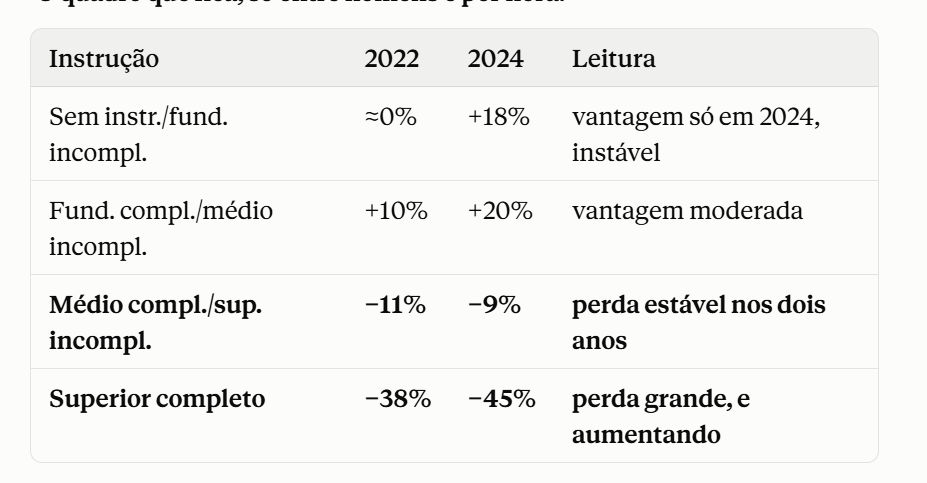

Três conclusões:

O resultado principal ficou mais forte, não mais fraco. O plataformizado típico (homem com ensino médio completo, ~60% do total) ganha cerca de 10% menos por hora que um homem com a mesma escolaridade fora das plataformas. O número é estável nos dois anos e próximo do −8,3% geral do IBGE.
A vantagem da baixa escolaridade é real, mas frágil. Em 2022 ela era praticamente zero entre os homens. Ela aparece em 2024, mas não dá para afirmar que é uma característica estável. Pode ser conjuntura, sazonalidade (4º contra 3º trimestre) ou variação amostral.
A penalidade dos diplomados é o achado mais robusto e o que mais cresce, de −38% para −45% por hora. Isso reforça a tese de sobreeducação.

Uma versão da frase para o texto: "Controlando jornada, sexo e escolaridade, o trabalho por plataforma não oferece vantagem de rendimento para a maioria dos trabalhadores: entre homens com ensino médio completo, o rendimento-hora é cerca de 10% inferior, e entre diplomados, 38% a 45% inferior. Apenas entre os de menor escolaridade observa-se vantagem, porém instável entre 2022 e 2024."

Continua valendo uma cautela: a renda declarada é bruta. Se descontarmos o custo do veículo, todos esses prêmios ficariam mais negativos.


In [ ]:
def premio_razao(df, var):
    linhas = []
    for cat, g in df.groupby(var, observed=True):
        g = g[g.VD4016.notna() & (g.V4039 > 0)]
        def rh(x):  # renda total / horas mensais totais (ponderado)
            return (x.VD4016 * x.peso).sum() / (x.V4039 * 4.33 * x.peso).sum()
        r_pl, r_npl = rh(g[g.plat]), rh(g[~g.plat])
        linhas.append({'ano': df.ano.iloc[0], 'categoria': cat,
                       'prêmio %': 100 * (r_pl / r_npl - 1)})
    return pd.DataFrame(linhas)

for titulo, filtro in {'todos': lambda d: d, 'só homens': lambda d: d[d.sexo == 'Homem']}.items():
    t = pd.concat([premio_razao(filtro(df), 'instrucao') for df in bases.values()])
    print(f"\n===== Renda-hora (razão de totais) – {titulo} =====")
    display(t.pivot(index='categoria', columns='ano', values='prêmio %').round(1))


===== Renda-hora (razão de totais) – todos =====


ano,2022,2024
categoria,,
1 Sem instr./fund. incompl.,12.5,27.0
2 Fund. compl./médio incompl.,14.8,27.1
3 Médio compl./sup. incompl.,3.6,2.1
4 Superior completo,-24.9,-34.9



===== Renda-hora (razão de totais) – só homens =====


ano,2022,2024
categoria,,
1 Sem instr./fund. incompl.,-0.3,18.1
2 Fund. compl./médio incompl.,9.7,19.7
3 Médio compl./sup. incompl.,-11.0,-9.3
4 Superior completo,-37.6,-45.0


### 6.4 Plataformização por família, âncora e nível

ETapa 2: Etapa	O que é	Status
1–3	Dados, deflator, universo, validação	✅ feito
4A	Perfil (sexo, idade, raça, instrução) e prêmio de renda	✅ feito
4B	Indicadores por família COD, com erro-padrão	← agora
5	Tipo de app, região/UF e controle algorítmico	depois
6	Cruzamento com a sua classificação (grupo × nível)	quando o CSV existir
7	Cenários 2040: tendencial, regulação e expansão	final

A etapa 4B responde à pergunta central do seu projeto: em quais ocupações a plataformização é fato observado, e com que precisão? É ela que define onde a projeção usa taxa medida e onde usa hipótese de cenário.

In [ ]:
cod_raw = pd.read_excel(ARQ_COD, dtype=str)
cod_raw.columns = ['gg', 'sgp', 'sg', 'familia', 'denominacao']

cod_familias = (cod_raw.dropna(subset=['familia'])
                .assign(cod=lambda d: d.familia.str.strip().str.zfill(4),
                        nome_familia=lambda d: d.denominacao.str.strip())
                [['cod', 'nome_familia']])

cod_sub_princ = (cod_raw.dropna(subset=['sgp'])
                 .assign(sub_princ=lambda d: d.sgp.str.strip().str.zfill(2),
                         nome_sub_princ=lambda d: d.denominacao.str.strip().str.capitalize())
                 [['sub_princ', 'nome_sub_princ']])

print(f"{len(cod_familias)} famílias | {len(cod_sub_princ)} subgrupos principais")

434 famílias | 43 subgrupos principais


**Etapa 5: plataformização por âncora e nível**
Célula 17: ler o crosswalk e juntar às bases

O cruzamento está perfeito: todos os plataformizados caíram numa âncora, nos dois anos. Os poucos ocupados sem âncora (5 em 2024 e 13 em 2022, de cerca de 180 mil) são o código 0000, "ocupação mal definida", o mesmo resíduo que o relatório já registrava. Não afetam nada.

In [ ]:
caminho_ancoras = '/content/drive/MyDrive/Colab Notebooks/familias_COD_ancoras_final.csv'
ancoras = pd.read_csv(caminho_ancoras, sep=';', dtype={'cod_familia': str})
ancoras['cod_familia'] = ancoras['cod_familia'].str.zfill(4)

for ano in bases:
    bases[ano] = (bases[ano]
                  .drop(columns=['ancora', 'nivel'], errors='ignore')   # evita duplicar se rodar 2x
                  .merge(ancoras[['cod_familia', 'ancora', 'nivel']],
                         left_on='cod', right_on='cod_familia', how='left'))
b24, b22 = bases[2024], bases[2022]

# Cobertura: quantos plataformizados ficaram sem âncora? (esperado: ~0, só código 0000)
for ano, df in bases.items():
    sem = df[df.ancora.isna()]
    print(f"{ano}: {len(sem)} ocupados sem âncora | {sem.plat.sum()} plataformizados sem âncora")

2024: 5 ocupados sem âncora | 0 plataformizados sem âncora
2022: 13 ocupados sem âncora | 0 plataformizados sem âncora


Função indicadores
taxa = 100 * pl.peso.sum() / g.peso.sum()
É a soma dos pesos dos plataformizados dividida pela soma dos pesos de todos os ocupados do grupo.
Calcula o erro-padrão com os 200 pesos replicados:

taxas_rep = 100 * pl[REPS].sum() / g[REPS].sum()   
ep = np.std(taxas_rep, ddof=1)                    
cv = 100 * ep / taxa   
Calcula a qualidade do trabalho, para plataformizados e não plataformizados separadamente:

renda por hora (pela razão de totais, a medida robusta que adotamos);
horas trabalhadas por semana;
percentual que contribui para a previdência, que é a sua definição de formalidade.

5. Atribui o selo de confiabilidade ("boa", "cautela", "não publicar" ou "sem casos"), a partir do CV e do número de casos.
O que ela devolve

Uma tabela com uma linha por grupo e estas colunas:

Coluna	Significado
n amostra, n plat	número de pessoas na amostra: total e plataformizadas
ocupados (mil), plat (mil)	os mesmos números expandidos para a população
taxa plat %, EP, CV %	a taxa e sua precisão
renda-hora plat / não plat	renda por hora, em R$ de ago/2024
horas plat / não plat	jornada semanal média
contrib plat % / não plat %	percentual que contribui para a previdência
confiab	o selo de confiabilidade
A função está funcionando. No total do Brasil, a taxa é 1,87% com erro-padrão de 0,05 ponto. O intervalo de confiança de 95% vai de cerca de 1,77% a 1,97%, e o CV de 2,8% dá o selo de confiabilidade "boa".

Agora rode as células 18, 19 e 20, nessa ordem:

18: plataformização por âncora, em 2024 e 2022;
19: âncora × nível, em 2024;
20: teste da aproximação (8321 ∪ 8322 ∪ 9621) × conta própria contra a SD14001.
1. Por que existe erro

A PNAD não entrevista todo mundo. Ela entrevista uma amostra, uns 180 mil ocupados neste módulo, e usa o peso V1028 para expandir o resultado para os 88,5 milhões de ocupados. Se o IBGE tivesse sorteado outros domicílios, a taxa teria saído um pouco diferente: 1,85%, 1,90% e assim por diante. O 1,87% é a melhor estimativa, mas não é um valor exato.

2. Erro-padrão (EP = 0,05)

O erro-padrão mede o quanto a estimativa oscilaria se a pesquisa fosse repetida com outras amostras.

É para isso que servem os 200 pesos replicados. O IBGE simula 200 amostras alternativas, e a função recalcula a taxa em cada uma. Na prática, as 200 taxas ficaram mais ou menos entre 1,78% e 1,96%. O desvio-padrão dessas 200 taxas, 0,05 ponto percentual, é o erro-padrão.

3. Intervalo de confiança (1,77% a 1,97%)

O intervalo pega a estimativa e soma e subtrai cerca de 2 erros-padrão:

1,87 ± 1,96 × 0,05 → de 1,77% a 1,97%

A leitura é: "com 95% de confiança, a taxa real de plataformização entre os ocupados está entre 1,77% e 1,97%". Na prática, isso significa que, se a taxa de 2022 (1,54%) estiver fora desse intervalo e o intervalo de 2022 também não encostar no de 2024, o aumento é estatisticamente significativo, e não fruto do acaso da amostra.

4. Coeficiente de variação (CV = 2,8%)

O erro-padrão sozinho não diz se o erro é grande ou pequeno, porque depende do tamanho do número. Um EP de 0,05 é pequeno para uma taxa de 1,87%, mas seria enorme para uma taxa de 0,10%. O CV resolve isso comparando os dois:

CV = EP ÷ estimativa = 0,05 ÷ 1,87 = 2,8%

Ou seja, o erro equivale a 2,8% do próprio valor estimado, o que é muito pouco. É a mesma régua que o IBGE usa para decidir o que divulga:

CV	Selo	O que fazer
até 15%	boa	pode publicar
15% a 30%	cautela	publicar com ressalva
acima de 30% (ou menos de 30 casos)	não publicar	não usar a taxa isolada
Por que isso importa agora

No total do Brasil há 2.743 plataformizados na amostra, então o número é preciso. Quando dividirmos por âncora × nível, alguns grupos vão ter só 5 ou 10 plataformizados, e aí o CV sobe muito. O selo mostra, linha por linha, onde a plataformização é um dado confiável e onde é só ruído amostral. É isso que define onde a projeção usa taxa observada e onde entra como hipótese de cenário.

In [ ]:
##Função dos indicadores
# Pesos replicados (200 colunas V1028001...V1028200) — para o erro-padrão
REPS = [c for c in b24.columns if c.startswith('V1028') and len(c) == 8]
for ano in bases:
    bases[ano][REPS] = bases[ano][REPS].apply(pd.to_numeric, errors='coerce')
b24, b22 = bases[2024], bases[2022]

def media_p(x, w):
    m = x.notna()
    return np.average(x[m], weights=w[m]) if m.any() else np.nan

def renda_hora_razao(g):
    g = g[g.VD4016.notna() & (g.V4039 > 0)]
    return (g.VD4016 * g.peso).sum() / (g.V4039 * 4.33 * g.peso).sum() if len(g) else np.nan

def indicadores(df, chaves):
    linhas = []
    for k, g in df.groupby(chaves, observed=True):
        pl, npl = g[g.plat], g[~g.plat]
        taxa = 100 * pl.peso.sum() / g.peso.sum()

        # erro-padrão: recalcula a taxa com cada um dos 200 pesos replicados
        taxas_rep = 100 * pl[REPS].sum().to_numpy() / g[REPS].sum().to_numpy()
        ep = np.std(taxas_rep, ddof=1)
        cv = 100 * ep / taxa if taxa > 0 else np.nan

        linha = dict(zip(chaves, k if isinstance(k, tuple) else (k,)))
        linha.update({
            'n amostra': len(g), 'n plat': len(pl),
            'ocupados (mil)': g.peso.sum() / 1e3,
            'plat (mil)': pl.peso.sum() / 1e3,
            'taxa plat %': taxa, 'EP': ep, 'CV %': cv,
            'renda-hora plat': renda_hora_razao(pl), 'renda-hora não plat': renda_hora_razao(npl),
            'horas plat': media_p(pl.V4039, pl.peso), 'horas não plat': media_p(npl.V4039, npl.peso),
            'contrib plat %': 100 * media_p(pl.contribui.astype(float), pl.peso),
            'contrib não plat %': 100 * media_p(npl.contribui.astype(float), npl.peso),
        })
        linhas.append(linha)

    out = pd.DataFrame(linhas)
    out['confiab'] = np.select(
        [out['n plat'] == 0,
         (out['n plat'] < 30) | (out['CV %'] > 30),
         out['CV %'] > 15],
        ['sem casos', 'não publicar', 'cautela'], default='boa')
    return out.sort_values('plat (mil)', ascending=False).reset_index(drop=True)

# Teste no total Brasil (esperado 2024: taxa 1,87%, CV ~3%, "boa")
indicadores(b24.assign(total='Brasil'), ['total'])[['plat (mil)', 'taxa plat %', 'EP', 'CV %', 'confiab']]

,plat (mil),taxa plat %,EP,CV %,confiab
0,1653.811761,1.868453,0.05185,2.775045,boa


In [ ]:
cols = ['ano', 'ancora', 'n plat', 'plat (mil)', 'taxa plat %', 'CV %', 'confiab',
        'renda-hora plat', 'renda-hora não plat', 'contrib plat %', 'contrib não plat %']

tab_ancora_plat = pd.concat([indicadores(df, ['ano', 'ancora']) for df in bases.values()])
tab_ancora_plat[cols].sort_values(['ano', 'plat (mil)'], ascending=[False, False]).round(2)

,ano,ancora,n plat,plat (mil),taxa plat %,CV %,confiab,renda-hora plat,renda-hora não plat,contrib plat %,contrib não plat %
0,2024,Transporte e Logística,2030,1193.06,17.28,2.64,boa,13.15,14.65,25.01,68.74
1,2024,"Comércio, Serviços e Lazer",484,303.84,1.01,6.77,boa,21.03,13.83,65.68,60.20
2,2024,Administração e Gestão,63,48.65,0.42,18.70,cautela,31.63,25.37,73.68,86.34
3,2024,"Indústria, Produção e Infraestrutura",69,47.34,0.27,14.72,boa,19.12,14.54,51.12,59.31
4,2024,Cuidados,24,22.30,0.28,31.27,não publicar,17.56,12.52,71.55,46.69
5,2024,Humanidades e Cultura,36,18.36,1.55,22.87,cautela,16.04,25.59,37.42,56.36
6,2024,Ciência e Inovação,16,8.98,0.51,34.09,não publicar,39.49,47.62,68.78,89.28
7,2024,Educação,7,5.64,0.46,56.13,não publicar,8.67,26.59,95.08,73.52
8,2024,Saúde,12,5.00,0.32,38.99,não publicar,24.81,42.80,39.01,79.02
9,2024,Agropecuária e Pesca,2,0.63,0.01,81.74,não publicar,11.96,11.42,0.00,34.39


#### Por âncora

A tabela confirma, com dados, o motor de mudança que o seu relatório atribuiu às âncoras: a plataformização é um fenômeno de Transporte e Logística e, em menor escala, de Comércio, Serviços e Lazer.

1. Onde está a plataformização (2024)
Âncora	Plataformizados	Parcela do total	Taxa na âncora	Confiabilidade
Transporte e Logística	1.193 mil	72%	17,3%	boa
Comércio, Serviços e Lazer	304 mil	18%	1,0%	boa
Administração e Gestão	49 mil	3%	0,4%	cautela
Indústria, Produção e Infraestrutura	47 mil	3%	0,3%	boa
Todas as outras	~61 mil	4%	—	não publicar
Juntas, as duas âncoras somam 90% dos plataformizados.
Em Transporte e Logística, 1 em cada 6 trabalhadores já é plataformizado.
Nas demais âncoras, a plataformização é marginal: menos de 0,5% dos ocupados, ou amostra insuficiente.
2. A mudança entre 2022 e 2024 é real?

Aqui entra o erro-padrão que acabamos de ver. Comparo a diferença entre os anos com o erro combinado dos dois:

Transporte e Logística: 14,8% → 17,3% (+2,4 pontos). A diferença é cerca de 3,7 vezes o erro, então o aumento é estatisticamente significativo.
Comércio, Serviços e Lazer: 0,83% → 1,01% (+0,2 ponto). A diferença é cerca de 1,9 vez o erro, no limite da significância. Indica crescimento, mas com cautela.
Administração e Gestão (0,21% → 0,42%): dobrou, mas ainda com selo de cautela. É uma pista a acompanhar, não uma conclusão.
3. Dois perfis de plataformização muito diferentes

Os indicadores de qualidade separam as duas âncoras principais:

	Transporte e Logística	Comércio, Serviços e Lazer
Renda-hora, plat × não plat	R$ 13,15 × 14,65 (−10%)	R$ 21,03 × 13,83 (+52%)
Contribui para a previdência, plat × não plat	25% × 69%	66% × 60%
Em Transporte e Logística, a plataforma precariza: paga menos por hora e tem um terço da proteção previdenciária. É o motorista e o entregador, o retrato do relatório do Lanzara.
Em Comércio, Serviços e Lazer, a plataforma parece qualificar: paga mais por hora e tem proteção igual ou maior. É provavelmente o prestador de serviços com MEI que consegue clientes por app. Esse é o segmento que mais cresceu (+52% entre 2022 e 2024).

Isso tem uma consequência direta para os cenários: não dá para tratar a plataformização como um único choque. É melhor pensar em dois:

plataformização logística: volume alto, precarizante, alvo natural do cenário de regulação;
plataformização de serviços: volume ainda pequeno, crescendo rápido, alvo do cenário de expansão.

Com 484 casos na amostra, dá para abrir Comércio, Serviços e Lazer por família e ver quem são esses prestadores. Fazemos isso depois da célula 20.

In [ ]:
cols = ['ano', 'ancora', 'n plat', 'plat (mil)', 'taxa plat %', 'CV %', 'confiab',
        'renda-hora plat', 'renda-hora não plat', 'contrib plat %', 'contrib não plat %']

tab_ancora_plat = pd.concat([indicadores(df, ['ano', 'ancora']) for df in bases.values()])
tab_ancora_plat[cols].sort_values(['ano', 'plat (mil)'], ascending=[False, False]).round(2)

,ano,ancora,n plat,plat (mil),taxa plat %,CV %,confiab,renda-hora plat,renda-hora não plat,contrib plat %,contrib não plat %
0,2024,Transporte e Logística,2030,1193.06,17.28,2.64,boa,13.15,14.65,25.01,68.74
1,2024,"Comércio, Serviços e Lazer",484,303.84,1.01,6.77,boa,21.03,13.83,65.68,60.20
2,2024,Administração e Gestão,63,48.65,0.42,18.70,cautela,31.63,25.37,73.68,86.34
3,2024,"Indústria, Produção e Infraestrutura",69,47.34,0.27,14.72,boa,19.12,14.54,51.12,59.31
4,2024,Cuidados,24,22.30,0.28,31.27,não publicar,17.56,12.52,71.55,46.69
5,2024,Humanidades e Cultura,36,18.36,1.55,22.87,cautela,16.04,25.59,37.42,56.36
6,2024,Ciência e Inovação,16,8.98,0.51,34.09,não publicar,39.49,47.62,68.78,89.28
7,2024,Educação,7,5.64,0.46,56.13,não publicar,8.67,26.59,95.08,73.52
8,2024,Saúde,12,5.00,0.32,38.99,não publicar,24.81,42.80,39.01,79.02
9,2024,Agropecuária e Pesca,2,0.63,0.01,81.74,não publicar,11.96,11.42,0.00,34.39


#### Por âncora × nível

1. A plataformização é quase toda operacional
Nível	Plataformizados	Parcela
Básico/Operacional	~1.500 mil	91%
Especialista	~82 mil	5%
Direção	~33 mil	2%
Técnico	~37 mil	2%
Transporte e Logística é 100% Básico/Operacional: 1.192 dos 1.193 mil plataformizados da âncora, com uma taxa de 17,6%.
Comércio, Serviços e Lazer tem a maior parte no Básico (255 mil), mas com uma diferença importante: ali os plataformizados contribuem mais para a previdência que os não plataformizados (65% contra 59%). Mesmo no nível operacional, a plataforma de serviços não segue o padrão precarizante da logística. Provavelmente são MEIs de serviços pessoais.
2. Existe uma plataformização qualificada, pequena, mas com taxas relevantes

Fora do Básico, os números absolutos são pequenos, mas algumas taxas chamam atenção. Aqui dá para usar as linhas com selo "cautela":

Âncora × nível	Plat (mil)	Taxa	Contrib plat × não plat
Comércio, Serviços e Lazer – Direção	32	3,3%	73% × 84%
Humanidades e Cultura – Especialista	16	2,0%	31% × 56%
Administração e Gestão – Especialista	33	1,3%	79% × 80%
Direção em Comércio, Serviços e Lazer (3,3%) tem a maior taxa fora da logística. Provavelmente são donos de pequenos negócios, como restaurantes e lojas, que vendem pelos apps de entrega ou de serviços.
Especialistas em Humanidades e Cultura (2,0%) são provavelmente freelancers criativos: design, tradução, produção de conteúdo. É o único grupo qualificado em que a plataforma precariza: só 31% contribuem, contra 56% fora dela.
Especialistas em Administração e Gestão (1,3%) são provavelmente consultores e profissionais de finanças e marketing por app. Aqui a proteção é igual à de quem está fora da plataforma.

O restante (Cuidados, Saúde, Educação e Ciência e Inovação no nível Especialista) aparece com casos, mas sem amostra suficiente para afirmar nada.

O que isso significa para os cenários
O choque de plataformização se aplica, na prática, a Transporte e Logística × Básico (17,6%, precisão "boa") e a Comércio, Serviços e Lazer × Básico (0,9%).
O cenário de expansão tem agora uma base empírica. Já há plataformização mensurável nos níveis Direção e Especialista de três âncoras. A hipótese do cenário seria que esses nichos cresçam até 2040, principalmente com os apps de serviços, que cresceram 52% em dois anos.
A pergunta anterior está respondida em parte. A renda-hora maior de Comércio, Serviços e Lazer vem, em parte, da Direção (donos de negócio). Mas mesmo o Básico dessa âncora tem mais proteção que os não plataformizados.

In [ ]:
tab_an_niv = pd.concat([indicadores(df, ['ano', 'ancora', 'nivel']) for df in bases.values()])

(tab_an_niv[(tab_an_niv.ano == 2024) & (tab_an_niv['n plat'] > 0)]
 [['ancora', 'nivel', 'n plat', 'plat (mil)', 'taxa plat %', 'CV %', 'confiab',
   'contrib plat %', 'contrib não plat %']]
 .sort_values('plat (mil)', ascending=False).round(2))

,ancora,nivel,n plat,plat (mil),taxa plat %,CV %,confiab,contrib plat %,contrib não plat %
0,Transporte e Logística,Básico/Operacional,2029,1192.33,17.60,2.64,boa,24.96,68.26
1,"Comércio, Serviços e Lazer",Básico/Operacional,400,254.54,0.94,7.54,boa,65.25,59.10
2,"Indústria, Produção e Infraestrutura",Básico/Operacional,55,38.21,0.25,16.29,cautela,48.43,55.31
3,Administração e Gestão,Especialista,43,33.13,1.28,23.90,cautela,79.08,80.46
4,"Comércio, Serviços e Lazer",Direção,59,31.60,3.28,16.35,cautela,72.59,83.69
5,"Comércio, Serviços e Lazer",Técnico,24,17.53,0.93,31.89,não publicar,59.15,63.74
6,Humanidades e Cultura,Especialista,31,16.30,1.96,24.58,cautela,31.16,55.51
7,Cuidados,Especialista,12,13.57,1.27,42.23,não publicar,91.16,78.64
8,"Indústria, Produção e Infraestrutura",Técnico,14,9.14,0.47,29.33,não publicar,62.34,86.00
9,Ciência e Inovação,Especialista,16,8.98,0.56,34.16,não publicar,68.78,88.71


### 6.5 Proxy de plataformização e série histórica 2014–2025

A regra funciona razoavelmente, e de forma estável. Mas ela mede outra coisa, e isso acaba sendo útil.

Como ler o resultado
	2022	2024
Plataformizados de verdade (SD14001)	1.319 mil	1.654 mil
Marcados pela regra	1.643 mil	1.922 mil
Cobertura	67%	68%
Precisão	54%	59%
Cobertura estável, em ~68%: a regra pega dois terços dos plataformizados. O terço que falta são sobretudo os apps de serviços, que estão em outras famílias (os ~300 mil de Comércio, Serviços e Lazer, mais Administração, Humanidades etc.).
Precisão de ~55–59%: pouco mais da metade dos motoristas, motociclistas e entregadores conta própria usa app. O resto é taxista de ponto, frete, motoboy de loja.
A regra superestima o total: marca 1.922 mil quando os plataformizados são 1.654 mil.
O detalhe importante: a precisão está subindo

Entre 2022 e 2024 a precisão foi de 54% para 59%. Isso significa que o grupo "motoristas, motociclistas e entregadores conta própria" cresceu pouco (+17%), mas dentro dele a parcela que usa app cresceu (+5 pontos). O crescimento da plataformização vem de duas fontes:

o grupo de trabalhadores candidatos aumenta;
dentro desse grupo, mais gente migra para os apps.

Por isso não dá para simplesmente aplicar um fator de correção fixo à série de 2014 a 2025. O fator mudou de 0,80 para 0,86 em dois anos, e antes de 2022 não sabemos quanto era. Em 2014, quando o Uber chegou ao Brasil, a precisão era perto de zero. Uma série histórica "reconstruída" com fator fixo inventaria plataformização onde ela não existia.

Como usar isso: a regra mede o grupo de risco

Em vez de estimar plataformizados, a regra mede o grupo que pode ser plataformizado. Isso encaixa bem no modelo de projeção:

Plataformizados(t) = Grupo de risco(t) × Penetração(t) + Plataformização de serviços(t)

Componente	De onde vem	O que já sabemos
Grupo de risco	a sua série 2014–2025, com a regra aplicada	tem série longa → dá para projetar como as outras âncoras
Penetração	a precisão: 54% em 2022, 59% em 2024	vira o parâmetro dos cenários (curva logística com teto)
Serviços	a SD14001 fora das famílias de app, ~32% do total	pequeno, crescendo rápido → cenário de expansão

Com isso, os três cenários ganham parâmetros concretos:

Tendencial: a penetração continua subindo em curva que desacelera (por exemplo, até 70–75% em 2040), e os serviços crescem moderadamente.
Regulação: a penetração se estabiliza ou cai, porque a regulação aumenta o custo de operar pelo app, e a contribuição previdenciária sobe.
Expansão: a penetração sobe e os serviços aceleram para os níveis Especialista e Direção.

In [ ]:
FAM_APP = ['8321', '8322', '9621']   # motociclistas, motoristas, mensageiros/entregadores

def testa_proxy(df):
    proxy = df.cod.isin(FAM_APP) & (df.VD4009 == 9)      # 9 = conta própria
    w = df.peso
    return pd.Series({
        'SD14001 (mil)': w[df.plat].sum() / 1e3,
        'proxy (mil)':   w[proxy].sum() / 1e3,
        'acerto (mil)':  w[proxy & df.plat].sum() / 1e3,
        'cobertura %':   100 * w[proxy & df.plat].sum() / w[df.plat].sum(),
        'precisão %':    100 * w[proxy & df.plat].sum() / w[proxy].sum(),
    })

pd.DataFrame({ano: testa_proxy(df) for ano, df in bases.items()}).round(1)

,2024,2022
SD14001 (mil),1653.8,1319.3
proxy (mil),1922.3,1642.8
acerto (mil),1124.6,885.4
cobertura %,68.0,67.1
precisão %,58.5,53.9


#### Série histórica do grupo de risco (conta-própria em 8321/8322/9621)

In [ ]:
# Base PNADC 2014-2025 para a série histórica do grupo de risco
serie = pd.read_parquet(pasta + 'pnadc_2014_2025.parquet',
                        columns=['Ano', 'V1032', 'VD4002', 'VD4009', 'V4010'])
serie = serie[serie['VD4002'] == 'Pessoas ocupadas'].copy()
serie['cod'] = serie['V4010'].astype(str).str.zfill(4)
print(f"Ocupados na série: {len(serie):,}")

Ocupados na série: 2,137,544


Essa tabela mostra, com dados, a história da plataformização no Brasil, e confirma uma hipótese bem forte.

O que a série mostra

O grupo de risco (motoristas, motociclistas e entregadores conta própria) quase triplicou em 11 anos: de 744 mil em 2014 para 2,06 milhões em 2025. E cada ocupação tem o seu momento de salto, que coincide com a chegada de um tipo de app:

Período	O que acontece	Leitura
2014–2015	estável, ~750 mil	antes dos apps: taxistas, motoboys, fretes
2016–2019	motoristas: 519 → 1.100 mil (+112%)	expansão do Uber e do 99
2020–2021	motociclistas: 324 → 476 mil (+47%), enquanto motoristas caem na pandemia	boom do delivery (iFood, Rappi)
2023–2025	as duas sobem de novo: motoristas 1.043 → 1.356; motociclistas 452 → 685	nova onda pós-pandemia

A família 9621 (mensageiros e entregadores) é irrelevante, sempre com menos de 20 mil. Os entregadores de app se declaram motociclistas (8321).

O achado principal: o segmento "sem app" ficou parado

Com os dados do módulo (célula 20), dá para separar o grupo de risco em quem usa e quem não usa app:

	2014	2022	2024
Grupo de risco total	744	1.643	1.922
Usa app (acerto)	~0	885	1.125
Não usa app	~744	757	797

O segmento sem app ficou praticamente igual ao tamanho do grupo inteiro em 2014, em torno de 750–800 mil. Ou seja: todo o crescimento do grupo de risco desde 2015 corresponde a trabalhadores de app. Os apps não converteram taxistas e motoboys já existentes. Eles criaram um contingente novo de cerca de 1,1 a 1,3 milhão de pessoas.

Isso permite reconstruir a série histórica de forma defensável:

Plataformizados no grupo de risco(t) ≈ Grupo de risco(t) − base pré-app (~750 mil)

Não é mais um fator fixo inventado. É uma hipótese testada em dois pontos (2022 e 2024), com uma diferença de cerca de 10–15% atribuível às bases diferentes (entrevista anual × trimestre do módulo).

In [ ]:
vd = serie.VD4009.astype(str).str.strip().str.lower()
serie['conta_propria'] = (vd.str.contains('conta') & vd.str.contains('pr')) | vd.isin(['9', '09', '9.0'])
serie['grupo_risco'] = serie.cod.isin(FAM_APP) & serie.conta_propria

print("Registros no grupo de risco:", serie.grupo_risco.sum())   # deve ser milhares

nomes = {'8321': '8321 Motociclistas', '8322': '8322 Motoristas',
         '9621': '9621 Mensageiros/entregadores'}

grupo_risco = (serie[serie.grupo_risco]
               .groupby(['Ano', 'cod'])['V1032'].sum()
               .unstack('cod')
               .rename(columns=nomes) / 1e3)
grupo_risco['Total (mil)'] = grupo_risco.sum(axis=1)
grupo_risco.round(0)

Registros no grupo de risco: 27510


cod,8321 Motociclistas,8322 Motoristas,9621 Mensageiros/entregadores,Total (mil)
Ano,,,,
2014,239.0,500.0,4.0,744.0
2015,244.0,519.0,2.0,766.0
2016,286.0,606.0,5.0,897.0
2017,283.0,701.0,4.0,988.0
2018,299.0,964.0,5.0,1268.0
2019,324.0,1100.0,4.0,1429.0
2020,387.0,963.0,17.0,1368.0
2021,476.0,1018.0,10.0,1504.0
2022,452.0,1043.0,11.0,1505.0


Base pré-app: 755 mil


,grupo de risco (mil),base pré-app (mil),plat. estimados (mil),penetração %,plat. observados – módulo (mil)
Ano,,,,,
2014,744.0,755.0,0.0,0.0,NaN
2015,766.0,755.0,11.0,1.0,NaN
2016,897.0,755.0,142.0,16.0,NaN
2017,988.0,755.0,234.0,24.0,NaN
2018,1268.0,755.0,513.0,40.0,NaN
2019,1429.0,755.0,674.0,47.0,NaN
2020,1368.0,755.0,613.0,45.0,NaN
2021,1504.0,755.0,750.0,50.0,NaN
2022,1505.0,755.0,751.0,50.0,885.0


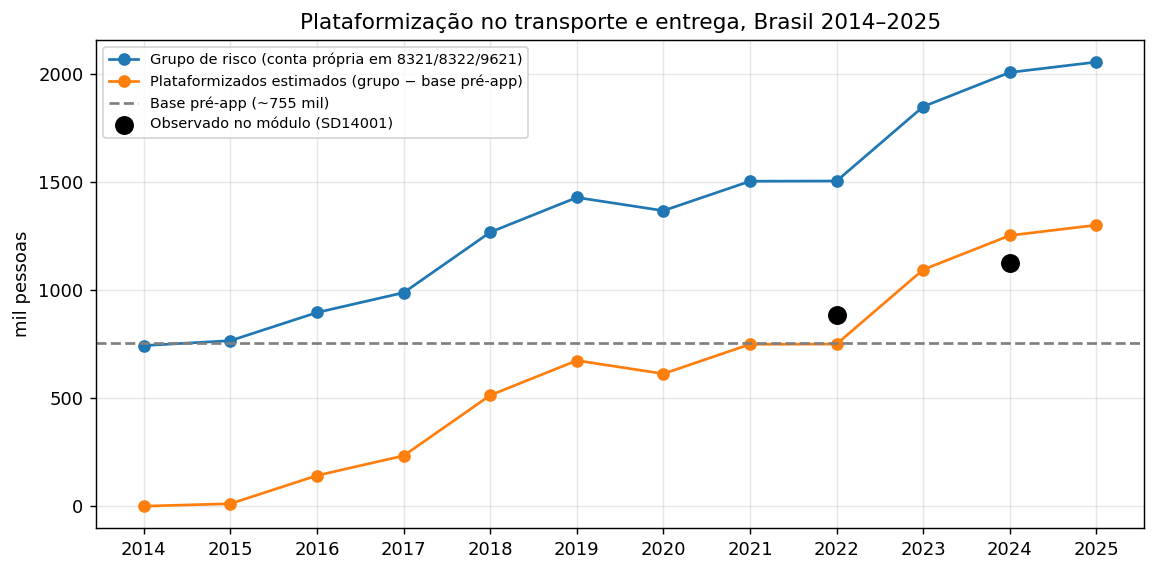

In [ ]:
import matplotlib.pyplot as plt

grupo_risco.index = grupo_risco.index.astype(int)      # <- NOVO: ano de texto para número

BASE_PRE_APP = grupo_risco.loc[[2014, 2015], 'Total (mil)'].mean()   # ~755 mil

reconstr = pd.DataFrame({
    'grupo de risco (mil)': grupo_risco['Total (mil)'],
    'base pré-app (mil)': BASE_PRE_APP,
})
reconstr['plat. estimados (mil)'] = (reconstr['grupo de risco (mil)'] - BASE_PRE_APP).clip(lower=0)
reconstr['penetração %'] = 100 * reconstr['plat. estimados (mil)'] / reconstr['grupo de risco (mil)']

# Pontos observados no módulo (acerto da célula 20: plataformizados dentro do grupo de risco)
observado = pd.Series({2022: 885.4, 2024: 1124.6}, name='plat. observados – módulo (mil)')
reconstr = reconstr.join(observado)

print(f"Base pré-app: {BASE_PRE_APP:.0f} mil")
display(reconstr.round(0))

# Gráfico
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(reconstr.index, reconstr['grupo de risco (mil)'], marker='o', label='Grupo de risco (conta própria em 8321/8322/9621)')
ax.plot(reconstr.index, reconstr['plat. estimados (mil)'], marker='o', label='Plataformizados estimados (grupo − base pré-app)')
ax.axhline(BASE_PRE_APP, ls='--', color='gray', label=f'Base pré-app (~{BASE_PRE_APP:.0f} mil)')
ax.scatter(observado.index, observado.values, s=90, color='black', zorder=5, label='Observado no módulo (SD14001)')
ax.set_title('Plataformização no transporte e entrega, Brasil 2014–2025')
ax.set_ylabel('mil pessoas'); ax.set_xticks(reconstr.index)
ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 6.6 Curva logística, sensibilidade do teto e tribunal

Ajustar uma curva logística e projetar até 2040
DEtalhe: 2020 e 2021 não utilizados

A curva logística tem três parâmetros:

K (teto): o número máximo de plataformizados que o mercado comporta;
r: a velocidade de crescimento;
t0: o ano em que a curva cresce mais rápido, ou seja, o ponto de inflexão.

A célula ajusta esses três parâmetros aos dados de 2014 a 2025 e projeta os três cenários. Cada cenário muda o teto K a partir de 2027:

Tendencial: o teto ajustado pelos dados;
Regulação: o teto cai 15%. Com contribuição obrigatória e mais custo por trabalhador, o mercado comporta menos gente;
Expansão: o teto sobe 20%, com novas modalidades e cidades menores entrando.

A mensagem principal: pelo ajuste, a plataformização no transporte e entrega está perto do teto. Em 2025 ela já está em cerca de 89% do máximo estimado (~1,46 milhão). No cenário tendencial, cresce pouco daqui em diante. A partir de agora, o que decide o futuro não é mais a difusão da tecnologia, mas fatores externos: regulação ou novas frentes de expansão. Isso dá um bom argumento para a camada 3.

Relacionando com a sua projeção Híbrido 2.0, em que Transporte e Logística vai de 7,47 para 7,75 milhões: hoje ~17% da âncora é plataformizada, o mesmo que o módulo mediu (17,6%). Em 2040, seriam ~19% no tendencial, ~16% na regulação e ~23% na expansão.

Três cautelas antes de usar

1. O teto depende muito dos últimos anos. A curva "achata" porque 2025 cresceu pouco sobre 2024 (+4%). Se 2025 tiver sido só um ano fraco, o teto real pode ser bem maior. Isso precisa ser testado (célula 25).

2. As quebras em 2027 e 2032 são artificiais. As linhas de regulação e expansão fazem "cotovelos" porque usei uma rampa linear que começa em 2027 e termina em 2032. Para o relatório, é melhor uma transição suave. Isso é um ajuste estético, e fazemos no final.

3. Os fatores 0,85 e 1,20 são hipóteses minhas. O desenho dos cenários está certo, mas a magnitude precisa de fundamento: a experiência da Espanha com a Ley Rider, o texto do PLP 12/2024 ou o diálogo com especialistas previsto no projeto.

Anos no ajuste: [2014, 2015, 2016, 2017, 2018, 2019, 2022, 2023, 2024, 2025]
Teto K = 1,457 mil (EP 319) | velocidade r = 0.42 | inflexão t0 = 2020.4


,Tendencial,Regulação,Expansão
2025,1272.0,1272.0,1272.0
2030,1432.0,1303.0,1603.0
2035,1454.0,1236.0,1744.0
2040,1456.0,1238.0,1747.0


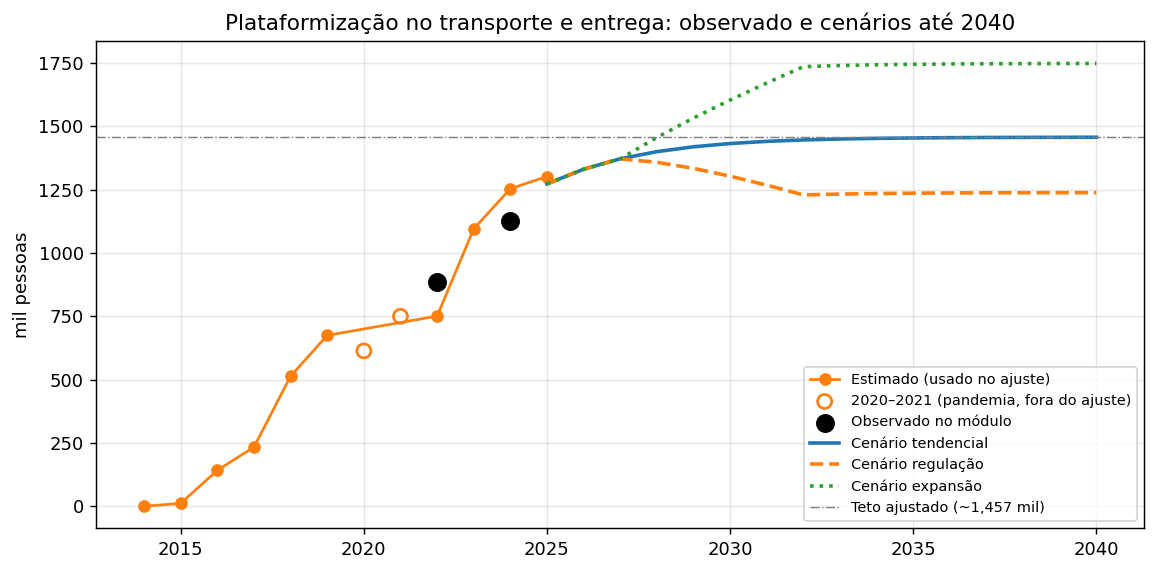

In [ ]:
from scipy.optimize import curve_fit

def logistica(t, K, r, t0):
    return K / (1 + np.exp(-r * (t - t0)))

# Anos usados no ajuste: tudo menos a pandemia
ANOS_EXCLUIDOS = [2020, 2021]
ajuste = reconstr.drop(index=ANOS_EXCLUIDOS)
anos = ajuste.index.values.astype(float)
y = ajuste['plat. estimados (mil)'].values
print(f"Anos no ajuste: {list(ajuste.index)}")

(K, r, t0), cov = curve_fit(logistica, anos, y, p0=[1500, 0.5, 2019],
                            bounds=([1000, 0.05, 2014], [5000, 3, 2035]))
ep_K = np.sqrt(np.diag(cov))[0]
print(f"Teto K = {K:,.0f} mil (EP {ep_K:,.0f}) | velocidade r = {r:.2f} | inflexão t0 = {t0:.1f}")

# Projeção 2025–2040 em três cenários (mudança no teto a partir de 2027, gradual até 2032)
anos_proj = np.arange(2025, 2041)
def rampa_k(ano, fator):
    x = np.clip((ano - 2027) / (2032 - 2027), 0, 1)
    return 1 + (fator - 1) * x

cenarios_plat = pd.DataFrame({
    'Tendencial': [logistica(a, K, r, t0) for a in anos_proj],
    'Regulação':  [logistica(a, K * rampa_k(a, 0.85), r, t0) for a in anos_proj],
    'Expansão':   [logistica(a, K * rampa_k(a, 1.20), r, t0) for a in anos_proj],
}, index=anos_proj)

display(cenarios_plat.loc[[2025, 2030, 2035, 2040]].round(0))

# Gráfico
todos = reconstr['plat. estimados (mil)']
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ajuste.index, y, 'o-', color='tab:orange', label='Estimado (usado no ajuste)')
ax.scatter(ANOS_EXCLUIDOS, todos.loc[ANOS_EXCLUIDOS], s=60, facecolors='none',
           edgecolors='tab:orange', lw=1.5, zorder=4, label='2020–2021 (pandemia, fora do ajuste)')
ax.scatter(observado.index, observado.values, s=90, color='black', zorder=5, label='Observado no módulo')
for nome, estilo in [('Tendencial', '-'), ('Regulação', '--'), ('Expansão', ':')]:
    ax.plot(anos_proj, cenarios_plat[nome], estilo, lw=2, label=f'Cenário {nome.lower()}')
ax.axhline(K, color='gray', lw=0.8, ls='-.', label=f'Teto ajustado (~{K:,.0f} mil)')
ax.set_title('Plataformização no transporte e entrega: observado e cenários até 2040')
ax.set_ylabel('mil pessoas'); ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

#### Sensibilidade do teto

**O teto da logística não é robusto!!!**
Como ler:

A linha "Sem 2020–21 e sem 2025" é a mais importante. Ela mostra quanto o teto depende daquele último ano.
A coluna EP de K é a incerteza do teto. Se ela for maior que uns 200 mil, o teto está pouco determinado pelos dados.


Teste	Teto K	Incerteza (EP)
Base (sem 2020–21)	1.457 mil	±319
Sem 2020–21 e sem 2025	1.187 mil	±201
Com todos os anos	1.559 mil	±329
Sem 2020–21, desde 2016	1.774 mil	±813
O teto varia de 1,19 a 1,77 milhão só mudando quais anos entram no ajuste. É uma diferença de 50%.
O teste sem 2025 é revelador. Ele dá um teto de 1,19 milhão, abaixo do que já foi observado em 2025 (~1,30 milhão). Ou seja: com os dados até 2024, a logística teria errado o ano seguinte.
Os erros-padrão são enormes, de ±200 a ±800 mil.

Conclusão: os dados ainda não mostram onde a curva vai achatar. O ajuste logístico "inventa" um teto a partir de um ou dois anos de desaceleração. Não é seguro usar esse teto como cenário tendencial.

In [ ]:
testes = {
    'Base (sem 2020–21)':        [2020, 2021],
    'Sem 2020–21 e sem 2025':    [2020, 2021, 2025],
    'Com todos os anos':         [],
    'Sem 2020–21, desde 2016':   [2014, 2015, 2020, 2021],
}

linhas = []
for nome, excluir in testes.items():
    d = reconstr.drop(index=excluir)
    try:
        (Kx, rx, t0x), covx = curve_fit(logistica, d.index.values.astype(float),
                                        d['plat. estimados (mil)'].values,
                                        p0=[1500, 0.5, 2019],
                                        bounds=([1000, 0.05, 2014], [5000, 3, 2035]))
        linhas.append({'teste': nome, 'teto K (mil)': Kx, 'EP de K': np.sqrt(covx[0, 0]),
                       'r': rx, 'inflexão': t0x, '2040 tendencial (mil)': logistica(2040, Kx, rx, t0x)})
    except RuntimeError:
        linhas.append({'teste': nome, 'teto K (mil)': np.nan})

pd.DataFrame(linhas).round(2)

,teste,teto K (mil),EP de K,r,inflexão,2040 tendencial (mil)
0,Base (sem 2020–21),1456.62,318.54,0.42,2020.43,1456.24
1,Sem 2020–21 e sem 2025,1186.84,200.80,0.57,2019.09,1186.83
2,Com todos os anos,1559.13,329.32,0.39,2020.98,1558.22
3,"Sem 2020–21, desde 2016",1773.70,812.93,0.32,2021.74,1768.49


Tribunal para a plataformização
Três competidores:

Congelamento: o último valor observado fica constante;
Tendência amortecida: a inclinação 2014–último ano, sem 2020–21, projetada com δ = 0,85, igual ao relatório;
Logística: a curva com teto.

Duas janelas de teste, como no relatório:

J1: estima com dados até 2019 e é julgada em 2022–2025;
J2: estima com dados até 2018 e é julgada em 2019 e 2022–2024.

A tendência amortecida venceu com folga, e nas duas janelas, o que atende à regra de robustez do seu relatório:

Método	J1	J2	Média
Tendência amortecida (δ = 0,85)	132	161	146
Logística	323	292	308
Congelamento	426	430	428

Como ler:

A tendência amortecida erra, em média, ~146 mil pessoas em anos que não viu. É cerca de 13% do nível da série, praticamente o mesmo tamanho do ruído da própria reconstrução (±12–15%). Não dá para exigir mais precisão do que isso.
A logística erra o dobro. Estimada com dados até 2018 ou 2019, ela "achou" um teto baixo cedo demais. É o mesmo problema que a sensibilidade mostrou.
O congelamento erra o triplo. A plataformização não parou de crescer.

A decisão metodológica: o cenário tendencial da plataformização usa tendência amortecida com δ = 0,85, o mesmo método e o mesmo parâmetro das seis âncoras que o usam no Híbrido 2.0. A logística fica descartada, pelo mesmo critério com que o relatório descartou o ML em Educação e em Transporte e Logística.

Um contraste interessante para o texto: no relatório, a âncora Transporte e Logística como um todo ficou no regime de congelamento (7,47 → 7,75 milhões). Mas a plataformização dentro dela segue uma tendência. Se as duas coisas valem ao mesmo tempo, a composição da âncora muda: os plataformizados ganham participação e o trabalho de transporte fora dos apps encolhe. É uma recomposição interna, parecida com a que o relatório descreveu em Cuidados.

In [ ]:
serie_plat = reconstr['plat. estimados (mil)'].drop(index=[2020, 2021])
DELTA = 0.85

def prev_congelamento(hist, anos_alvo):
    return pd.Series(hist.iloc[-1], index=anos_alvo)

def prev_tendencia(hist, anos_alvo, delta=DELTA):
    inclin = np.polyfit(hist.index.values, hist.values, 1)[0]   # mil pessoas por ano
    T = hist.index.max()
    return pd.Series([hist.iloc[-1] + inclin * sum(delta**k for k in range(1, a - T + 1))
                      for a in anos_alvo], index=anos_alvo)

def prev_logistica(hist, anos_alvo):
    try:
        p, _ = curve_fit(logistica, hist.index.values.astype(float), hist.values,
                         p0=[1500, 0.5, 2019], bounds=([hist.max(), 0.05, 2014], [5000, 3, 2035]))
        return pd.Series(logistica(np.array(anos_alvo, float), *p), index=anos_alvo)
    except RuntimeError:
        return pd.Series(np.nan, index=anos_alvo)

janelas = {'J1 (até 2019 → 2022–25)': (2019, [2022, 2023, 2024, 2025]),
           'J2 (até 2018 → 2019, 2022–24)': (2018, [2019, 2022, 2023, 2024])}
metodos = {'Congelamento': prev_congelamento, 'Tendência amortecida': prev_tendencia,
           'Logística': prev_logistica}

tribunal = {}
for nome_j, (ultimo, alvo) in janelas.items():
    hist = serie_plat[serie_plat.index <= ultimo]
    obs = serie_plat.loc[alvo]
    tribunal[nome_j] = {m: (f(hist, alvo) - obs).abs().mean() for m, f in metodos.items()}

tribunal = pd.DataFrame(tribunal)
tribunal['MAE médio'] = tribunal.mean(axis=1)
print("Erro absoluto médio (mil pessoas) — menor é melhor")
tribunal.round(0).sort_values('MAE médio')

Erro absoluto médio (mil pessoas) — menor é melhor


,J1 (até 2019 → 2022–25),"J2 (até 2018 → 2019, 2022–24)",MAE médio
Tendência amortecida,132.0,161.0,146.0
Logística,323.0,292.0,308.0
Congelamento,426.0,430.0,428.0


Projeção 2025–2040 com os três cenários

Como agora o método é a tendência amortecida, os cenários mudam a inclinação (a velocidade de crescimento) a partir de 2027, não um teto:

Tendencial: a inclinação estimada nos dados;
Regulação: a inclinação cai para 25% da tendencial, e a plataformização praticamente estabiliza;
Expansão: a inclinação sobe 50%.

A célula também lê o seu Híbrido 2.0 e calcula quanto da âncora Transporte e Logística seria plataformizada em cada cenário.

Pela tendência amortecida (δ = 0,85, o método que venceu o tribunal), a plataformização no transporte e entrega continua crescendo até 2040, cada vez mais devagar.

Cenário	2025	2030	2040	Parcela da âncora T&L em 2040
Tendencial	1,30 mi	1,69 mi	1,95 mi	25% (hoje 17%)
Regulação	1,30 mi	1,48 mi	1,54 mi	20%
Expansão	1,30 mi	1,84 mi	2,22 mi	29%

Os números bateram com o que eu esperava: cerca de 1,9 milhão no tendencial, 1,5 na regulação e 2,2 na expansão. Isso indica que a mecânica está correta.

A recomposição interna da âncora

No Híbrido 2.0, Transporte e Logística fica congelada (7,48 → 7,75 milhões). Se a plataformização cresce dentro de uma âncora que não cresce, o trabalho fora dos apps encolhe:

Cenário	T&L fora de app, 2025	2040	Variação
Tendencial	6,18 mi	5,81 mi	−6%
Regulação	6,18 mi	6,21 mi	estável
Expansão	6,18 mi	5,54 mi	−10%

É o mesmo tipo de achado do seu relatório para Cuidados: o total da âncora parece estável, mas a composição muda por dentro. Em Cuidados, o vínculo doméstico dá lugar ao cuidado profissional. Em T&L, o motorista empregado dá lugar ao motorista de app.

O que isso significa para a proteção social

Juntando a projeção com as taxas de contribuição que medimos em T&L em 2024 (25% entre plataformizados, 69% entre os demais), dá para estimar quantos trabalhadores da âncora ficam sem previdência. É uma ilustração, mantendo as taxas de hoje:

	2025	2040 tendencial	2040 regulação (com paridade de contribuição)
Sem previdência em T&L	~2,9 mi (39%)	~3,3 mi (42%)	~2,4 mi (31%)

Esta é a ponte com a etapa futura de políticas públicas que decidimos manter. A diferença entre os cenários é de quase 900 mil trabalhadores sem proteção previdenciária em 2040, só dentro de uma âncora. Isso mostra, com números, o que está em jogo na regulação das plataformas.

Inclinação estimada: 125 mil/ano | ponto de partida 2025: 1301 mil


,Tendencial,Regulação,Expansão,% da âncora T&L – Tendencial,% da âncora T&L – Regulação,% da âncora T&L – Expansão
2025,1301.4,1301.4,1301.4,17.4,17.4,17.4
2030,1694.3,1479.1,1837.8,22.2,19.4,24.1
2035,1868.6,1522.6,2099.3,24.2,19.7,27.2
2040,1946.0,1542.0,2215.3,25.1,19.9,28.6


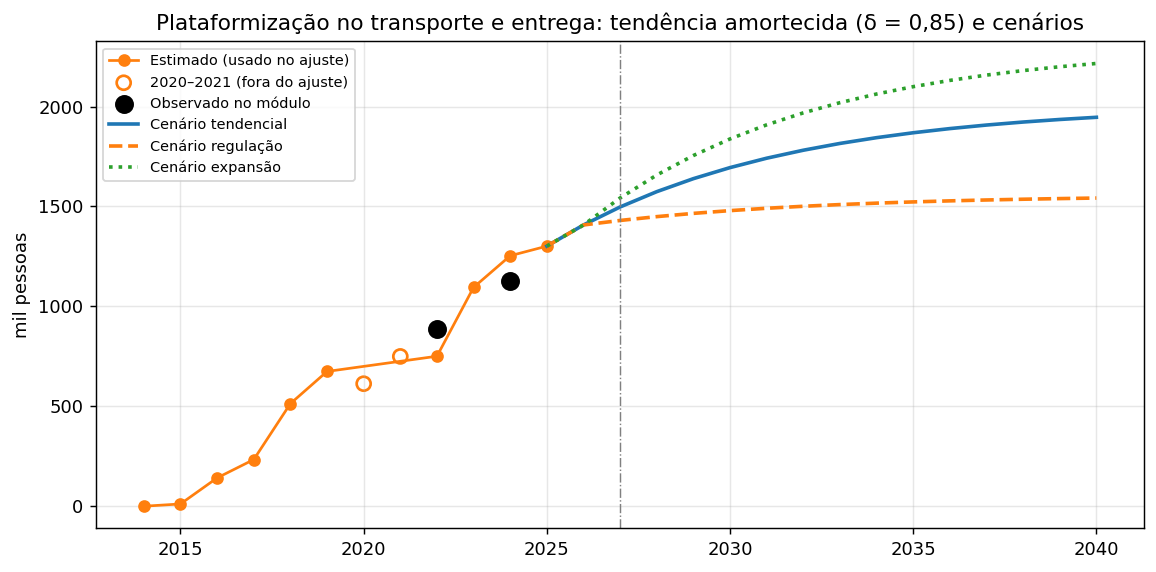

In [ ]:
hist = serie_plat                                      # 2014–2025 sem 2020–21
inclin = np.polyfit(hist.index.values, hist.values, 1)[0]
T, y_T = hist.index.max(), hist.iloc[-1]
print(f"Inclinação estimada: {inclin:.0f} mil/ano | ponto de partida {T}: {y_T:.0f} mil")

FATORES = {'Tendencial': 1.00, 'Regulação': 0.25, 'Expansão': 1.50}   # hipóteses a fundamentar
INICIO_CHOQUE = 2027

def projeta(fator):
    valores, acumulado = {T: y_T}, y_T
    for a in range(T + 1, 2041):
        mult = fator if a >= INICIO_CHOQUE else 1.0
        acumulado += inclin * DELTA**(a - T) * mult
        valores[a] = acumulado
    return pd.Series(valores)

cen = pd.DataFrame({nome: projeta(f) for nome, f in FATORES.items()})

# Participação na âncora Transporte e Logística (Híbrido 2.0, em milhões)
try:
    hib = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/camada2_hibrido_v2.parquet')
    hib.index = hib.index.astype(int)
    tl = hib['Transporte e Logística'] * 1000            # para mil pessoas
    for nome in FATORES:
        cen[f'% da âncora T&L – {nome}'] = 100 * cen[nome] / tl.reindex(cen.index)
except Exception as e:
    print("Não consegui ler o Híbrido 2.0:", e)

display(cen.loc[[2025, 2030, 2035, 2040]].round(1))

# Gráfico
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hist.index, hist.values, 'o-', color='tab:orange', label='Estimado (usado no ajuste)')
ax.scatter([2020, 2021], reconstr.loc[[2020, 2021], 'plat. estimados (mil)'], s=60,
           facecolors='none', edgecolors='tab:orange', lw=1.5, label='2020–2021 (fora do ajuste)')
ax.scatter(observado.index, observado.values, s=90, color='black', zorder=5, label='Observado no módulo')
for nome, estilo in [('Tendencial', '-'), ('Regulação', '--'), ('Expansão', ':')]:
    ax.plot(cen.index, cen[nome], estilo, lw=2, label=f'Cenário {nome.lower()}')
ax.axvline(INICIO_CHOQUE, color='gray', lw=0.8, ls='-.')
ax.set_title('Plataformização no transporte e entrega: tendência amortecida (δ = 0,85) e cenários')
ax.set_ylabel('mil pessoas'); ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 6.7 Cenários revisados: quantidade e proteção previdenciária

Os cenários fundamentados deram um resultado mais claro e mais defensável que a versão anterior.

Passo 1 fechado: o que os cenários mostram
2040	Plataformizados	% da âncora T&L	Sem previdência em T&L
Tendencial	1,95 mi	25%	3,28 mi (42%)
Expansão	2,19 mi	28%	3,38 mi (44%)
Regulação leve (tipo PLP 152)	1,95 mi	25%	2,01 mi (26%)
Regulação forte (tipo Ley Rider)	1,81 mi	23%	2,04 mi (26%)

Em 2025, são 2,91 milhões sem previdência, ou 39% da âncora.

Três conclusões para o texto:

A quantidade varia pouco entre os cenários, de 1,81 a 2,19 milhões em 2040, ±10% em torno do tendencial. A plataformização continua crescendo em qualquer cenário.
A proteção varia muito. Entre o tendencial e a regulação leve, a diferença é de ~1,26 milhão de trabalhadores sem previdência em 2040, só em Transporte e Logística. Sem regulação, a desproteção na âncora sobe de 39% para 42%. Com ela, cai para 26%.
A regulação leve e a forte chegam praticamente ao mesmo resultado em proteção (26,0% e 26,3%). A forte ainda reduz um pouco o emprego nas plataformas. Pela evidência disponível, o modelo de contribuição obrigatória sem vínculo (PLP 152) alcança o ganho de proteção a um custo menor em emprego. É um resultado relevante para o debate de política.

Uma ressalva sobre a regulação forte: o modelo supõe que os 7% que saem das plataformas continuam trabalhando em Transporte e Logística fora dos apps, porque o total da âncora vem fixo do Híbrido 2.0. Na Espanha, parte foi para o desemprego. Então o custo da regulação forte, aqui, está subestimado.

Passo 2: o componente de serviços

São os plataformizados fora do grupo de risco: os apps de serviços gerais e profissionais, espalhados por Comércio, Serviços e Lazer, Administração, Humanidades e Indústria.

	2022	2024
Plataformizados (total)	1.319	1.654
No grupo de risco (acerto)	885	1.125
Fora do grupo de risco	434	529 (+22%)

A dificuldade: não dá para reconstruir uma série histórica como fizemos com o transporte. Esses trabalhadores estão espalhados por dezenas de famílias, e não existe uma "base pré-app" identificável. Temos só dois pontos, então não há como fazer o tribunal.

A proposta é tratar os serviços de forma mais simples e transparente:

Descrever onde estão: por âncora e nível, em 2022 e 2024 (célula 29).
Projetar com a mesma lógica amortecida, mas sobre a taxa de crescimento: crescimento de ~10% ao ano entre 2022 e 2024, amortecido com δ = 0,85. É uma hipótese declarada, sem validação fora da amostra.
Deixar a expansão para os níveis qualificados como cenário explícito, já que é ali que está a pergunta de política: a plataformização chega aos níveis Técnico e Especialista?

plataformizados (mil)                 % da âncora T&L        \
ano                              2025    2030    2040            2025  2030   
cenário                                                                       
Expansão                       1301.4  1760.7  2192.2            17.4  23.1   
Regulação forte                1301.4  1575.7  1809.8            17.4  20.6   
Regulação leve                 1301.4  1694.3  1946.0            17.4  22.2   
Tendencial                     1301.4  1694.3  1946.0            17.4  22.2   

                      sem previdência em T&L (mil)                  \
ano              2040                         2025    2030    2040   
cenário                                                              
Expansão         28.3                       2906.1  3158.3  3383.1   
Regulação forte  23.4                       2906.1  2053.2  2039.7   
Regulação leve   25.1                       2906.1  2028.0  2010.7   
Tendencial       25.1                       2906.1  3129.2  3275.5   

                % sem previdência              
ano                          2025  2030  2040  
cenário                                        
Expansão                     38.9  41.4  43.7  
Regulação forte              38.9  26.9  26.3  
Regulação leve               38.9  26.6  26.0  
Tendencial                   38.9  41.0  42.3

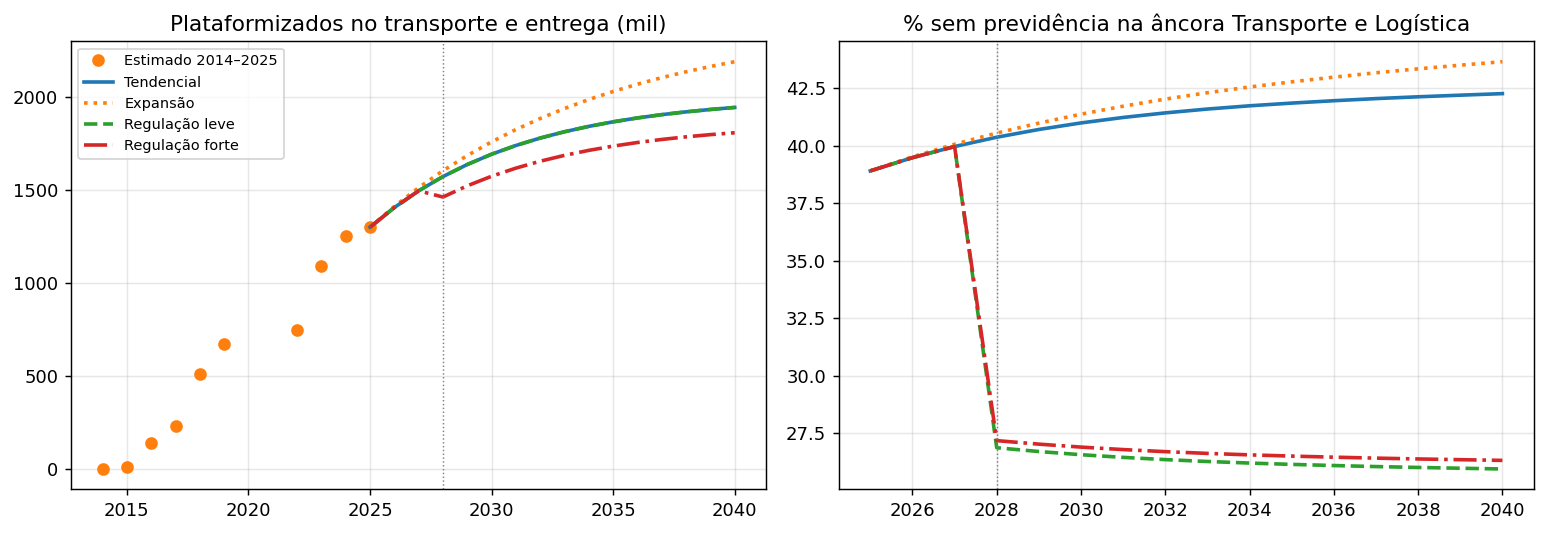

In [ ]:
ANO_REG = 2028          # hipótese: implementação da regulação
CONTRIB_REG = 90        # hipótese: % de plataformizados contribuindo com retenção na fonte
CONTRIB_PLAT_HOJE, CONTRIB_NPLAT = 25.0, 68.7     # T&L 2024 (célula 18)
QUEDA_LEY_RIDER = 0.07                            # Dolado, Jáñez & Wellschmied (2025)

def projeta_delta(delta, choque_nivel=0.0):
    valores, acum = {T: y_T}, y_T
    for a in range(T + 1, 2041):
        acum += inclin * delta**(a - T)
        valores[a] = acum * (1 - choque_nivel if a >= ANO_REG else 1)
    return pd.Series(valores)

cen2 = pd.DataFrame({
    'Tendencial':      projeta_delta(0.85),
    'Expansão':        projeta_delta(0.90),
    'Regulação leve':  projeta_delta(0.85),
    'Regulação forte': projeta_delta(0.85, choque_nivel=QUEDA_LEY_RIDER),
})
contrib = {'Tendencial': lambda a: CONTRIB_PLAT_HOJE, 'Expansão': lambda a: CONTRIB_PLAT_HOJE,
           'Regulação leve':  lambda a: CONTRIB_REG if a >= ANO_REG else CONTRIB_PLAT_HOJE,
           'Regulação forte': lambda a: CONTRIB_REG if a >= ANO_REG else CONTRIB_PLAT_HOJE}

tl = hib['Transporte e Logística'].reindex(cen2.index) * 1000     # âncora T&L, Híbrido 2.0 (mil)

resumo = []
for nome in cen2:
    for a in [2025, 2030, 2040]:
        plat = cen2.loc[a, nome]
        nplat = tl.loc[a] - plat
        sem_prev = plat * (1 - contrib[nome](a) / 100) + nplat * (1 - CONTRIB_NPLAT / 100)
        resumo.append({'cenário': nome, 'ano': a, 'plataformizados (mil)': plat,
                       '% da âncora T&L': 100 * plat / tl.loc[a],
                       'sem previdência em T&L (mil)': sem_prev,
                       '% sem previdência': 100 * sem_prev / tl.loc[a]})
resumo = pd.DataFrame(resumo)
display(resumo.pivot(index='cenário', columns='ano').round(1))

# Gráfico: quantidade e proteção lado a lado
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2))
estilos = {'Tendencial': '-', 'Expansão': ':', 'Regulação leve': '--', 'Regulação forte': '-.'}
a1.plot(hist.index, hist.values, 'o', color='tab:orange', label='Estimado 2014–2025')
for nome, ls in estilos.items():
    a1.plot(cen2.index, cen2[nome], ls, lw=2, label=nome)
    sp = [cen2.loc[a, nome] * (1 - contrib[nome](a)/100) + (tl.loc[a] - cen2.loc[a, nome]) * (1 - CONTRIB_NPLAT/100)
          for a in cen2.index]
    a2.plot(cen2.index, 100 * np.array(sp) / tl.values, ls, lw=2, label=nome)
a1.set_title('Plataformizados no transporte e entrega (mil)'); a1.grid(alpha=.3); a1.legend(fontsize=8)
a2.set_title('% sem previdência na âncora Transporte e Logística'); a2.grid(alpha=.3)
for ax in (a1, a2): ax.axvline(ANO_REG, color='gray', lw=0.8, ls=':')
plt.tight_layout(); plt.show()

### 6.8 Plataformização fora do transporte (serviços)

A tabela mostra algo que não aparecia no total: fora do transporte, os níveis qualificados estão crescendo muito mais rápido que o Básico.

O que a tabela mostra

Agrupando as linhas por tipo de nível (a soma fica um pouco abaixo do total porque a tabela mostra só as 15 maiores linhas):

Componente de serviços	2022	2024	Variação
Básico/Operacional (CSL, T&L não conta própria, Indústria, Cuidados, Adm)	~331 mil	~375 mil	+13%
Qualificados (Direção + Técnico + Especialista)	~95 mil	~148 mil	+56%

O Básico cresce no ritmo do total, mas os níveis qualificados crescem quatro vezes mais rápido. Os destaques:

Administração e Gestão, Especialista: 10 → 33 mil, triplicou. São consultores, analistas e profissionais de marketing e finanças por app.
Humanidades e Cultura, Especialista: 6 → 16 mil, 2,5 vezes. Freelancers criativos.
Cuidados, Especialista: 4 → 14 mil, 3 vezes. Provavelmente psicólogos e terapeutas em plataformas de atendimento online.
Comércio, Serviços e Lazer, Direção e Técnico: crescimento moderado, de +16% e +17%.

É o primeiro sinal empírico de que a plataformização está saindo do trabalho operacional e chegando ao trabalho qualificado, o fenômeno que o cenário de expansão supunha.

Cautelas importantes:

A amostra é pequena. Administração e Gestão × Especialista tem só 22 e 43 casos. Cada linha isolada tem CV alto; o que é robusto é o padrão agregado, com quase todos os grupos qualificados crescendo ao mesmo tempo.
Na linha Transporte e Logística × Básico (fora do grupo de risco), os 81 → 68 mil são plataformizados que não são conta própria, como empregados de empresas de logística que operam por app. A queda pode ser só ruído amostral.

In [ ]:
def fora_do_grupo(df):
    no_grupo = df.cod.isin(FAM_APP) & (df.VD4009 == 9)
    return df.assign(plat_servicos=df.plat & ~no_grupo)

comp_serv = []
for ano, df in bases.items():
    d = fora_do_grupo(df)
    g = (d[d.plat_servicos].groupby(['ancora', 'nivel'], observed=True)['peso'].sum() / 1e3)
    n = d[d.plat_servicos].groupby(['ancora', 'nivel'], observed=True).size()
    comp_serv.append(pd.DataFrame({'ano': ano, 'plat serviços (mil)': g, 'n amostra': n}))
comp_serv = pd.concat(comp_serv).reset_index()

total_serv = comp_serv.groupby('ano')['plat serviços (mil)'].sum()
print("Total fora do grupo de risco (mil):", total_serv.round(0).to_dict())

(comp_serv.pivot_table(index=['ancora', 'nivel'], columns='ano',
                       values=['plat serviços (mil)', 'n amostra'], fill_value=0)
 .sort_values(('plat serviços (mil)', 2024), ascending=False)
 .round(1).head(15))

Total fora do grupo de risco (mil): {2022: 434.0, 2024: 529.0}


n amostra         \
ano                                                          2022   2024   
ancora                               nivel                                 
Comércio, Serviços e Lazer           Básico/Operacional     345.0  400.0   
Transporte e Logística               Básico/Operacional     101.0  107.0   
Indústria, Produção e Infraestrutura Básico/Operacional      59.0   55.0   
Administração e Gestão               Especialista            22.0   43.0   
Comércio, Serviços e Lazer           Direção                 51.0   59.0   
                                     Técnico                 20.0   24.0   
Humanidades e Cultura                Especialista            17.0   31.0   
Cuidados                             Especialista             7.0   12.0   
Indústria, Produção e Infraestrutura Técnico                  9.0   14.0   
Ciência e Inovação                   Especialista            14.0   16.0   
Administração e Gestão               Técnico                  1.0    6.0   
Cuidados                             Básico/Operacional      16.0    9.0   
Administração e Gestão               Básico/Operacional      14.0   13.0   
Educação                             Especialista             9.0    7.0   
Saúde                                Especialista            11.0   12.0   

                                                        plat serviços (mil)  \
ano                                                                    2022   
ancora                               nivel                                    
Comércio, Serviços e Lazer           Básico/Operacional               200.1   
Transporte e Logística               Básico/Operacional                80.9   
Indústria, Produção e Infraestrutura Básico/Operacional                30.8   
Administração e Gestão               Especialista                      10.4   
Comércio, Serviços e Lazer           Direção                           27.2   
                                     Técnico                           15.0   
Humanidades e Cultura                Especialista                       6.4   
Cuidados                             Especialista                       4.3   
Indústria, Produção e Infraestrutura Técnico                            5.0   
Ciência e Inovação                   Especialista                      11.4   
Administração e Gestão               Técnico                            1.4   
Cuidados                             Básico/Operacional                 9.7   
Administração e Gestão               Básico/Operacional                 9.6   
Educação                             Especialista                       6.7   
Saúde                                Especialista                       7.0   

                                                                
ano                                                       2024  
ancora                               nivel                      
Comércio, Serviços e Lazer           Básico/Operacional  254.5  
Transporte e Logística               Básico/Operacional   67.7  
Indústria, Produção e Infraestrutura Básico/Operacional   38.2  
Administração e Gestão               Especialista         33.1  
Comércio, Serviços e Lazer           Direção              31.6  
                                     Técnico              17.5  
Humanidades e Cultura                Especialista         16.3  
Cuidados                             Especialista         13.6  
Indústria, Produção e Infraestrutura Técnico               9.1  
Ciência e Inovação                   Especialista          9.0  
Administração e Gestão               Técnico               7.5  
Cuidados                             Básico/Operacional    7.4  
Administração e Gestão               Básico/Operacional    7.4  
Educação                             Especialista          5.6  
Saúde                                Especialista          5.0

#### Projeção dos serviços em dois componentes

Como os dois ritmos são muito diferentes, projetá-los juntos seria enganoso. A célula separa:

Serviços Básico: crescimento de ~6% ao ano entre 2022 e 2024;
Serviços qualificados: crescimento de ~25% ao ano.

Cada componente é projetado com a taxa de crescimento amortecida (δ = 0,85 no tendencial e δ = 0,90 na expansão), a mesma lógica do transporte. Em seguida, a célula junta tudo com o transporte e mostra a plataformização total até 2040.

Plataformização total até 2040
	2025	2030	2040	% dos ocupados em 2040
Tendencial	1,88 mi	2,49 mi	2,95 mi	2,7%
Expansão	1,88 mi	2,62 mi	3,54 mi	3,3%

Hoje a plataformização é cerca de 1,9% dos ocupados. Em 2040, seria algo entre 2,7% e 3,3%.

A composição muda
Componente	2025	2040 tendencial	2040 expansão
Transporte	69%	66%	62%
Serviços básico	21%	18%	17%
Serviços qualificados	10%	16%	21%
O transporte continua dominante, com dois terços do total, mas perde peso.
Os serviços qualificados são o componente de crescimento mais rápido. Vão de ~180 mil para ~480 mil no tendencial e ~750 mil na expansão.

Mensagem para o texto: "a plataformização tende a deixar de ser um fenômeno restrito ao transporte e à entrega e a alcançar, progressivamente, ocupações de nível Especialista e Direção, especialmente em Administração e Gestão, Humanidades e Cultura e Cuidados".

Duas cautelas para o texto

1. Um desencontro de nível de ~8%. O total de 2025 (1,88 milhão) fica acima do que o módulo mediu em 2024 (1,65 milhão). A causa é que o componente de transporte vem da série anual reconstruída, que em 2024 estimou 1,25 milhão contra 1,13 milhão no módulo. Como o erro da reconstrução tem média zero entre 2022 e 2024, o melhor é reportar faixas arredondadas: "entre 2,7 e 3,0 milhões no tendencial".

2. Os serviços qualificados vêm de dois pontos só. Os 23% ao ano são o número mais frágil da camada. Ele deve aparecer como "trajetória condicionada à manutenção do ritmo recente". O teste de verdade virá com o módulo de 2025. Atenção: ele já usa a regra nova da SD14001, então a comparação precisa de cuidado.

In [ ]:
def componentes_servicos(df):
    d = fora_do_grupo(df)
    s = d[d.plat_servicos]
    basico = s.peso[s.nivel == 'Básico/Operacional'].sum() / 1e3
    qualif = s.peso[s.nivel != 'Básico/Operacional'].sum() / 1e3
    return pd.Series({'Serviços básico': basico, 'Serviços qualificados': qualif})

serv = pd.DataFrame({ano: componentes_servicos(df) for ano, df in bases.items()}).T.sort_index()
taxa_anual = (serv.loc[2024] / serv.loc[2022]) ** (1/2) - 1
print("Observado (mil):"); display(serv.round(0))
print("Crescimento anual 2022–24:", (100 * taxa_anual).round(1).to_dict())

def projeta_crescimento(v0, g, delta, ano0=2024, ano_fim=2040):
    vals, v = {ano0: v0}, v0
    for a in range(ano0 + 1, ano_fim + 1):
        v *= 1 + g * delta**(a - ano0)
        vals[a] = v
    return pd.Series(vals)

proj_serv = {}
for cen_nome, delta in [('Tendencial', 0.85), ('Expansão', 0.90)]:
    for comp in serv.columns:
        proj_serv[(cen_nome, comp)] = projeta_crescimento(serv.loc[2024, comp], taxa_anual[comp], delta)
proj_serv = pd.DataFrame(proj_serv)

# Total de plataformizados = transporte (cen2) + serviços
anos_ok = [2025, 2030, 2035, 2040]
total = pd.DataFrame({
    'Transporte – tendencial': cen2['Tendencial'],
    'Serviços básico – tendencial': proj_serv[('Tendencial', 'Serviços básico')],
    'Serviços qualificados – tendencial': proj_serv[('Tendencial', 'Serviços qualificados')],
    'Transporte – expansão': cen2['Expansão'],
    'Serviços básico – expansão': proj_serv[('Expansão', 'Serviços básico')],
    'Serviços qualificados – expansão': proj_serv[('Expansão', 'Serviços qualificados')],
}).loc[anos_ok]
total['TOTAL tendencial'] = total.filter(like='tendencial').sum(axis=1)
total['TOTAL expansão'] = total.filter(like='expansão').sum(axis=1)

ocup_total = hib.drop(columns=[c for c in hib.columns if 'carve' in c.lower()]).sum(axis=1) * 1000
total['% dos ocupados – tendencial'] = 100 * total['TOTAL tendencial'] / ocup_total.reindex(anos_ok)
total['% dos ocupados – expansão'] = 100 * total['TOTAL expansão'] / ocup_total.reindex(anos_ok)
total.round(1).T

Observado (mil):


,Serviços básico,Serviços qualificados
2022,333.0,101.0
2024,376.0,153.0


Crescimento anual 2022–24: {'Serviços básico': 6.3, 'Serviços qualificados': 23.0}


,2025,2030,2035,2040
Transporte – tendencial,1301.4,1694.3,1868.6,1946.0
Serviços básico – tendencial,396.1,467.7,503.9,520.9
Serviços qualificados – tendencial,183.3,327.3,427.1,481.5
Transporte – expansão,1301.4,1760.7,2032.0,2192.2
Serviços básico – expansão,397.3,487.7,551.1,592.5
Serviços qualificados – expansão,185.0,376.2,579.0,750.3
TOTAL tendencial,1880.7,2489.3,2799.6,2948.4
TOTAL expansão,1883.7,2624.6,3162.1,3535.0
% dos ocupados – tendencial,1.8,2.4,2.6,2.8
% dos ocupados – expansão,1.8,2.5,3.0,3.3


### 6.9 Salvar resultados

O que ela salva, na pasta Colab Notebooks do Drive:

Arquivo	Conteúdo	Para que serve
camada3_plat_serie_historica.parquet	série reconstruída 2014–2025 (grupo de risco, plataformizados estimados, observados no módulo)	gráfico histórico do relatório
camada3_plat_cenarios.parquet	os 4 cenários × 3 componentes (transporte, serviços básico, qualificados), 2025–2040	a projeção principal
camada3_plat_protecao_tl.parquet	contribuição e trabalhadores sem previdência em T&L, por cenário e ano	o argumento de política
camada3_plat_ancora_nivel.parquet	plataformizados distribuídos por âncora × nível, por cenário e ano	o arquivo que conecta com o Híbrido 2.0
camada3_plat_parametros.json	todos os parâmetros e hipóteses (δ, 2028, 90%, −7%…)	reprodutibilidade
camada3_plataformizacao_resultados.xlsx	tudo acima em abas, mais os indicadores e o tribunal	consulta e tabelas do relatório

Duas decisões embutidas, que valem registrar:

Nos dois cenários de regulação, os serviços seguem o tendencial. O PLP 152/2025 cobre só motoristas e entregadores, então os apps de serviços não são afetados.
Os serviços são distribuídos pelas âncoras e níveis conforme a composição de 2024. Por exemplo, Administração × Especialista, que tinha ~22% dos serviços qualificados em 2024, recebe ~22% deles em todos os anos. É uma simplificação: supõe que a composição interna dos serviços não muda.

In [ ]:
import json, os

PASTA_OUT = '/content/drive/MyDrive/Colab Notebooks/'
ANOS = list(range(2025, 2041))

# ---------- 1. Série histórica reconstruída (2014–2025) ----------
serie_hist = (reconstr
              .join(grupo_risco.drop(columns='Total (mil)'))
              .rename_axis('ano').reset_index())
serie_hist['usado_no_ajuste'] = ~serie_hist.ano.isin([2020, 2021])

# ---------- 2. Cenários por componente (formato longo) ----------
# Serviços: regulação atinge só transporte e entrega (PLP 152) -> serviços seguem o tendencial
linhas = []
for cen in cen2.columns:
    cen_serv = 'Expansão' if cen == 'Expansão' else 'Tendencial'
    for a in ANOS:
        linhas += [
            {'cenario': cen, 'ano': a, 'componente': 'Transporte',            'plat_mil': cen2.loc[a, cen]},
            {'cenario': cen, 'ano': a, 'componente': 'Serviços básico',       'plat_mil': proj_serv.loc[a, (cen_serv, 'Serviços básico')]},
            {'cenario': cen, 'ano': a, 'componente': 'Serviços qualificados', 'plat_mil': proj_serv.loc[a, (cen_serv, 'Serviços qualificados')]},
        ]
plat_componentes = pd.DataFrame(linhas)

# ---------- 3. Proteção previdenciária na âncora T&L ----------
linhas = []
for cen in cen2.columns:
    for a in ANOS:
        plat, tl_a = cen2.loc[a, cen], tl.loc[a]
        c_plat = contrib[cen](a)
        sem_prev = plat * (1 - c_plat / 100) + (tl_a - plat) * (1 - CONTRIB_NPLAT / 100)
        linhas.append({'cenario': cen, 'ano': a, 'tl_total_mil': tl_a, 'tl_plat_mil': plat,
                       'tl_plat_pct': 100 * plat / tl_a, 'contrib_plat_pct': c_plat,
                       'tl_sem_prev_mil': sem_prev, 'tl_sem_prev_pct': 100 * sem_prev / tl_a})
protecao_tl = pd.DataFrame(linhas)

# ---------- 4. Alocação por âncora × nível (serviços distribuídos pela composição de 2024) ----------
cs24 = comp_serv[comp_serv.ano == 2024].copy()
cs24['bloco'] = np.where(cs24.nivel == 'Básico/Operacional', 'Serviços básico', 'Serviços qualificados')
cs24['share'] = cs24['plat serviços (mil)'] / cs24.groupby('bloco')['plat serviços (mil)'].transform('sum')

linhas = []
for _, r in plat_componentes.iterrows():
    if r.componente == 'Transporte':
        linhas.append({'cenario': r.cenario, 'ano': r.ano, 'ancora': 'Transporte e Logística',
                       'nivel': 'Básico/Operacional', 'plat_mil': r.plat_mil})
    else:
        for _, s in cs24[cs24.bloco == r.componente].iterrows():
            linhas.append({'cenario': r.cenario, 'ano': r.ano, 'ancora': s.ancora,
                           'nivel': s.nivel, 'plat_mil': r.plat_mil * s.share})
plat_ancora_nivel = (pd.DataFrame(linhas)
                     .groupby(['cenario', 'ano', 'ancora', 'nivel'], as_index=False)['plat_mil'].sum())

# ---------- 5. Parâmetros (para reprodutibilidade) ----------
parametros = {
    'delta_tendencial': 0.85, 'delta_expansao': 0.90,
    'inclinacao_transporte_mil_ano': float(inclin), 'ponto_partida': {'ano': int(T), 'mil': float(y_T)},
    'base_pre_app_mil': float(BASE_PRE_APP), 'familias_grupo_risco': FAM_APP,
    'anos_excluidos_ajuste': [2020, 2021],
    'ano_regulacao': ANO_REG, 'contrib_plat_regulacao_pct': CONTRIB_REG,
    'contrib_plat_hoje_pct': CONTRIB_PLAT_HOJE, 'contrib_nplat_tl_pct': CONTRIB_NPLAT,
    'queda_nivel_regulacao_forte': QUEDA_LEY_RIDER,
    'crescimento_servicos_2022_24': {k: float(v) for k, v in taxa_anual.items()},
    'fontes': ['PNADC 2022T4 e 2024T3 (SD14001)', 'PNADC anual 2014–2025 (V1032)',
               'Dolado, Janez & Wellschmied (IZA DP 17740, 2025)', 'PLP 152/2025'],
}

# ---------- 6. Salvar ----------
serie_hist.to_parquet(PASTA_OUT + 'camada3_plat_serie_historica.parquet', index=False)
plat_componentes.to_parquet(PASTA_OUT + 'camada3_plat_cenarios.parquet', index=False)
protecao_tl.to_parquet(PASTA_OUT + 'camada3_plat_protecao_tl.parquet', index=False)
plat_ancora_nivel.to_parquet(PASTA_OUT + 'camada3_plat_ancora_nivel.parquet', index=False)
with open(PASTA_OUT + 'camada3_plat_parametros.json', 'w', encoding='utf-8') as f:
    json.dump(parametros, f, ensure_ascii=False, indent=2)

with pd.ExcelWriter(PASTA_OUT + 'camada3_plataformizacao_resultados.xlsx') as xw:
    tab_ancora_plat.to_excel(xw, sheet_name='ancora_2022_2024', index=False)
    tab_an_niv.to_excel(xw, sheet_name='ancora_nivel_2022_2024', index=False)
    tribunal.reset_index(names='metodo').to_excel(xw, sheet_name='tribunal', index=False)
    serie_hist.to_excel(xw, sheet_name='serie_historica', index=False)
    plat_componentes.pivot_table(index=['cenario', 'ano'], columns='componente',
                                 values='plat_mil').reset_index().to_excel(xw, sheet_name='cenarios', index=False)
    protecao_tl.to_excel(xw, sheet_name='protecao_tl', index=False)
    plat_ancora_nivel.to_excel(xw, sheet_name='ancora_nivel_cenarios', index=False)

# ---------- Conferência ----------
for arq in ['camada3_plat_serie_historica.parquet', 'camada3_plat_cenarios.parquet',
            'camada3_plat_protecao_tl.parquet', 'camada3_plat_ancora_nivel.parquet',
            'camada3_plat_parametros.json', 'camada3_plataformizacao_resultados.xlsx']:
    print(('✓ ' if os.path.exists(PASTA_OUT + arq) else '✗ ') + arq)

chk = (plat_ancora_nivel.groupby(['cenario', 'ano'])['plat_mil'].sum()
       - plat_componentes.groupby(['cenario', 'ano'])['plat_mil'].sum()).abs().max()
print(f"\nConsistência (âncora×nível = soma dos componentes): diferença máxima {chk:.6f} mil")
print(plat_componentes[plat_componentes.ano == 2040]
      .pivot(index='cenario', columns='componente', values='plat_mil').round(0))

✓ camada3_plat_serie_historica.parquet
✓ camada3_plat_cenarios.parquet
✓ camada3_plat_protecao_tl.parquet
✓ camada3_plat_ancora_nivel.parquet
✓ camada3_plat_parametros.json
✓ camada3_plataformizacao_resultados.xlsx

Consistência (âncora×nível = soma dos componentes): diferença máxima 0.000000 mil
componente       Serviços básico  Serviços qualificados  Transporte
cenario                                                            
Expansão                   593.0                  750.0      2192.0
Regulação forte            521.0                  481.0      1810.0
Regulação leve             521.0                  481.0      1946.0
Tendencial                 521.0                  481.0      1946.0


### 6.10 Integração com os cenários de política (âncora × cenário)

A lista dos meus cenários (base, IA_moderado, IA_forte, PNC_moderado, PNC_forte, Fiscal_moderado, Fiscal_forte, combinado_mod), 11 âncoras e os 4 cenários de plataformização.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd, numpy as np, json
pd.set_option('display.max_columns', 50)

pasta = '/content/drive/MyDrive/Colab Notebooks/'

# Camada 2 e cenários de política (já existentes no seu projeto)
hib = pd.read_parquet(pasta + 'camada2_hibrido_v2.parquet')           # âncora × ano, em milhões
sintese = pd.read_parquet(pasta + 'camada3_sintese_2040_v2.parquet')  # âncora × cenário de política, 2040, em milhões

# Camada 3 – plataformização (o que salvamos antes da pausa)
plat_an = pd.read_parquet(pasta + 'camada3_plat_ancora_nivel.parquet')
prot    = pd.read_parquet(pasta + 'camada3_plat_protecao_tl.parquet')
params  = json.load(open(pasta + 'camada3_plat_parametros.json', encoding='utf-8'))

print("Cenários de política:", list(sintese.columns))
print("Âncoras:", len(sintese), "| Cenários de plataformização:", sorted(plat_an.cenario.unique()))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cenários de política: ['base', 'IA_moderado', 'IA_forte', 'PNC_moderado', 'PNC_forte', 'Fiscal_moderado', 'Fiscal_forte', 'combinado_mod']
Âncoras: 11 | Cenários de plataformização: ['Expansão', 'Regulação forte', 'Regulação leve', 'Tendencial']


A plataformização está encaixada no seu projeto. A checagem deu 0,297, bem abaixo de 1, e a síntese integrada foi salva com 320 combinações: 10 âncoras × 4 cenários de plataformização × 8 cenários de política.

O que o encaixe mostra

1. Em 2040, cerca de 2,6% a 3,3% dos ocupados serão plataformizados. Isso vale para qualquer cenário de política. O menor valor sai da combinação PNC forte com regulação forte (2,57%), e o maior, de IA forte com expansão (3,41%). Ou seja, a plataformização e os seus choques de IA, PNC e fiscal são praticamente independentes. Nos cenários de IA e fiscal, a parcela sobe um pouco só porque o total de ocupados diminui.

2. A plataformização continua concentrada, mas se espalha:
Âncora	Plataformizados em 2040 (tendencial)	% da âncora
Transporte e Logística	2,04 mi	26% (1 em cada 4)
Comércio, Serviços e Lazer	508 mil	1,5%
Administração e Gestão	140 mil	0,9%
Humanidades e Cultura	58 mil	3,9% (6,1% na expansão)
Indústria, Cuidados, C&I, Educação, Saúde	16–82 mil cada	0,4–1,1%

Humanidades e Cultura tem a segunda maior taxa, apesar do volume pequeno, porque é uma âncora pequena com muitos freelancers criativos em app. Mas o número se apoia em 31 casos na amostra de 2024, então use com cautela.

3. A desproteção em Transporte e Logística depende só da regulação. A tabela 3 ficou igual em todas as linhas, como previsto: nenhum dos seus choques mexe nessa âncora. A diferença está entre as colunas: 42% sem previdência sem regulação, contra 26% com ela.

Uma limitação para registrar

O modelo não cruza IA com plataformização. No cenário de IA forte, Administração e Gestão perde trabalhadores, mas os plataformizados dessa âncora ficam iguais. Na realidade, as duas coisas podem interagir: a IA pode tanto facilitar o trabalho de Especialista por app (consultoria e design sob demanda) quanto substituí-lo. Vale citar isso nas limitações e como agenda para a etapa futura de cenários de política.


In [ ]:
ANO = 2040
CEN_PLAT = ['Tendencial', 'Regulação leve', 'Regulação forte', 'Expansão']
CONTRIB_NPLAT = params['contrib_nplat_tl_pct']

# Plataformizados por âncora em 2040 (mil), por cenário de plataformização
plat40 = (plat_an[plat_an.ano == ANO]
          .groupby(['ancora', 'cenario'])['plat_mil'].sum()
          .unstack('cenario')[CEN_PLAT])

ocup40 = sintese * 1000                      # milhões -> mil

# ---------- Tabela 1: cenário base de política × 4 cenários de plataformização ----------
tab1 = pd.DataFrame({'ocupados 2040 – base (mil)': ocup40['base']})
for c in CEN_PLAT:
    tab1[f'plat – {c}'] = plat40[c].reindex(tab1.index).fillna(0)
tab1.loc['TOTAL'] = tab1.sum()
for c in CEN_PLAT:
    tab1[f'% plat – {c}'] = 100 * tab1[f'plat – {c}'] / tab1['ocupados 2040 – base (mil)']

print("=== 2040: plataformizados por âncora (cenário de política = base) ===")
display(tab1.sort_values('plat – Tendencial', ascending=False).round(1))

# ---------- Tabela 2: % plataformizados no total de ocupados, política × plataformização ----------
plat_total = plat40.sum()
tab2 = pd.DataFrame({c: 100 * plat_total[c] / ocup40.sum() for c in CEN_PLAT})
tab2.index.name = 'cenário de política'
print("\n=== 2040: % plataformizados no total de ocupados ===")
display(tab2.round(2))

# ---------- Tabela 3: % sem previdência em Transporte e Logística, política × plataformização ----------
p40 = prot[prot.ano == ANO].set_index('cenario')
tab3 = {}
for pol in ocup40.columns:
    tl_total = ocup40.loc['Transporte e Logística', pol]
    linha = {}
    for c in CEN_PLAT:
        p, cp = p40.loc[c, 'tl_plat_mil'], p40.loc[c, 'contrib_plat_pct']
        sem = p * (1 - cp / 100) + (tl_total - p) * (1 - CONTRIB_NPLAT / 100)
        linha[c] = 100 * sem / tl_total
    tab3[pol] = linha
tab3 = pd.DataFrame(tab3).T
tab3.index.name = 'cenário de política'
print("\n=== 2040: % sem previdência na âncora Transporte e Logística ===")
display(tab3.round(1))

# ---------- Checagem: plataformizados nunca podem passar do total da âncora ----------
razao = (plat40.max(axis=1) / ocup40.min(axis=1).reindex(plat40.index)).dropna()
print(f"\nChecagem: maior razão plat/ocupados numa âncora = {razao.max():.3f} (precisa ser < 1)")

# ---------- Salvar a síntese integrada ----------
sintese_integrada = (plat40.stack().rename('plat_mil').reset_index()
                     .merge(ocup40.stack().rename('ocupados_mil').reset_index()
                            .rename(columns={'level_1': 'cenario_politica', 'level_0': 'ancora'}),
                            on='ancora', how='left'))
sintese_integrada = sintese_integrada.rename(columns={'cenario': 'cenario_plat'})
sintese_integrada['plat_pct'] = 100 * sintese_integrada.plat_mil / sintese_integrada.ocupados_mil
sintese_integrada.to_parquet(pasta + 'camada3_sintese_2040_com_plataformizacao.parquet', index=False)
print("✓ camada3_sintese_2040_com_plataformizacao.parquet salvo |", sintese_integrada.shape)

=== 2040: plataformizados por âncora (cenário de política = base) ===


,ocupados 2040 – base (mil),plat – Tendencial,plat – Regulação leve,plat – Regulação forte,plat – Expansão,% plat – Tendencial,% plat – Regulação leve,% plat – Regulação forte,% plat – Expansão
ancora,,,,,,,,,
TOTAL,106987.0,2948.4,2948.4,2812.2,3535.0,2.8,2.8,2.6,3.3
Transporte e Logística,7748.1,2042.1,2042.1,1905.9,2302.5,26.4,26.4,24.6,29.7
"Comércio, Serviços e Lazer",33660.5,507.6,507.6,507.6,642.5,1.5,1.5,1.5,1.9
Administração e Gestão,15360.5,139.9,139.9,139.9,213.7,0.9,0.9,0.9,1.4
"Indústria, Produção e Infraestrutura",18549.9,81.6,81.6,81.6,105.0,0.4,0.4,0.4,0.6
Humanidades e Cultura,1245.3,57.7,57.7,57.7,89.9,4.6,4.6,4.6,7.2
Cuidados,11744.0,57.0,57.0,57.0,84.5,0.5,0.5,0.5,0.7
Ciência e Inovação,2528.5,28.2,28.2,28.2,44.0,1.1,1.1,1.1,1.7
Educação,3780.6,17.7,17.7,17.7,27.6,0.5,0.5,0.5,0.7



=== 2040: % plataformizados no total de ocupados ===


,Tendencial,Regulação leve,Regulação forte,Expansão
cenário de política,,,,
base,2.76,2.76,2.63,3.30
IA_moderado,2.80,2.80,2.67,3.36
IA_forte,2.85,2.85,2.72,3.42
PNC_moderado,2.73,2.73,2.60,3.27
PNC_forte,2.70,2.70,2.57,3.23
Fiscal_moderado,2.78,2.78,2.65,3.33
Fiscal_forte,2.80,2.80,2.67,3.35
combinado_mod,2.79,2.79,2.66,3.35



=== 2040: % sem previdência na âncora Transporte e Logística ===


,Tendencial,Regulação leve,Regulação forte,Expansão
cenário de política,,,,
base,42.3,26.0,26.3,43.7
IA_moderado,42.3,26.0,26.3,43.7
IA_forte,42.3,26.0,26.3,43.7
PNC_moderado,42.3,26.0,26.3,43.7
PNC_forte,42.3,26.0,26.3,43.7
Fiscal_moderado,42.3,26.0,26.3,43.7
Fiscal_forte,42.3,26.0,26.3,43.7
combinado_mod,42.3,26.0,26.3,43.7



Checagem: maior razão plat/ocupados numa âncora = 0.297 (precisa ser < 1)
✓ camada3_sintese_2040_com_plataformizacao.parquet salvo | (320, 6)


Transporte e Logística, Comércio, Administração e as demais: idênticos ao registro (T&L com 26,4% de plataformizados no tendencial, 2,04 mi).
Humanidades e Cultura foi a única que mudou: 4,6% de plataformizados no tendencial e 7,2% na expansão (antes, 3,9% e 6,1%). O número de plataformizados é o mesmo (58 mil); o que caiu foi o denominador, de 1,48 para 1,25 mi. Ela continua sendo a segunda maior taxa de plataformização, e agora com mais folga.
Faixa total em 2040: de 2,57% (PNC forte com regulação forte) a 3,42% (IA forte com expansão), praticamente a mesma de antes.
Checagem 0,297, bem abaixo de 1. O arquivo salvo tem 320 linhas porque Segurança e Defesa tem zero plataformizados e não entra na base de plataformização (10 âncoras × 4 × 8).

Uma ressalva para o texto de Humanidades: esse número se apoia em poucas dezenas de casos na amostra do módulo, como já estava anotado na 6.10. Vale manter a frase de cautela.

Situação do modelo: base (107,0 mi), cenários de política, Via A, decomposição e plataformização estão todos atualizados e coerentes com o Híbrido 2.0 reproduzível, sem ML.

## Parte 7 — Consistência da Camada 1 com o crosswalk final

**Vamos agora rodar a consistência do M1 com as novas rodadas**
O checkpoint já usa o crosswalk final: nenhuma família está com a âncora desatualizada. A reforma de Cuidados, Saúde, C&I e veterinários foi aplicada à base.

In [ ]:
# ---------- C1: carregar tudo ----------
ocup = pd.read_parquet(pasta + 'checkpoint_base_v2.parquet')
pop_longo = pd.read_parquet(pasta + 'projecoes_ibge_longo.parquet')
cw = pd.read_csv(pasta + 'familias_COD_ancoras_final.csv', sep=';', dtype={'cod_familia': str})
cw['cod_familia'] = cw['cod_familia'].str.zfill(4)
tab_c1_antiga = pd.read_parquet(pasta + 'camada1_projecao.parquet')
hib = pd.read_parquet(pasta + 'camada2_hibrido_v2.parquet')
for t in (tab_c1_antiga, hib):
    t.index = t.index.astype(int)

ocup['Ano'] = ocup['Ano'].astype(int)
ocup['V4010'] = ocup['V4010'].astype(str).str.zfill(4)

# ---------- Checagem 1: a âncora gravada no checkpoint bate com o crosswalk final? ----------
fam_ck = (ocup[['V4010', 'ancora']].drop_duplicates()
          .rename(columns={'V4010': 'cod_familia', 'ancora': 'ancora_checkpoint'}))
comp = fam_ck.merge(cw[['cod_familia', 'nome_familia', 'ancora']], on='cod_familia', how='left')
difs = comp[(comp.ancora_checkpoint.astype(str) != comp.ancora.astype(str)) & comp.ancora.notna()]
print(f"Famílias com âncora diferente entre checkpoint e crosswalk final: {len(difs)}")
display(difs)

Famílias com âncora diferente entre checkpoint e crosswalk final: 0


,cod_familia,ancora_checkpoint,nome_familia,ancora


Célula K2: reconstruir a camada 1 e comparar

Refaz o congelamento do zero com o crosswalk final, usando o mesmo método da célula 95: taxas de 2025 por âncora × sexo × faixa etária, multiplicadas pela população projetada. Depois faz três comparações:

Largada de 2025: a camada 1 nova precisa reproduzir exatamente o observado em 2025.
Camada 1 nova × antiga, por âncora, em 2025 e 2040.
Híbrido 2.0 × camada 1 nova nas 4 âncoras de congelamento. É esta comparação que diz se o Híbrido precisa ser refeito.
Um achado de brinde: no congelamento puro, que mostra só o efeito demográfico, Agropecuária cresce 8% até 2040, de 7,75 para 8,40 milhões. No Híbrido, que usa a tendência, ela cai 6,6%. A distância entre os dois, ~1,2 milhão de pessoas, mede quanto a mecanização se sobrepõe ao envelhecimento e ao crescimento da população. Pode render uma frase na seção de resultados.

A consistência da Camada 1 com o crosswalk final foi verificada por reconstrução integral: o congelamento recalculado a partir da base harmonizada reproduz, com diferença nula em todas as âncoras, tanto o observado em 2025 (102,7 milhões) quanto a projeção utilizada no modelo híbrido.


In [ ]:
# ---------- C2: reconstruir a Camada 1 (congelamento) com o crosswalk final ----------
ocup = ocup.drop(columns=['ancora']).merge(cw[['cod_familia', 'ancora']],
                                          left_on='V4010', right_on='cod_familia', how='left')

bins   = [14, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 200]
labels = ['14-19','20-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59','60-64','65+']
ocup['faixa_etaria'] = pd.cut(ocup['V2009'].astype(float), bins=bins, labels=labels, right=False)
pop_longo['idade'] = pop_longo['idade'].astype(str).str.replace('+', '', regex=False).astype(int)
pop_longo['faixa_etaria'] = pd.cut(pop_longo['idade'], bins=bins, labels=labels, right=False)
pop_cel = (pop_longo.dropna(subset=['faixa_etaria'])
           .groupby(['ano', 'sexo', 'faixa_etaria'], observed=True)['populacao'].sum().rename('pop'))

# Observado 2025 (o "juiz")
obs25 = ocup[ocup.Ano == 2025].groupby('ancora')['V1032'].sum() / 1e6

# Taxas 2025 por célula e projeção congelada
num = (ocup[ocup.Ano == 2025]
       .groupby(['ancora', 'V2007', 'faixa_etaria'], observed=True)['V1032'].sum()
       .rename('ocupados').reset_index().rename(columns={'V2007': 'sexo'}))
taxas = num.merge(pop_cel.loc[2025].reset_index(), on=['sexo', 'faixa_etaria'], how='left')
taxas['taxa'] = taxas['ocupados'] / taxas['pop']
print("Células sem população (deve ser 0):", taxas['pop'].isna().sum())

proj = []
for ano in range(2025, 2041):
    m = taxas[['ancora', 'sexo', 'faixa_etaria', 'taxa']].merge(
        pop_cel.loc[ano].reset_index(), on=['sexo', 'faixa_etaria'])
    m['ocupados'] = m['taxa'] * m['pop']; m['ano'] = ano
    proj.append(m)
tab_c1_nova = (pd.concat(proj).groupby(['ano', 'ancora'])['ocupados'].sum().unstack('ancora') / 1e6)
tab_c1_nova = tab_c1_nova[[c for c in tab_c1_nova.columns if 'carve' not in c.lower()]]

# ---------- Checagem 2: largada 2025 e comparação nova × antiga ----------
ancs = [c for c in tab_c1_nova.columns]
cmp = pd.DataFrame({
    'observado 2025': obs25.reindex(ancs),
    'C1 nova 2025': tab_c1_nova.loc[2025],
    'C1 antiga 2025': tab_c1_antiga.loc[2025].reindex(ancs),
    'C1 nova 2040': tab_c1_nova.loc[2040],
    'C1 antiga 2040': tab_c1_antiga.loc[2040].reindex(ancs),
})
cmp['dif 2040 (mi)'] = cmp['C1 nova 2040'] - cmp['C1 antiga 2040']
cmp['dif 2040 (%)'] = 100 * cmp['dif 2040 (mi)'] / cmp['C1 antiga 2040']
cmp.loc['TOTAL'] = cmp.sum(numeric_only=True)
cmp.loc['TOTAL', 'dif 2040 (%)'] = 100 * cmp.loc['TOTAL', 'dif 2040 (mi)'] / cmp.loc['TOTAL', 'C1 antiga 2040']
display(cmp.round(3))

# ---------- Checagem 3: o Híbrido 2.0 nas âncoras de congelamento ----------
CONGELADAS = ['Administração e Gestão', 'Indústria, Produção e Infraestrutura',
              'Transporte e Logística', 'Educação']
h = pd.DataFrame({'Híbrido 2.0 – 2040': hib.loc[2040, CONGELADAS],
                  'C1 nova – 2040': tab_c1_nova.loc[2040, CONGELADAS]})
h['dif (mi)'] = h['C1 nova – 2040'] - h['Híbrido 2.0 – 2040']
print("\nÂncoras em regime de congelamento no Híbrido 2.0:")
display(h.round(3))

Células sem população (deve ser 0): 0


,observado 2025,C1 nova 2025,C1 antiga 2025,C1 nova 2040,C1 antiga 2040,dif 2040 (mi),dif 2040 (%)
ancora,,,,,,,
Administração e Gestão,15.514,15.514,15.514,15.361,15.361,0.0,0.0
Agropecuária e Pesca,7.746,7.746,7.746,8.396,8.396,0.0,0.0
Ciência e Inovação,2.104,2.104,2.104,2.096,2.096,0.0,0.0
"Comércio, Serviços e Lazer",31.432,31.432,31.432,32.099,32.099,0.0,0.0
Cuidados,10.823,10.823,10.823,11.188,11.188,0.0,0.0
Educação,3.612,3.612,3.612,3.781,3.781,0.0,0.0
Humanidades e Cultura,1.247,1.247,1.247,1.245,1.245,0.0,0.0
"Indústria, Produção e Infraestrutura",18.026,18.026,18.026,18.550,18.550,0.0,0.0
Saúde,2.367,2.367,2.367,2.403,2.403,0.0,0.0



Âncoras em regime de congelamento no Híbrido 2.0:


,Híbrido 2.0 – 2040,C1 nova – 2040,dif (mi)
ancora,,,
Administração e Gestão,15.361,15.361,0.0
"Indústria, Produção e Infraestrutura",18.550,18.550,0.0
Transporte e Logística,7.748,7.748,0.0
Educação,3.781,3.781,0.0


## Parte 8 — Gênero e raça em Ciência e Inovação

### 8.1 Composição por sexo e raça/cor, 2014–2025

A amostra dá conta, e ainda trouxe três boas notícias:

Todas as 32 famílias caíram nas sub-áreas da tese. Não sobrou nada em "Outras C&I".
A raça/cor quase não tem ausência: só 10 registros "ignorados" em 12 anos, porque na PNAD é autodeclarada. Na RAIS, 8% dos vínculos STEM ficam "não identificados", que é justamente a limitação que a tese aponta. Aqui a PNAD leva vantagem.
Mulheres negras: de ~105 registros por ano (2014) a ~280 (2025). Dá para fazer a série anual de C&I no total. Para as sub-áreas, agrupo anos em períodos, para as estimativas ficarem estáveis.

In [ ]:
ocup = pd.read_parquet(pasta + 'checkpoint_base_v2.parquet')
ocup['Ano'] = ocup['Ano'].astype(int)
ocup['V4010'] = ocup['V4010'].astype(str).str.zfill(4)
print("Colunas disponíveis:", list(ocup.columns))

# ---------- Sub-áreas de C&I, no mesmo recorte da tese (Tecnologia, Engenharia, Ciências naturais, Matemática) ----------
def subarea(cod):
    if cod.startswith('25'):                 return 'Tecnologia'            # profissionais de TIC
    if cod[:3] in ('214', '215', '216'):     return 'Engenharia'            # engenheiros, arquitetos
    if cod[:3] in ('211', '213'):            return 'Ciências naturais'     # físicos, químicos, geólogos, biólogos
    if cod[:3] == '212':                     return 'Matemática'            # matemáticos, estatísticos, atuários
    if cod.startswith('1'):                  return 'Gestão de C&I'         # dirigentes (TIC, P&D, engenharia)
    return 'Outras C&I'

ci = ocup[ocup.ancora == 'Ciência e Inovação'].copy()
ci['subarea'] = ci.V4010.map(subarea)

# ---------- Raça/cor: aceita rótulo em texto ou código ----------
r = ci.V2010.astype(str).str.strip().str.lower()
ci['raca'] = np.select(
    [r.isin(['branca', '1']), r.isin(['preta', '2']), r.isin(['parda', '4']),
     r.isin(['amarela', '3']), r.isin(['indígena', 'indigena', '5'])],
    ['Branca', 'Preta', 'Parda', 'Amarela', 'Indígena'], default='Ignorada')
ci['negra'] = ci.raca.isin(['Preta', 'Parda'])          # negra = preta + parda (padrão IBGE)
ci['mulher'] = ci.V2007.astype(str).str.lower().str.startswith(('mulher', 'fem', '2'))

# ---------- Conferências ----------
print("\nFamílias de C&I por sub-área:")
display(ci.groupby('subarea').V4010.unique().apply(lambda x: ', '.join(sorted(x))).to_frame('famílias'))

print("\nTamanho da amostra (registros) por ano:")
display(ci.groupby('Ano').agg(n=('V1032', 'size'),
                              n_mulheres=('mulher', 'sum'),
                              n_mulheres_negras=('V1032', lambda s: (ci.loc[s.index, 'mulher'] & ci.loc[s.index, 'negra']).sum()))
          .T)
print("Raça/cor (registros):", ci.raca.value_counts().to_dict())

Colunas disponíveis: ['Ano', 'UF', 'V1032', 'V2007', 'V2009', 'V2010', 'VD3004', 'VD4009', 'ancora', 'nivel', 'circulo', 'setor_publico', 'V4010', 'V4013', 'cnae_secao', 'faixa_etaria']

Famílias de C&I por sub-área:


,famílias
subarea,
Ciências naturais,"2111, 2112, 2113, 2114, 2131, 2132, 2133"
Engenharia,"2141, 2142, 2143, 2144, 2145, 2146, 2149, 2151..."
Gestão de C&I,"1223, 1330"
Matemática,2120
Tecnologia,"2511, 2512, 2513, 2514, 2519, 2521, 2522, 2523..."



Tamanho da amostra (registros) por ano:


Ano,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
n,1727,1754,1705,1795,1923,2051,1771,1650,2213,2490,2614,3015
n_mulheres,433,416,455,459,529,550,487,453,648,739,789,892
n_mulheres_negras,105,109,117,119,135,143,136,138,184,224,251,281


Raça/cor (registros): {'Branca': 17059, 'Parda': 6061, 'Preta': 1129, 'Amarela': 417, 'Indígena': 32, 'Ignorada': 10}


1. O achado da tese se confirma: o gênero não muda
	2014	2019	2025
Ocupados em C&I	1,16 mi	1,35 mi	2,10 mi (+82%)
% mulheres em C&I	24,8%	26,3%	27,3%
% mulheres entre todos os ocupados	42,0%	42,9%	43,5%

A âncora quase dobrou de tamanho, e a participação feminina ficou praticamente parada, em cerca de um quarto. O número é quase idêntico aos 26,5% da RAIS na tese. A PNAD, que inclui informais e PJs, replica o achado da RAIS: a estagnação não é um artefato do emprego formal.

O caso mais claro é Tecnologia: mais que dobrou (360 → 783 mil) com as mulheres paradas em ~20% nos quatro períodos. É o "crescimento sem feminização" que a tese descreve.

2. Achado novo: a raça muda muito mais rápido que o gênero
C&I	2014	2024	Variação
% negros (pretos + pardos)	17,9%	31,0%	+13 pontos
% mulheres negras	3,8%	8,7%	mais que dobrou
% mulheres	24,8%	28,0%	+3 pontos

A diversificação racial foi quatro vezes mais rápida que a de gênero. Isso bate com o que a tese mostra no ensino superior: as cotas ampliaram muito o acesso de pessoas negras, inclusive em STEM, enquanto a composição por sexo dos cursos quase não mudou. A PNAD mostra que esse efeito já chegou ao mercado de trabalho. As mulheres negras, porém, seguem muito sub-representadas: 8,7% de C&I, contra uma participação muito maior no conjunto dos ocupados.

(A queda de 2025 para 26,8% de negros e 7,5% de mulheres negras destoa da tendência. Pode ser flutuação amostral; vale acompanhar.)

3. Achado novo: a RAIS cobre uma parte cada vez menor de C&I
C&I	2014	2025
% no universo tipo RAIS (carteira + estatutários)	74%	65%

Em 2014, três quartos de C&I estavam no emprego formal. Em 2025, são dois terços. O crescimento de C&I se deu cada vez mais fora da RAIS: como PJ, conta própria ou sem carteira. Para a tese, isso é um argumento forte a favor da limitação que ela mesma aponta ("a RAIS não captura novas formas de ocupação").

Um ajuste necessário antes da G3: Engenharia

Na tabela por período, Engenharia aparece com 30% de mulheres em 2022–25, contra 23,3% na RAIS da tese. Encontrei o motivo provável: incluí a família 216x em Engenharia, e na COD ela reúne arquitetos, urbanistas e designers, ocupações de maioria feminina. Isso infla a participação das mulheres. Para comparar direito com a tese, a célula abaixo separa esse grupo.

In [ ]:
# ---------- Universo "tipo RAIS": com carteira (privado, doméstico, público) + militar/estatutário ----------
vd = ci.VD4009.astype(str).str.lower()
ci['tipo_rais'] = vd.str.contains('com carteira') | vd.str.startswith('militar')

ocup_all = ocup.copy()
ocup_all['mulher'] = ocup_all.V2007.astype(str).str.lower().str.startswith(('mulher', 'fem', '2'))

def pct(df, cond):
    return 100 * df.V1032[cond].sum() / df.V1032.sum()

def indicadores_genero(df):
    return pd.Series({
        'ocupados (mil)':      df.V1032.sum() / 1e3,
        '% mulheres':          pct(df, df.mulher),
        '% negros':            pct(df, df.negra),
        '% mulheres negras':   pct(df, df.mulher & df.negra),
        '% brancos':           pct(df, df.raca == 'Branca'),
        '% tipo RAIS':         pct(df, df.tipo_rais),
        'n':                   len(df),
    })

# ---------- Série anual: C&I total × total de ocupados ----------
serie_ci = ci.groupby('Ano').apply(indicadores_genero, include_groups=False)
serie_ci['% mulheres – todos os ocupados'] = ocup_all.groupby('Ano').apply(
    lambda d: pct(d, d.mulher), include_groups=False)
print("=== Ciência e Inovação: série anual ===")
display(serie_ci.round(1).T)

# ---------- Sub-áreas em períodos agrupados (amostra estável) ----------
PERIODOS = {2014: '2014–16', 2015: '2014–16', 2016: '2014–16',
            2017: '2017–19', 2018: '2017–19', 2019: '2017–19',
            2022: '2022–23', 2023: '2022–23',
            2024: '2024–25', 2025: '2024–25'}          # 2020–21 fora (pandemia)
ci['periodo'] = ci.Ano.map(PERIODOS)

def por_periodo(df):
    # média dos anos do período: pesos divididos pelo nº de anos
    return df.assign(V1032=df.V1032 / df.Ano.nunique())

sub = (ci.dropna(subset=['periodo'])
         .groupby(['subarea', 'periodo'])
         .apply(lambda d: indicadores_genero(por_periodo(d)), include_groups=False))
print("\n=== Sub-áreas por período ===")
display(sub[['ocupados (mil)', '% mulheres', '% negros', '% mulheres negras', 'n']]
        .unstack('periodo').round(1))

=== Ciência e Inovação: série anual ===


Ano,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
ocupados (mil),1157.9,1160.9,1136.2,1192.3,1259.3,1350.8,1350.1,1510.5,1816.4,1898.5,2037.3,2103.9
% mulheres,24.8,22.4,25.0,24.8,26.4,26.3,26.4,23.7,28.1,27.3,28.0,27.3
% negros,17.9,20.8,20.2,21.8,25.0,26.6,26.2,29.5,29.3,29.3,31.0,26.8
% mulheres negras,3.8,5.0,5.6,5.4,5.6,6.1,6.4,7.4,7.2,7.9,8.7,7.5
% brancos,77.9,77.3,75.8,74.2,72.2,71.4,70.9,68.5,68.0,68.4,66.2,71.3
% tipo RAIS,74.2,69.0,69.8,68.9,67.7,66.2,66.0,64.5,63.9,63.3,65.4,65.3
n,1727.0,1754.0,1705.0,1795.0,1923.0,2051.0,1771.0,1650.0,2213.0,2490.0,2614.0,3015.0
% mulheres – todos os ocupados,42.0,42.2,42.4,42.6,43.0,42.9,41.9,41.6,43.0,43.2,43.4,43.5



=== Sub-áreas por período ===


ocupados (mil)                         % mulheres          \
periodo                  2014–16 2017–19 2022–23 2024–25    2014–16 2017–19   
subarea                                                                       
Ciências naturais          145.9   141.0   178.5   235.3       37.1    43.6   
Engenharia                 550.2   598.3   820.9   891.6       22.8    24.0   
Gestão de C&I               93.0   118.8   149.3   146.1       29.0    32.6   
Matemática                   2.8     4.8    10.1    14.9       37.5    29.3   
Tecnologia                 359.7   404.5   698.6   782.8       19.4    20.4   

                                  % negros                          \
periodo           2022–23 2024–25  2014–16 2017–19 2022–23 2024–25   
subarea                                                              
Ciências naturais    43.9    48.1     23.8    28.5    35.8    31.1   
Engenharia           31.1    29.7     17.2    23.0    27.1    27.8   
Gestão de C&I        21.2    26.9     18.1    19.5    28.9    26.9   
Matemática           26.9    33.9     20.7    11.7    12.5    28.0   
Tecnologia           20.9    19.3     22.1    27.2    30.4    29.8   

                  % mulheres negras                               n          \
periodo                     2014–16 2017–19 2022–23 2024–25 2014–16 2017–19   
subarea                                                                       
Ciências naturais               8.0    12.9    16.4    15.2   768.0   823.0   
Engenharia                      4.1     5.2     7.5     8.6  2527.0  2806.0   
Gestão de C&I                   5.7     3.8     5.5     4.5   390.0   478.0   
Matemática                     13.4     2.7     8.3     9.2    17.0    25.0   
Tecnologia                      4.3     4.6     5.8     6.0  1484.0  1637.0   

                                   
periodo           2022–23 2024–25  
subarea                            
Ciências naturais   563.0   750.0  
Engenharia         2168.0  2579.0  
Gestão de C&I       304.0   352.0  
Matemática           23.0    32.0  
Tecnologia         1645.0  1916.0

### 8.2 Formalidade em C&I por sub-área, sexo e raça

As duas tabelas mostram que a informalização em C&I não foi causada pela entrada de mulheres e pessoas negras: todos os grupos que entraram na âncora na última década entraram mais ou menos na mesma proporção fora do emprego formal.

Por sub-área: a informalização está em Engenharia, não em Tecnologia
Sub-área	% formal 2014–16	% formal 2024–25	Variação
Engenharia (com arquitetura e design)	66,1%	54,4%	−12 pontos
Tecnologia	78,9%	75,3%	−4
Ciências naturais	69,7%	66,1%	−4
Gestão de C&I	71,0%	75,9%	+5

Eu esperava o contrário, com a "pejotização" de desenvolvedores puxando a queda. Mas Tecnologia continua majoritariamente formal: 3 em cada 4 com carteira ou como estatutários. A queda forte está em Engenharia, que hoje tem quase metade dos ocupados fora do emprego formal. Duas explicações possíveis, não excludentes:

engenheiros trabalhando como PJ ou autônomos, sobretudo na construção civil;
o peso de arquitetos e designers, ocupações tradicionalmente autônomas, que estão incluídos nessa sub-área.
Por sexo e raça: a leitura precisa de cuidado
Grupo	% formal 2014–16	% formal 2024–25	Queda	Ocupados (mil)
Homens brancos	70,3	66,0	−4	675 → 1.032
Mulheres brancas	68,7	64,5	−4	212 → 392
Homens negros	75,0	65,0	−10	171 → 431
Mulheres negras	76,1	62,3	−14	55 → 168 (×3)

À primeira vista parece que as pessoas negras, especialmente as mulheres negras, entraram em C&I pela porta mais precária. A conta mostra outra coisa. Separando quem já estava de quem entrou, a parcela formal entre os novos ocupados de cada grupo foi quase igual:

Grupo	% formal entre os que entraram em C&I (2014–16 → 2024–25)
Homens brancos	~58%
Homens negros	~58%
Mulheres brancas	~60%
Mulheres negras	~56%

A queda maior entre as pessoas negras vem de outro fator. Em 2014–16, elas eram uma base pequena e muito formal: mais de 75% com carteira ou estatutárias. Os novos entrantes, formais na mesma proporção que os de qualquer outro grupo, diluíram essa base. Hoje, todos os grupos convergiram para 62–66% de formalidade, e as diferenças entre eles cabem no erro amostral.

A frase para o texto:

"A diversificação racial de C&I na última década não se deu por uma inserção mais precária: os novos entrantes negros e brancos, homens e mulheres, ingressaram em proporções semelhantes no emprego formal (56–60%). A informalização da âncora é generalizada e concentra-se em Engenharia."

In [ ]:
ci['grupo'] = np.select(
    [~ci.mulher & (ci.raca == 'Branca'), ~ci.mulher & ci.negra,
      ci.mulher & (ci.raca == 'Branca'),  ci.mulher & ci.negra],
    ['Homens brancos', 'Homens negros', 'Mulheres brancas', 'Mulheres negras'], default='Outros')

def formalidade(df):
    return pd.Series({'% formal (carteira/estatutário)': pct(df, df.tipo_rais),
                      'ocupados (mil)': df.V1032.sum() / 1e3,
                      'n': len(df)})

base_f = ci[ci.periodo.isin(['2014–16', '2024–25'])]

# C&I total e sub-áreas
tab_f_sub = (base_f.groupby(['subarea', 'periodo'])
                   .apply(lambda d: formalidade(por_periodo(d)), include_groups=False)
                   .unstack('periodo').round(1))
print("=== % no emprego formal, por sub-área ===")
display(tab_f_sub)

# Por sexo × raça
tab_f_grupo = (base_f[base_f.grupo != 'Outros']
               .groupby(['grupo', 'periodo'])
               .apply(lambda d: formalidade(por_periodo(d)), include_groups=False)
               .unstack('periodo').round(1))
print("\n=== % no emprego formal, por sexo e raça (C&I) ===")
display(tab_f_grupo)

=== % no emprego formal, por sub-área ===


% formal (carteira/estatutário)         ocupados (mil)  \
periodo                                   2014–16 2024–25        2014–16   
subarea                                                                    
Ciências naturais                            69.7    66.1          145.9   
Engenharia                                   66.1    54.4          550.2   
Gestão de C&I                                71.0    75.9           93.0   
Matemática                                  100.0    83.5            2.8   
Tecnologia                                   78.9    75.3          359.7   

                                n          
periodo           2024–25 2014–16 2024–25  
subarea                                    
Ciências naturais   235.3   768.0   750.0  
Engenharia          891.6  2527.0  2579.0  
Gestão de C&I       146.1   390.0   352.0  
Matemática           14.9    17.0    32.0  
Tecnologia          782.8  1484.0  1916.0


=== % no emprego formal, por sexo e raça (C&I) ===


% formal (carteira/estatutário)         ocupados (mil)  \
periodo                                  2014–16 2024–25        2014–16   
grupo                                                                     
Homens brancos                              70.3    66.0          674.8   
Homens negros                               75.0    65.0          171.2   
Mulheres brancas                            68.7    64.5          212.2   
Mulheres negras                             76.1    62.3           55.3   

                               n          
periodo          2024–25 2014–16 2024–25  
grupo                                     
Homens brancos    1032.3  2804.0  2630.0  
Homens negros      430.6   998.0  1256.0  
Mulheres brancas   392.1   949.0  1118.0  
Mulheres negras    167.5   331.0   532.0

### 8.3 O setor público como porta de entrada

Uma hipótese a verificar

Por que as pessoas negras em C&I eram tão formais em 2014–16? Uma explicação plausível é o setor público: concursos, e o efeito da Lei de Cotas no serviço público federal (Lei 12.990/2014). O checkpoint tem a coluna setor_publico.

A hipótese se confirmou: o setor público foi a porta de entrada das pessoas negras em C&I, principalmente das mulheres negras.

O que a tabela mostra
Grupo	% no setor público, 2014–16	2024–25
Homens brancos	13,8%	9,2%
Homens negros	19,6%	11,1%
Mulheres brancas	19,1%	12,7%
Mulheres negras	29,7%	14,7%
Em 2014–16, 3 em cada 10 mulheres negras em C&I estavam no setor público, mais que o dobro dos homens brancos. Isso explica por que elas eram o grupo mais formal da âncora (76%): estatutários e empregados públicos contam como formais.
Em 2024–25, o peso do setor público caiu para todos os grupos. Ainda é maior entre as mulheres negras, mas a distância diminuiu muito: de 16 para 5,5 pontos em relação aos homens brancos.
A expansão de C&I foi privada, para todos

Separando os novos ocupados de cada grupo, a parte que entrou pelo setor público foi mínima:

Grupo	Crescimento 2014–16 → 2024–25	Parte vinda do setor público
Homens brancos	+357 mil	~0,5%
Homens negros	+259 mil	~5%
Mulheres brancas	+180 mil	~5%
Mulheres negras	+112 mil	~7%

A síntese para o texto:

"Até meados da década de 2010, o setor público funcionou como principal via de inserção relativa das pessoas negras, e especialmente das mulheres negras, em Ciência e Inovação: em 2014–16, 30% delas estavam no setor público, o dobro dos homens brancos. A expansão da âncora na década seguinte foi essencialmente privada e incorporou os novos entrantes negros em condições de formalidade semelhantes às dos brancos. A diversificação racial de C&I passou, assim, de um canal predominantemente público para um canal de mercado."

In [ ]:
tab_pub = (base_f[base_f.grupo != 'Outros']
           .groupby(['grupo', 'periodo'])
           .apply(lambda d: pct(por_periodo(d), d.setor_publico.astype(str).str.lower().str.startswith('púb')),
                  include_groups=False)
           .unstack('periodo').round(1))
print("% no setor público, por grupo (C&I)")
tab_pub

% no setor público, por grupo (C&I)


periodo,2014–16,2024–25
grupo,,
Homens brancos,13.8,9.2
Homens negros,19.6,11.1
Mulheres brancas,19.1,12.7
Mulheres negras,29.7,14.7


### 8.4 Projeção da participação feminina até 2040

In [ ]:
DELTA = 0.85
bins   = [14, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 200]
labels = ['14-19','20-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59','60-64','65+']

# População projetada por sexo × faixa (IBGE) — mesma base da Camada 2
pop_longo = pd.read_parquet(pasta + 'projecoes_ibge_longo.parquet')
pop_longo['idade'] = pop_longo['idade'].astype(str).str.replace('+', '', regex=False).astype(int)
pop_longo['faixa_etaria'] = pd.cut(pop_longo['idade'], bins=bins, labels=labels, right=False).astype(str)
pop_cel = (pop_longo[pop_longo.faixa_etaria != 'nan']
           .groupby(['ano', 'sexo', 'faixa_etaria'])['populacao'].sum().rename('pop'))

def projeta_por_sexo(df):
    d = df.copy()
    d['faixa_etaria'] = pd.cut(d['V2009'].astype(float), bins=bins, labels=labels, right=False).astype(str)
    num = (d.groupby(['Ano', 'V2007', 'faixa_etaria'])['V1032'].sum().rename('ocupados').reset_index()
             .rename(columns={'Ano': 'ano', 'V2007': 'sexo'}))
    panel = num.merge(pop_cel.reset_index(), on=['ano', 'sexo', 'faixa_etaria'], how='left')
    panel['taxa'] = panel['ocupados'] / panel['pop']

    # inclinação por célula, sem 2020–21 (mesma regra do relatório)
    fit = panel[~panel.ano.isin([2020, 2021])]
    slopes = (fit.groupby(['sexo', 'faixa_etaria'])
                 .apply(lambda g: np.polyfit(g.ano, g.taxa, 1)[0] if len(g) >= 3 else 0.0,
                        include_groups=False).rename('slope'))
    base = (panel[panel.ano == 2025].set_index(['sexo', 'faixa_etaria'])[['taxa']]
            .join(slopes).fillna(0))

    linhas = []
    for ano in range(2025, 2041):
        fator = sum(DELTA**k for k in range(1, ano - 2025 + 1))
        p = pop_cel.loc[ano].reindex(base.index)
        for regime, t in [('Congelamento', base.taxa),
                          ('Tendência amortecida', (base.taxa + base.slope * fator).clip(lower=0))]:
            occ = (t * p).groupby(level='sexo').sum()
            linhas.append({'ano': ano, 'regime': regime,
                           'homens (mil)': occ.get('Homem', 0) / 1e3,
                           'mulheres (mil)': occ.get('Mulher', 0) / 1e3})
    r = pd.DataFrame(linhas)
    r['total (mil)'] = r['homens (mil)'] + r['mulheres (mil)']
    r['% mulheres'] = 100 * r['mulheres (mil)'] / r['total (mil)']
    return r

proj_ci  = projeta_por_sexo(ci)
proj_tec = projeta_por_sexo(ci[ci.subarea == 'Tecnologia'])

# Conferência: total de C&I em 2040 (tendência) deve ficar perto do Híbrido 2.0 (2,53 mi)
tot40 = proj_ci.query("ano == 2040 and regime == 'Tendência amortecida'")['total (mil)'].iloc[0]
print(f"C&I 2040 (tendência amortecida): {tot40/1e3:.2f} mi  | Híbrido 2.0: 2,53 mi")

resumo_gen = pd.concat({'C&I': proj_ci, 'Tecnologia': proj_tec}, names=['grupo']).reset_index(level=0)
display(resumo_gen[resumo_gen.ano.isin([2025, 2030, 2035, 2040])]
        .pivot_table(index=['grupo', 'regime'], columns='ano', values='% mulheres').round(1))

C&I 2040 (tendência amortecida): 2.53 mi  | Híbrido 2.0: 2,53 mi


ano                              2025  2030  2035  2040
grupo      regime                                      
C&I        Congelamento          27.3  26.9  26.4  26.1
           Tendência amortecida  27.3  27.6  27.5  27.3
Tecnologia Congelamento          19.1  18.8  18.6  18.4
           Tendência amortecida  19.1  18.9  18.6  18.4

A checagem deu 2,53 milhões, igual ao Híbrido 2.0. Então a projeção por sexo é coerente com o resto do modelo. O resultado é mais pessimista do que eu tinha previsto.

O que a projeção mostra
% de mulheres	2025	2040 (tendência)	2040 (congelamento)
C&I	27,3%	27,3%	26,1%
Tecnologia	19,1%	18,4%	18,4%

Eu esperava 28–31% para C&I em 2040. O modelo dá 27,3%: participação feminina parada, com a âncora crescendo. Em Tecnologia, ela cai levemente.

Por que o modelo não mantém a pequena alta observada? A tendência amortecida projeta as taxas de ocupação de homens e mulheres, e não a parcela feminina diretamente. De 2014 a 2025, os dois sexos aumentaram suas taxas em C&I, e em ritmos parecidos. Projetadas juntas, o total cresce e a proporção fica praticamente igual.

Três resultados para o relatório

1. Três em cada quatro novos postos em C&I irão para homens.

C&I ganha ~430 mil ocupados até 2040. No ritmo atual, ~117 mil serão mulheres e ~313 mil homens. O crescimento de uma das âncoras mais dinâmicas e mais bem pagas do projeto reproduz a segregação, em vez de reduzi-la.

2. A demografia joga contra a feminização.

No congelamento, que mostra só o efeito demográfico, a parcela feminina cai de 27,3% para 26,1%. A explicação é que as mulheres em C&I estão mais concentradas nas coortes jovens, e essas coortes encolhem com o envelhecimento da população. Mesmo mantendo o comportamento atual, o envelhecimento reduz a presença feminina em C&I. É um resultado que só um modelo com demografia explícita consegue mostrar, e dialoga diretamente com o foco do projeto.

3. A paridade não está no horizonte.

Mesmo extrapolando linearmente, sem desaceleração, que é o cenário mais otimista:

C&I: +0,39 ponto por ano → 50% de mulheres por volta de 2080;
Tecnologia: +0,04 ponto por ano → a paridade levaria mais de oito séculos. Na prática, não acontece sem mudança de trajetória.

A frase-síntese:

"No ritmo observado entre 2014 e 2025, a expansão projetada de Ciência e Inovação até 2040 será três quartos masculina. A participação feminina permanece em torno de 27%, e em Tecnologia, o segmento que mais cresce, em torno de 18%. O envelhecimento populacional atua contra a feminização, e a paridade não é alcançada em nenhum horizonte razoável sem intervenção. Esses resultados estendem à força de trabalho total, e ao horizonte prospectivo, o diagnóstico de Almeida (2025) sobre a estagnação feminina em STEM."

Balanço da análise de gênero e raça em C&I
Pergunta	Resposta
A estagnação feminina da RAIS aparece na PNAD?	Sim: ~27% em C&I e ~20% em Tecnologia, com a âncora quase dobrando
E a raça?	Mudou 4 vezes mais rápido: 18% → 31% de pessoas negras
A informalização atingiu mais as mulheres e as pessoas negras?	Não: os novos entrantes de todos os grupos entraram ~56–60% formais
Qual foi a porta de entrada das pessoas negras?	O setor público (30% das mulheres negras em 2014–16); depois, o mercado
E até 2040?	27% de mulheres; 3 de cada 4 novos postos para homens; demografia contra



C&I        : +0.39 ponto/ano  →  50% de mulheres por volta de 2080
Tecnologia : +0.04 ponto/ano  →  50% de mulheres por volta de 2841


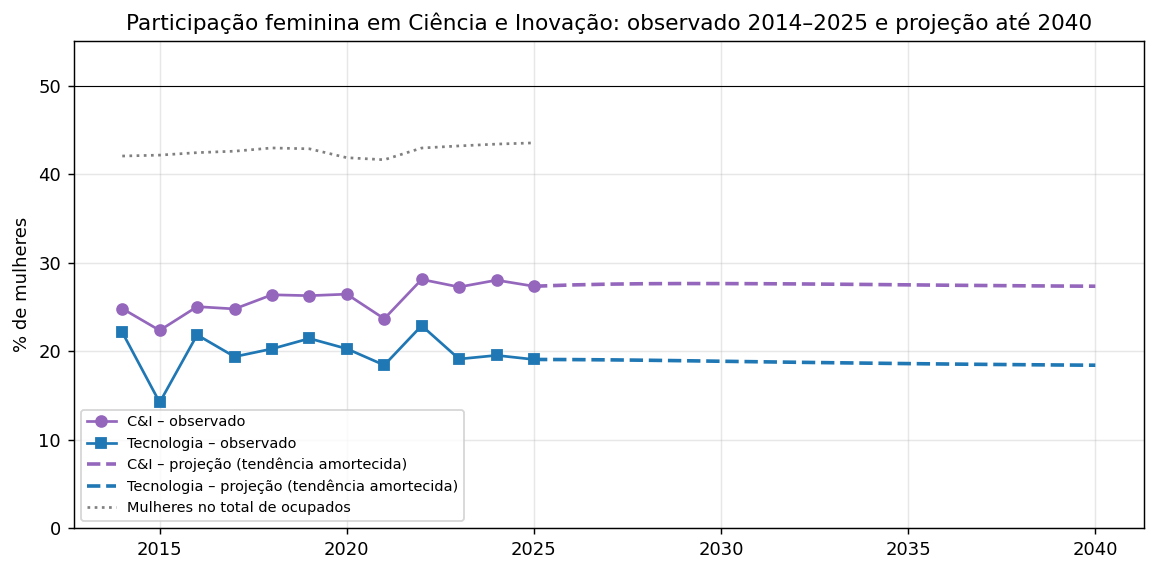

In [ ]:
# ---------- Quando chega a paridade? Extrapolação linear simples da % de mulheres (2014–2025, sem pandemia) ----------
def anos_ate_paridade(serie_pct):
    s = serie_pct.drop(index=[2020, 2021], errors='ignore')
    a, b = np.polyfit(s.index.values, s.values, 1)
    ano_50 = (50 - b) / a if a > 0 else np.inf
    return a, ano_50

serie_tec = ci[ci.subarea == 'Tecnologia'].groupby('Ano').apply(lambda d: pct(d, d.mulher), include_groups=False)
for nome, s in [('C&I', serie_ci['% mulheres']), ('Tecnologia', serie_tec)]:
    a, ano_50 = anos_ate_paridade(s)
    print(f"{nome:11s}: +{a:.2f} ponto/ano  →  50% de mulheres por volta de {ano_50:.0f}")

# ---------- Gráfico ----------
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(serie_ci.index, serie_ci['% mulheres'], 'o-', color='tab:purple', label='C&I – observado')
ax.plot(serie_tec.index, serie_tec.values, 's-', color='tab:blue', label='Tecnologia – observado')
for grupo, cor in [('C&I', 'tab:purple'), ('Tecnologia', 'tab:blue')]:
    t = resumo_gen[(resumo_gen.grupo == grupo) & (resumo_gen.regime == 'Tendência amortecida')]
    ax.plot(t.ano, t['% mulheres'], '--', color=cor, lw=2, label=f'{grupo} – projeção (tendência amortecida)')
ax.plot(serie_ci.index, serie_ci['% mulheres – todos os ocupados'], ':', color='gray',
        label='Mulheres no total de ocupados')
ax.axhline(50, color='black', lw=0.6)
ax.set_ylim(0, 55); ax.set_ylabel('% de mulheres'); ax.grid(alpha=.3); ax.legend(fontsize=8)
ax.set_title('Participação feminina em Ciência e Inovação: observado 2014–2025 e projeção até 2040')
plt.tight_layout(); plt.show()

## Parte 9 — Auditoria setorial sistemática (CNAE-Domiciliar, V4013)

**Revisão setorial (V4013): o que já foi feito e o que falta**
A auditoria que já existe no notebook de clusters (células 83–85) olhou seis casos de fronteira escolhidos à mão: veterinários, engenheiros civis, agrônomos, técnicos de TIC, economistas e motoristas. Ela resolveu todos sem precisar de regras condicionais.

O que o relatório pede agora é estender a auditoria a todas as famílias, de forma sistemática, para encontrar casos de fronteira que ninguém escolheu olhar.

A ideia: um índice de "alinhamento setorial"

Para cada família, a pergunta é: que parte dos seus trabalhadores está em setores que combinam com a âncora onde ela foi colocada?

Para isso, a célula monta um mapa de afinidade entre as divisões da CNAE (os 2 primeiros dígitos da V4013) e as âncoras. Por exemplo:

divisões 01–03 (agropecuária) → Agropecuária e Pesca;
49–53 (transporte) → Transporte e Logística;
86 (saúde) → Saúde e Cuidados;
85 (educação) → Educação;
97 (serviços domésticos) → Cuidados.

Uma família com alinhamento baixo pode estar na âncora errada, ou pode ser uma ocupação que trabalha em muitos setores.

Duas âncoras ficam fora do alerta, por construção: Administração e Gestão e Segurança e Defesa. São ocupações transversais: toda empresa tem RH, contabilidade e vigilância. A auditoria anterior já concluiu isso, e o índice baixo delas não indica erro.

Base: 2023–2025 agrupados, para ter amostra suficiente por família.

In [ ]:
#INdice de alinhamento
# Recarrega se o Colab tiver reiniciado
if 'ocup' not in globals():
    ocup = pd.read_parquet(pasta + 'checkpoint_base_v2.parquet')
    ocup['Ano'] = ocup['Ano'].astype(int)
    ocup['V4010'] = ocup['V4010'].astype(str).str.zfill(4)
if 'cw' not in globals():
    cw = pd.read_csv(pasta + 'familias_COD_ancoras_final.csv', sep=';', dtype={'cod_familia': str})
    cw['cod_familia'] = cw['cod_familia'].str.zfill(4)

# ---------- Mapa: divisão CNAE-Domiciliar (2 dígitos) → âncora(s) de afinidade natural ----------
def ancoras_do_setor(div):
    d = int(div) if str(div).isdigit() else -1
    if 1 <= d <= 3:    return {'Agropecuária e Pesca'}
    if 5 <= d <= 43:   return {'Indústria, Produção e Infraestrutura'}      # extrativa, transformação, utilidades, construção
    if d == 45:        return {'Comércio, Serviços e Lazer', 'Indústria, Produção e Infraestrutura'}  # comércio e reparação de veículos
    if 46 <= d <= 48:  return {'Comércio, Serviços e Lazer'}                # comércio (na CNAE-Dom, 48)
    if 49 <= d <= 53:  return {'Transporte e Logística'}
    if 55 <= d <= 56:  return {'Comércio, Serviços e Lazer'}                # alojamento e alimentação
    if 58 <= d <= 60:  return {'Humanidades e Cultura'}                     # edição, audiovisual, rádio e TV
    if 61 <= d <= 63:  return {'Ciência e Inovação'}                        # telecom e TI
    if 64 <= d <= 70:  return {'Administração e Gestão'}                    # finanças, imobiliárias, jurídico, contábil, consultoria
    if 71 <= d <= 72:  return {'Ciência e Inovação'}                        # engenharia, P&D
    if 73 <= d <= 74:  return {'Humanidades e Cultura'}                     # publicidade, design
    if d == 75:        return {'Comércio, Serviços e Lazer'}                # veterinária (decisão do crosswalk)
    if d in (77, 78, 82): return {'Administração e Gestão'}                 # aluguéis, RH terceirizado, apoio administrativo
    if d == 79:        return {'Comércio, Serviços e Lazer'}                # agências de viagem e turismo
    if d == 80:        return {'Segurança e Defesa'}                        # vigilância e segurança privada
    if d == 81:        return {'Comércio, Serviços e Lazer'}                # limpeza e conservação de edifícios
    if d == 84:        return {'Administração e Gestão', 'Segurança e Defesa'}
    if d == 85:        return {'Educação'}
    if d == 86:        return {'Saúde', 'Cuidados'}
    if 87 <= d <= 88:  return {'Cuidados'}                                  # assistência social, residencial
    if 90 <= d <= 93:  return {'Humanidades e Cultura', 'Comércio, Serviços e Lazer'}
    if 94 <= d <= 96:  return {'Comércio, Serviços e Lazer'}
    if d == 97:        return {'Cuidados'}                                  # serviços domésticos
    return set()

TRANSVERSAIS = {'Administração e Gestão', 'Segurança e Defesa'}   # "overhead" da economia, por construção

# ---------- Base: 2023–2025 agrupados (amostra suficiente por família) ----------
aud_base = ocup[(ocup.Ano >= 2023) & ocup.ancora.notna() & ~ocup.ancora.astype(str).str.contains('carve', na=False)].copy()
aud_base['div'] = aud_base.V4013.astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(5).str[:2]
aud_base['alinhado'] = [a in ancoras_do_setor(d) for a, d in zip(aud_base.ancora, aud_base['div'])]

def auditoria(g):
    massa = g.groupby('div')['V1032'].sum().sort_values(ascending=False)
    return pd.Series({
        'n (2023–25)':        len(g),
        'ocupados (mil/ano)': g.V1032.sum() / 3 / 1e3,
        '% alinhado à âncora': 100 * g.V1032[g.alinhado].sum() / g.V1032.sum(),
        'setor dominante':     massa.index[0],
        '% no dominante':      100 * massa.iloc[0] / massa.sum(),
        '2º setor':            massa.index[1] if len(massa) > 1 else '',
        '% no 2º':             100 * massa.iloc[1] / massa.sum() if len(massa) > 1 else 0,
    })

aud_fam = (aud_base.groupby(['ancora', 'nivel', 'V4010'])
                   .apply(auditoria, include_groups=False).reset_index())
aud_fam = aud_fam.merge(cw[['cod_familia', 'nome_familia']], left_on='V4010', right_on='cod_familia', how='left')
aud_fam['transversal'] = aud_fam.ancora.isin(TRANSVERSAIS)

# ---------- Visão por âncora: quanto da âncora trabalha em setores "seus"? ----------
resumo_anc = (aud_base.groupby('ancora')
              .apply(lambda g: 100 * g.V1032[g.alinhado].sum() / g.V1032.sum(), include_groups=False)
              .rename('% alinhado').sort_values())
print("=== % dos ocupados de cada âncora em setores de afinidade natural (2023–25) ===")
display(resumo_anc.round(1).to_frame())

=== % dos ocupados de cada âncora em setores de afinidade natural (2023–25) ===


,% alinhado
ancora,
Administração e Gestão,43.3
Ciência e Inovação,45.7
Humanidades e Cultura,61.0
Transporte e Logística,62.3
Saúde,68.6
Segurança e Defesa,70.9
"Comércio, Serviços e Lazer",74.5
Cuidados,78.0
"Indústria, Produção e Infraestrutura",82.1


In [ ]:
# ---------- Candidatas à revisão: baixo alinhamento, amostra suficiente, âncora não transversal ----------
pd.set_option('display.max_rows', 200)
LIMIAR_ALINH, N_MIN = 30, 100

candidatas = (aud_fam[(~aud_fam.transversal) &
                      (aud_fam['% alinhado à âncora'] < LIMIAR_ALINH) &
                      (aud_fam['n (2023–25)'] >= N_MIN)]
              .sort_values('ocupados (mil/ano)', ascending=False))

cols = ['ancora', 'nivel', 'V4010', 'nome_familia', 'n (2023–25)', 'ocupados (mil/ano)',
        '% alinhado à âncora', 'setor dominante', '% no dominante', '2º setor', '% no 2º']
print(f"Famílias candidatas à revisão: {len(candidatas)} "
      f"(de {(~aud_fam.transversal & (aud_fam['n (2023–25)'] >= N_MIN)).sum()} com amostra suficiente)")
display(candidatas[cols].round(1))

aud_fam.to_excel(pasta + 'auditoria_setorial_V4013.xlsx', index=False)
print("✓ auditoria completa salva em auditoria_setorial_V4013.xlsx")

Famílias candidatas à revisão: 48 (de 264 com amostra suficiente)


,ancora,nivel,V4010,nome_familia,n (2023–25),ocupados (mil/ano),% alinhado à âncora,setor dominante,% no dominante,2º setor,% no 2º
223,Cuidados,Especialista,2342,Professores do ensino pré-escolar,4121,799.9,0.0,85,100.0,,0.0
169,"Comércio, Serviços e Lazer",Básico/Operacional,8153,Operadores de máquinas de costura,3674,761.9,2.0,14,87.0,15,5.3
210,Cuidados,Básico/Operacional,5312,Ajudantes de professores,2517,483.8,0.0,85,100.0,,0.0
162,"Comércio, Serviços e Lazer",Básico/Operacional,7531,"Alfaiates, modistas, chapeleiros e peleteiros",2430,465.9,1.9,14,95.6,13,1.4
201,"Comércio, Serviços e Lazer",Técnico,3334,Agentes imobiliários,1725,383.3,0.0,68,98.6,69,0.8
415,Transporte e Logística,Básico/Operacional,8344,Operadores de empilhadeiras,1231,303.0,15.7,48,18.8,10,10.8
305,"Indústria, Produção e Infraestrutura",Básico/Operacional,7422,Instaladores e reparadores em tecnologias da i...,1307,298.0,7.4,95,49.6,61,28.6
369,"Indústria, Produção e Infraestrutura",Técnico,3513,Técnicos de redes e sistemas de computadores,1147,273.2,11.4,62,41.4,61,14.2
153,"Comércio, Serviços e Lazer",Básico/Operacional,7318,"Artesãos de tecidos, couros e materiais semelh...",1312,234.8,2.7,13,81.3,15,12.3
182,"Comércio, Serviços e Lazer",Básico/Operacional,9611,Coletores de lixo e material reciclável,1295,230.9,16.5,84,47.4,38,30.7


✓ auditoria completa salva em auditoria_setorial_V4013.xlsx


In [ ]:
q = sintese.copy()
q.loc['TOTAL'] = q.sum()
print("=== Cenários de política, ocupados em 2040 (milhões) ===")
display(q.round(3))

o25 = ocup[ocup.Ano == 2025]
frac_pub = (o25[o25.setor_publico.astype(str).str.startswith('Púb')].groupby('ancora')['V1032'].sum()
            / o25.groupby('ancora')['V1032'].sum()).fillna(0)
frac_niv = (o25.groupby(['ancora', 'nivel'])['V1032'].sum()
            / o25.groupby('ancora')['V1032'].sum())
print("\nFração no setor público (2025), por âncora:"); print(frac_pub.round(3))
print("\nAdministração e Gestão – fração Básico/Operacional:",
      round(frac_niv.get(('Administração e Gestão', 'Básico/Operacional'), 0), 3))

=== Cenários de política, ocupados em 2040 (milhões) ===


cenário de política,base,IA_moderado,IA_forte,PNC_moderado,PNC_forte,Fiscal_moderado,Fiscal_forte,combinado_mod
ancora,,,,,,,,
Administração e Gestão,15.361,14.135,12.910,15.361,15.361,15.126,14.892,13.920
Agropecuária e Pesca,7.235,7.235,7.235,7.235,7.235,7.235,7.235,7.235
Ciência e Inovação,2.528,2.528,2.528,2.528,2.528,2.528,2.528,2.528
"Comércio, Serviços e Lazer",33.661,33.156,32.651,33.661,33.661,33.661,33.661,33.156
Cuidados,11.744,11.744,11.744,12.918,14.093,11.516,11.289,12.668
Educação,3.781,3.781,3.781,3.781,3.781,3.594,3.407,3.594
Humanidades e Cultura,1.245,1.189,1.133,1.245,1.245,1.245,1.245,1.189
"Indústria, Produção e Infraestrutura",18.550,18.550,18.550,18.550,18.550,18.550,18.550,18.550
Saúde,2.741,2.741,2.741,2.741,2.741,2.686,2.632,2.686



Fração no setor público (2025), por âncora:
ancora
Administração e Gestão                  0.204
Agropecuária e Pesca                    0.004
Ciência e Inovação                      0.104
Comércio, Serviços e Lazer              0.038
Cuidados                                0.258
Educação                                0.659
Humanidades e Cultura                   0.064
Indústria, Produção e Infraestrutura    0.021
Saúde                                   0.267
Segurança e Defesa                      0.502
Transporte e Logística                  0.051
carve-out, sem projeção                 1.000
Name: V1032, dtype: float64

Administração e Gestão – fração Básico/Operacional: 0.532


## Parte 10 — Cenário de escolarização juvenil (14–24 anos)

**O cenário de escolarização juvenil**
O cenário de escolarização juvenil

"sem esse refinamento, o modelo corre o risco de tratar como puramente demográfica uma dinâmica que é, em parte, de política educacional".

O problema, em uma frase

A camada 1 congela a taxa de ocupação dos jovens de 2025. Isso embute como permanente, por exemplo, que parte dos jovens de 15–17 anos trabalha em vez de estudar, ou que uma fração de 18–24 não estuda nem trabalha. Mas essas proporções são resultado de política educacional, e podem mudar.

Como montar o cenário

A ideia é separar os jovens de 14 a 24 anos em quatro situações, e não só em "ocupado" e "não ocupado":

Situação	O que significa para a projeção
Só estuda	fora do mercado agora, mas entra mais tarde e mais escolarizado
Estuda e trabalha	ocupado, geralmente em tempo parcial e em nível Básico
Só trabalha	ocupado, muitas vezes com evasão escolar precoce
Nem estuda nem trabalha	fora dos dois; o grupo que a política mais quer reduzir

Com isso, dá para desenhar cenários concretos:

Base: as proporções de 2025 ficam congeladas. É o que o modelo faz hoje, implicitamente.
Permanência ampliada: metas de política educacional se cumprem. Mais jovens de 15–17 anos só estudando, menos "nem-nem" em 18–24. Efeito: a ocupação juvenil cai no curto prazo, mas essas coortes entram depois, mais escolarizadas, em níveis mais altos (Técnico, Especialista).
Retração ou represamento: a evasão e os "nem-nem" aumentam. Efeito: entrada precoce e informal no nível Básico.


Os dados da juventude dizem que os dois grupos etários estão em situações muito diferentes, e isso orienta o desenho dos cenários.

14 a 17 anos: melhora forte e contínua
14–17 anos	2014	2019	2025
Só estuda	74,7%	81,0%	83,2%
Estuda e trabalha	12,6%	9,7%	10,3%
Só trabalha	4,4%	2,4%	2,0%
Nem estuda nem trabalha	8,2%	6,9%	4,6%
Frequenta escola (total)	87,3%	90,7%	93,5%

A frequência escolar subiu de 87% para 94%, e os que estão fora da escola (só trabalham ou nem-nem) caíram pela metade, de 12,6% para 6,6%. Já estamos perto da universalização, que era a meta 3 do PNE de 2014 (Lei 13.005/2014) para os 15–17 anos. A margem restante é de ~6,6 pontos: uns 400 mil jovens.

18 a 24 anos: estagnação na escola, e o nem-nem só caiu com o mercado de trabalho
18–24 anos	2014	2019	2020	2025
Só estuda	16,1%	17,1%	20,6%	15,2%
Estuda e trabalha	14,4%	14,0%	12,0%	16,3%
Só trabalha	44,2%	39,5%	33,3%	44,9%
Nem estuda nem trabalha	25,4%	29,4%	34,1%	23,6%
Frequenta escola	30,5%	31,1%	32,6%	31,5%
A frequência escolar dos 18–24 anos não saiu do lugar em 11 anos: cerca de 31%.
O nem-nem subiu com a crise (de 25% em 2014 para 30% em 2016–19 e 34% em 2020) e caiu com a recuperação do emprego, para 24% em 2025. A queda veio pela via do trabalho, não da escola.
Três quartos dos nem-nem estão fora da força de trabalho: 3,7 milhões não procuram emprego, contra 1,3 milhão de desocupados em 2025. Os desocupados caíram de 3,1 milhões (2020) para 1,3 milhão, e os que estão fora da força ficaram praticamente parados (~3,7–4,2 milhões). Esse é o núcleo duro, e não se resolve só com crescimento econômico.

Para o texto: "A política educacional brasileira praticamente universalizou a escolarização dos 14–17 anos, mas não alterou a trajetória dos 18–24: sua frequência escolar permanece em torno de 31% desde 2014. A redução recente dos jovens que não estudam nem trabalham deveu-se à recuperação do emprego, e não à escola; o núcleo de cerca de 3,7 milhões fora da força de trabalho mostrou-se insensível ao ciclo."

Os cenários, agora com parâmetros ancorados nos dados

Um ponto importante para o avaliador: tirar um jovem do nem-nem não reduz necessariamente a ocupação. Depende de para onde ele vai: se vai para "só estuda", a ocupação não muda; se vai para "estuda e trabalha", ela aumenta. Por isso cada cenário precisa dizer para onde vão os jovens.

Cenário (meta em 2040, rampa linear a partir de 2027)	14–17 anos	18–24 anos
Base	distribuição de 2025 congelada (equivale à camada 1)	idem
Permanência ampliada	universalização: só trabalha → 0; nem-nem → 2%. Os dois vão para "só estuda"	nem-nem 23,6% → 15% (metade para "só estuda", metade para "estuda e trabalha"); só trabalha 44,9% → 40% (vão para "estuda e trabalha")
Retração	volta à média de 2016–19, o período recente mais desfavorável	volta à média de 2016–19 (nem-nem ~30%)

In [ ]:
# Preparação (caso o Colab tenha reiniciado)
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd, numpy as np
pasta = '/content/drive/MyDrive/Colab Notebooks/'

jov = pd.read_parquet(pasta + 'pnadc_jovens_14a24_2014_2025.parquet')
for c in ['Ano', 'V2009', 'V1032', 'V3002', 'VD4001', 'VD4002', 'VD3004', 'V2007']:
    jov[c] = pd.to_numeric(jov[c], errors='coerce')
jov['Ano'] = jov['Ano'].astype(int)

# ---------- As quatro situações ----------
estuda   = jov.V3002 == 1            # frequenta escola/curso (1 = sim)
trabalha = jov.VD4002 == 1           # ocupado
jov['situacao'] = np.select(
    [estuda & ~trabalha, estuda & trabalha, ~estuda & trabalha, ~estuda & ~trabalha],
    ['Só estuda', 'Estuda e trabalha', 'Só trabalha', 'Nem estuda nem trabalha'], default='?')
# nem-nem: desocupado (procura trabalho) × fora da força de trabalho
jov['nemnem_tipo'] = np.where(jov.situacao != 'Nem estuda nem trabalha', None,
                              np.where(jov.VD4002 == 2, 'nem-nem desocupado', 'nem-nem fora da força'))
jov['faixa'] = pd.cut(jov.V2009, bins=[13, 17, 24], labels=['14–17', '18–24'])

print("Conferência – registros por ano e sem V3002:")
display(jov.groupby('Ano').agg(n=('V1032', 'size'), sem_V3002=('V3002', lambda s: s.isna().sum())).T)

# ---------- Série 2014–2025: distribuição (%) por faixa ----------
ORDEM = ['Só estuda', 'Estuda e trabalha', 'Só trabalha', 'Nem estuda nem trabalha']
dist = (jov.groupby(['faixa', 'Ano', 'situacao'], observed=True)['V1032'].sum()
           .groupby(level=['faixa', 'Ano']).transform(lambda s: 100 * s / s.sum())
           .unstack('situacao')[ORDEM])
for f in ['14–17', '18–24']:
    print(f"\n=== {f} anos: distribuição (%) ===")
    display(dist.loc[f].round(1).T)

# ---------- Nem-nem: desocupados × fora da força ----------
nn = (jov[jov.situacao == 'Nem estuda nem trabalha']
        .groupby(['faixa', 'Ano', 'nemnem_tipo'], observed=True)['V1032'].sum()
        .unstack('nemnem_tipo') / 1e3)
print("\n=== Nem-nem (mil pessoas) ===")
display(nn.round(0).unstack('faixa'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Conferência – registros por ano e sem V3002:


Ano,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
n,86354,84506,83690,82503,79238,76282,58519,54313,60312,59988,58210,60182
sem_V3002,0,0,0,0,0,0,0,0,0,0,0,0



=== 14–17 anos: distribuição (%) ===


Ano,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
situacao,,,,,,,,,,,,
Só estuda,74.7,75.8,80.0,80.0,80.5,81.0,86.0,86.9,81.3,83.0,83.3,83.2
Estuda e trabalha,12.6,12.6,9.3,9.5,9.7,9.7,6.9,7.6,11.5,10.2,10.7,10.3
Só trabalha,4.4,3.6,2.7,2.9,2.4,2.4,1.3,1.0,2.2,2.2,1.9,2.0
Nem estuda nem trabalha,8.2,8.0,8.0,7.6,7.3,6.9,5.8,4.6,4.9,4.6,4.1,4.6



=== 18–24 anos: distribuição (%) ===


Ano,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
situacao,,,,,,,,,,,,
Só estuda,16.1,16.0,17.5,17.5,17.7,17.1,20.6,20.3,15.8,15.0,15.1,15.2
Estuda e trabalha,14.4,14.1,13.2,13.6,13.6,14.0,12.0,13.3,14.3,14.8,15.0,16.3
Só trabalha,44.2,42.3,38.8,38.7,38.2,39.5,33.3,35.3,43.4,44.1,45.7,44.9
Nem estuda nem trabalha,25.4,27.6,30.5,30.2,30.5,29.4,34.1,31.1,26.5,26.1,24.2,23.6



=== Nem-nem (mil pessoas) ===


nemnem_tipo nem-nem desocupado         nem-nem fora da força        
faixa                    14–17   18–24                 14–17   18–24
Ano                                                                 
2014                     158.0  1756.0                 979.0  4204.0
2015                     182.0  2267.0                 904.0  4236.0
2016                     212.0  2926.0                 862.0  4229.0
2017                     190.0  3067.0                 805.0  4052.0
2018                     200.0  2978.0                 735.0  4178.0
2019                     165.0  2922.0                 698.0  3951.0
2020                     143.0  3106.0                 590.0  4737.0
2021                      85.0  3078.0                 481.0  3980.0
2022                      93.0  2068.0                 506.0  3888.0
2023                      81.0  1783.0                 471.0  3990.0
2024                      68.0  1491.0                 420.0  3740.0
2025                      54.0  1340.0                 481.0  3715.0

### 10.1 Projeção dos cenários

In [ ]:
pop_longo = pd.read_parquet(pasta + 'projecoes_ibge_longo.parquet')
pop_longo['idade'] = pop_longo['idade'].astype(str).str.replace('+', '', regex=False).astype(int)
pop_j = (pop_longo[pop_longo.idade.between(14, 24)]
         .assign(faixa=lambda d: np.where(d.idade <= 17, '14–17', '18–24'))
         .groupby(['ano', 'faixa'])['populacao'].sum().unstack())

base25 = dist.xs(2025, level='Ano')                                   # % em 2025
ruim   = dist[dist.index.get_level_values('Ano').isin([2016, 2017, 2018, 2019])] \
             .groupby(level='faixa', observed=True).mean()            # média 2016–19

alvo = {
  'Base': base25,
  'Permanência ampliada': pd.DataFrame({
      'Só estuda':               {'14–17': 100 - base25.loc['14–17', 'Estuda e trabalha'] - 2.0, '18–24': base25.loc['18–24', 'Só estuda'] + 4.3},
      'Estuda e trabalha':       {'14–17': base25.loc['14–17', 'Estuda e trabalha'],
                                  '18–24': base25.loc['18–24', 'Estuda e trabalha'] + 4.3 + (base25.loc['18–24', 'Só trabalha'] - 40.0)},
      'Só trabalha':             {'14–17': 0.0,  '18–24': 40.0},
      'Nem estuda nem trabalha': {'14–17': 2.0,  '18–24': 15.0}})[ORDEM],
  'Retração': ruim[ORDEM],
}
print("Metas de 2040 (%):"); display(pd.concat(alvo).round(1))

def rampa(ano, ini=2027, fim=2040):
    return float(np.clip((ano - ini + 1) / (fim - ini + 1), 0, 1))

linhas = []
for cen, meta in alvo.items():
    for ano in range(2025, 2041):
        for f in ['14–17', '18–24']:
            s = base25.loc[f] + rampa(ano) * (meta.loc[f] - base25.loc[f])   # % no ano
            n = s / 100 * pop_j.loc[ano, f] / 1e3                             # mil pessoas
            linhas.append({'cenário': cen, 'ano': ano, 'faixa': f,
                           'população': pop_j.loc[ano, f] / 1e3,
                           'estudando': n['Só estuda'] + n['Estuda e trabalha'],
                           'ocupados':  n['Estuda e trabalha'] + n['Só trabalha'],
                           'nem-nem':   n['Nem estuda nem trabalha']})
proj_j = pd.DataFrame(linhas)

r40 = proj_j[proj_j.ano == 2040].groupby(['cenário', 'faixa'])[['população', 'estudando', 'ocupados', 'nem-nem']].sum()
for c in ['estudando', 'ocupados', 'nem-nem']:
    r40[f'Δ {c} vs base'] = r40[c] - r40.xs('Base', level='cenário').reindex(r40.index, level='faixa')[c].values
print("\n=== 2040 (mil pessoas) ===")
display(r40.round(0))
print("\n=== 2025 (ponto de partida, mil pessoas) ===")
display(proj_j[(proj_j.ano == 2025) & (proj_j['cenário'] == 'Base')].set_index('faixa')[['população', 'estudando', 'ocupados', 'nem-nem']].round(0))

Metas de 2040 (%):


Só estuda  Estuda e trabalha  Só trabalha  \
                     faixa                                              
Base                 14–17       83.2               10.3          2.0   
                     18–24       15.2               16.3         44.9   
Permanência ampliada 14–17       87.7               10.3          0.0   
                     18–24       19.5               25.5         40.0   
Retração             14–17       80.4                9.6          2.6   
                     18–24       17.5               13.6         38.8   

                            Nem estuda nem trabalha  
                     faixa                           
Base                 14–17                      4.6  
                     18–24                     23.6  
Permanência ampliada 14–17                      2.0  
                     18–24                     15.0  
Retração             14–17                      7.5  
                     18–24                     30.1


=== 2040 (mil pessoas) ===


população  estudando  ocupados  nem-nem  \
cenário              faixa                                            
Base                 14–17     9758.0     9122.0    1193.0    446.0   
                     18–24    19432.0     6128.0   11890.0   4582.0   
Permanência ampliada 14–17     9758.0     9563.0    1002.0    195.0   
                     18–24    19432.0     8748.0   12725.0   2915.0   
Retração             14–17     9758.0     8778.0    1186.0    728.0   
                     18–24    19432.0     6038.0   10182.0   5854.0   

                            Δ estudando vs base  Δ ocupados vs base  \
cenário              faixa                                            
Base                 14–17                  0.0                 0.0   
                     18–24                  0.0                 0.0   
Permanência ampliada 14–17                441.0              -191.0   
                     18–24               2620.0               836.0   
Retração             14–17               -344.0                -7.0   
                     18–24                -90.0             -1708.0   

                            Δ nem-nem vs base  
cenário              faixa                     
Base                 14–17                0.0  
                     18–24                0.0  
Permanência ampliada 14–17             -251.0  
                     18–24            -1667.0  
Retração             14–17              282.0  
                     18–24             1272.0


=== 2025 (ponto de partida, mil pessoas) ===


,população,estudando,ocupados,nem-nem
faixa,,,,
14–17,11647.0,10888.0,1424.0,532.0
18–24,21611.0,6815.0,13222.0,5096.0


## Parte 11 — Cuidados

*A desenvolver.* Base: a âncora **Cuidados** (25 famílias), com a tag `circulo` separando cuidado em saúde e cuidado educativo, em diálogo com Guimarães & Pinheiro (2023) e Almeida (tese).

In [ ]:
# ===== 11.0 BASE DO CUIDADO =====
# Recarrega o parquet original (o checkpoint não tem VD4012)
cw = pd.read_csv(pasta + 'familias_COD_ancoras_final.csv', sep=';', dtype={'cod_familia': str})
cw['cod_familia'] = cw['cod_familia'].str.zfill(4)

base = pd.read_parquet(pasta + 'pnadc_2014_2025.parquet')
base = base[base['VD4002'] == 'Pessoas ocupadas'].copy()
base['Ano'] = base['Ano'].astype(int)
base['V4010'] = base['V4010'].astype(str).str.zfill(4)
base = base.merge(cw[['cod_familia', 'nome_familia', 'ancora', 'nivel', 'circulo']],
                  left_on='V4010', right_on='cod_familia', how='left')

# Variáveis de perfil
base['sexo'] = base['V2007'].astype(str).replace({'Masculino': 'Homem', 'Feminino': 'Mulher'})
base['mulher'] = base['sexo'] == 'Mulher'
raca = base['V2010'].astype(str)
base['negra'] = raca.isin(['Preta', 'Parda'])
base['branca'] = raca == 'Branca'
vd = base['VD4009'].astype(str).str.lower()
base['formal_contrib'] = base['VD4012'].astype(str) == 'Contribuinte'
base['formal_vinculo'] = vd.str.contains('com carteira') | vd.str.startswith('militar')
base['publico'] = vd.str.contains('setor público') | vd.str.startswith('militar')
base['grupo'] = np.select(
    [base.mulher & base.negra, base.mulher & base.branca, ~base.mulher & base.negra, ~base.mulher & base.branca],
    ['Mulheres negras', 'Mulheres brancas', 'Homens negros', 'Homens brancos'], default='Outros')

# Função de perfil usada em toda a Parte 11
def perfil(d):
    w = d['V1032']
    t = w.sum()
    s = pd.Series(dtype=float)
    s['ocupados (mi)'] = t / 1e6
    s['% mulheres'] = 100 * w[d.mulher].sum() / t
    s['% mulheres negras'] = 100 * w[d.mulher & d.negra].sum() / t
    s['% formal (contribui)'] = 100 * w[d.formal_contrib].sum() / t
    s['% formal (vínculo)'] = 100 * w[d.formal_vinculo].sum() / t
    s['% setor público'] = 100 * w[d.publico].sum() / t
    s['idade média'] = (d['V2009'].astype(float) * w).sum() / t
    s['n amostra'] = len(d)
    return s

print(f"Ocupados (registros): {len(base):,} | sem âncora: {base.ancora.isna().sum():,} (código 0000)")
print("Cuidados 2025 (mi):", round(base[(base.ancora == 'Cuidados') & (base.Ano == 2025)].V1032.sum() / 1e6, 2))
print("Renda (VD4016) disponível?", 'VD4016' in base.columns)

Ocupados (registros): 2,137,544 | sem âncora: 1,034 (código 0000)
Cuidados 2025 (mi): 10.82
Renda (VD4016) disponível? True


Célula 11.1 — os quatro blocos da âncora Cuidados. Primeiro ela mostra a lista de famílias por bloco, para você conferir a divisão; depois monta o perfil de cada bloco e o gráfico da evolução.

,cod_familia,nome_familia,nivel,circulo,bloco
22,1344,Dirigentes de serviços de bem-estar social,Direção,NaN,Assistência social
111,2635,Assistentes sociais,Especialista,NaN,Assistência social
191,3412,Trabalhadores e assistentes sociais de nível m...,Técnico,NaN,Assistência social
19,1341,Dirigentes de serviços de cuidados infantis,Direção,NaN,Educativo (infantil/especial)
74,2342,Professores do ensino pré-escolar,Especialista,educacao,Educativo (infantil/especial)
76,2352,Educadores para necessidades especiais,Especialista,educacao,Educativo (infantil/especial)
268,5312,Ajudantes de professores,Básico/Operacional,educacao,Educativo (infantil/especial)
21,1343,Dirigentes de serviços de cuidado a pessoas id...,Direção,NaN,Pessoal e doméstico
245,5152,Governantas e mordomos domésticos,Básico/Operacional,NaN,Pessoal e doméstico
248,5162,Acompanhantes e criados particulares,Básico/Operacional,NaN,Pessoal e doméstico


Registros sem bloco: 0


ocupados (mi)  % mulheres  \
Ano  bloco                                                      
2014 Assistência social                       0.2        79.3   
     Educativo (infantil/especial)            0.7        92.2   
     Pessoal e doméstico                      6.4        94.3   
     Saúde                                    1.7        79.1   
2019 Assistência social                       0.2        81.4   
     Educativo (infantil/especial)            1.0        93.1   
     Pessoal e doméstico                      6.3        93.6   
     Saúde                                    2.3        81.0   
2025 Assistência social                       0.2        78.4   
     Educativo (infantil/especial)            1.5        90.8   
     Pessoal e doméstico                      6.1        93.2   
     Saúde                                    3.0        81.2   

                                    % mulheres negras  % formal (contribui)  \
Ano  bloco                                                                    
2014 Assistência social                          36.9                  89.6   
     Educativo (infantil/especial)               43.3                  87.5   
     Pessoal e doméstico                         59.1                  44.0   
     Saúde                                       34.8                  92.7   
2019 Assistência social                          43.6                  89.1   
     Educativo (infantil/especial)               48.0                  86.4   
     Pessoal e doméstico                         61.2                  40.1   
     Saúde                                       39.1                  90.5   
2025 Assistência social                          42.6                  91.1   
     Educativo (infantil/especial)               49.5                  86.9   
     Pessoal e doméstico                         62.5                  38.1   
     Saúde                                       41.7                  86.3   

                                    % formal (vínculo)  % setor público  \
Ano  bloco                                                                
2014 Assistência social                           66.7             79.1   
     Educativo (infantil/especial)                75.5             62.8   
     Pessoal e doméstico                          34.5              4.3   
     Saúde                                        75.8             56.1   
2019 Assistência social                           65.0             78.8   
     Educativo (infantil/especial)                72.1             64.3   
     Pessoal e doméstico                          29.1              3.2   
     Saúde                                        73.9             48.8   
2025 Assistência social                           69.2             75.5   
     Educativo (infantil/especial)                71.9             68.9   
     Pessoal e doméstico                          26.6              4.3   
     Saúde                                        65.4             43.6   

                                    idade média  n amostra  
Ano  bloco                                                  
2014 Assistência social                    38.8      483.0  
     Educativo (infantil/especial)         37.2     1399.0  
     Pessoal e doméstico                   40.5    13704.0  
     Saúde                                 38.0     3706.0  
2019 Assistência social                    39.9      447.0  
     Educativo (infantil/especial)         38.2     1997.0  
     Pessoal e doméstico                   42.3    13020.0  
     Saúde                                 40.0     4445.0  
2025 Assistência social                    42.4      479.0  
     Educativo (infantil/especial)         38.6     2619.0  
     Pessoal e doméstico                   44.2    11671.0  
     Saúde                                 40.3     5360.0

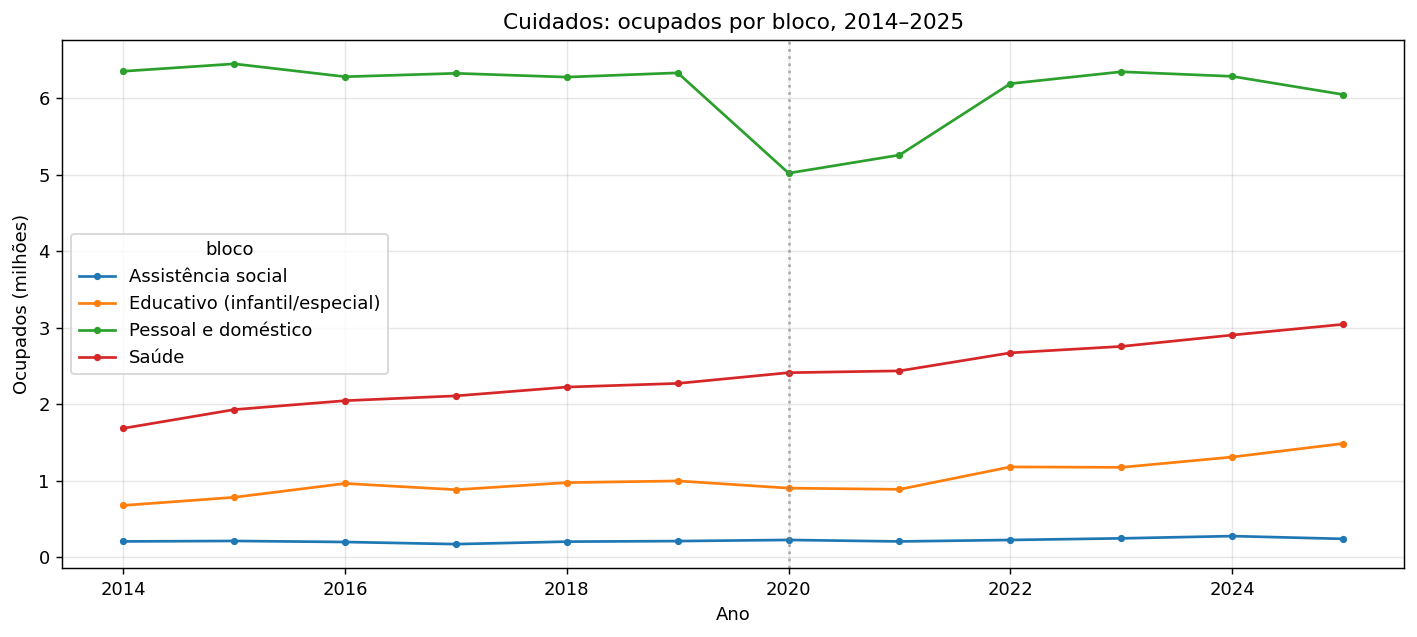

In [ ]:
# ===== 11.1 OS QUATRO BLOCOS DA ÂNCORA CUIDADOS =====
# Regra: tag 'saude' -> Saúde; tag 'educacao' ou 1341 -> Educativo;
#        1344, 2635, 3412 -> Assistência social; demais -> Pessoal e doméstico
ASSIST = ['1344', '2635', '3412']

def bloco_cuidado(cod, circ):
    if circ == 'saude':
        return 'Saúde'
    if circ == 'educacao' or cod == '1341':
        return 'Educativo (infantil/especial)'
    if cod in ASSIST:
        return 'Assistência social'
    return 'Pessoal e doméstico'

fam_cui = cw[cw.ancora == 'Cuidados'][['cod_familia', 'nome_familia', 'nivel', 'circulo']].copy()
fam_cui['bloco'] = [bloco_cuidado(c, k) for c, k in zip(fam_cui.cod_familia, fam_cui.circulo)]
display(fam_cui.sort_values(['bloco', 'cod_familia']))

cui = base[base.ancora == 'Cuidados'].merge(fam_cui[['cod_familia', 'bloco']], on='cod_familia', how='left')
print("Registros sem bloco:", cui.bloco.isna().sum())   # esperado: 0

# Perfil por bloco
tab_bloco = cui.groupby(['Ano', 'bloco']).apply(perfil, include_groups=False)
display(tab_bloco.loc[[2014, 2019, 2025]].round(1))

# Evolução
serie_bloco = cui.groupby(['Ano', 'bloco'])['V1032'].sum().unstack() / 1e6
fig, ax = plt.subplots(figsize=(11, 5))
serie_bloco.plot(ax=ax, marker='o', markersize=3)
ax.axvline(2020, color='grey', ls=':', alpha=0.6)
ax.set_title('Cuidados: ocupados por bloco, 2014–2025')
ax.set_ylabel('Ocupados (milhões)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

1. O cuidado é, antes de tudo, pessoal e doméstico. São 6,1 dos 10,8 milhões (56% da âncora). Saúde tem 3,0, Educativo 1,5 e Assistência social 0,2.

2. A hierarquia racial é nítida e está se aprofundando. Mulheres negras são 62,5% do bloco pessoal e doméstico, contra cerca de 42% em Saúde e Assistência e 49,5% no Educativo. A participação delas subiu em todos os blocos desde 2014, e mais no núcleo (59,1 → 62,5).

3. O núcleo do cuidado está se informalizando. No bloco pessoal e doméstico, a contribuição previdenciária caiu de 44% para 38%, e o vínculo formal de 34,5% para 26,6%. Isso qualifica a "passagem da criada à cuidadora": a ocupação muda de nome, mas não ganha proteção. A 11.2 vai mostrar se a queda vem dos domésticos ou das cuidadoras.

4. A Saúde cresce pela via privada e menos protegida. O bloco quase dobrou (1,7 → 3,0 mi), mas o setor público caiu de 56% para 44% e o vínculo formal de 76% para 65%. A expansão do cuidado em saúde se deu fora do emprego público e do assalariamento clássico, algo coerente com a leitura de que o SUS financia, mas contrata por terceiros.

5. O Educativo é a exceção: dobrou (0,7 → 1,5 mi) e ficou mais público (63% → 69%), com formalidade estável. É a assinatura da expansão das creches e da pré-escola públicas.

6. O núcleo envelhece mais rápido. A idade média do bloco pessoal e doméstico subiu quase quatro anos (40,5 → 44,2). A demanda por cuidado cresce com o envelhecimento, e a força de trabalho que o provê também envelhece: é a pergunta "quem cuidará?", que a 11.8 vai quantificar.

Uma cautela: Assistência social tem cerca de 480 casos por ano; serve para o perfil geral, mas não para cruzamentos finos.

Célula 11.2 — da criada à cuidadora. Série das sete famílias do bloco pessoal e doméstico, o choque de 2020 e a formalização dos domésticos (9111) depois da PEC das Domésticas:

Essa é a tabela mais reveladora até agora. A leitura:

1. A substituição existe, mas é menor que a perda. Domésticos em geral perderam 0,73 mi e o cuidado em instituições, 0,17 mi. Do outro lado, o cuidado a domicílio dobrou (0,36 → 0,74 mi, +0,39) e cuidadores de crianças ganharam 0,17. O saldo do bloco é negativo em cerca de 0,3 mi: a "cuidadora" não absorveu toda a "criada".

2. O crescimento foi para a forma menos protegida. Esse é o achado central:

Família	Contribui 2014 → 2025	Vínculo formal 2014 → 2025
Cuidado pessoal a domicílio (cresce)	46% → 35%	32% → 20%
Domésticos em geral (encolhe)	41% → 36%	32% → 24%
Cuidado pessoal em instituições (encolhe)	93% → 91%	86% → 82%

O emprego migrou do cuidado institucional, quase todo formal, e do doméstico para o cuidado domiciliar, que é o mais informal dos três e se informalizou ainda mais. A frase para a tese: a profissionalização do cuidado aconteceu no nome da ocupação, não na proteção do trabalho.

3. A PEC das Domésticas não reverteu a informalidade. Mesmo depois da LC 150/2015, o vínculo formal dos domésticos caiu de 32% para 24%. A hipótese mais provável é a troca da mensalista pela diarista, que fica fora da carteira; dá para testar depois com a VD4009.

4. A racialização do núcleo aumentou justamente onde cresce. Mulheres negras passaram de 49% para 60% no cuidado a domicílio e de 58% para 64% entre cuidadores de crianças.

5. O choque de 2020 e a recuperação desigual. Todas as famílias grandes caíram de 20% a 30%. O cuidado a domicílio se recuperou e passou do nível de 2019 já em 2022 (0,64 → 0,75); os domésticos nunca voltaram (4,59 em 2019, 4,10 em 2025).

Três cautelas de mensuração

O cuidado em instituições despenca de 0,27 para 0,09 entre 2014 e 2016 e fica estável depois. Uma queda de dois terços em dois anos parece mais mudança de codificação na PNAD do que fenômeno real. Para a tese, o mais seguro é somar instituições e domicílio como "cuidado de pessoas" (0,63 → 0,84 mi, +33%) e tratar a divisão interna com ressalva.
Os +430% de "Acompanhantes e criados" e os +16% de "Cuidado pessoal em saúde n.c.a." em 2020 são ruído: 4 a 7 casos e cerca de 90 casos na amostra, respectivamente.
Governantas também têm amostra pequena (20 a 51 casos).

V4010,Governantas e mordomos,Acompanhantes e criados,Cuidadores de crianças,Cuidado pessoal em instituições,Cuidado pessoal a domicílio,Cuidado pessoal em saúde n.c.a.,Domésticos em geral
Ano,,,,,,,
2014,0.01,0.00,0.84,0.27,0.36,0.04,4.83
2015,0.01,0.00,0.88,0.18,0.41,0.05,4.92
2016,0.01,0.00,0.83,0.09,0.50,0.07,4.78
2017,0.01,0.00,0.90,0.09,0.57,0.07,4.68
2018,0.03,0.00,0.91,0.07,0.62,0.06,4.60
2019,0.02,0.00,0.96,0.07,0.64,0.05,4.59
2020,0.02,0.01,0.73,0.05,0.49,0.06,3.68
2021,0.02,0.00,0.73,0.05,0.55,0.08,3.83
2022,0.01,0.00,1.02,0.09,0.75,0.06,4.26


Variação 2014–2025 (milhões):
V4010
Domésticos em geral               -0.73
Cuidado pessoal em instituições   -0.17
Acompanhantes e criados            0.00
Cuidado pessoal em saúde n.c.a.    0.01
Governantas e mordomos             0.02
Cuidadores de crianças             0.17
Cuidado pessoal a domicílio        0.39
dtype: float64

Choque 2019→2020 (%):
V4010
Cuidado pessoal em instituições    -30.4
Cuidadores de crianças             -24.5
Cuidado pessoal a domicílio        -24.2
Domésticos em geral                -19.9
Governantas e mordomos              -3.4
Cuidado pessoal em saúde n.c.a.     15.8
Acompanhantes e criados            430.7
dtype: float64


% contribui       % vínculo formal        \
Ano                                    2014  2025             2014  2025   
V4010                                                                      
Governantas e mordomos                 70.1  60.8             70.1  39.7   
Acompanhantes e criados                48.6  42.8             48.6  42.8   
Cuidadores de crianças                 40.4  42.9             31.8  33.2   
Cuidado pessoal em instituições        92.7  90.5             86.2  82.2   
Cuidado pessoal a domicílio            46.2  34.8             31.6  20.3   
Cuidado pessoal em saúde n.c.a.        91.9  86.6             88.1  81.4   
Domésticos em geral                    41.3  35.5             31.8  24.0   

                                % mulheres negras              n          
Ano                                          2014  2025     2014    2025  
V4010                                                                     
Governantas e mordomos                       35.5  49.0     20.0    51.0  
Acompanhantes e criados                      51.4  34.8      4.0     7.0  
Cuidadores de crianças                       57.6  63.7   1662.0  1820.0  
Cuidado pessoal em instituições              43.8  44.3    515.0   137.0  
Cuidado pessoal a domicílio                  49.1  59.6    674.0  1264.0  
Cuidado pessoal em saúde n.c.a.              41.2  26.9     93.0    96.0  
Domésticos em geral                          61.1  63.7  10735.0  8292.0

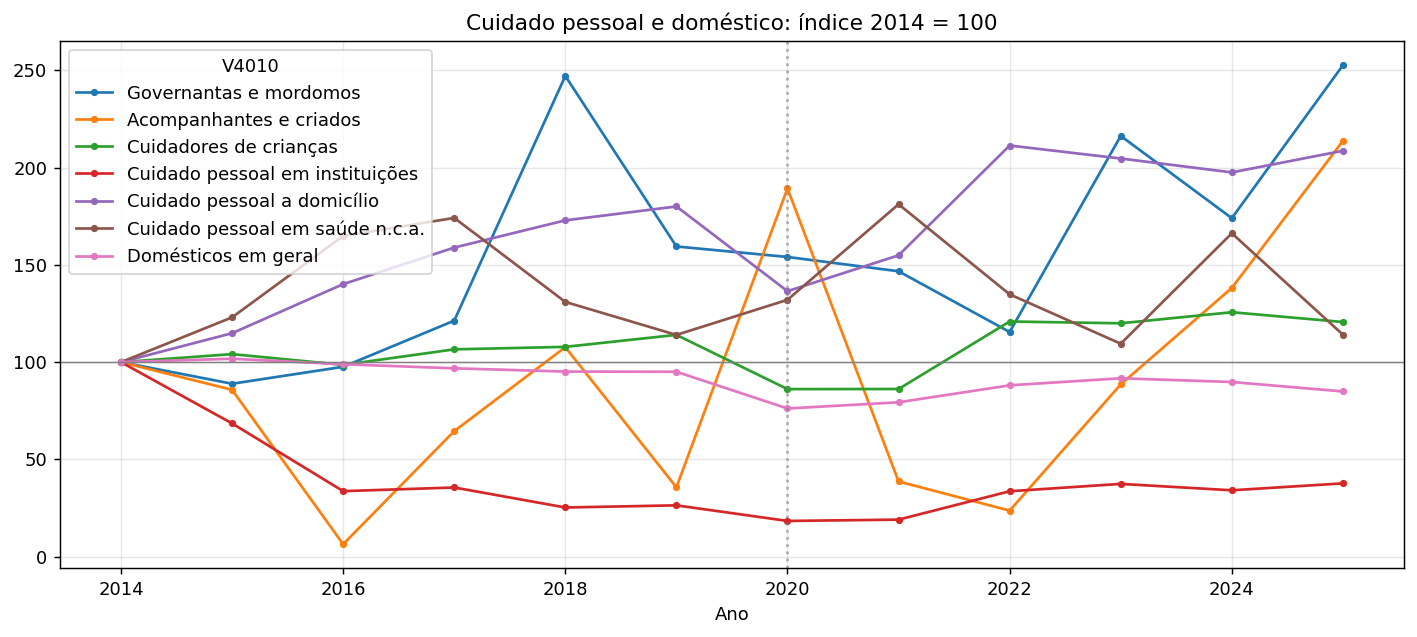

In [ ]:
# ===== 11.2 DA CRIADA À CUIDADORA =====
FAM_PD = {'9111': 'Domésticos em geral', '5322': 'Cuidado pessoal a domicílio',
          '5321': 'Cuidado pessoal em instituições', '5311': 'Cuidadores de crianças',
          '5162': 'Acompanhantes e criados', '5152': 'Governantas e mordomos',
          '5329': 'Cuidado pessoal em saúde n.c.a.'}

pd_fam = cui[cui.V4010.isin(FAM_PD)]
serie_pd = pd_fam.groupby(['Ano', 'V4010'])['V1032'].sum().unstack().rename(columns=FAM_PD) / 1e6
display(serie_pd.round(2))
print("Variação 2014–2025 (milhões):")
print((serie_pd.loc[2025] - serie_pd.loc[2014]).sort_values().round(2))
print("\nChoque 2019→2020 (%):")
print((100 * (serie_pd.loc[2020] / serie_pd.loc[2019] - 1)).sort_values().round(1))

# Formalidade por família: 2014 x 2025
form_fam = (pd_fam[pd_fam.Ano.isin([2014, 2025])]
            .groupby(['V4010', 'Ano'])
            .apply(lambda d: pd.Series({
                '% contribui': 100 * d.V1032[d.formal_contrib].sum() / d.V1032.sum(),
                '% vínculo formal': 100 * d.V1032[d.formal_vinculo].sum() / d.V1032.sum(),
                '% mulheres negras': 100 * d.V1032[d.mulher & d.negra].sum() / d.V1032.sum(),
                'n': len(d)}), include_groups=False)
            .unstack('Ano').rename(index=FAM_PD))
display(form_fam.round(1))

# Índice 2014 = 100
indice = 100 * serie_pd / serie_pd.loc[2014]
fig, ax = plt.subplots(figsize=(11, 5))
indice.plot(ax=ax, marker='o', markersize=3)
ax.axhline(100, color='grey', lw=0.8)
ax.axvline(2020, color='grey', ls=':', alpha=0.6)
ax.set_title('Cuidado pessoal e doméstico: índice 2014 = 100')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Célula 11.3 — sexo e raça ao longo da hierarquia do cuidado:

1. A Direção quase não existe, e isso é um achado. São 18 e 27 casos na amostra, praticamente zero em milhões. Os percentuais dessa linha não se sustentam, mas a ausência em si confirma o que você já tinha visto: o cuidado brasileiro é massa de trabalho, sem camada gerencial. Na tese, trate a Direção só como registro dessa ausência.

2. Mulheres brancas no topo, mulheres negras na base. Em 2025:

Nível	Mulheres brancas	Mulheres negras
Especialista	47,0%	41,2%
Técnico	31,0%	46,2%
Básico/Operacional	30,1%	61,5%

A cor da mão de obra escurece à medida que se desce na hierarquia. Os homens, raros no cuidado, aparecem sobretudo no nível Técnico (22%, a maioria negros): entram pela enfermagem técnica e pelos agentes comunitários.

3. Dois movimentos ao mesmo tempo. A presença de mulheres negras cresceu em todos os níveis, e mais rápido no topo: no Especialista, de 32,8% para 41,2% (+8,4 pontos), o que conversa com a expansão do ensino superior e das cotas (o mesmo padrão da Parte 8, em que raça muda mais rápido que gênero). Mas a concentração na base também aumentou (58,7% → 61,5%). O cuidado ficou mais negro de cima a baixo, e continua mais negro embaixo.

4. Dois mundos de proteção. No Básico, só 41,5% contribuem para a previdência; nos níveis Técnico e Especialista, 86% a 90%. E todos os níveis perderam vínculo formal: o Especialista caiu de 70% para 62%, provável sinal de psicólogas, fisioterapeutas e fonoaudiólogas trabalhando como autônomas.

5. Menos Estado nos níveis qualificados. O setor público caiu no Especialista (54% → 48%) e no Técnico (67% → 56%). A exceção é o Básico (5% → 9%), provavelmente puxado pelas ajudantes de professores nas creches públicas.

In [ ]:
# ===== 11.3 DESIGUALDADES NA HIERARQUIA DO CUIDADO =====
ORDEM_NIV = ['Direção', 'Especialista', 'Técnico', 'Básico/Operacional']
anos_cmp = [2014, 2025]
c2 = cui[cui.Ano.isin(anos_cmp)]

# Composição por sexo e raça em cada nível (%)
comp_niv = (c2.groupby(['Ano', 'nivel', 'grupo'])['V1032'].sum()
            / c2.groupby(['Ano', 'nivel'])['V1032'].sum() * 100).unstack('grupo')
comp_niv = comp_niv.join(c2.groupby(['Ano', 'nivel']).size().rename('n amostra'))
comp_niv = comp_niv.reindex(pd.MultiIndex.from_product([anos_cmp, ORDEM_NIV]))
print("=== Composição por sexo e raça em cada nível (%) ===")
display(comp_niv.round(1))

# Perfil por nível
tab_niv = c2.groupby(['Ano', 'nivel']).apply(perfil, include_groups=False)
tab_niv = tab_niv.reindex(pd.MultiIndex.from_product([anos_cmp, ORDEM_NIV]))
print("\n=== Perfil por nível ===")
display(tab_niv.round(1))

=== Composição por sexo e raça em cada nível (%) ===


Homens brancos  Homens negros  Mulheres brancas  \
2014 Direção                        NaN            1.1              59.3   
     Especialista                   6.9            5.3              54.1   
     Técnico                        9.5           14.0              34.2   
     Básico/Operacional             2.2            3.7              35.0   
2025 Direção                       21.2            NaN              34.4   
     Especialista                   5.7            5.5              47.0   
     Técnico                        8.7           13.0              31.0   
     Básico/Operacional             2.5            4.9              30.1   

                         Mulheres negras  Outros  n amostra  
2014 Direção                        39.5     NaN         18  
     Especialista                   32.8     0.9       2682  
     Técnico                        41.9     0.4       2679  
     Básico/Operacional             58.7     0.4      13913  
2025 Direção                        37.9     6.5         27  
     Especialista                   41.2     0.7       4088  
     Técnico                        46.2     1.1       3308  
     Básico/Operacional             61.5     1.0      12706


=== Perfil por nível ===


ocupados (mi)  % mulheres  % mulheres negras  \
2014 Direção                       0.0        98.9               39.5   
     Especialista                  1.3        87.8               32.8   
     Técnico                       1.1        76.4               41.9   
     Básico/Operacional            6.5        94.0               58.7   
2025 Direção                       0.0        78.8               37.9   
     Especialista                  2.4        88.7               41.2   
     Técnico                       1.8        77.9               46.2   
     Básico/Operacional            6.6        92.4               61.5   

                         % formal (contribui)  % formal (vínculo)  \
2014 Direção                             96.4                49.8   
     Especialista                        89.8                70.0   
     Técnico                             93.9                81.7   
     Básico/Operacional                  44.7                35.3   
2025 Direção                             88.0                41.1   
     Especialista                        86.3                62.1   
     Técnico                             90.3                77.7   
     Básico/Operacional                  41.5                29.5   

                         % setor público  idade média  n amostra  
2014 Direção                        41.8         45.1       18.0  
     Especialista                   53.9         37.8     2682.0  
     Técnico                        67.0         38.0     2679.0  
     Básico/Operacional              5.4         40.4    13913.0  
2025 Direção                        64.9         46.5       27.0  
     Especialista                   48.3         40.0     4088.0  
     Técnico                        56.3         41.3     3308.0  
     Básico/Operacional              9.4         43.4    12706.0

Célula 11.4 — o cuidado paga menos, com a mesma escolaridade? Compara a renda média (já deflacionada) entre Cuidados e as demais ocupações por escolaridade, em 2023–25; a segunda tabela repete só entre mulheres, para separar o efeito de o cuidado ser feminino.

1. O cuidado paga de 23% a 41% menos, com a mesma escolaridade. A diferença aparece em todos os níveis de instrução. Entre quem tem superior completo, o cuidado paga R$ 4.056, contra R$ 6.463 nas demais ocupações (−37%).

2. Cerca de metade da diferença é gênero; a outra metade é cuidado. Comparando só mulheres, a penalidade cai para 13% a 26%. Ou seja: parte da diferença vem de o cuidado ser feito por mulheres, que ganham menos em qualquer ocupação; mas, mesmo entre mulheres com a mesma escolaridade, quem cuida ganha menos. É o que a literatura internacional chama de penalidade do cuidado (England, Budig e Folbre, 2002), agora medida para o Brasil com a PNAD.

3. A penalidade é maior justamente no nível superior. Entre mulheres com diploma, o cuidado paga 24% menos (R$ 3.907 contra R$ 5.165), mais que no médio completo (−13%). Isso conversa diretamente com Almeida: o cuidado de nível superior oferece mais estabilidade institucional, mas com retornos salariais menores. A 11.5 vai comparar exatamente esse segmento com C&I.

Uma cautela para o texto: é renda mensal, não por hora. Parte do cuidado, sobretudo diaristas e cuidadoras a domicílio, trabalha menos horas por semana, e isso infla a diferença nos níveis baixos de escolaridade. Se a V4039 (horas trabalhadas) estiver no parquet, dá para refazer por hora; confira com print('V4039' in base.columns).

In [ ]:
# ===== 11.4 RENDA: CUIDADOS x DEMAIS OCUPAÇÕES, MESMA ESCOLARIDADE =====
b = base[base.Ano.between(2023, 2025) & base.ancora.notna()].copy()
b['VD4016'] = pd.to_numeric(b['VD4016'], errors='coerce')
b = b[b.VD4016.notna() & (b.VD4016 > 0)]
b['comparacao'] = np.where(b.ancora == 'Cuidados', 'Cuidados', 'Demais ocupações')

def renda_media(d):
    return np.average(d.VD4016, weights=d.V1032)

for titulo, filtro in [('Todos', b), ('Só mulheres', b[b.mulher])]:
    t = filtro.groupby(['VD3004', 'comparacao']).apply(renda_media, include_groups=False).unstack()
    t['diferença %'] = 100 * (t['Cuidados'] / t['Demais ocupações'] - 1)
    t['n Cuidados'] = filtro[filtro.comparacao == 'Cuidados'].groupby('VD3004').size()
    print(f"\n=== Renda média mensal (R$), 2023–25 — {titulo} ===")
    display(t.round(0))


=== Renda média mensal (R$), 2023–25 — Todos ===


comparacao,Cuidados,Demais ocupações,diferença %,n Cuidados
VD3004,,,,
Sem instrução e menos de 1 ano de estudo,1181.0,1525.0,-23.0,1467
Fundamental incompleto ou equivalente,1155.0,1839.0,-37.0,12655
Fundamental completo ou equivalente,1325.0,2112.0,-37.0,4067
Médio incompleto ou equivalente,1165.0,1965.0,-41.0,3078
Médio completo ou equivalente,1783.0,2461.0,-28.0,18433
Superior incompleto ou equivalente,2101.0,2992.0,-30.0,2883
Superior completo,4056.0,6463.0,-37.0,13876



=== Renda média mensal (R$), 2023–25 — Só mulheres ===


comparacao,Cuidados,Demais ocupações,diferença %,n Cuidados
VD3004,,,,
Sem instrução e menos de 1 ano de estudo,1134.0,1394.0,-19.0,1115
Fundamental incompleto ou equivalente,1129.0,1403.0,-20.0,11004
Fundamental completo ou equivalente,1301.0,1626.0,-20.0,3715
Médio incompleto ou equivalente,1134.0,1523.0,-26.0,2750
Médio completo ou equivalente,1709.0,1959.0,-13.0,16442
Superior incompleto ou equivalente,1981.0,2334.0,-15.0,2497
Superior completo,3907.0,5165.0,-24.0,12184


Célula 11.5 — cuidado de nível superior vs Ciência e Inovação. Recorte de Especialista e Direção, comparando 2014–16 com 2024–25 (ocupados como média anual do período):

Esta é a comparação que mais conversa com a tese da Mariana, e os dados confirmam o argumento dela com números da PNAD.

1. Dois segmentos do mesmo tamanho, crescendo no mesmo ritmo, com composições opostas. Os dois têm cerca de 2,1 a 2,3 milhões de pessoas e cresceram quase igual desde 2014–16. Mas C&I tem 27,7% de mulheres, e o cuidado superior, 88,7%. Mulheres negras são 8,1% em C&I e 41% no cuidado: cinco vezes mais.

2. A diferença não está na formalidade, está no Estado. A contribuição previdenciária é praticamente igual (87% a 89%), e os dois perderam vínculo formal na mesma medida (cerca de 6 a 7 pontos). A informalização do trabalho qualificado é geral, não específica do cuidado. O que separa os dois é o setor público: 49% no cuidado superior contra 11% em C&I. É a "previsibilidade institucional" de que Almeida fala, agora medida.

3. O Estado como porta de entrada, de novo, e mais forte no cuidado. Mulheres negras no cuidado superior são as mais dependentes do emprego público (55%), como em C&I (Parte 8), mas numa escala muito maior. E, como lá, esse peso está caindo (61% → 55%).

4. O preço da estabilidade: o cuidado paga de 57% a 66% do que paga C&I, para todos os grupos.

Grupo	C&I	Cuidados	Razão
Homens brancos	R$ 9.927	R$ 5.946	0,60
Homens negros	R$ 7.805	R$ 4.483	0,57
Mulheres brancas	R$ 7.416	R$ 4.703	0,63
Mulheres negras	R$ 5.819	R$ 3.821	0,66

Há duas desigualdades sobrepostas: a entre áreas (o cuidado paga cerca de 35% a 40% menos) e a dentro de cada área (mulheres negras recebem 59% do que recebem homens brancos em C&I e 64% no cuidado). Uma mulher negra no cuidado de nível superior ganha 38% do que ganha um homem branco em C&I.

A frase para a tese: para as mulheres, especialmente as negras, a migração do STEM para o cuidado não é só um deslocamento horizontal: troca-se cerca de 35% a 40% da renda por uma inserção quatro vezes mais pública, com a mesma formalidade. É a leitura da Mariana (estratégia de adaptação, não simples "descida"), com o custo quantificado.

Uma nota: os homens no cuidado superior são poucos (cerca de 0,1 mi por grupo) e têm o menor vínculo formal (52% a 55%), provavelmente psicólogos e fisioterapeutas autônomos.

In [ ]:
# ===== 11.5 CUIDADO DE NÍVEL SUPERIOR x CIÊNCIA E INOVAÇÃO =====
sup = base[base.nivel.isin(['Especialista', 'Direção'])
           & base.ancora.isin(['Cuidados', 'Ciência e Inovação'])].copy()
sup['periodo'] = np.select([sup.Ano.between(2014, 2016), sup.Ano.between(2024, 2025)],
                           ['2014–16', '2024–25'], default='fora')
sup = sup[sup.periodo != 'fora']

def perfil_periodo(d):
    s = perfil(d)
    s['ocupados (mi)'] = s['ocupados (mi)'] / d.Ano.nunique()
    return s

tab_sup = sup.groupby(['ancora', 'periodo']).apply(perfil_periodo, include_groups=False)
print("=== Perfil: Cuidados (superior) x C&I ===")
display(tab_sup.round(1))

# Por sexo e raça: formalidade e setor público
tab_sup_g = (sup[sup.grupo != 'Outros']
             .groupby(['ancora', 'grupo', 'periodo'])
             .apply(lambda d: perfil_periodo(d)[['ocupados (mi)', '% formal (vínculo)',
                                                 '% setor público', 'n amostra']],
                    include_groups=False)
             .unstack('periodo'))
print("\n=== Por sexo e raça ===")
display(tab_sup_g.round(1))

# Renda 2023-25, só nível superior completo
r = sup[sup.Ano.between(2023, 2025)].copy()
r['VD4016'] = pd.to_numeric(r['VD4016'], errors='coerce')
r = r[r.VD4016 > 0]
renda_sup = (r.groupby(['ancora', 'grupo'])
               .apply(lambda d: np.average(d.VD4016, weights=d.V1032), include_groups=False)
               .unstack('ancora').drop(index='Outros', errors='ignore'))
renda_sup['Cuidados / C&I'] = renda_sup['Cuidados'] / renda_sup['Ciência e Inovação']
print("\n=== Renda média mensal (R$), 2023–25, Especialista + Direção ===")
display(renda_sup.round(2))

=== Perfil: Cuidados (superior) x C&I ===


ocupados (mi)  % mulheres  % mulheres negras  \
ancora             periodo                                                 
Ciência e Inovação 2014–16            1.2        24.1                4.8   
                   2024–25            2.1        27.7                8.1   
Cuidados           2014–16            1.4        89.2               33.1   
                   2024–25            2.3        88.7               41.0   

                            % formal (contribui)  % formal (vínculo)  \
ancora             periodo                                             
Ciência e Inovação 2014–16                  91.5                71.0   
                   2024–25                  88.7                65.4   
Cuidados           2014–16                  89.4                69.6   
                   2024–25                  86.8                62.6   

                            % setor público  idade média  n amostra  
ancora             periodo                                           
Ciência e Inovação 2014–16             16.2         39.3     5186.0  
                   2024–25             10.7         38.5     5629.0  
Cuidados           2014–16             53.4         37.8     8530.0  
                   2024–25             49.0         40.1     7588.0


=== Por sexo e raça ===


ocupados (mi)         % formal (vínculo)  \
periodo                                   2014–16 2024–25            2014–16   
ancora             grupo                                                       
Ciência e Inovação Homens brancos             0.7     1.0               70.3   
                   Homens negros              0.2     0.4               75.0   
                   Mulheres brancas           0.2     0.4               68.7   
                   Mulheres negras            0.1     0.2               76.1   
Cuidados           Homens brancos             0.1     0.1               60.5   
                   Homens negros              0.1     0.1               63.8   
                   Mulheres brancas           0.8     1.1               71.2   
                   Mulheres negras            0.5     0.9               69.6   

                                            % setor público         n amostra  \
periodo                             2024–25         2014–16 2024–25   2014–16   
ancora             grupo                                                        
Ciência e Inovação Homens brancos      66.0            13.8     9.2    2804.0   
                   Homens negros       65.0            19.6    11.1     998.0   
                   Mulheres brancas    64.5            19.1    12.7     949.0   
                   Mulheres negras     62.3            29.7    14.7     331.0   
Cuidados           Homens brancos      51.7            40.6    32.6     442.0   
                   Homens negros       55.2            58.7    47.1     441.0   
                   Mulheres brancas    62.3            49.5    45.7    4284.0   
                   Mulheres negras     65.6            61.3    55.1    3309.0   

                                             
periodo                             2024–25  
ancora             grupo                     
Ciência e Inovação Homens brancos    2630.0  
                   Homens negros     1256.0  
                   Mulheres brancas  1118.0  
                   Mulheres negras    532.0  
Cuidados           Homens brancos     422.0  
                   Homens negros      402.0  
                   Mulheres brancas  3408.0  
                   Mulheres negras   3299.0


=== Renda média mensal (R$), 2023–25, Especialista + Direção ===


ancora,Ciência e Inovação,Cuidados,Cuidados / C&I
grupo,,,
Homens brancos,9926.97,5945.85,0.60
Homens negros,7804.55,4483.20,0.57
Mulheres brancas,7415.52,4703.09,0.63
Mulheres negras,5818.65,3820.65,0.66


Célula 11.6 — cuidado ampliado (Cuidados + Saúde) e comparação com Guimarães e Pinheiro:

O cuidado ampliado mostra bem o recorte escolhido:

1. O núcleo cresce mais rápido que o mercado. Cuidados + Saúde foram de 10,3 para 13,2 milhões entre 2014 e 2025 (+28%), enquanto o total de ocupados cresceu cerca de 12%. A participação no emprego subiu de 11,2% para 12,8%. É um setor que avança mesmo com a pandemia no meio (a queda de 2020 foi recuperada já em 2022).

2. A composição é estável e marcada. Cerca de 85% de mulheres e quase metade de mulheres negras (48%), sem grande mudança em onze anos.

3. A distância para Guimarães e Pinheiro é conceitual, não erro de medida. Em 2019, o nosso ampliado tem 11,4 milhões (12,2% dos ocupados); as autoras chegam a cerca de 24 milhões (25%). Os ~12 milhões de diferença são o "halo" externo: as ocupações de apoio que elas incluem nos círculos de menor densidade (como cozinheiras e limpeza de edifícios, citadas no capítulo), que no nosso crosswalk estão em Comércio, Serviços e Lazer. A frase para a metodologia: "a âncora Cuidados corresponde ao núcleo de maior densidade de cuidado; somada à Saúde, representa cerca de metade do setor de cuidados na definição ampla de Guimarães e Pinheiro (2023)".



In [ ]:
# ===== 11.6 CUIDADO AMPLIADO: CUIDADOS + SAÚDE =====
tot = base.groupby('Ano')['V1032'].sum()
amp = base[base.ancora.isin(['Cuidados', 'Saúde'])]

tab_amp = pd.DataFrame({
    'Cuidados (mi)': cui.groupby('Ano')['V1032'].sum() / 1e6,
    'Saúde (mi)': base[base.ancora == 'Saúde'].groupby('Ano')['V1032'].sum() / 1e6,
})
tab_amp['Ampliado (mi)'] = tab_amp.sum(axis=1)
tab_amp['% dos ocupados'] = 100 * tab_amp['Ampliado (mi)'] * 1e6 / tot
tab_amp['% mulheres'] = amp.groupby('Ano').apply(
    lambda d: 100 * d.V1032[d.mulher].sum() / d.V1032.sum(), include_groups=False)
tab_amp['% mulheres negras'] = amp.groupby('Ano').apply(
    lambda d: 100 * d.V1032[d.mulher & d.negra].sum() / d.V1032.sum(), include_groups=False)
display(tab_amp.round(1))
print("Referência: Guimarães & Pinheiro, 2019 ≈ 24 mi (~25% dos ocupados).")

,Cuidados (mi),Saúde (mi),Ampliado (mi),% dos ocupados,% mulheres,% mulheres negras
Ano,,,,,,
2014,8.9,1.4,10.3,11.2,85.5,47.5
2015,9.4,1.4,10.7,11.7,85.4,47.2
2016,9.5,1.6,11.1,12.3,85.3,47.6
2017,9.5,1.5,11.0,12.2,85.7,48.5
2018,9.7,1.7,11.4,12.4,85.5,48.7
2019,9.8,1.6,11.4,12.2,85.8,49.2
2020,8.6,1.6,10.2,11.9,84.4,46.9
2021,8.8,1.7,10.5,11.9,84.4,47.1
2022,10.3,1.9,12.2,12.5,84.6,48.1


Referência: Guimarães & Pinheiro, 2019 ≈ 24 mi (~25% dos ocupados).


Célula 11.7 — projeção 2025–2040 por bloco. Mesmo método do Híbrido 2.0 (tendência amortecida, δ = 0,85, sem 2020–21), por bloco × sexo × faixa etária, calibrado para somar o total de Cuidados do híbrido:

Calibração perfeita (fator 1,0 em todos os anos): o método por bloco reproduz exatamente o total de Cuidados do Híbrido 2.0. Dá para interpretar com segurança.

Leitura da projeção 2025–2040

Bloco	2025	2040	Variação
Saúde	3,05	3,59	+0,54 (+18%)
Educativo	1,49	1,76	+0,27 (+18%)
Pessoal e doméstico	6,05	6,13	+0,08 (+1%)
Assistência social	0,24	0,27	+0,03
Total	10,82	11,74	+0,92 (+8,5%)

1. O crescimento do cuidado vem quase todo dos blocos mais formais e públicos. Saúde e Educativo respondem por cerca de 90% do aumento. O bloco pessoal e doméstico, que é mais da metade do cuidado, fica praticamente parado: a queda das domésticas compensa o avanço das cuidadoras a domicílio. A participação dele cai de 56% para 52% da âncora.

2. O núcleo não acompanha o envelhecimento. Pela tendência, o cuidado pessoal e doméstico cresce só 1% até 2040, enquanto a população de 80 anos ou mais vai crescer muito. Essa é justamente a tesoura que a 11.8 vai medir.

3. Uma tensão a registrar no Educativo. Ele cresce 18%, mas a população de 0 a 5 anos vai encolher. A tendência está extrapolando a expansão recente de creches e pré-escola (coerente com a meta de cobertura do PNE), não a demografia. Na tese, vale dizer que esse crescimento depende de a política de expansão continuar; é um caso em que a Via A (razão de cobertura) e a tendência apontam para lados opostos.

In [ ]:
# ===== 11.7 PROJEÇÃO 2025-2040 POR BLOCO =====
DELTA = 0.85
bins = [14, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 200]
labels = ['14-19','20-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59','60-64','65+']

pop_longo = pd.read_parquet(pasta + 'projecoes_ibge_longo.parquet')
pop_longo['idade'] = pop_longo['idade'].astype(str).str.replace('+', '', regex=False).astype(int)
pop_longo['faixa_etaria'] = pd.cut(pop_longo['idade'], bins=bins, labels=labels, right=False)
pop_cel = (pop_longo.dropna(subset=['faixa_etaria'])
           .groupby(['ano', 'sexo', 'faixa_etaria'], observed=True)['populacao'].sum().rename('pop'))

def projeta_grupos(d, col, ano_base=2025, ano_fim=2040, delta=DELTA):
    """Tendência amortecida das taxas grupo x sexo x faixa, vezes a população projetada."""
    d = d.copy()
    d['faixa_etaria'] = pd.cut(d['V2009'].astype(float), bins=bins, labels=labels, right=False)
    num = (d.groupby(['Ano', col, 'sexo', 'faixa_etaria'], observed=True)['V1032'].sum()
           .rename('ocupados').reset_index().rename(columns={'Ano': 'ano'}))
    pan = num.merge(pop_cel.reset_index(), on=['ano', 'sexo', 'faixa_etaria'], how='left')
    pan['taxa'] = pan['ocupados'] / pan['pop']

    def incl(g):
        return np.polyfit(g['ano'], g['taxa'], 1)[0] if len(g) >= 5 else 0.0
    fit = pan[~pan['ano'].isin([2020, 2021])]
    sl = (fit.groupby([col, 'sexo', 'faixa_etaria'], observed=True)
          .apply(incl, include_groups=False).rename('slope').reset_index())

    b0 = (pan[pan['ano'] == ano_base][[col, 'sexo', 'faixa_etaria', 'taxa']]
          .merge(sl, on=[col, 'sexo', 'faixa_etaria'], how='left').fillna({'slope': 0}))
    saida = []
    for ano in range(ano_base, ano_fim + 1):
        fator = sum(delta**k for k in range(1, ano - ano_base + 1))
        m = b0.copy()
        m['taxa_t'] = (m['taxa'] + m['slope'] * fator).clip(lower=0)
        m = m.merge(pop_cel.loc[ano].reset_index(), on=['sexo', 'faixa_etaria'])
        m['ocupados'] = m['taxa_t'] * m['pop']
        m['ano'] = ano
        saida.append(m)
    return (pd.concat(saida).groupby(['ano', col], observed=True)['ocupados'].sum()
            .unstack(col) / 1e6)

proj_bloco = projeta_grupos(cui, 'bloco')

# Calibração no total de Cuidados do Híbrido 2.0
hib = pd.read_parquet(pasta + 'camada2_hibrido_v2.parquet')
hib.index = hib.index.astype(int)
fator_cal = hib['Cuidados'].reindex(proj_bloco.index) / proj_bloco.sum(axis=1)
print("Fator de calibração (≈ 1):", fator_cal.loc[[2025, 2030, 2040]].round(3).to_dict())
proj_bloco_cal = proj_bloco.mul(fator_cal, axis=0)
proj_bloco_cal['Total Cuidados'] = proj_bloco_cal.sum(axis=1)
display(proj_bloco_cal.loc[[2025, 2030, 2035, 2040]].round(2))

Fator de calibração (≈ 1): {2025: 1.0, 2030: 1.0, 2040: 1.0}


bloco,Assistência social,Educativo (infantil/especial),Pessoal e doméstico,Saúde,Total Cuidados
ano,,,,,
2025,0.24,1.49,6.05,3.05,10.82
2030,0.26,1.67,6.03,3.41,11.37
2035,0.27,1.75,6.10,3.55,11.67
2040,0.27,1.76,6.13,3.59,11.74


Célula 11.7b — cenários da Política Nacional de Cuidados por bloco. Aplica o mesmo choque da Camada 3 (+10% e +20% até 2040, rampa linear a partir de 2027) proporcionalmente a todos os blocos:

,obs 2025,Base,PNC moderado,PNC forte
bloco,,,,
Assistência social,0.24,0.27,0.30,0.32
Educativo (infantil/especial),1.49,1.76,1.94,2.11
Pessoal e doméstico,6.05,6.13,6.74,7.35
Saúde,3.05,3.59,3.95,4.30
Total,10.82,11.74,12.92,14.09


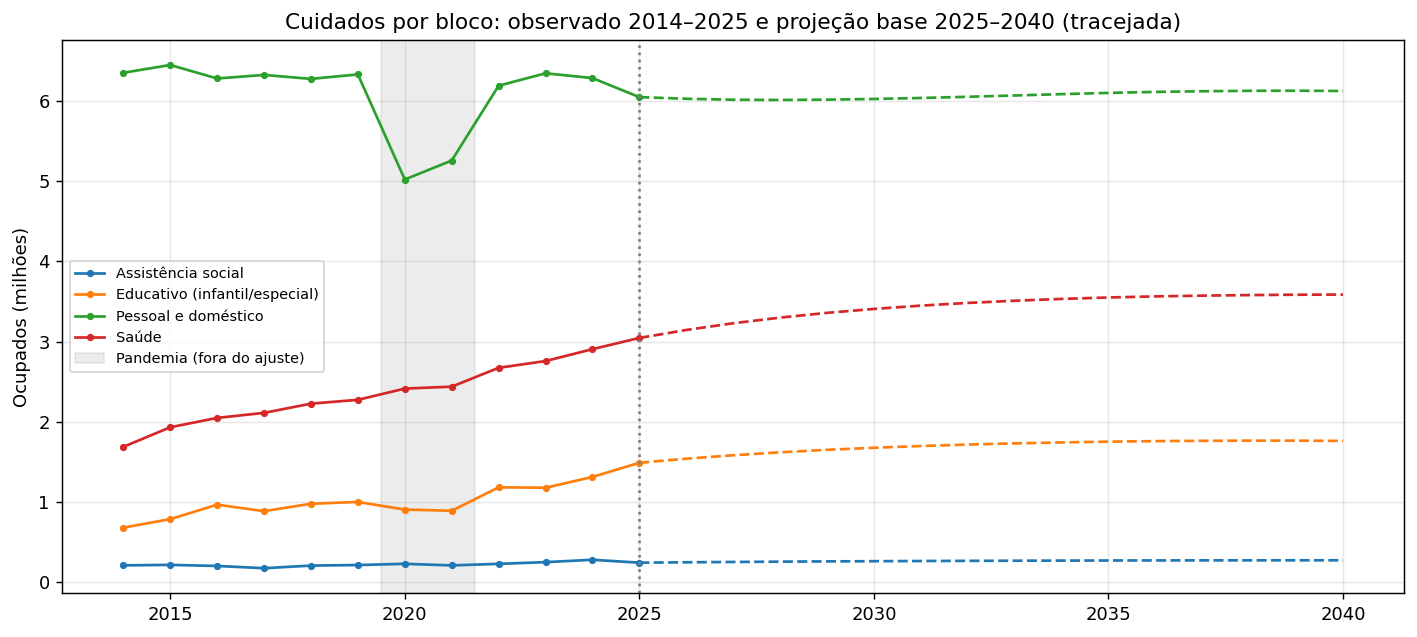

In [ ]:
# ===== 11.7b CENÁRIOS PNC POR BLOCO =====
def rampa_linear(ano, inicio=2027, fim=2040):
    return 0.0 if ano <= inicio else min((ano - inicio) / (fim - inicio), 1.0)

blocos = [c for c in proj_bloco_cal.columns if c != 'Total Cuidados']
cen_pnc = {}
for nome, choque in [('Base', 0.0), ('PNC moderado', 0.10), ('PNC forte', 0.20)]:
    mult = pd.Series([1 + choque * rampa_linear(a) for a in proj_bloco_cal.index],
                     index=proj_bloco_cal.index)
    cen_pnc[nome] = proj_bloco_cal[blocos].mul(mult, axis=0)

tab_pnc = pd.DataFrame({nome: t.loc[2040] for nome, t in cen_pnc.items()})
tab_pnc.insert(0, 'obs 2025', proj_bloco_cal.loc[2025, blocos])
tab_pnc.loc['Total'] = tab_pnc.sum()
display(tab_pnc.round(2))

# Gráfico: observado 2014-2025 e projeção base
fig, ax = plt.subplots(figsize=(11, 5))
for b in blocos:
    ax.plot(serie_bloco.index, serie_bloco[b], marker='o', markersize=3, label=f'{b}')
ax.set_prop_cycle(None)
for b in blocos:
    ax.plot(proj_bloco_cal.index, proj_bloco_cal[b], ls='--')
ax.axvspan(2019.5, 2021.5, color='grey', alpha=0.15, label='Pandemia (fora do ajuste)')
ax.axvline(2025, color='grey', ls=':')
ax.set_title('Cuidados por bloco: observado 2014–2025 e projeção base 2025–2040 (tracejada)')
ax.set_ylabel('Ocupados (milhões)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

11.8 — a tesoura do envelhecimento. Ela compara a oferta projetada de cuidadoras de idosos (famílias 5321, 5322, 1343 e 5162, as mesmas da Via A) com a quantidade necessária para manter a cobertura de 2025, medida em cuidadoras por mil pessoas de 80 anos ou mais. A diferença é a lacuna que a Política Nacional de Cuidados teria de cobrir, ou que recairia sobre o cuidado familiar não remunerado, em geral de mulheres.

A tesoura é o resultado mais forte da Parte 11, e ela é robusta.

1. Até agora, a oferta acompanhou o envelhecimento. A cobertura observada ficou estável em torno de 170 cuidadoras por mil pessoas de 80+ (entre 160 e 190, fora a pandemia). Não há degrau estranho em 2014–2016: a soma de instituições e domicílio neutraliza o problema de codificação que vimos na 11.2. Em 2020, a cobertura despencou para 127, outra expressão do choque da pandemia.

2. Daqui para frente, a tesoura abre.

	2025	2040	Variação
População 80+	4,96 mi	10,03 mi	+102%
Cuidadoras de idosos (tendência)	0,85 mi	1,02 mi	+20%
Necessárias para manter a cobertura de 2025	0,85 mi	1,73 mi	+102%
Lacuna	0	0,71 mi
Cuidadoras por mil pessoas 80+	172	102	−41%

A população de 80 anos ou mais dobra, e a oferta de cuidado remunerado cresce um quinto. Em 2040, faltarão cerca de 710 mil cuidadoras só para manter a cobertura atual, ou seja, 41% da necessidade ficaria descoberta. Para fechar a tesoura, a oferta teria de crescer cerca de 4,8% ao ano; a tendência entrega cerca de 1,2%.

3. A PNC, do jeito que está nos cenários, não fecha a lacuna. O cenário PNC forte (+20% sobre toda a âncora) acrescentaria cerca de 0,2 mi a esse grupo em 2040, menos de um terço dos 0,71 mi que faltam. A conclusão de política é direta: um choque distribuído igualmente por todo o cuidado não resolve o envelhecimento; é preciso política focalizada no cuidado de idosos.

4. Quem absorve a lacuna. Se ela não for coberta por trabalho remunerado, recai sobre o cuidado familiar não remunerado, que no Brasil é sobretudo feito por mulheres, e em boa parte por mulheres que também envelhecem. É o elo entre a projeção e a agenda da economia do cuidado da Luana.

Cautelas para o texto: a cobertura de 2025 é um referencial conservador, não um ideal (manter o nível atual, não melhorá-lo); e nem toda pessoa de 80+ precisa de cuidado remunerado. Por isso, "lacuna" deve ser lida como a distância para manter o padrão atual, não como necessidade absoluta.

Cuidadoras de idosos por mil pessoas 80+ (observado):
Ano
2014    182.4
2015    167.5
2016    160.3
2017    173.1
2018    172.7
2019    172.6
2020    127.1
2021    138.9
2022    191.2
2023    182.7
2024    168.7
2025    172.2

=== Tesoura 2025–2040 ===


,pop 80+ (mi),oferta projetada (mi),necessária p/ cobertura 2025 (mi),lacuna (mi),cobertura projetada (por mil)
ano,,,,,
2025,4.96,0.85,0.85,0.00,172.17
2030,6.26,0.94,1.08,0.14,150.30
2035,7.97,0.99,1.37,0.38,124.86
2040,10.03,1.02,1.73,0.71,101.82


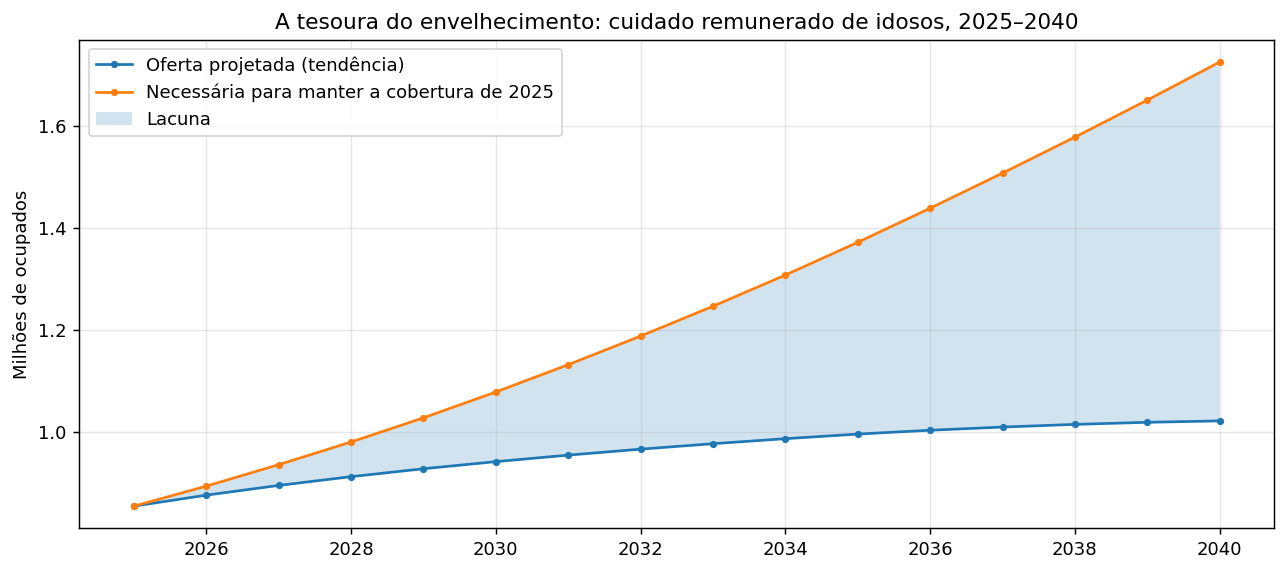

In [ ]:
# ===== 11.8 A TESOURA DO ENVELHECIMENTO =====
FAM_IDOSO = ['5321', '5322', '1343', '5162']
cui['grupo_idoso'] = np.where(cui['V4010'].isin(FAM_IDOSO), 'Cuidado de idosos', 'Outros')

# Cobertura observada: cuidadoras por mil pessoas 80+
obs_id = cui[cui.grupo_idoso == 'Cuidado de idosos'].groupby('Ano')['V1032'].sum() / 1e6
pop80 = pop_longo[pop_longo.idade >= 80].groupby('ano')['populacao'].sum() / 1e6
cobertura_obs = 1000 * obs_id / pop80.reindex(obs_id.index)
print("Cuidadoras de idosos por mil pessoas 80+ (observado):")
print(cobertura_obs.round(1).to_string())

# Oferta projetada (mesmo método da 11.7, sem 2020-21 no ajuste)
proj_id = projeta_grupos(cui, 'grupo_idoso')['Cuidado de idosos']

anos_p = range(2025, 2041)
tesoura = pd.DataFrame({
    'pop 80+ (mi)': pop80.reindex(anos_p),
    'oferta projetada (mi)': proj_id.reindex(anos_p),
})
tesoura['necessária p/ cobertura 2025 (mi)'] = cobertura_obs.loc[2025] * tesoura['pop 80+ (mi)'] / 1000
tesoura['lacuna (mi)'] = tesoura['necessária p/ cobertura 2025 (mi)'] - tesoura['oferta projetada (mi)']
tesoura['cobertura projetada (por mil)'] = 1000 * tesoura['oferta projetada (mi)'] / tesoura['pop 80+ (mi)']
print("\n=== Tesoura 2025–2040 ===")
display(tesoura.loc[[2025, 2030, 2035, 2040]].round(2))

# Gráfico
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(tesoura.index, tesoura['oferta projetada (mi)'], marker='o', markersize=3,
        label='Oferta projetada (tendência)')
ax.plot(tesoura.index, tesoura['necessária p/ cobertura 2025 (mi)'], marker='o', markersize=3,
        label='Necessária para manter a cobertura de 2025')
ax.fill_between(tesoura.index, tesoura['oferta projetada (mi)'],
                tesoura['necessária p/ cobertura 2025 (mi)'], alpha=0.2, label='Lacuna')
ax.set_title('A tesoura do envelhecimento: cuidado remunerado de idosos, 2025–2040')
ax.set_ylabel('Milhões de ocupados')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ===== 11.9 SALVAR RESULTADOS =====
saidas = {
    'familias_blocos': 'fam_cui', 'perfil_bloco': 'tab_bloco',
    'pessoal_domestico': 'serie_pd', 'formalidade_familias': 'form_fam',
    'sexo_raca_nivel': 'comp_niv', 'perfil_nivel': 'tab_niv',
    'superior_vs_CI': 'tab_sup', 'superior_vs_CI_grupos': 'tab_sup_g',
    'renda_superior_vs_CI': 'renda_sup', 'ampliado': 'tab_amp',
    'projecao_blocos': 'proj_bloco_cal', 'cenarios_PNC_2040': 'tab_pnc',
    'tesoura_80mais': 'tesoura', 'cobertura_observada': 'cobertura_obs',
}
with pd.ExcelWriter(pasta + 'cuidados_resultados.xlsx') as xw:
    for aba, nome in saidas.items():
        if nome in globals():
            obj = globals()[nome]
            (obj.to_frame() if isinstance(obj, pd.Series) else obj).round(3).to_excel(xw, sheet_name=aba)
            print('✓', aba)
        else:
            print('— não encontrado (pulado):', aba)

proj_bloco_cal.to_parquet(pasta + 'cuidados_projecao_blocos.parquet')
tesoura.to_parquet(pasta + 'cuidados_tesoura_80mais.parquet')
print("\n✓ cuidados_resultados.xlsx, cuidados_projecao_blocos.parquet e cuidados_tesoura_80mais.parquet salvos")

✓ familias_blocos
✓ perfil_bloco
✓ pessoal_domestico
✓ formalidade_familias
✓ sexo_raca_nivel
✓ perfil_nivel
✓ superior_vs_CI
✓ superior_vs_CI_grupos
✓ renda_superior_vs_CI
✓ ampliado
✓ projecao_blocos
✓ cenarios_PNC_2040
✓ tesoura_80mais
✓ cobertura_observada

✓ cuidados_resultados.xlsx, cuidados_projecao_blocos.parquet e cuidados_tesoura_80mais.parquet salvos


teste de robustez do ponto de partida (média de 2024–2025)

Ele roda a mesma projeção duas vezes: uma partindo das taxas de 2025 (como está) e outra partindo da média das taxas de 2024 e 2025 em cada célula bloco × sexo × faixa. A tendência (sem 2020–21) e o δ = 0,85 são os mesmos; só muda o ponto de partida. A comparação é feita sem a calibração, porque calibrar forçaria as duas versões ao mesmo total do híbrido e esconderia justamente o efeito que queremos medir.

O resultado é robusto, e dá para dizer isso com números.

Blocos em 2040

Total de Cuidados: 11,74 contra 11,76 mi, diferença de 0,14%. O ponto de partida praticamente não afeta a âncora.
Pessoal e doméstico: +0,14 mi (+2,3%) com a média 2024–25, abaixo do limite de 3% que combinamos. A queda de 2025 puxa o bloco um pouco para baixo, mas não muda a conclusão: ele fica estagnado (6,1 a 6,3 mi, contra 6,05 em 2025).
Os blocos se compensam entre si: o que o pessoal e doméstico ganha, Saúde (−1,9%) e Educativo (−4,4%) perdem, porque 2025 foi um ano forte para esses dois. A Assistência social varia 7%, mas sobre uma base de 0,27 mi e cerca de 480 casos por ano: é ruído amostral.

Tesoura em 2040

A lacuna fica em 0,71 ou 0,72 mi e a cobertura cai para 100 a 102 cuidadoras por mil pessoas de 80+ nas duas versões. O principal resultado da Parte 11 não depende do ano de partida.

A frase para a metodologia:

"Como teste de robustez, a projeção foi refeita partindo da média das taxas de 2024 e 2025. O total da âncora Cuidados em 2040 variou 0,1%; os blocos variaram entre −4,4% e +2,3% (exceto Assistência social, de amostra reduzida); e a lacuna de cuidado de idosos permaneceu em 0,71–0,72 milhão. Os resultados não dependem da escolha do ano de partida."

Com isso, a Parte 11 está completa: descritivas por bloco, a passagem da criada à cuidadora, a hierarquia racial, a penalidade salarial, a comparação com C&I, o cuidado ampliado, a projeção por bloco com cenários PNC, a tesoura do envelhecimento e o teste de robustez. Se ainda não rodou a 11.9, rode agora para salvar tudo no Drive; ela não inclui esta tabela de robustez, então, se quiser guardá-la também, acrescente 'robustez_partida': 'rob', 'robustez_tesoura': 'rob_tes', no dicionário saidas.

In [ ]:
# ===== 11.10 ROBUSTEZ: PONTO DE PARTIDA 2025 x MÉDIA 2024-2025 =====
def projeta_grupos_v(d, col, anos_base=(2025,), ano_fim=2040, delta=DELTA):
    """Igual à projeta_grupos, mas a taxa de partida é a média dos anos em anos_base."""
    d = d.copy()
    d['faixa_etaria'] = pd.cut(d['V2009'].astype(float), bins=bins, labels=labels, right=False)
    num = (d.groupby(['Ano', col, 'sexo', 'faixa_etaria'], observed=True)['V1032'].sum()
           .rename('ocupados').reset_index().rename(columns={'Ano': 'ano'}))
    pan = num.merge(pop_cel.reset_index(), on=['ano', 'sexo', 'faixa_etaria'], how='left')
    pan['taxa'] = pan['ocupados'] / pan['pop']

    def incl(g):
        return np.polyfit(g['ano'], g['taxa'], 1)[0] if len(g) >= 5 else 0.0
    fit = pan[~pan['ano'].isin([2020, 2021])]
    sl = (fit.groupby([col, 'sexo', 'faixa_etaria'], observed=True)
          .apply(incl, include_groups=False).rename('slope').reset_index())

    b0 = (pan[pan['ano'].isin(anos_base)]
          .groupby([col, 'sexo', 'faixa_etaria'], observed=True)['taxa'].mean().reset_index()
          .merge(sl, on=[col, 'sexo', 'faixa_etaria'], how='left').fillna({'slope': 0}))
    saida = []
    for ano in range(2025, ano_fim + 1):
        fator = sum(delta**k for k in range(1, ano - 2025 + 1))
        m = b0.copy()
        m['taxa_t'] = (m['taxa'] + m['slope'] * fator).clip(lower=0)
        m = m.merge(pop_cel.loc[ano].reset_index(), on=['sexo', 'faixa_etaria'])
        m['ocupados'] = m['taxa_t'] * m['pop']
        m['ano'] = ano
        saida.append(m)
    return (pd.concat(saida).groupby(['ano', col], observed=True)['ocupados'].sum()
            .unstack(col) / 1e6)

# 1) Blocos
p25 = projeta_grupos_v(cui, 'bloco', anos_base=(2025,))
p2425 = projeta_grupos_v(cui, 'bloco', anos_base=(2024, 2025))
p25['Total'] = p25.sum(axis=1)
p2425['Total'] = p2425.sum(axis=1)

rob = pd.DataFrame({
    '2040 – partida 2025': p25.loc[2040],
    '2040 – partida média 24/25': p2425.loc[2040],
})
rob['diferença (mi)'] = rob.iloc[:, 1] - rob.iloc[:, 0]
rob['diferença %'] = 100 * rob['diferença (mi)'] / rob.iloc[:, 0]
print("=== Blocos em 2040 ===")
display(rob.round(2))

# 2) Tesoura do envelhecimento
id25 = projeta_grupos_v(cui, 'grupo_idoso', anos_base=(2025,))['Cuidado de idosos']
id2425 = projeta_grupos_v(cui, 'grupo_idoso', anos_base=(2024, 2025))['Cuidado de idosos']
nec = cobertura_obs.loc[2025] * pop80.reindex(range(2025, 2041)) / 1000
rob_tes = pd.DataFrame({
    'oferta 2040 (mi)': [id25.loc[2040], id2425.loc[2040]],
    'lacuna 2040 (mi)': [nec.loc[2040] - id25.loc[2040], nec.loc[2040] - id2425.loc[2040]],
    'cobertura 2040 (por mil 80+)': [1000 * id25.loc[2040] / pop80.loc[2040],
                                     1000 * id2425.loc[2040] / pop80.loc[2040]],
}, index=['partida 2025', 'partida média 24/25'])
print("\n=== Tesoura em 2040 ===")
display(rob_tes.round(2))

=== Blocos em 2040 ===


,2040 – partida 2025,2040 – partida média 24/25,diferença (mi),diferença %
bloco,,,,
Assistência social,0.27,0.29,0.02,7.09
Educativo (infantil/especial),1.76,1.68,-0.08,-4.42
Pessoal e doméstico,6.13,6.27,0.14,2.33
Saúde,3.59,3.52,-0.07,-1.89
Total,11.74,11.76,0.02,0.14



=== Tesoura em 2040 ===


,oferta 2040 (mi),lacuna 2040 (mi),cobertura 2040 (por mil 80+)
partida 2025,1.02,0.71,101.82
partida média 24/25,1.00,0.72,99.93
